# CESM: Detecting an AMOC Tipping Point from Model Output

This notebook applies the thesis's data-assimilation and early-warning pipeline to output from the CESM climate model (van Westen et al.'s quasi-equilibrium freshwater-hosing experiment), in which the Atlantic Meridional Overturning Circulation (AMOC) is driven to collapse and partially recover.

The overall approach mirrors the E-CCM and Boussinesq notebooks in this repository: reduce a set of physical diagnostics to a small latent representation with an autoencoder, learn how that latent state evolves over time, use a particle filter to track the state from noisy observations, and finally test two early-warning methods (critical slowing down, and a tipping-probability forecast) to see whether the AMOC collapse could have been anticipated in advance.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
Install netCDF4

Installs the netCDF4 library, needed to open the .nc (NetCDF) files CESM writes its output to.
"""

!pip install netCDF4

In [ ]:
"""
Imports

Imports everything used later on: xarray and netCDF4 for reading climate data, NumPy for arrays, Matplotlib for plotting, PyTorch for the neural networks, a few standard-library helpers (pathlib, os, re, pickle, itertools), and scipy's chi-squared distribution, used later to check the particle filter's statistics.
"""

from pathlib import Path
from scipy.stats import chi2

import os
import netCDF4 as netcdf
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import torch
import re
import pickle
import itertools

## 1. Setup

Mounting Google Drive, installing dependencies, and importing the packages used throughout the notebook.


## 2. Exploring the Raw CESM Data

Before building the clean pipeline, this section briefly explores what data is actually available: browsing the relevant folders, opening a few files, and plotting a first look at the AMOC to confirm the data behaves as expected. This is scratch/exploratory work; the structured pipeline starts in the next section.


In [ ]:
"""
Locate the Atlantic meridional profiles data

Points to the folder with the Atlantic meridional profile data and checks the path actually exists before trying to read anything from it.
"""

directory = "/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Data/Atlantic_meridional_profiles/"
print("base exists:", os.path.isdir(directory))

base exists: True


In [ ]:
"""
List and open the profile files

Lists every NetCDF file in that folder and opens each one individually, just to confirm the files are readable and see what's available.
"""

# Find all .nc files
files = sorted(Path(directory).glob("*.nc"))

print(f"Found {len(files)} netCDF files.\n")

# Open each file separately
datasets = {}

for file in files:
    datasets[file.name] = xr.open_dataset(file)
    print(f"Opened: {file.name}")

print("\nDone.")
print("Available files:")
for name in datasets:
    print("-", name)

Found 88 netCDF files.

Opened: CESM_year_0001-0050.nc
Opened: CESM_year_0051-0100.nc
Opened: CESM_year_0101-0150.nc
Opened: CESM_year_0151-0200.nc
Opened: CESM_year_0201-0250.nc
Opened: CESM_year_0251-0300.nc
Opened: CESM_year_0301-0350.nc
Opened: CESM_year_0351-0400.nc
Opened: CESM_year_0401-0450.nc
Opened: CESM_year_0451-0500.nc
Opened: CESM_year_0501-0550.nc
Opened: CESM_year_0551-0600.nc
Opened: CESM_year_0601-0650.nc
Opened: CESM_year_0651-0700.nc
Opened: CESM_year_0701-0750.nc
Opened: CESM_year_0751-0800.nc
Opened: CESM_year_0801-0850.nc
Opened: CESM_year_0851-0900.nc
Opened: CESM_year_0901-0950.nc
Opened: CESM_year_0951-1000.nc
Opened: CESM_year_1001-1050.nc
Opened: CESM_year_1051-1100.nc
Opened: CESM_year_1101-1150.nc
Opened: CESM_year_1151-1200.nc
Opened: CESM_year_1201-1250.nc
Opened: CESM_year_1251-1300.nc
Opened: CESM_year_1301-1350.nc
Opened: CESM_year_1351-1400.nc
Opened: CESM_year_1401-1450.nc
Opened: CESM_year_1451-1500.nc
Opened: CESM_year_1501-1550.nc
Opened: CESM_ye

In [ ]:
"""
Inspect one file

Displays the contents of a single file (years 1-50) to see its variables and structure before working with the full dataset.
"""

datasets["CESM_year_0001-0050.nc"]

<xarray.Dataset> Size: 4MB
Dimensions:  (year: 50, depth: 60, lat: 49)
Coordinates:
  * year     (year) float64 400B 1.0 2.0 3.0 4.0 5.0 ... 47.0 48.0 49.0 50.0
  * depth    (depth) float64 480B 5.0 15.0 25.0 ... 5.125e+03 5.375e+03
  * lat      (lat) float64 392B -34.0 -32.0 -30.0 -28.0 ... 56.0 58.0 60.0 62.0
Data variables:
    TEMP     (year, depth, lat) float64 1MB ...
    SALT     (year, depth, lat) float64 1MB ...
    PD       (year, depth, lat) float64 1MB ...

In [ ]:
"""
Open all profile files together

Opens every file in the folder as one combined dataset, so the full time period can be worked with at once instead of file by file.
"""

files = sorted(Path(directory).glob("*.nc"))

print(f"Found {len(files)} files")

ds_all = xr.open_mfdataset(files, combine="by_coords")

ds_all

Found 88 files


<xarray.Dataset> Size: 311MB
Dimensions:  (year: 4400, depth: 60, lat: 49)
Coordinates:
  * year     (year) float64 35kB 1.0 2.0 3.0 4.0 ... 4.398e+03 4.399e+03 4.4e+03
  * depth    (depth) float64 480B 5.0 15.0 25.0 ... 5.125e+03 5.375e+03
  * lat      (lat) float64 392B -34.0 -32.0 -30.0 -28.0 ... 56.0 58.0 60.0 62.0
Data variables:
    TEMP     (year, depth, lat) float64 103MB dask.array<chunksize=(50, 60, 49), meta=np.ndarray>
    SALT     (year, depth, lat) float64 103MB dask.array<chunksize=(50, 60, 49), meta=np.ndarray>
    PD       (year, depth, lat) float64 103MB dask.array<chunksize=(50, 60, 49), meta=np.ndarray>

In [ ]:
"""
Locate the AMOC structure data

Switches to the AMOC_structure folder, which holds the overturning circulation strength itself.
"""

directory = "/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Data/AMOC_structure/"

In [ ]:
"""
Open all AMOC structure files together

Lists and opens every AMOC_structure file as one combined dataset, the same way as for the profile data above.
"""

files = sorted(Path(directory).glob("*.nc"))

print(f"Found {len(files)} files")

ds_all = xr.open_mfdataset(files, combine="by_coords")

ds_all

Found 88 files


<xarray.Dataset> Size: 666MB
Dimensions:  (time: 4400, depth: 61, lat: 310)
Coordinates:
  * time     (time) float64 35kB 1.0 2.0 3.0 4.0 ... 4.398e+03 4.399e+03 4.4e+03
  * depth    (depth) float64 488B 0.0 10.0 20.0 30.0 ... 5e+03 5.25e+03 5.5e+03
  * lat      (lat) float64 2kB -34.08 -33.54 -33.01 -32.47 ... 88.95 89.47 90.0
Data variables:
    AMOC     (time, depth, lat) float64 666MB dask.array<chunksize=(25, 31, 155), meta=np.ndarray>

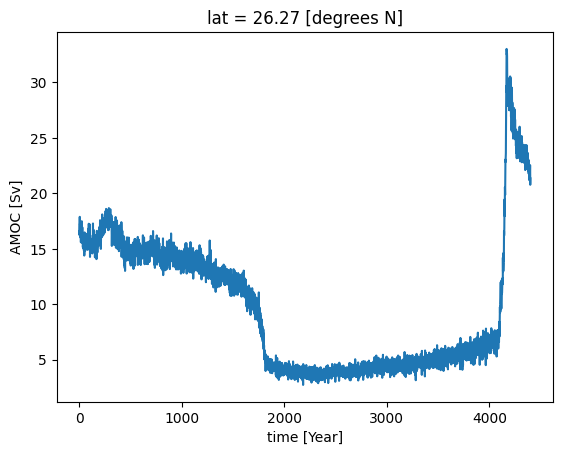

In [ ]:
"""
Quick look at AMOC at 26 degrees N

Pulls out the AMOC value at 26 degrees North (the latitude of the real-world RAPID observation array) and makes a quick plot, mainly to check the data looks like a proper AMOC hysteresis curve before building anything on top of it.
"""

ds = xr.open_mfdataset('/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Data/AMOC_structure/*.nc')
amoc_26n = ds.AMOC.sel(lat = 26.5, method = 'nearest').max(dim = 'depth')
amoc_26n.plot()

In [ ]:
"""
Inventory of all CESM data folders

Walks through every subfolder of the CESM data directory and prints a quick summary for each: how many files it has, their dimensions, variable and coordinate names, and the year range covered. This is exploratory bookkeeping to see what's available before the clean pipeline below (starting at Cell 1) is built.
"""

root = Path("/content/drive/MyDrive/Colab Notebooks/"
            "GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/"
            "RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Data")

assert root.exists(), f"Path does not exist: {root}"

for folder in sorted(root.iterdir()):
    if not folder.is_dir():
        continue
    files = sorted(folder.glob("*.nc"))
    if not files:
        print(f"=== {folder.name} === (no .nc files)")
        print()
        continue

    try:
        ds = xr.open_dataset(files[0])
    except Exception as e:
        try:
            ds = xr.open_dataset(files[0], engine="netcdf4")
        except Exception as e2:
            print(f"=== {folder.name} ===  (open failed: {e2})")
            continue

    print(f"=== {folder.name} ===")
    print(f"  files : {len(files)}  (first: {files[0].name}, last: {files[-1].name})")
    print(f"  dims  : {dict(ds.sizes)}")
    print(f"  vars  : {list(ds.data_vars)}")
    print(f"  coords: {list(ds.coords)}")
    if "year" in ds.variables:
        yrs = ds["year"].values
        print(f"  years in first file: {yrs[0]} .. {yrs[-1]} (n={len(yrs)})")
    if ds.attrs:
        print(f"  attrs : {dict(ds.attrs)}")
    print()
    ds.close()

=== AMOC_MHT ===
  files : 88  (first: CESM_year_0001-0050.nc, last: CESM_year_4351-4400.nc)
  dims  : {'time': 50, 'lat': 301}
  vars  : ['MHT_Atlantic', 'MHT_Indian-Pacific', 'MHT_Global']
  coords: ['time', 'lat']

=== AMOC_section_26N ===
  files : 88  (first: CESM_year_0001-0050.nc, last: CESM_year_4351-4400.nc)
  dims  : {'nlat_u': 1, 'nlon_u': 62, 'z_t': 60, 'year': 50}
  vars  : ['ULONG', 'ULAT', 'dz', 'UAREA', 'HU', 'DXU', 'VVEL']
  coords: ['year', 'z_t', 'nlon_u', 'nlat_u']
  years in first file: 1.0 .. 50.0 (n=50)

=== AMOC_structure ===
  files : 88  (first: CESM_year_0001-0050.nc, last: CESM_year_4351-4400.nc)
  dims  : {'time': 50, 'depth': 61, 'lat': 310}
  vars  : ['AMOC']
  coords: ['time', 'depth', 'lat']

=== Atlantic_meridional_profiles ===
  files : 88  (first: CESM_year_0001-0050.nc, last: CESM_year_4351-4400.nc)
  dims  : {'year': 50, 'depth': 60, 'lat': 49}
  vars  : ['TEMP', 'SALT', 'PD']
  coords: ['year', 'depth', 'lat']
  years in first file: 1.0 .. 50.0 (n

## 3. Building the State Vector

This section builds the ten-variable physical state vector used for the rest of the pipeline, from raw CESM output: the AMOC streamfunction diagnostics, the freshwater-transport diagnostics, and the thermohaline (temperature/salinity/density) diagnostics.


In [ ]:
"""
Cell 1 -- Setup and path verification

Sets up file paths, picks a GPU if one is available, and checks every expected CESM data folder actually exists before any real computation starts, so a wrong path is caught immediately rather than partway through a long run. Also records the key facts about the experiment: freshwater forcing was ramped from 0 to 0.66 Sv over years 0-2200 and back down to 0 by year 4400, the AMOC collapses around year 1758, and this analysis only uses years up to 3500 (the recovery afterwards is left out).
"""

# ---- Paths ----
CESM_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/"
    "RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Data"
)

OUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/CESM_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Device ----
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch device: {device}")

# ---- Verify data tree ----
assert CESM_ROOT.exists(), f"CESM_ROOT does not exist: {CESM_ROOT}"

expected_folders = [
    "AMOC_structure",
    "AMOC_section_26N",
    "AMOC_MHT",
    "Atlantic_meridional_profiles",
    "FOV_section_34S",
    "FOV_section_60N",
    "TEMP_2m",
]

print(f"CESM_ROOT: {CESM_ROOT}")
print()
for name in expected_folders:
    folder = CESM_ROOT / name
    if not folder.exists():
        print(f"  [MISSING] {name}")
        continue
    n_files = len(list(folder.glob("*.nc")))
    print(f"  [OK]      {name:35s}  ({n_files} .nc files)")

# ---- Experiment constants (from van Westen & Dijkstra 2023) ----
# Quasi-equilibrium hysteresis: F_H ramped up 0 -> 0.66 Sv at 3e-4 Sv/yr
# over years 0-2200, then down 0.66 -> 0 Sv at the same rate over 2200-4400.
F_H_RATE        = 3e-4      # Sv / yr
F_H_MAX         = 0.66      # Sv
F_H_PEAK_YEAR   = 2200      # model year at which F_H peaks
F_H_END_YEAR    = 4400      # model year at which F_H returns to 0
TIPPING_YEAR    = 1758      # model year of AMOC collapse onset (paper)
TRAIN_END_YEAR  = 3500      # truncate before the recovery
STATIONARY_END  = 400       # for climatological-std noise calibration

DT_YEARS = 1.0  # CESM output is annual

print()
print(f"Training window: years 1..{TRAIN_END_YEAR}   (recovery truncated)")
print(f"Stationary window for noise calibration: years 1..{STATIONARY_END}")

Torch device: cpu
CESM_ROOT: /content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Data

  [OK]      AMOC_structure                       (88 .nc files)
  [OK]      AMOC_section_26N                     (88 .nc files)
  [OK]      AMOC_MHT                             (88 .nc files)
  [OK]      Atlantic_meridional_profiles         (88 .nc files)
  [OK]      FOV_section_34S                      (88 .nc files)
  [OK]      FOV_section_60N                      (88 .nc files)
  [OK]      TEMP_2m                              (88 .nc files)

Training window: years 1..3500   (recovery truncated)
Stationary window for noise calibration: years 1..400


In [ ]:
"""
Cell 2 -- Load the AMOC overturning streamfunction

Loads the AMOC streamfunction (how strongly the water overturns at each depth and latitude) for the full 4400-year run. The data is split across 88 files of 50 years each; this cell stitches them into one continuous time series and checks the result is really 4400 years long with no gaps or duplicated years.
"""

AMOC_DIR = CESM_ROOT / "AMOC_structure"
files = sorted(AMOC_DIR.glob("CESM_year_*.nc"))
print(f"Found {len(files)} files in {AMOC_DIR.name}")
print(f"  first: {files[0].name}")
print(f"  last:  {files[-1].name}")

# ---- Peek at the first file to confirm structure ----
ds0 = xr.open_dataset(files[0])
print()
print("First file contents:")
print(f"  dims   : {dict(ds0.sizes)}")
print(f"  vars   : {list(ds0.data_vars)}")
print(f"  coords : {list(ds0.coords)}")
print(f"  AMOC shape: {ds0['AMOC'].shape}  dims: {ds0['AMOC'].dims}")
print(f"  depth range: {float(ds0['depth'].min()):.1f} .. "
      f"{float(ds0['depth'].max()):.1f} m")
print(f"  lat range:   {float(ds0['lat'].min()):.1f} .. "
      f"{float(ds0['lat'].max()):.1f} degN")
ds0.close()

# ---- Concatenate all files along time ----
# open_mfdataset is the right tool here; it's lazy, so memory stays modest
# until we actually .load() or .values.
print()
print("Opening all files (lazy) ...")
amoc_ds = xr.open_mfdataset(
    [str(f) for f in files],
    combine="nested",
    concat_dim="time",
    parallel=False,
)
print(f"  concatenated dims: {dict(amoc_ds.sizes)}")

# ---- Rebuild a clean year coordinate ----
# The per-file year coord is 1..50 in each file, which collides on concat.
# Replace with a monotonic 1..4400 index.
n_time = amoc_ds.sizes["time"]
years = np.arange(1, n_time + 1, dtype=np.int64)
amoc_ds = amoc_ds.assign_coords(time=years)
amoc_ds = amoc_ds.rename({"time": "year"})

print(f"  year coord: {int(amoc_ds.year[0])} .. {int(amoc_ds.year[-1])}  "
      f"(n={amoc_ds.sizes['year']})")

assert amoc_ds.sizes["year"] == 4400, \
    f"Expected 4400 years total, got {amoc_ds.sizes['year']}"

# ---- Load the AMOC field into memory ----
# Size: 4400 * 61 * 310 * 4 bytes (float32) ≈ 333 MB. Manageable.
print()
print("Loading AMOC field into memory ...")
amoc = amoc_ds["AMOC"].astype(np.float32).load()
print(f"  AMOC loaded: shape {amoc.shape}, dtype {amoc.dtype}, "
      f"size {amoc.nbytes / 1e6:.1f} MB")

depth = amoc["depth"].values   # metres
lat   = amoc["lat"].values     # degrees N

amoc_ds.close()

Found 88 files in AMOC_structure
  first: CESM_year_0001-0050.nc
  last:  CESM_year_4351-4400.nc

First file contents:
  dims   : {'time': 50, 'depth': 61, 'lat': 310}
  vars   : ['AMOC']
  coords : ['time', 'depth', 'lat']
  AMOC shape: (50, 61, 310)  dims: ('time', 'depth', 'lat')
  depth range: 0.0 .. 5500.0 m
  lat range:   -34.1 .. 90.0 degN

Opening all files (lazy) ...
  concatenated dims: {'time': 4400, 'depth': 61, 'lat': 310}
  year coord: 1 .. 4400  (n=4400)

Loading AMOC field into memory ...
  AMOC loaded: shape (4400, 61, 310), dtype float32, size 332.8 MB


Requested: depth = 1000.0 m, lat = 26.0°N
Nearest:   depth = 1041.4 m  (index 40)
           lat   = 25.80°N (index 188)

AMOC at 26°N, 1000 m:
  start mean (years 1-50):    +15.99 Sv
  pre-collapse (1700-1750):   +9.80 Sv
  OFF plateau (2500-3000):    -0.28 Sv
  recovery peak (years 4100-4150): +19.44 Sv


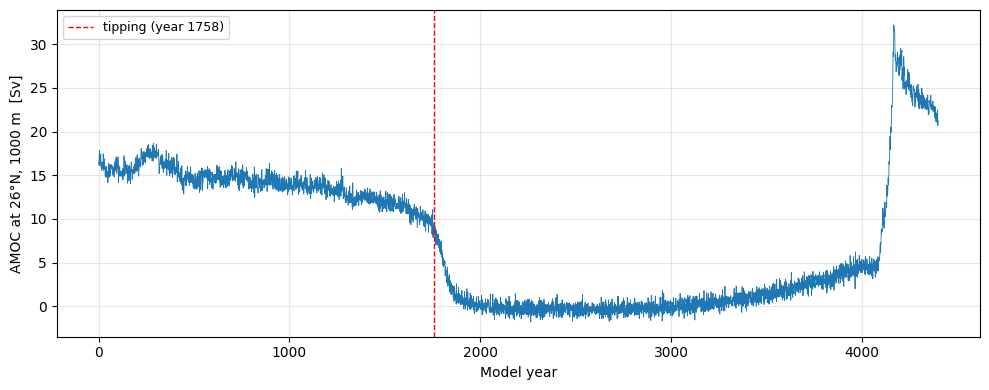

In [ ]:
"""
Cell 3 -- Sanity check: AMOC at 26N, 1000 m

Extracts the AMOC value at 26 degrees North and 1000 m depth (matching the real-world RAPID array) and plots it over the whole run, to check the loaded data reproduces the expected behaviour: strong overturning near the start, a slow decline, a rapid collapse to near zero around year 2000, a long collapsed plateau, and a sharp recovery spike at the very end.
"""

# ---- Find the closest depth and latitude indices ----
target_depth_m = 1000.0
target_lat_N   = 26.0

depth_idx = int(np.argmin(np.abs(depth - target_depth_m)))
lat_idx   = int(np.argmin(np.abs(lat   - target_lat_N)))

print(f"Requested: depth = {target_depth_m} m, lat = {target_lat_N}°N")
print(f"Nearest:   depth = {depth[depth_idx]:.1f} m  (index {depth_idx})")
print(f"           lat   = {lat[lat_idx]:.2f}°N (index {lat_idx})")

# ---- Extract the time series ----
amoc_26N = amoc.isel(depth=depth_idx, lat=lat_idx).values  # (4400,)
years_axis = amoc["year"].values                            # (4400,)

print()
print(f"AMOC at 26°N, 1000 m:")
print(f"  start mean (years 1-50):    {amoc_26N[:50].mean():+.2f} Sv")
print(f"  pre-collapse (1700-1750):   {amoc_26N[1699:1750].mean():+.2f} Sv")
print(f"  OFF plateau (2500-3000):    {amoc_26N[2499:3000].mean():+.2f} Sv")
print(f"  recovery peak (years 4100-4150): "
      f"{amoc_26N[4099:4150].max():+.2f} Sv")

# ---- Plot for visual confirmation ----
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
ax.plot(years_axis, amoc_26N, lw=0.6, color="tab:blue")
ax.axvline(TIPPING_YEAR, color="red", ls="--", lw=1,
           label=f"tipping (year {TIPPING_YEAR})")
#ax.axvline(TRAIN_END_YEAR, color="grey", ls=":", lw=1,
           #label=f"training cutoff (year {TRAIN_END_YEAR})")
ax.set_xlabel("Model year")
ax.set_ylabel("AMOC at 26°N, 1000 m  [Sv]")
#ax.set_title("Sanity check: AMOC streamfunction extracted from AMOC_structure")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()

# ---- Save at high resolution ----
fig_dir = OUT_DIR / "figures"
fig_dir.mkdir(exist_ok=True)
fig.savefig(fig_dir / "CESM_AMOC_26N_truth_trajectory.png",
            dpi=600, bbox_inches="tight")

plt.show()

Restricting to lat in [-30.0, 70.0]°N: 264 / 310 latitude cells retained
Deep cell: depth >= 2000.0 m: 15 / 61 depth cells retained
  deep depth range: 2075 .. 5500 m

Atlantic-restricted AMOC field: (4400, 61, 264)

Derived diagnostics:
  psi_26N_1000m : start=+15.99  OFF= -0.28 Sv
  psi_max       : start=+21.30  OFF=+11.98 Sv
  psi_min_deep  : start= -3.97  OFF= -1.34 Sv


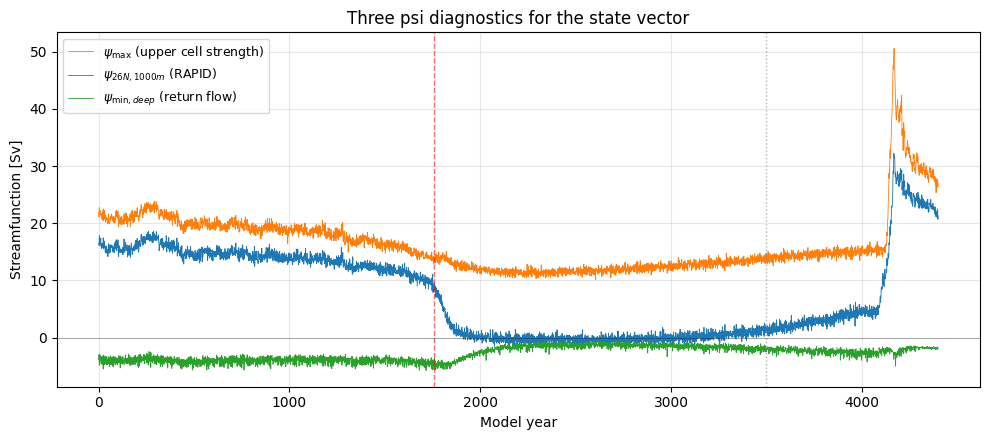

In [ ]:
"""
Cell 4 -- Derive psi_max and psi_min_deep

Builds two more AMOC-strength diagnostics from the streamfunction, alongside the 26N/1000m value: psi_max (the strongest overturning found anywhere in the upper ocean) and psi_min_deep (the strongest southward return flow below 2000 m). Both are restricted to Atlantic latitudes (-30 to 70N) so they aren't contaminated by unrelated circulation elsewhere.
"""

# ---- Latitude restriction ----
LAT_MIN, LAT_MAX = -30.0, 70.0
lat_mask = (lat >= LAT_MIN) & (lat <= LAT_MAX)
print(f"Restricting to lat in [{LAT_MIN}, {LAT_MAX}]°N: "
      f"{lat_mask.sum()} / {len(lat)} latitude cells retained")

# ---- Depth mask for deep-cell diagnostic ----
DEEP_MIN_M = 2000.0
deep_mask = depth >= DEEP_MIN_M
print(f"Deep cell: depth >= {DEEP_MIN_M} m: "
      f"{deep_mask.sum()} / {len(depth)} depth cells retained")
print(f"  deep depth range: {depth[deep_mask].min():.0f} .. "
      f"{depth[deep_mask].max():.0f} m")

# ---- Compute the diagnostics ----
# amoc has shape (4400, 61, 310) = (year, depth, lat)
amoc_atl = amoc.values[:, :, lat_mask]  # (4400, 61, n_lat_atl)
print(f"\nAtlantic-restricted AMOC field: {amoc_atl.shape}")

# psi_26N_1000m -- already extracted in cell 3
psi_26N_1000m = amoc_26N.copy()

# psi_max: max over (depth, lat) at each time
psi_max = amoc_atl.max(axis=(1, 2))

# psi_min_deep: min over (deep_depth, lat) at each time
psi_min_deep = amoc_atl[:, deep_mask, :].min(axis=(1, 2))

print()
print("Derived diagnostics:")
print(f"  psi_26N_1000m : start={psi_26N_1000m[:50].mean():+6.2f}  "
      f"OFF={psi_26N_1000m[2500:3000].mean():+6.2f} Sv")
print(f"  psi_max       : start={psi_max[:50].mean():+6.2f}  "
      f"OFF={psi_max[2500:3000].mean():+6.2f} Sv")
print(f"  psi_min_deep  : start={psi_min_deep[:50].mean():+6.2f}  "
      f"OFF={psi_min_deep[2500:3000].mean():+6.2f} Sv")

# ---- Plot all three together ----
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(years_axis, psi_max,        lw=0.6, color="tab:orange",
        label=r"$\psi_{\max}$ (upper cell strength)")
ax.plot(years_axis, psi_26N_1000m,  lw=0.6, color="tab:blue",
        label=r"$\psi_{26N,1000m}$ (RAPID)")
ax.plot(years_axis, psi_min_deep,   lw=0.6, color="tab:green",
        label=r"$\psi_{\min,deep}$ (return flow)")
ax.axvline(TIPPING_YEAR,    color="red",  ls="--", lw=1, alpha=0.6)
ax.axvline(TRAIN_END_YEAR,  color="grey", ls=":",  lw=1, alpha=0.6)
ax.axhline(0, color="k", lw=0.4, alpha=0.5)
ax.set_xlabel("Model year")
ax.set_ylabel("Streamfunction [Sv]")
ax.set_title("Three psi diagnostics for the state vector")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

year   50: psi_max = +20.41 Sv  at depth =  829.6 m, lat =  +34.6 N
year 1700: psi_max = +15.16 Sv  at depth =  928.0 m, lat =  +34.6 N
year 2500: psi_max = +11.01 Sv  at depth =   70.0 m, lat =  +13.4 N
year 3000: psi_max = +12.27 Sv  at depth =   60.0 m, lat =  +13.1 N
year 4200: psi_max = +37.91 Sv  at depth = 1171.0 m, lat =  +34.6 N


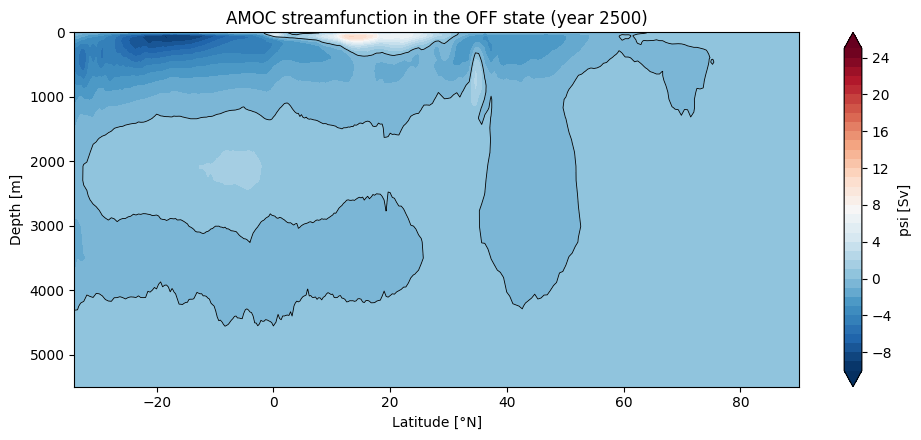

In [ ]:
"""
Cell 4b -- Diagnose where psi_max is being picked up

psi_max stayed suspiciously high even during the collapsed state, which shouldn't happen. This cell checks exactly where (in depth and latitude) that maximum is coming from at a few sample years, and plots the streamfunction as a 2D map during the collapsed state to see what's going on.
"""

# Sample a few representative times
sample_years = [50, 1700, 2500, 3000, 4200]  # ON, pre-collapse, OFF, OFF, recovery

for year in sample_years:
    yi = year - 1  # 0-indexed
    field = amoc_atl[yi]                # (depth, n_lat_atl)
    flat_idx = np.argmax(field)
    di, li_atl = np.unravel_index(flat_idx, field.shape)
    li = np.where(lat_mask)[0][li_atl]  # back to original lat index
    val = field[di, li_atl]
    print(f"year {year:4d}: psi_max = {val:+6.2f} Sv  "
          f"at depth = {depth[di]:6.1f} m, lat = {lat[li]:+6.1f} N")

# ---- Now look at the AMOC field in the OFF plateau as a 2D contour ----
yi_off = 2500 - 1
field_off = amoc.values[yi_off, :, :]   # full depth x lat, no atl mask

fig, ax = plt.subplots(figsize=(10, 4.5))
levels = np.linspace(-10, 25, 36)
cf = ax.contourf(lat, depth, field_off, levels=levels, cmap="RdBu_r", extend="both")
ax.contour(lat, depth, field_off, levels=[0], colors="k", linewidths=0.6)
ax.invert_yaxis()
ax.set_xlabel("Latitude [°N]")
ax.set_ylabel("Depth [m]")
ax.set_title(f"AMOC streamfunction in the OFF state (year {yi_off+1})")
plt.colorbar(cf, ax=ax, label="psi [Sv]")
plt.tight_layout()
plt.show()

psi_max restricted to depth >= 500.0 m: 28 / 61 depth cells retained
  retained depth range: 504 .. 5500 m

psi_max location after surface exclusion:
  year   50: psi_max = +20.41 Sv  at depth =  829.6 m, lat =  +34.6 N
  year 1700: psi_max = +15.16 Sv  at depth =  928.0 m, lat =  +34.6 N
  year 2500: psi_max =  +2.18 Sv  at depth =  744.4 m, lat =  +34.6 N
  year 3000: psi_max =  +2.25 Sv  at depth =  744.4 m, lat =  +34.6 N
  year 4200: psi_max = +37.91 Sv  at depth = 1171.0 m, lat =  +34.6 N


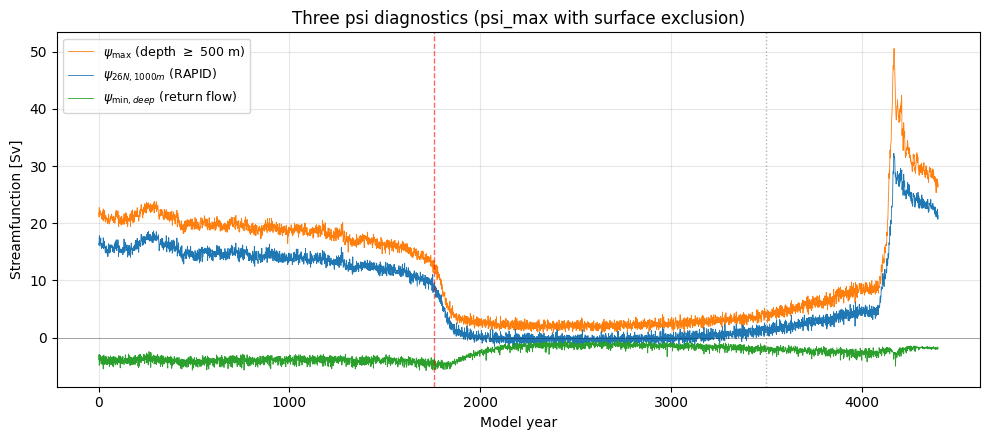

In [ ]:
"""
Cell 4c -- Recompute psi_max with surface-layer exclusion

The previous cell showed psi_max was actually picking up a shallow, wind-driven circulation cell near the surface, not the AMOC. 

This fixes it by restricting the calculation to depths of 500 m or more, then re-plots all three AMOC diagnostics together to confirm they now behave sensibly across every regime.
"""

PSI_MAX_DEPTH_MIN_M = 500.0
upper_mask = depth >= PSI_MAX_DEPTH_MIN_M
print(f"psi_max restricted to depth >= {PSI_MAX_DEPTH_MIN_M} m: "
      f"{upper_mask.sum()} / {len(depth)} depth cells retained")
print(f"  retained depth range: {depth[upper_mask].min():.0f} .. "
      f"{depth[upper_mask].max():.0f} m")

# Recompute psi_max over the upper-AMOC depth band only
psi_max_v2 = amoc_atl[:, upper_mask, :].max(axis=(1, 2))

# Re-check the locations at the same sample years
print()
print("psi_max location after surface exclusion:")
for year in sample_years:
    yi = year - 1
    field = amoc_atl[yi, upper_mask, :]
    flat_idx = np.argmax(field)
    di_local, li_atl = np.unravel_index(flat_idx, field.shape)
    di = np.where(upper_mask)[0][di_local]
    li = np.where(lat_mask)[0][li_atl]
    val = field[di_local, li_atl]
    print(f"  year {year:4d}: psi_max = {val:+6.2f} Sv  "
          f"at depth = {depth[di]:6.1f} m, lat = {lat[li]:+6.1f} N")

# ---- Replot with corrected psi_max ----
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(years_axis, psi_max_v2,     lw=0.6, color="tab:orange",
        label=r"$\psi_{\max}$ (depth $\geq$ 500 m)")
ax.plot(years_axis, psi_26N_1000m,  lw=0.6, color="tab:blue",
        label=r"$\psi_{26N,1000m}$ (RAPID)")
ax.plot(years_axis, psi_min_deep,   lw=0.6, color="tab:green",
        label=r"$\psi_{\min,deep}$ (return flow)")
ax.axvline(TIPPING_YEAR,    color="red",  ls="--", lw=1, alpha=0.6)
ax.axvline(TRAIN_END_YEAR,  color="grey", ls=":",  lw=1, alpha=0.6)
ax.axhline(0, color="k", lw=0.4, alpha=0.5)
ax.set_xlabel("Model year")
ax.set_ylabel("Streamfunction [Sv]")
ax.set_title("Three psi diagnostics (psi_max with surface exclusion)")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Promote to the canonical name for downstream use
psi_max = psi_max_v2

In [ ]:
"""
Locate the freshwater transport data

Points to the FOV_section_34S folder (freshwater transport at 34 degrees South), the next variable needed for the state vector.
"""

directory = "/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Data/FOV_section_34S/"

files = sorted(Path(directory).glob("*.nc"))

print(f"Found {len(files)} files")

ds_all = xr.open_mfdataset(files, combine="by_coords")

ds_all

Found 88 files


/tmp/ipykernel_9757/2856690537.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_all = xr.open_mfdataset(files, combine="by_coords")


<xarray.Dataset> Size: 501MB
Dimensions:  (year: 4400, z_t: 60, ULAT: 1, ULONG: 75, TLAT: 2, TLONG: 75)
Coordinates:
  * year     (year) float64 35kB 1.0 2.0 3.0 4.0 ... 4.398e+03 4.399e+03 4.4e+03
  * z_t      (z_t) float64 480B 5.0 15.0 25.0 ... 4.875e+03 5.125e+03 5.375e+03
  * ULAT     (ULAT) float64 8B -34.08
  * ULONG    (ULONG) float64 600B -61.37 -60.25 -59.12 ... 19.63 20.75 21.88
  * TLAT     (TLAT) float64 16B -34.35 -33.81
  * TLONG    (TLONG) float64 600B -61.94 -60.81 -59.69 ... 19.06 20.19 21.31
Data variables:
    dz       (year, z_t) float64 2MB dask.array<chunksize=(50, 60), meta=np.ndarray>
    UAREA    (year, ULAT, ULONG) float64 3MB dask.array<chunksize=(50, 1, 75), meta=np.ndarray>
    HU       (year, ULAT, ULONG) float64 3MB dask.array<chunksize=(50, 1, 75), meta=np.ndarray>
    DXU      (year, ULAT, ULONG) float64 3MB dask.array<chunksize=(50, 1, 75), meta=np.ndarray>
    TAREA    (year, TLAT, TLONG) float64 5MB dask.array<chunksize=(50, 2, 75), meta=np.ndarray>
    HT       (year, TLAT, TLONG) float64 5MB dask.array<chunksize=(50, 2, 75), meta=np.ndarray>
    DXT      (year, TLAT, TLONG) float64 5MB dask.array<chunksize=(50, 2, 75), meta=np.ndarray>
    VVEL     (year, z_t, ULAT, ULONG) float64 158MB dask.array<chunksize=(50, 60, 1, 75), meta=np.ndarray>
    SALT     (year, z_t, TLAT, TLONG) float64 317MB dask.array<chunksize=(50, 60, 1, 75), meta=np.ndarray>

In [ ]:
"""
Locate the precomputed freshwater-transport files

Searches the mounted Drive for the precomputed FOV_index files and the script that generates them, to confirm where these diagnostics actually live before loading them in the next cell.
"""

!find "/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis" -name "FOV_index*.nc"
!find "/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis" -name "FOV_index*.py"

/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Ocean/FOV_index_section_34S.nc
/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Ocean/FOV_index_section_60N.nc
/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Program/CESM/Ocean/FOV_index_60N.py
/content/drive/MyDrive/Colab Notebooks/GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Program/CESM/Ocean/FOV_index_34S.py


=== FOV_index_section_34S.nc ===
  dims : {'time': 4400}
  vars : ['Transport', 'F_OV', 'F_OV_ASW', 'F_OV_AIW', 'F_OV_NADW', 'F_OV_ABW']

=== FOV_index_section_60N.nc ===
  dims : {'time': 4400}
  vars : ['Transport', 'F_OV']

F_ovS summary:
  start (years 1-50):        +0.222 Sv
  pre-tipping (1700-1750):   -0.134 Sv
  minimum (year, value):     year 1726, -0.186 Sv
  OFF plateau (2500-3000):   +0.128 Sv


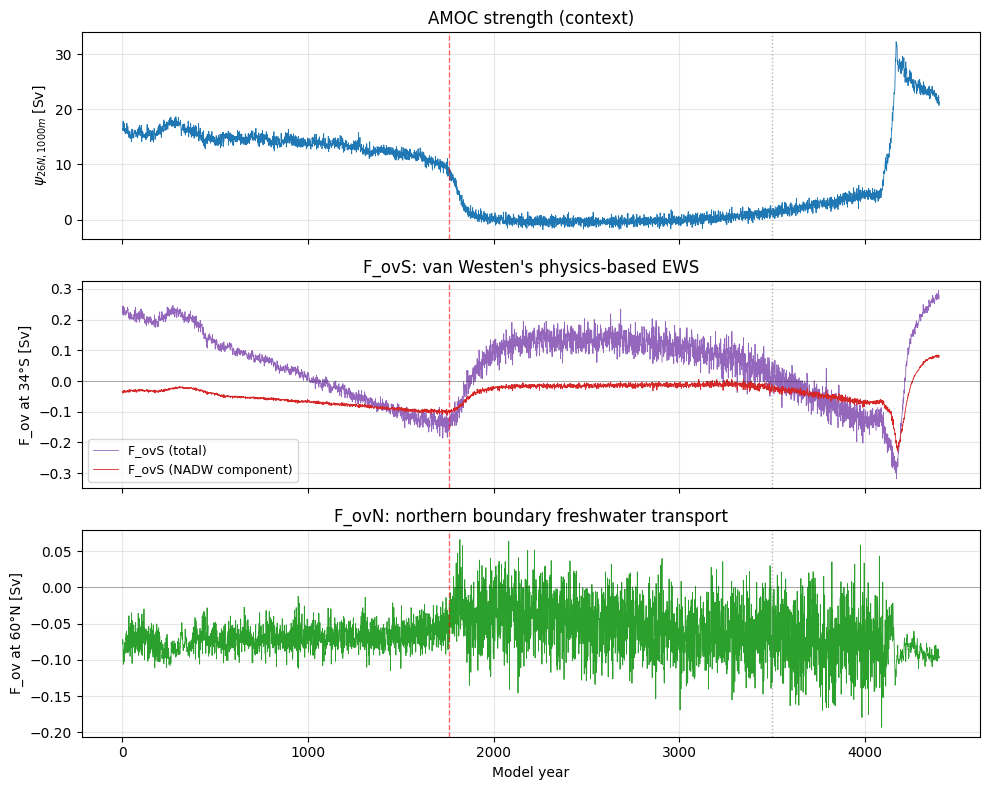

In [ ]:
"""
Cell 5 -- Load precomputed freshwater transport (F_ovS and F_ovN)

Loads the freshwater-transport diagnostics at 34S and 60N from precomputed files (a couple of variable names differ slightly from the original script, but it's the same data). Plots both alongside AMOC strength to check they behave as expected -- F_ovS in particular is the physics-based early-warning indicator used later on, since a negative F_ovS is a classic sign of AMOC bistability.
"""

OCEAN_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "GRL-AMOC-Hysteresis-GRL-AMOC-Hysteresis/"
    "RenevanWesten-GRL-AMOC-Hysteresis-2ae30f6/Data/CESM/Ocean"
)

# ---- Load 34S ----
fov_34S_file = OCEAN_DIR / "FOV_index_section_34S.nc"
ds_34S = xr.open_dataset(fov_34S_file)
print(f"=== {fov_34S_file.name} ===")
print(f"  dims : {dict(ds_34S.sizes)}")
print(f"  vars : {list(ds_34S.data_vars)}")

F_ovS          = ds_34S["F_OV"].values.astype(np.float32)
F_ovS_NADW     = ds_34S["F_OV_NADW"].values.astype(np.float32)
F_ovS_ASW      = ds_34S["F_OV_ASW"].values.astype(np.float32)
F_ovS_AIW      = ds_34S["F_OV_AIW"].values.astype(np.float32)   # Antarctic Intermediate Water
F_ovS_ABW      = ds_34S["F_OV_ABW"].values.astype(np.float32)   # Antarctic Bottom Water
ds_34S.close()

# ---- Load 60N ----
fov_60N_file = OCEAN_DIR / "FOV_index_section_60N.nc"
ds_60N = xr.open_dataset(fov_60N_file)
print(f"\n=== {fov_60N_file.name} ===")
print(f"  dims : {dict(ds_60N.sizes)}")
print(f"  vars : {list(ds_60N.data_vars)}")

F_ovN = ds_60N["F_OV"].values.astype(np.float32)
ds_60N.close()

# ---- Sanity check against van Westen's Fig. 4A ----
print()
print("F_ovS summary:")
print(f"  start (years 1-50):        {F_ovS[:50].mean():+.3f} Sv")
print(f"  pre-tipping (1700-1750):   {F_ovS[1699:1750].mean():+.3f} Sv")
print(f"  minimum (year, value):     "
      f"year {1 + int(np.argmin(F_ovS[:2200]))}, "
      f"{F_ovS[:2200].min():+.3f} Sv")
print(f"  OFF plateau (2500-3000):   {F_ovS[2499:3000].mean():+.3f} Sv")

# ---- Plot F_ovS, F_ovN alongside AMOC ----
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(years_axis, psi_26N_1000m, lw=0.6, color="tab:blue")
axes[0].axvline(TIPPING_YEAR,   color="red",  ls="--", lw=1, alpha=0.6)
axes[0].axvline(TRAIN_END_YEAR, color="grey", ls=":",  lw=1, alpha=0.6)
axes[0].set_ylabel(r"$\psi_{26N,1000m}$ [Sv]")
axes[0].set_title("AMOC strength (context)")
axes[0].grid(alpha=0.3)

axes[1].plot(years_axis, F_ovS,       lw=0.6, color="tab:purple",
             label="F_ovS (total)")
axes[1].plot(years_axis, F_ovS_NADW,  lw=0.6, color="tab:red",
             label="F_ovS (NADW component)")
axes[1].axhline(0, color="k", lw=0.4, alpha=0.5)
axes[1].axvline(TIPPING_YEAR,   color="red",  ls="--", lw=1, alpha=0.6)
axes[1].axvline(TRAIN_END_YEAR, color="grey", ls=":",  lw=1, alpha=0.6)
axes[1].set_ylabel("F_ov at 34°S [Sv]")
axes[1].set_title("F_ovS: van Westen's physics-based EWS")
axes[1].legend(loc="best", fontsize=9)
axes[1].grid(alpha=0.3)

axes[2].plot(years_axis, F_ovN, lw=0.6, color="tab:green")
axes[2].axhline(0, color="k", lw=0.4, alpha=0.5)
axes[2].axvline(TIPPING_YEAR,   color="red",  ls="--", lw=1, alpha=0.6)
axes[2].axvline(TRAIN_END_YEAR, color="grey", ls=":",  lw=1, alpha=0.6)
axes[2].set_ylabel("F_ov at 60°N [Sv]")
axes[2].set_xlabel("Model year")
axes[2].set_title("F_ovN: northern boundary freshwater transport")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
"""
Cell 6 -- Checkpoint: save progress so far

Saves the diagnostics computed so far (six of the eventual ten state-vector variables) to a small NetCDF file, so the notebook can pick up from here without re-loading and re-processing the much larger raw streamfunction data.
"""

import xarray as xr

DIAG_FILE = OUT_DIR / "cesm_diagnostics_partial.nc"

ds_out = xr.Dataset(
    data_vars={
        "psi_26N_1000m":  (("year",), psi_26N_1000m.astype(np.float32)),
        "psi_max":        (("year",), psi_max.astype(np.float32)),
        "psi_min_deep":   (("year",), psi_min_deep.astype(np.float32)),
        "F_ovS":          (("year",), F_ovS),
        "F_ovS_NADW":     (("year",), F_ovS_NADW),
        "F_ovS_ASW":      (("year",), F_ovS_ASW),
        "F_ovS_AIW":      (("year",), F_ovS_AIW),
        "F_ovS_ABW":      (("year",), F_ovS_ABW),
        "F_ovN":          (("year",), F_ovN),
    },
    coords={"year": years_axis.astype(np.int64)},
    attrs={
        "source": "van Westen et al. CESM quasi-equilibrium hysteresis run",
        "psi_max_depth_min_m":  PSI_MAX_DEPTH_MIN_M,
        "psi_min_deep_min_m":   DEEP_MIN_M,
        "atlantic_lat_range":   f"[{LAT_MIN}, {LAT_MAX}] degN",
        "tipping_year":         TIPPING_YEAR,
        "f_H_rate_sv_per_yr":   F_H_RATE,
        "f_H_peak_year":        F_H_PEAK_YEAR,
        "description": (
            "Partial diagnostics file (6 of 11 state-vector elements): "
            "psi diagnostics from AMOC_structure, F_ov diagnostics from "
            "precomputed van Westen script outputs. Thermohaline "
            "diagnostics (delta_rho, T/S north/south) still to be added."
        ),
    },
)

ds_out.to_netcdf(DIAG_FILE)
ds_out.close()

# ---- Verify the save by reading it back ----
ds_check = xr.open_dataset(DIAG_FILE)
print(f"Saved: {DIAG_FILE}")
print(f"  size: {DIAG_FILE.stat().st_size / 1024:.1f} KB")
print(f"  vars: {list(ds_check.data_vars)}")
print(f"  dims: {dict(ds_check.sizes)}")
print(f"  year range: {int(ds_check.year[0])} .. {int(ds_check.year[-1])}")
ds_check.close()

print()
print("Checkpoint complete. If the runtime dies, resume with:")
print(f"  ds = xr.open_dataset('{DIAG_FILE}')")

Saved: /content/drive/MyDrive/Colab Notebooks/CESM_outputs/cesm_diagnostics_partial.nc
  size: 203.6 KB
  vars: ['psi_26N_1000m', 'psi_max', 'psi_min_deep', 'F_ovS', 'F_ovS_NADW', 'F_ovS_ASW', 'F_ovS_AIW', 'F_ovS_ABW', 'F_ovN']
  dims: {'year': 4400}
  year range: 1 .. 4400

Checkpoint complete. If the runtime dies, resume with:
  ds = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/CESM_outputs/cesm_diagnostics_partial.nc')


In [ ]:
"""
Cell 7 -- Inspect the temperature/salinity/density data

Before computing anything from the Atlantic meridional profile files, checks what variables they actually contain and in what units -- temperature is usually in degrees C, salinity in PSU, and density is often stored in the older unit g/cm^3 rather than kg/m^3, so this needs to be verified rather than assumed.
"""

PROF_DIR = CESM_ROOT / "Atlantic_meridional_profiles"
files = sorted(PROF_DIR.glob("*.nc"))
print(f"Found {len(files)} files in {PROF_DIR.name}")
print(f"  first: {files[0].name}")
print(f"  last:  {files[-1].name}")

ds0 = xr.open_dataset(files[0])
print()
print("First file contents:")
print(f"  dims   : {dict(ds0.sizes)}")
print(f"  vars   : {list(ds0.data_vars)}")
print(f"  coords : {list(ds0.coords)}")
for v in ["TEMP", "SALT", "PD"]:
    if v in ds0.variables:
        arr = ds0[v]
        print(f"  {v:5s}: shape {tuple(arr.shape)}  dims {arr.dims}  "
              f"range [{float(arr.min()):+.4g}, {float(arr.max()):+.4g}]")
        if "units" in arr.attrs:
            print(f"         units = {arr.attrs['units']}")
ds0.close()

Found 88 files in Atlantic_meridional_profiles
  first: CESM_year_0001-0050.nc
  last:  CESM_year_4351-4400.nc

First file contents:
  dims   : {'year': 50, 'depth': 60, 'lat': 49}
  vars   : ['TEMP', 'SALT', 'PD']
  coords : ['year', 'depth', 'lat']
  TEMP : shape (50, 60, 49)  dims ('year', 'depth', 'lat')  range [+0.01997, +9.969e+36]
         units = deg C
  SALT : shape (50, 60, 49)  dims ('year', 'depth', 'lat')  range [+33.12, +9.969e+36]
         units = g/kg
  PD   : shape (50, 60, 49)  dims ('year', 'depth', 'lat')  range [+1021, +9.969e+36]
         units = kg/m^3


In [ ]:
"""
Cell 8 -- Load temperature, salinity and density

Loads TEMP, SALT and PD (density) over the full 4400-year run, using the same file-stitching approach as Cell 2. Together these take up around 1 GB of memory, which is fine on a high-RAM Colab instance but worth knowing if memory gets tight -- a more memory-lazy approach could be used instead once the data is reduced to box averages in the next cell.
"""

print("Opening Atlantic_meridional_profiles (concat along year) ...")

# Each file has year as its time dim with values 1..50, which collides on
# concat. Drop the per-file year coord in preprocess; we'll set a clean
# monotonic 1..4400 coord after concatenation.
def _drop_year_coord(ds):
    if "year" in ds.coords:
        ds = ds.drop_vars("year")
    return ds

prof_ds = xr.open_mfdataset(
    [str(f) for f in files],
    combine="nested",
    concat_dim="year",
    preprocess=_drop_year_coord,
    parallel=False,
)
print(f"  concatenated dims: {dict(prof_ds.sizes)}")

# Set a clean monotonic year coord 1..4400
n_year = prof_ds.sizes["year"]
prof_ds = prof_ds.assign_coords(year=np.arange(1, n_year + 1, dtype=np.int64))

assert prof_ds.sizes["year"] == 4400, \
    f"Expected 4400 years, got {prof_ds.sizes['year']}"
# Coordinate axes -- assume these names; CELL 7 will tell us if they differ
prof_depth = prof_ds["depth"].values   # metres (POP z_t)
prof_lat   = prof_ds["lat"].values     # degrees N

print(f"  depth: {prof_depth[0]:.1f} .. {prof_depth[-1]:.1f} m  "
      f"(n={len(prof_depth)})")
print(f"  lat  : {prof_lat[0]:+.1f} .. {prof_lat[-1]:+.1f} N  "
      f"(n={len(prof_lat)})")

# Load fields into memory
print()
print("Loading TEMP, SALT, PD ...")
TEMP = prof_ds["TEMP"].astype(np.float32).load()  # °C
SALT = prof_ds["SALT"].astype(np.float32).load()  # PSU
PD   = prof_ds["PD"].astype(np.float32).load()    # g/cm^3 expected

# Detect PD units and convert to kg/m^3 for physical sanity
pd_mean = float(PD.mean())
if pd_mean < 10.0:
    print(f"  PD mean = {pd_mean:.4f} -> assuming g/cm^3, converting to kg/m^3")
    PD = PD * 1000.0
else:
    print(f"  PD mean = {pd_mean:.2f} -> assuming kg/m^3, no conversion")

print()
print(f"  TEMP loaded: shape {TEMP.shape}, "
      f"range [{float(TEMP.min()):+.2f}, {float(TEMP.max()):+.2f}] °C")
print(f"  SALT loaded: shape {SALT.shape}, "
      f"range [{float(SALT.min()):+.2f}, {float(SALT.max()):+.2f}] PSU")
print(f"  PD   loaded: shape {PD.shape}, "
      f"range [{float(PD.min()):+.2f}, {float(PD.max()):+.2f}] kg/m^3")

prof_ds.close()

Opening Atlantic_meridional_profiles (concat along year) ...
  concatenated dims: {'year': 4400, 'depth': 60, 'lat': 49}
  depth: 5.0 .. 5375.0 m  (n=60)
  lat  : -34.0 .. +62.0 N  (n=49)

Loading TEMP, SALT, PD ...
  PD mean = inf -> assuming kg/m^3, no conversion

  TEMP loaded: shape (4400, 60, 49), range [-1.71, +9969209968386869046778552952102584320.00] °C
  SALT loaded: shape (4400, 60, 49), range [+29.50, +9969209968386869046778552952102584320.00] PSU
  PD   loaded: shape (4400, 60, 49), range [+1020.25, +9969209968386869046778552952102584320.00] kg/m^3


In [ ]:
"""
Cell 9 -- Average over north and south Atlantic boxes

Defines a northern box (45-60N, covering the subpolar sinking region) and a southern box (45-30S, a standard South Atlantic box used in AMOC-stability studies), and averages temperature, salinity and density over the upper 1000 m in each. This upper layer captures the surface effects most relevant to AMOC variability.
"""

NORTH_LAT = (45.0, 60.0)
SOUTH_LAT = (-45.0, -30.0)
UPPER_DEPTH_MAX = 1000.0  # metres

# ---- Latitude masks ----
north_mask = (prof_lat >= NORTH_LAT[0]) & (prof_lat <= NORTH_LAT[1])
south_mask = (prof_lat >= SOUTH_LAT[0]) & (prof_lat <= SOUTH_LAT[1])
print(f"North box {NORTH_LAT}°N: {north_mask.sum()} lat cells")
print(f"South box {SOUTH_LAT}°N: {south_mask.sum()} lat cells")

# ---- Upper-layer depth mask + weights ----
upper_mask = prof_depth <= UPPER_DEPTH_MAX
print(f"Upper layer (<= {UPPER_DEPTH_MAX} m): "
      f"{upper_mask.sum()} / {len(prof_depth)} depth cells")
print(f"  retained range: {prof_depth[upper_mask].min():.1f} .. "
      f"{prof_depth[upper_mask].max():.1f} m")

# Layer thicknesses from central differences of depth midpoints
# (POP's z_w_top/bot would be cleaner if available; this is a fine approximation
# at upper-ocean resolution where layers are 10-100 m thick)
dz = np.gradient(prof_depth)
dz_upper = dz[upper_mask]
print(f"  layer thicknesses range: {dz_upper.min():.1f} .. {dz_upper.max():.1f} m")

# ---- Box-mean reduction helper ----
def box_upper_mean(field, lat_mask):
    """
    field: xr.DataArray, dims (year, depth, lat)
    Returns: np.ndarray of shape (year,) -- upper-1000m, lat-mean
    """
    # Slice to upper layer + lat box -> (year, n_depth_upper, n_lat_box)
    sub = field.values[:, upper_mask, :][:, :, lat_mask]
    # Depth-weighted mean over depth axis -> (year, n_lat_box)
    depth_mean = np.average(sub, axis=1, weights=dz_upper)
    # Simple lat mean -> (year,)
    # (lat-area weighting cos(lat) is a refinement; for narrow boxes it's
    # a small correction. Drop it for now; revisit if Henk asks.)
    return depth_mean.mean(axis=1).astype(np.float32)

# ---- Compute the six box-mean time series ----
print()
print("Computing box-mean time series ...")
T_N = box_upper_mean(TEMP, north_mask)
S_N = box_upper_mean(SALT, north_mask)
rho_N = box_upper_mean(PD,   north_mask)

T_S = box_upper_mean(TEMP, south_mask)
S_S = box_upper_mean(SALT, south_mask)
rho_S = box_upper_mean(PD,   south_mask)

print(f"  T_N   : start={T_N[:50].mean():+6.2f}  OFF={T_N[2500:3000].mean():+6.2f} °C")
print(f"  T_S   : start={T_S[:50].mean():+6.2f}  OFF={T_S[2500:3000].mean():+6.2f} °C")
print(f"  S_N   : start={S_N[:50].mean():+6.2f}  OFF={S_N[2500:3000].mean():+6.2f} PSU")
print(f"  S_S   : start={S_S[:50].mean():+6.2f}  OFF={S_S[2500:3000].mean():+6.2f} PSU")
print(f"  rho_N : start={rho_N[:50].mean():+8.3f}  OFF={rho_N[2500:3000].mean():+8.3f} kg/m^3")
print(f"  rho_S : start={rho_S[:50].mean():+8.3f}  OFF={rho_S[2500:3000].mean():+8.3f} kg/m^3")

North box (45.0, 60.0)°N: 8 lat cells
South box (-45.0, -30.0)°N: 3 lat cells
Upper layer (<= 1000.0 m): 40 / 60 depth cells
  retained range: 5.0 .. 984.7 m
  layer thicknesses range: 10.0 .. 113.7 m

Computing box-mean time series ...
  T_N   : start= +6.64  OFF= +5.82 °C
  T_S   : start= +8.67  OFF=+12.93 °C
  S_N   : start=+35.21  OFF=+34.20 PSU
  S_S   : start=+34.36  OFF=+35.56 PSU
  rho_N : start=+1027.607  OFF=+1026.924 kg/m^3
  rho_S : start=+1026.564  OFF=+1026.777 kg/m^3


In [ ]:
"""
Cell 10 -- Thermohaline gradients (north minus south)

Computes the north-minus-south differences in temperature (dT), salinity (dS) and density (drho). In a healthy AMOC, the north is colder and denser than the south (drho > 0), which is what drives the sinking; after collapse this density gradient should weaken or reverse, a well-known early-warning signal, and this cell checks that's indeed what happens.
"""

dT   = (T_N - T_S  ).astype(np.float32)   # °C
dS   = (S_N - S_S  ).astype(np.float32)   # PSU
drho = (rho_N - rho_S).astype(np.float32)   # kg/m^3

print("Thermohaline gradients (N - S):")
print(f"  dT   : start={dT[:50].mean():+6.2f}  pre-tip={dT[1699:1750].mean():+6.2f}  "
      f"OFF={dT[2500:3000].mean():+6.2f} °C")
print(f"  dS   : start={dS[:50].mean():+6.2f}  pre-tip={dS[1699:1750].mean():+6.2f}  "
      f"OFF={dS[2500:3000].mean():+6.2f} PSU")
print(f"  drho : start={drho[:50].mean():+6.3f}  pre-tip={drho[1699:1750].mean():+6.3f}  "
      f"OFF={drho[2500:3000].mean():+6.3f} kg/m^3")

# Sanity check: drho must weaken as AMOC collapses
drho_change = drho[2500:3000].mean() - drho[:50].mean()
if drho_change < 0:
    print(f"\n  [OK]  drho weakens by {abs(drho_change):.3f} kg/m^3 from ON to OFF")
else:
    print(f"\n  [WARN] drho INCREASES from ON to OFF -- check box choices / sign")

Thermohaline gradients (N - S):
  dT   : start= -2.03  pre-tip= -5.78  OFF= -7.11 °C
  dS   : start= +0.85  pre-tip= -0.35  OFF= -1.36 PSU
  drho : start=+1.043  pre-tip=+0.622  OFF=+0.147 kg/m^3

  [OK]  drho weakens by 0.895 kg/m^3 from ON to OFF


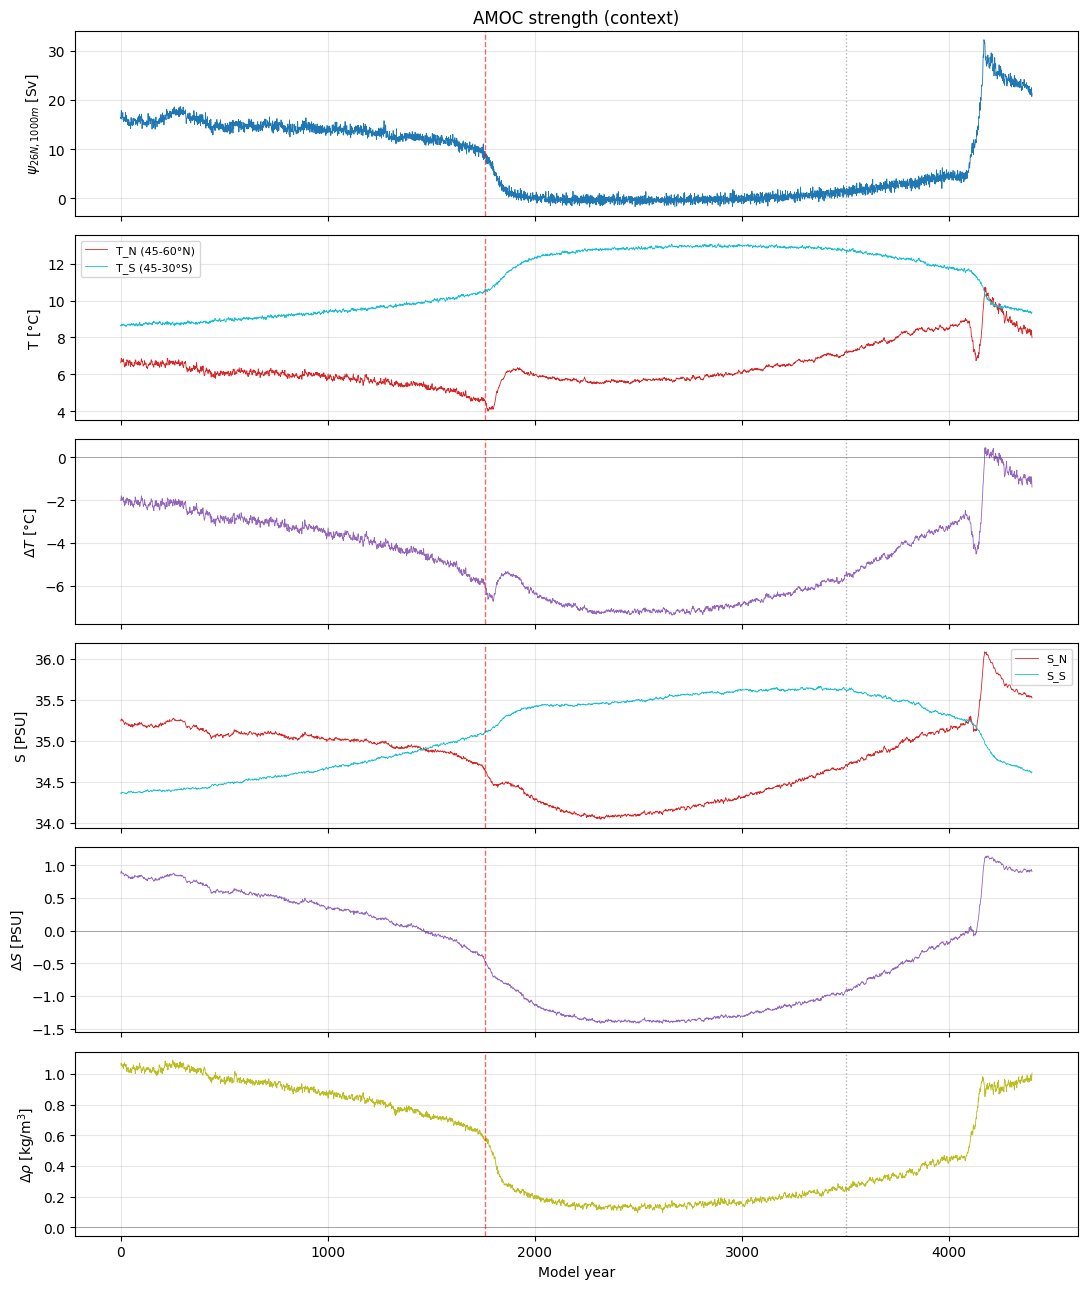

In [ ]:
"""
Cell 11 -- Plot the thermohaline diagnostics

Plots six panels for a visual check: AMOC strength for context, north/south temperature, the temperature gradient, north/south salinity, the salinity gradient, and finally the density gradient -- the key early-warning signal.
"""

fig, axes = plt.subplots(6, 1, figsize=(11, 13), sharex=True)

axes[0].plot(years_axis, psi_26N_1000m, lw=0.6, color="tab:blue")
axes[0].set_ylabel(r"$\psi_{26N,1000m}$ [Sv]")
axes[0].set_title("AMOC strength (context)")

axes[1].plot(years_axis, T_N, lw=0.6, color="tab:red",   label="T_N (45-60°N)")
axes[1].plot(years_axis, T_S, lw=0.6, color="tab:cyan",  label="T_S (45-30°S)")
axes[1].set_ylabel("T [°C]"); axes[1].legend(loc="best", fontsize=8)

axes[2].plot(years_axis, dT, lw=0.6, color="tab:purple")
axes[2].axhline(0, color="k", lw=0.4, alpha=0.5)
axes[2].set_ylabel(r"$\Delta T$ [°C]")

axes[3].plot(years_axis, S_N, lw=0.6, color="tab:red",   label="S_N")
axes[3].plot(years_axis, S_S, lw=0.6, color="tab:cyan",  label="S_S")
axes[3].set_ylabel("S [PSU]"); axes[3].legend(loc="best", fontsize=8)

axes[4].plot(years_axis, dS, lw=0.6, color="tab:purple")
axes[4].axhline(0, color="k", lw=0.4, alpha=0.5)
axes[4].set_ylabel(r"$\Delta S$ [PSU]")

axes[5].plot(years_axis, drho, lw=0.6, color="tab:olive")
axes[5].axhline(0, color="k", lw=0.4, alpha=0.5)
axes[5].set_ylabel(r"$\Delta \rho$ [kg/m$^3$]")
axes[5].set_xlabel("Model year")

for ax in axes:
    ax.axvline(TIPPING_YEAR,   color="red",  ls="--", lw=1, alpha=0.6)
    ax.axvline(TRAIN_END_YEAR, color="grey", ls=":",  lw=1, alpha=0.6)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
"""
Cell 12 -- Save the full ten-variable state vector

Saves a complete checkpoint with the ten variables making up the model's state vector: three AMOC-strength diagnostics, two freshwater-transport diagnostics, and five thermohaline diagnostics. A few extra variables are kept in the file for reference but aren't part of the ten used from here on.
"""

DIAG_FILE = OUT_DIR / "cesm_diagnostics_full.nc"

ds_out = xr.Dataset(
    data_vars={
        # --- canonical state vector (10 elements) ---
        "psi_26N_1000m":  (("year",), psi_26N_1000m.astype(np.float32)),
        "psi_max":        (("year",), psi_max.astype(np.float32)),
        "psi_min_deep":   (("year",), psi_min_deep.astype(np.float32)),
        "F_ovS":          (("year",), F_ovS),
        "F_ovN":          (("year",), F_ovN),
        "T_N":            (("year",), T_N),
        "S_N":            (("year",), S_N),
        "dT":             (("year",), dT),
        "dS":             (("year",), dS),
        "drho":           (("year",), drho),
        # --- auxiliary diagnostics (not in state vector) ---
        "T_S":            (("year",), T_S),
        "S_S":            (("year",), S_S),
        "rho_N":          (("year",), rho_N),
        "rho_S":          (("year",), rho_S),
        "F_ovS_NADW":     (("year",), F_ovS_NADW),
        "F_ovS_ASW":      (("year",), F_ovS_ASW),
        "F_ovS_AIW":      (("year",), F_ovS_AIW),
        "F_ovS_ABW":      (("year",), F_ovS_ABW),
    },
    coords={"year": years_axis.astype(np.int64)},
    attrs={
        "source": "van Westen et al. CESM quasi-equilibrium hysteresis run",
        "state_vector": (
            "psi_26N_1000m, psi_max, psi_min_deep, F_ovS, F_ovN, "
            "T_N, S_N, dT, dS, drho"
        ),
        "n_state": 10,
        "psi_max_depth_min_m":   PSI_MAX_DEPTH_MIN_M,
        "psi_min_deep_min_m":    DEEP_MIN_M,
        "atlantic_lat_range":    f"[{LAT_MIN}, {LAT_MAX}] degN",
        "north_box_lat":         f"[{NORTH_LAT[0]}, {NORTH_LAT[1]}] degN",
        "south_box_lat":         f"[{SOUTH_LAT[0]}, {SOUTH_LAT[1]}] degN",
        "upper_depth_max_m":     UPPER_DEPTH_MAX,
        "tipping_year":          TIPPING_YEAR,
        "train_end_year":        TRAIN_END_YEAR,
        "stationary_end_year":   STATIONARY_END,
        "f_H_rate_sv_per_yr":    F_H_RATE,
        "f_H_peak_year":         F_H_PEAK_YEAR,
        "description": (
            "Full diagnostics file. Canonical 10-element state vector "
            "x_t for the autoencoder + dynNet + PF pipeline, plus auxiliary "
            "diagnostics (T_S, S_S, rho_N, rho_S, F_ovS subcomponents) "
            "kept for downstream analysis but not in x_t."
        ),
    },
)

ds_out.to_netcdf(DIAG_FILE)
ds_out.close()

# Verify
ds_check = xr.open_dataset(DIAG_FILE)
print(f"Saved: {DIAG_FILE}")
print(f"  size: {DIAG_FILE.stat().st_size / 1024:.1f} KB")
print(f"  state vector ({ds_check.attrs['n_state']} elements):")
for name in ds_check.attrs['state_vector'].split(", "):
    print(f"    {name}")
print(f"  auxiliary: T_S, S_S, rho_N, rho_S, F_ovS_NADW/ASW/AIW/ABW")
ds_check.close()

Saved: /content/drive/MyDrive/Colab Notebooks/CESM_outputs/cesm_diagnostics_full.nc
  size: 363.2 KB
  state vector (10 elements):
    psi_26N_1000m
    psi_max
    psi_min_deep
    F_ovS
    F_ovN
    T_N
    S_N
    dT
    dS
    drho
  auxiliary: T_S, S_S, rho_N, rho_S, F_ovS_NADW/ASW/AIW/ABW


## 4. Learning a Compressed Representation: the Autoencoder

An autoencoder is trained to compress the ten-variable state vector down to a small (4-dimensional) latent representation, and to reconstruct it back. Everything downstream (the dynamics model, the particle filter, and the early-warning analyses) operates in this compressed latent space rather than directly on the ten raw variables.


In [ ]:
"""
Cell 13 -- Autoencoder setup: normalization and train/validation split

Loads the ten-variable state vector, normalizes each variable using statistics from the training data only (so no information leaks in from the validation period), and splits the data into training and validation sets. The validation set is a contiguous 200-year block (1500-1700) spanning the run-up to the AMOC collapse, so the autoencoder is tested on generalizing across the regime change, not just on easy, scattered points. Also sets the key settings: a 4-dimensional latent space, 128 hidden units, and 5000 training epochs.
"""

import torch
import torch.nn as nn
from torch.optim import Adam
import itertools

# ---- Load checkpoint and assemble X_state ----
ds = xr.open_dataset(OUT_DIR / "cesm_diagnostics_full.nc")

STATE_NAMES = [
    "psi_26N_1000m",
    "psi_max", "psi_min_deep",   # AMOC family
    "F_ovS", "F_ovN",                              # Freshwater family
    "T_N", "S_N", "dT", "dS", "drho",              # Thermohaline family
]

X_state = np.stack([ds[v].values for v in STATE_NAMES], axis=1).astype(np.float32)
years_full = ds["year"].values
ds.close()

print(f"X_state shape: {X_state.shape}  (n_year, n_features)")
print(f"  year range: {years_full[0]} .. {years_full[-1]}")

# ---- Truncate to training window 1..TRAIN_END_YEAR (=3500) ----
train_window = years_full <= TRAIN_END_YEAR
X_window = X_state[train_window]
years_window = years_full[train_window]
print(f"\nTraining window (years 1..{TRAIN_END_YEAR}): {X_window.shape}")

# ---- Holdout block ----
HOLDOUT_START = 1500
HOLDOUT_END   = 1700  # inclusive

holdout_mask = (years_window >= HOLDOUT_START) & (years_window <= HOLDOUT_END)
train_mask   = ~holdout_mask

X_train_raw = X_window[train_mask]
X_val_raw   = X_window[holdout_mask]
years_train = years_window[train_mask]
years_val   = years_window[holdout_mask]

print(f"\nSplit:")
print(f"  train: {X_train_raw.shape[0]} years "
      f"(1..{HOLDOUT_START-1} U {HOLDOUT_END+1}..{TRAIN_END_YEAR})")
print(f"  val  : {X_val_raw.shape[0]} years "
      f"({HOLDOUT_START}..{HOLDOUT_END})")

# ---- Normalize with train-only stats ----
mu_train    = X_train_raw.mean(axis=0)
sigma_train = X_train_raw.std (axis=0)
print(f"\nPer-variable train statistics:")
for j, name in enumerate(STATE_NAMES):
    print(f"  {name:15s}  mu={mu_train[j]:+9.4f}  sigma={sigma_train[j]:+8.4f}")

XN_train = ((X_train_raw - mu_train) / sigma_train).astype(np.float32)
XN_val   = ((X_val_raw   - mu_train) / sigma_train).astype(np.float32)
XN_full  = ((X_window    - mu_train) / sigma_train).astype(np.float32)

# Sanity: train normalized columns should have mu~0, sigma~1
print(f"\nAfter normalization (train):")
print(f"  mean abs(mu)    = {np.abs(XN_train.mean(0)).max():.2e}")
print(f"  max |sigma - 1| = {np.abs(XN_train.std(0) - 1).max():.2e}")

# ---- Move to torch ----
device = "cuda" if torch.cuda.is_available() else "cpu"
XN_train_t = torch.from_numpy(XN_train).to(device)
XN_val_t   = torch.from_numpy(XN_val).to(device)
XN_full_t  = torch.from_numpy(XN_full).to(device)

# ---- Hyperparameters (match Boussinesq) ----
physical_dimension = X_state.shape[1]   # = 10
latentDim = 4
hidden    = 128
ae_epochs = 5000
ae_lr     = 1e-3
ae_bs     = 264

print(f"\nAutoencoder hyperparameters:")
print(f"  physical_dimension = {physical_dimension}")
print(f"  latentDim          = {latentDim}")
print(f"  hidden             = {hidden}")
print(f"  ae_epochs          = {ae_epochs}")
print(f"  ae_lr              = {ae_lr}")
print(f"  ae_bs              = {ae_bs}")
print(f"  device             = {device}")

X_state shape: (4400, 10)  (n_year, n_features)
  year range: 1 .. 4400

Training window (years 1..3500): (3500, 10)

Split:
  train: 3299 years (1..1499 U 1701..3500)
  val  : 201 years (1500..1700)

Per-variable train statistics:
  psi_26N_1000m    mu=  +6.9396  sigma= +7.1677
  psi_max          mu= +10.5758  sigma= +8.3940
  psi_min_deep     mu=  -2.8901  sigma= +1.3171
  F_ovS            mu=  +0.0804  sigma= +0.0895
  F_ovN            mu=  -0.0603  sigma= +0.0301
  T_N              mu=  +5.9716  sigma= +0.5089
  S_N              mu= +34.6535  sigma= +0.4087
  dT               mu=  -5.0648  sigma= +1.8507
  dS               mu=  -0.4261  sigma= +0.8685
  drho             mu=  +0.5278  sigma= +0.3715

After normalization (train):
  mean abs(mu)    = 2.28e-05
  max |sigma - 1| = 6.56e-07

Autoencoder hyperparameters:
  physical_dimension = 10
  latentDim          = 4
  hidden             = 128
  ae_epochs          = 5000
  ae_lr              = 0.001
  ae_bs              = 264
  device

In [ ]:
"""
Cell 14 -- Define the encoder and decoder networks

Defines the autoencoder as two small neural networks: an encoder that compresses the 10 physical variables down to a 4-dimensional latent representation, and a decoder that reconstructs the 10 variables back from it. Both use two hidden layers with a smooth (tanh) activation. The networks are kept small on purpose, since a single ~3500-year trajectory with only 10 variables would let a bigger model simply overfit. The architecture matches the one used for the Boussinesq model elsewhere in the thesis, for consistency.
"""

torch.manual_seed(42)

encNet = nn.Sequential(
    nn.Linear(physical_dimension, hidden),
    nn.Tanh(),
    nn.Linear(hidden, hidden),
    nn.Tanh(),
    nn.Linear(hidden, latentDim),
).to(device)

decNet = nn.Sequential(
    nn.Linear(latentDim, hidden),
    nn.Tanh(),
    nn.Linear(hidden, hidden),
    nn.Tanh(),
    nn.Linear(hidden, physical_dimension),
).to(device)

# Parameter counts for sanity
n_enc = sum(p.numel() for p in encNet.parameters())
n_dec = sum(p.numel() for p in decNet.parameters())
print(f"encNet: {n_enc:,} parameters")
print(f"decNet: {n_dec:,} parameters")
print(f"  total trainable: {n_enc + n_dec:,}")
print(f"  train samples:   {XN_train_t.shape[0]:,}")
print(f"  ratio (params per sample): {(n_enc + n_dec) / XN_train_t.shape[0]:.1f}")

encNet: 18,436 parameters
decNet: 18,442 parameters
  total trainable: 36,878
  train samples:   3,299
  ratio (params per sample): 11.2


In [ ]:
"""
Cell 15 -- Train the autoencoder

Trains the encoder and decoder together to minimize reconstruction error on the training data, for 5000 epochs. Validation loss is tracked throughout but not used to stop training early -- the full run completes and the results are inspected afterwards.
"""

encNet.train()
decNet.train()

opt_ae = Adam(itertools.chain(encNet.parameters(), decNet.parameters()),
              lr=ae_lr)

lossHist_train = np.zeros(ae_epochs, dtype=np.float64)
lossHist_val   = np.zeros(ae_epochs, dtype=np.float64)

print("Training autoencoder ...")
for ep in range(1, ae_epochs + 1):
    # ---- Train step ----
    idx = torch.randint(0, XN_train_t.shape[0], (ae_bs,), device=device)
    x = XN_train_t[idx]
    z = encNet(x)
    xrec = decNet(z)
    loss_train = torch.mean(torch.sum((x - xrec)**2, dim=1))

    opt_ae.zero_grad(set_to_none=True)
    loss_train.backward()
    opt_ae.step()

    lossHist_train[ep - 1] = loss_train.item()

    # ---- Val step (no gradient) ----
    with torch.no_grad():
        encNet.eval(); decNet.eval()
        xrec_val = decNet(encNet(XN_val_t))
        loss_val = torch.mean(torch.sum((XN_val_t - xrec_val)**2, dim=1))
        lossHist_val[ep - 1] = loss_val.item()
        encNet.train(); decNet.train()

    if ep % 250 == 0 or ep == 1:
        print(f"  ep {ep:5d}/{ae_epochs}  "
              f"train={loss_train.item():.3e}  val={loss_val.item():.3e}")

encNet.eval()
decNet.eval()

# Final latent statistics
with torch.no_grad():
    Z_train = encNet(XN_train_t).cpu().numpy()
print(f"\nLatent statistics on training set:")
print(f"  mean : {Z_train.mean(0)}")
print(f"  std  : {Z_train.std (0)}")

Training autoencoder ...
  ep     1/5000  train=1.035e+01  val=1.045e+01
  ep   250/5000  train=9.066e-02  val=9.657e-02
  ep   500/5000  train=5.242e-02  val=6.098e-02
  ep   750/5000  train=4.184e-02  val=5.346e-02
  ep  1000/5000  train=3.396e-02  val=4.169e-02
  ep  1250/5000  train=2.730e-02  val=3.083e-02
  ep  1500/5000  train=2.675e-02  val=3.139e-02
  ep  1750/5000  train=2.800e-02  val=2.682e-02
  ep  2000/5000  train=2.343e-02  val=2.617e-02
  ep  2250/5000  train=2.061e-02  val=2.842e-02
  ep  2500/5000  train=2.276e-02  val=2.810e-02
  ep  2750/5000  train=2.355e-02  val=2.264e-02
  ep  3000/5000  train=2.149e-02  val=2.467e-02
  ep  3250/5000  train=2.009e-02  val=2.492e-02
  ep  3500/5000  train=2.136e-02  val=3.040e-02
  ep  3750/5000  train=2.097e-02  val=2.883e-02
  ep  4000/5000  train=1.631e-02  val=2.421e-02
  ep  4250/5000  train=2.339e-02  val=2.514e-02
  ep  4500/5000  train=1.886e-02  val=2.460e-02
  ep  4750/5000  train=2.167e-02  val=2.688e-02
  ep  5000/5000

In [ ]:
"""
Set up a report-output folder

Creates a second output folder used specifically for figures and tables destined for the written thesis report, separate from the main working folder.
"""

OUT_DIR_SEC = Path("/content/drive/MyDrive/Colab Notebooks/CESM_outputs_for_report")
OUT_DIR_SEC.mkdir(parents=True, exist_ok=True)

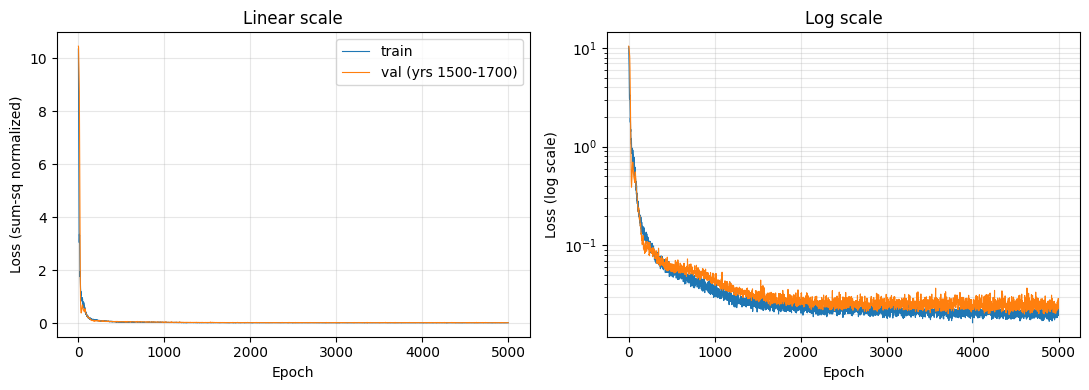

Final train loss: 2.141e-02
Final val   loss: 2.295e-02
Ratio val/train : 1.07


In [ ]:
"""
Cell 16 -- Training and validation loss curves

Plots training and validation loss across all 5000 epochs, on both linear and logarithmic scales. Both should decrease and flatten out, and validation loss should track training loss reasonably closely -- if it diverges upward the model is overfitting, and if it stays far above training loss the autoencoder is struggling to represent the collapsed state.
"""

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(lossHist_train, lw=0.8, label="train", color="tab:blue")
axes[0].plot(lossHist_val,   lw=0.8, label="val (yrs 1500-1700)",
             color="tab:orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (sum-sq normalized)")
axes[0].set_title("Linear scale")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(lossHist_train, lw=0.8, color="tab:blue")
axes[1].semilogy(lossHist_val,   lw=0.8, color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (log scale)")
axes[1].set_title("Log scale")
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig(OUT_DIR_SEC / "AE_loss.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Final train loss: {lossHist_train[-1]:.3e}")
print(f"Final val   loss: {lossHist_val[-1]:.3e}")
print(f"Ratio val/train : {lossHist_val[-1] / lossHist_train[-1]:.2f}")

variable            RMSE_tr    RMSE_val    R2_tr   R2_val
------------------------------------------------------------
psi_26N_1000m        0.5822      0.5673    0.993    0.504
psi_max              0.5401      0.5797    0.996    0.552
psi_min_deep        0.02325     0.02013    1.000    0.998
F_ovS              0.003103    0.003811    0.999    0.950
F_ovN             0.0006308   0.0004631    1.000    0.999
T_N                  0.0162     0.03409    0.999    0.972
S_N                 0.01869     0.01154    0.998    0.935
dT                  0.07577     0.05897    0.998    0.962
dS                  0.02503      0.0251    0.999    0.907
drho                 0.0148     0.01857    0.998    0.520


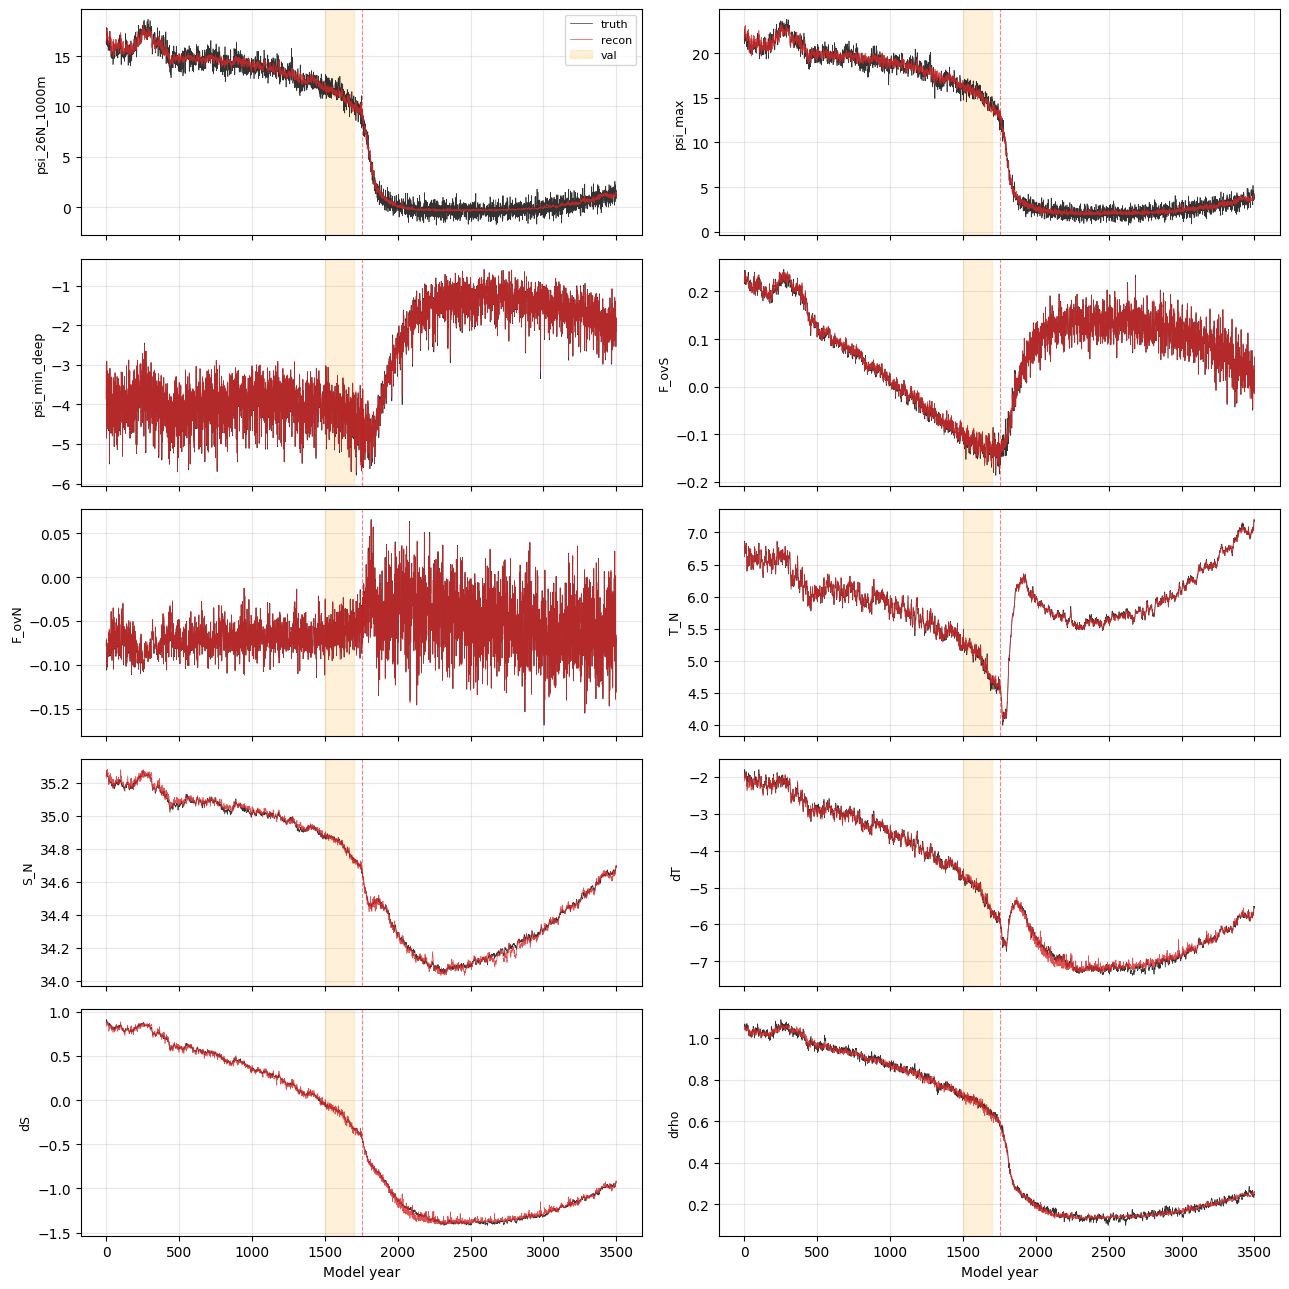

In [ ]:
"""
Cell 17 -- Per-variable reconstruction accuracy

Measures how well the autoencoder reconstructs each of the 10 physical variables individually, in real physical units, using RMSE and R-squared on both training and validation sets. An R-squared below 0 on validation would be a red flag (worse than just predicting the mean); above 0.95 across the board is a good result. Also plots truth against reconstruction for all 10 variables so any systematic mismatch is visible directly.
"""

with torch.no_grad():
    Xrec_train_n = decNet(encNet(XN_train_t)).cpu().numpy()
    Xrec_val_n   = decNet(encNet(XN_val_t  )).cpu().numpy()
    Xrec_full_n  = decNet(encNet(XN_full_t )).cpu().numpy()

# De-normalize
Xrec_train = Xrec_train_n * sigma_train + mu_train
Xrec_val   = Xrec_val_n   * sigma_train + mu_train
Xrec_full  = Xrec_full_n  * sigma_train + mu_train

def rmse(a, b): return np.sqrt(np.mean((a - b)**2, axis=0))
def r2(a, b):
    ss_res = np.sum((a - b)**2, axis=0)
    ss_tot = np.sum((a - a.mean(0))**2, axis=0)
    return 1.0 - ss_res / ss_tot

rmse_train = rmse(X_train_raw, Xrec_train)
rmse_val   = rmse(X_val_raw,   Xrec_val)
r2_train   = r2(X_train_raw, Xrec_train)
r2_val     = r2(X_val_raw,   Xrec_val)

print(f"{'variable':15s}  {'RMSE_tr':>10s}  {'RMSE_val':>10s}  "
      f"{'R2_tr':>7s}  {'R2_val':>7s}")
print("-" * 60)
for j, name in enumerate(STATE_NAMES):
    print(f"{name:15s}  {rmse_train[j]:10.4g}  {rmse_val[j]:10.4g}  "
          f"{r2_train[j]:7.3f}  {r2_val[j]:7.3f}")

# ---- Truth vs reconstruction plot, all 10 variables ----
fig, axes = plt.subplots(5, 2, figsize=(13, 13), sharex=True)
axes = axes.flatten()

for j, name in enumerate(STATE_NAMES):
    ax = axes[j]
    ax.plot(years_window, X_window[:, j],   lw=0.5, color="k",
            label="truth", alpha=0.8)
    ax.plot(years_window, Xrec_full[:, j],  lw=0.5, color="tab:red",
            label="recon", alpha=0.8)
    ax.axvspan(HOLDOUT_START, HOLDOUT_END, color="orange", alpha=0.15,
               label="val")
    ax.axvline(TIPPING_YEAR, color="red", ls="--", lw=0.8, alpha=0.5)
    ax.set_ylabel(name, fontsize=9)
    ax.grid(alpha=0.3)
    if j == 0:
        ax.legend(loc="best", fontsize=8)

axes[-2].set_xlabel("Model year")
axes[-1].set_xlabel("Model year")
#plt.suptitle("Truth vs autoencoder reconstruction (all 10 state variables)",
             #y=1.0, fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUT_DIR_SEC}/Truth_vs_autoencoder_reconstruction.png", dpi = 200, bbox_inches = "tight")
plt.show()

Latent trajectory shape: (3500, 4)
Per-dim ranges:
  z0: [-2.869, +2.907]
  z1: [-2.616, +2.555]
  z2: [-2.169, +2.051]
  z3: [-2.499, +3.030]


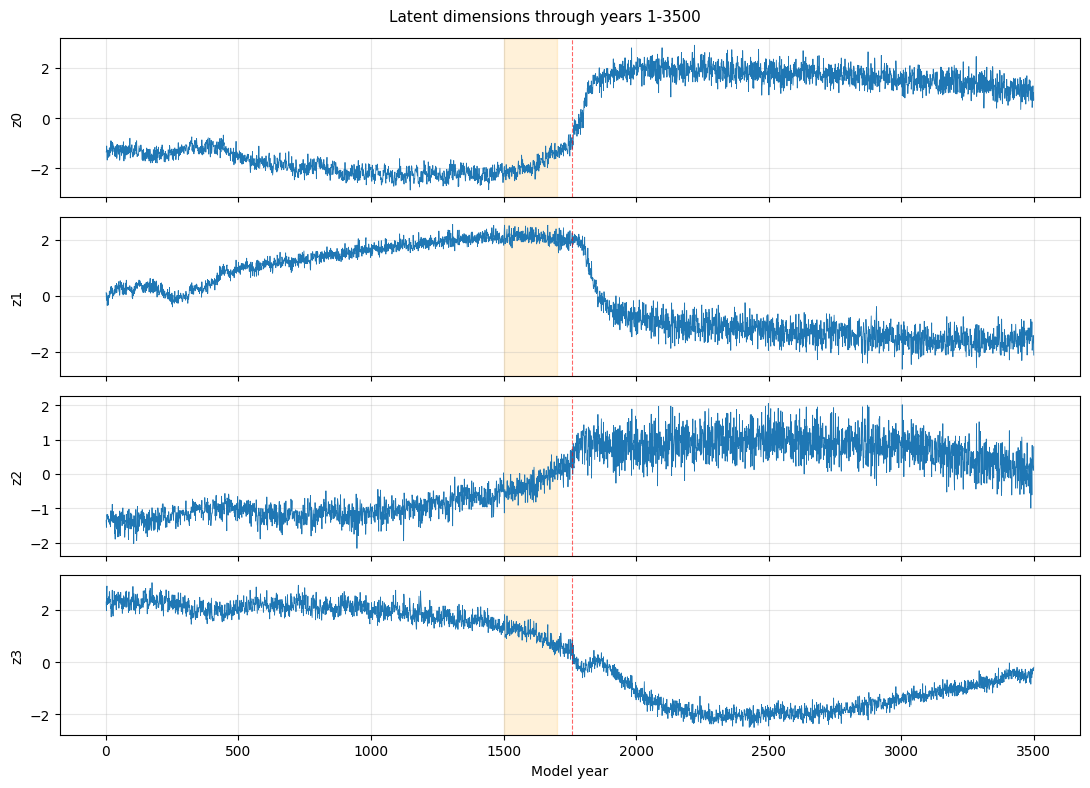


Correlation of latent dims with physical variables:
variable              z0       z1       z2       z3
-----------------------------------------------------
psi_26N_1000m     -0.943   +0.807   -0.909   +0.969
psi_max           -0.945   +0.802   -0.907   +0.970
psi_min_deep      +0.788   -0.847   +0.679   -0.875
F_ovS             +0.397   -0.631   +0.079   -0.200
F_ovN             +0.405   -0.051   +0.088   -0.393
T_N               +0.145   -0.474   -0.195   +0.094
S_N               -0.905   +0.718   -0.924   +0.980
dT                -0.844   +0.645   -0.921   +0.961
dS                -0.906   +0.746   -0.924   +0.978
drho              -0.923   +0.774   -0.919   +0.972


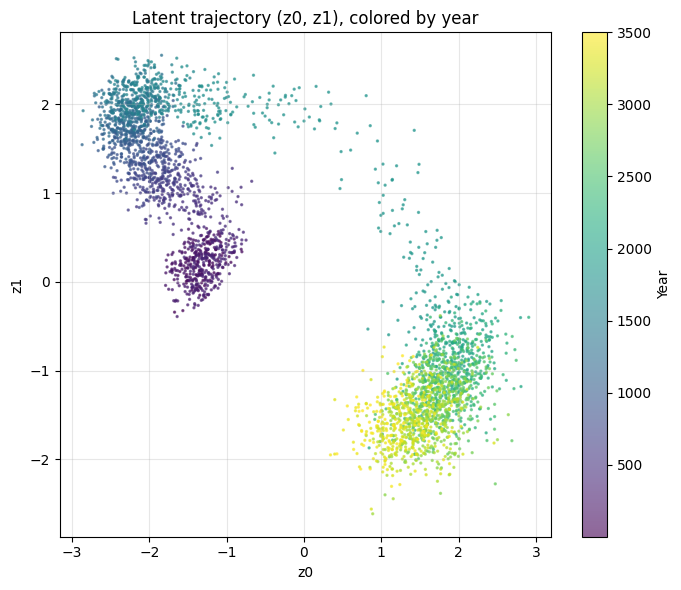

In [ ]:
"""
Cell 18 -- Visualize the latent trajectory

Encodes the full training window into the 4-dimensional latent space and checks what the trajectory looks like: it should be smooth, with no sudden jumps, and should visually separate into the 'on', 'ramping' and 'off' AMOC states. Also checks the correlation between each latent dimension and each physical variable -- ideally at least one latent dimension should track AMOC strength closely, showing the autoencoder has found AMOC strength as a meaningful direction on its own.
"""

with torch.no_grad():
    Z_full = encNet(XN_full_t).cpu().numpy()  # (n_year, latentDim)

print(f"Latent trajectory shape: {Z_full.shape}")
print(f"Per-dim ranges:")
for k in range(latentDim):
    print(f"  z{k}: [{Z_full[:, k].min():+.3f}, {Z_full[:, k].max():+.3f}]")

# ---- Latent dim time series, colored by ψ_26N ----
psi_idx = STATE_NAMES.index("psi_26N_1000m")
psi_full = X_window[:, psi_idx]

fig, axes = plt.subplots(latentDim, 1, figsize=(11, 2 * latentDim),
                         sharex=True)
for k in range(latentDim):
    ax = axes[k]
    ax.plot(years_window, Z_full[:, k], lw=0.6, color="tab:blue")
    ax.axvspan(HOLDOUT_START, HOLDOUT_END, color="orange", alpha=0.15)
    ax.axvline(TIPPING_YEAR, color="red", ls="--", lw=0.8, alpha=0.6)
    ax.set_ylabel(f"z{k}")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Model year")
plt.suptitle("Latent dimensions through years 1-3500", fontsize=11)
plt.tight_layout()
plt.show()

# ---- Correlation of each latent dim with each physical variable ----
print(f"\nCorrelation of latent dims with physical variables:")
print(f"{'variable':15s}  " + "  ".join(f"{'z'+str(k):>7s}"
                                        for k in range(latentDim)))
print("-" * (17 + 9 * latentDim))
for j, name in enumerate(STATE_NAMES):
    corrs = [np.corrcoef(X_window[:, j], Z_full[:, k])[0, 1]
             for k in range(latentDim)]
    row = "  ".join(f"{c:+7.3f}" for c in corrs)
    print(f"{name:15s}  {row}")

# ---- 2D latent projection colored by year ----
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(Z_full[:, 0], Z_full[:, 1],
                c=years_window, cmap="viridis", s=2, alpha=0.6)
ax.set_xlabel("z0"); ax.set_ylabel("z1")
ax.set_title("Latent trajectory (z0, z1), colored by year")
plt.colorbar(sc, ax=ax, label="Year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Learning the Dynamics: the Latent Evolution Network

A second neural network is trained to predict how the latent state evolves from one year to the next, given the freshwater forcing. One-step training alone isn't enough to capture the AMOC collapse correctly, so the network is further refined on longer rollouts and validated on multi-year forecasts.


U_window shape: (3500, 2)
  F_H_norm range : [0.000, 1.000]
  ramp_dir values: [-1.  0.  1.]
  ramp-up years  : 2199
  ramp-down years: 1300


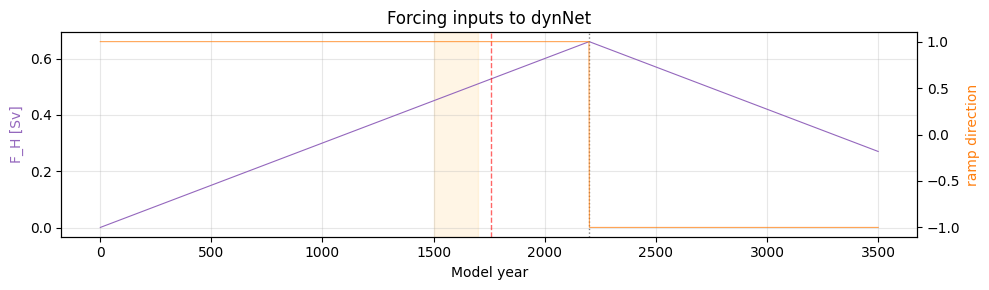

In [ ]:
"""
Cell 19 -- Build the freshwater forcing input

Reconstructs the freshwater-forcing time series exactly as applied in the CESM experiment (ramped from 0 to 0.66 Sv over years 0-2200, then back down by year 4400), normalizes it to [0, 1], and adds a second input: the sign of its rate of change (+1 while ramping up, -1 while ramping down). This second signal matters because a given forcing value occurs during both the ramp-up and the ramp-down, and without a way to tell them apart, the dynamics model has no way to know which direction the system is moving.
"""

# ---- F_H over full 4400-year run, then truncate to training window ----
F_H_full = np.zeros_like(years_full, dtype=np.float32)
up_mask    = years_full <= F_H_PEAK_YEAR        # 1..2200
down_mask  = (years_full > F_H_PEAK_YEAR) & (years_full <= F_H_END_YEAR)

F_H_full[up_mask]   = F_H_RATE * years_full[up_mask].astype(np.float32)
F_H_full[down_mask] = F_H_MAX - F_H_RATE * (
    years_full[down_mask].astype(np.float32) - F_H_PEAK_YEAR)

# Restrict to training window (1..3500)
F_H_window = F_H_full[train_window]

# ---- Ramp direction ----
# Sign-encoded: +1 during ramp-up, -1 during ramp-down, 0 at the peak year
ramp_dir_window = np.where(years_window <= F_H_PEAK_YEAR,
                           +1.0, -1.0).astype(np.float32)
# Zero out the single peak year for cleanness
ramp_dir_window[years_window == F_H_PEAK_YEAR] = 0.0

# ---- Normalize F_H to [0, 1] ----
F_H_norm = (F_H_window / F_H_MAX).astype(np.float32)

# ---- Stack into a 2-channel forcing series ----
U_window = np.stack([F_H_norm, ramp_dir_window], axis=1)  # (N, 2)
print(f"U_window shape: {U_window.shape}")
print(f"  F_H_norm range : [{U_window[:, 0].min():.3f}, {U_window[:, 0].max():.3f}]")
print(f"  ramp_dir values: {np.unique(U_window[:, 1])}")
print(f"  ramp-up years  : {(U_window[:, 1] > 0).sum()}")
print(f"  ramp-down years: {(U_window[:, 1] < 0).sum()}")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(years_window, F_H_window, lw=0.8, color="tab:purple", label="F_H [Sv]")
ax2 = ax.twinx()
ax2.plot(years_window, ramp_dir_window, lw=0.8, color="tab:orange",
         label="ramp_dir", alpha=0.7)
ax.axvline(F_H_PEAK_YEAR, color="grey", ls=":", lw=1)
ax.axvline(TIPPING_YEAR,  color="red",  ls="--", lw=1, alpha=0.6)
ax.axvspan(HOLDOUT_START, HOLDOUT_END, color="orange", alpha=0.1)
ax.set_xlabel("Model year")
ax.set_ylabel("F_H [Sv]", color="tab:purple")
ax2.set_ylabel("ramp direction", color="tab:orange")
ax.grid(alpha=0.3)
ax.set_title("Forcing inputs to dynNet")
plt.tight_layout()
plt.show()

In [ ]:
"""
Cell 20 -- Build training pairs for the dynamics model

Encodes the full trajectory into latent space and builds consecutive (state now, state next year, forcing now) triples for training the dynamics network. A pair is used for training only if both years fall outside the validation block, and for validation only if both fall inside it; pairs straddling the boundary are dropped so no validation information leaks into training.
"""

encNet.eval()
with torch.no_grad():
    Z_full = encNet(XN_full_t).cpu().numpy().astype(np.float32)  # (N, 4)

print(f"Z_full shape: {Z_full.shape}")

# ---- Build pair indices ----
N = len(years_window)
pair_starts = np.arange(N - 1)             # year index t (0-indexed)
years_t   = years_window[pair_starts]
years_tp1 = years_window[pair_starts + 1]

# Holdout membership for each end of the pair
in_hold_t   = (years_t   >= HOLDOUT_START) & (years_t   <= HOLDOUT_END)
in_hold_tp1 = (years_tp1 >= HOLDOUT_START) & (years_tp1 <= HOLDOUT_END)

train_pair_mask = (~in_hold_t) & (~in_hold_tp1)
val_pair_mask   = ( in_hold_t) & ( in_hold_tp1)
boundary_pairs  = (in_hold_t ^ in_hold_tp1).sum()  # XOR = exactly one in holdout

print(f"\nPair counts:")
print(f"  train  : {train_pair_mask.sum()}")
print(f"  val    : {val_pair_mask.sum()}")
print(f"  boundary (discarded): {boundary_pairs}")

# ---- Assemble torch tensors ----
def make_pairs(mask):
    idx = pair_starts[mask]
    z_t   = torch.from_numpy(Z_full   [idx    ]).to(device)
    z_tp1 = torch.from_numpy(Z_full   [idx + 1]).to(device)
    u_t   = torch.from_numpy(U_window [idx    ]).to(device)
    return z_t, z_tp1, u_t

Z_t_tr,  Z_tp1_tr,  U_t_tr  = make_pairs(train_pair_mask)
Z_t_val, Z_tp1_val, U_t_val = make_pairs(val_pair_mask)

print(f"\nTraining tensors:")
print(f"  Z_t_tr  : {tuple(Z_t_tr .shape)}")
print(f"  Z_tp1_tr: {tuple(Z_tp1_tr.shape)}")
print(f"  U_t_tr  : {tuple(U_t_tr .shape)}")

# ---- One-step delta statistics (for sanity) ----
delta_train = (Z_tp1_tr - Z_t_tr).cpu().numpy()
print(f"\nLatent one-step delta statistics (train):")
print(f"  mean : {delta_train.mean(0)}")
print(f"  std  : {delta_train.std (0)}")
print(f"  max abs: {np.abs(delta_train).max():.3f}")

Z_full shape: (3500, 4)

Pair counts:
  train  : 3297
  val    : 200
  boundary (discarded): 2

Training tensors:
  Z_t_tr  : (3297, 4)
  Z_tp1_tr: (3297, 4)
  U_t_tr  : (3297, 2)

Latent one-step delta statistics (train):
  mean : [ 0.00037505 -0.00065291  0.0003334  -0.00062542]
  std  : [0.35937756 0.33430347 0.45877782 0.260248  ]
  max abs: 1.930


Training rows: 3299   one-step pairs: 3297

Per-component |z_j|:
      |z0|  mean=  1.712  std=  0.467  med=  1.727  p5=  0.965  p95=  2.431  max=  2.907
      |z1|  mean=  1.247  std=  0.586  med=  1.322  p5=  0.151  p95=  2.088  max=  2.616
      |z2|  mean=  0.919  std=  0.403  med=  0.954  p5=  0.195  p95=  1.538  max=  2.169
      |z3|  mean=  1.645  std=  0.626  med=  1.806  p5=  0.327  p95=  2.426  max=  3.030

Per-component |Δz_j|:
     |Δz0|  mean=  0.276  std=  0.231  med=  0.220  p5=  0.021  p95=  0.746  max=  1.587
     |Δz1|  mean=  0.248  std=  0.224  med=  0.181  p5=  0.014  p95=  0.722  max=  1.465
     |Δz2|  mean=  0.344  std=  0.303  med=  0.255  p5=  0.023  p95=  0.958  max=  1.930
     |Δz3|  mean=  0.208  std=  0.157  med=  0.178  p5=  0.017  p95=  0.516  max=  0.888

Pooled across components:
       |z|  mean=  1.381  std=  0.617  med=  1.403  p5=  0.263  p95=  2.309  max=  3.030
      |Δz|  mean=  0.269  std=  0.240  med=  0.204  p5=  0.018  p95=  0.758  max=  1

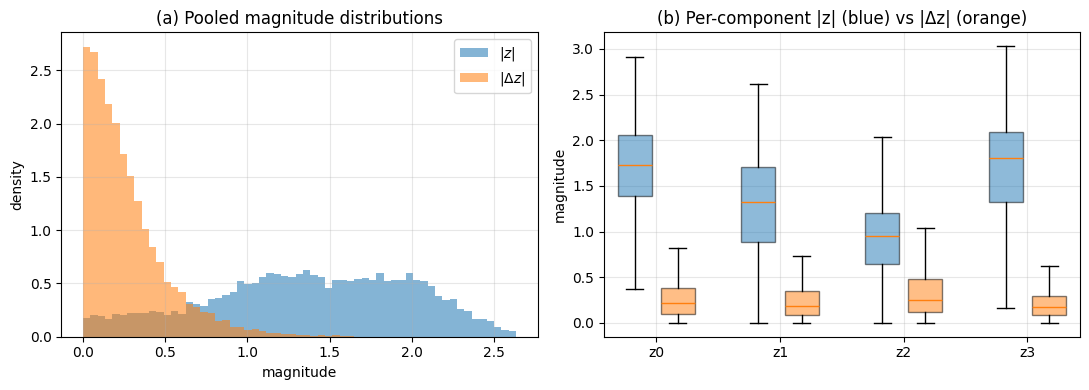

In [ ]:
"""
Cell 20b -- Check the size of latent values vs. latent changes

Measures, with actual numbers, how large the latent values are compared to how much they change from one year to the next. This supports the design choice in the next cell to predict the (small) change rather than the (larger) absolute value -- a choice that only makes sense if the change really is much smaller than the value, which this cell confirms.
"""

# ---- restrict |z| to training rows (drop the 1500-1700 holdout block) ----
in_hold = (years_window >= HOLDOUT_START) & (years_window <= HOLDOUT_END)
Z_tr = Z_full[~in_hold]            # (N_train, latentDim)
dZ   = delta_train                 # (N_train_pairs, latentDim)

# ---- per-component + pooled summary ----
def _row(name, A):
    print(f"{name:>10s}  mean={A.mean():7.3f}  std={A.std():7.3f}  "
          f"med={np.median(A):7.3f}  p5={np.percentile(A,5):7.3f}  "
          f"p95={np.percentile(A,95):7.3f}  max={A.max():7.3f}")

print(f"Training rows: {Z_tr.shape[0]}   one-step pairs: {dZ.shape[0]}\n")

print("Per-component |z_j|:")
for k in range(latentDim):
    _row(f"|z{k}|", np.abs(Z_tr[:, k]))

print("\nPer-component |Δz_j|:")
for k in range(latentDim):
    _row(f"|Δz{k}|", np.abs(dZ[:, k]))

abs_z, abs_dz = np.abs(Z_tr).flatten(), np.abs(dZ).flatten()
print("\nPooled across components:")
_row("|z|",  abs_z)
_row("|Δz|", abs_dz)

print(f"\nmean |Δz| / mean |z|     = {abs_dz.mean() / abs_z.mean():.4f}")
print(f"median |Δz| / median |z| = {np.median(abs_dz) / np.median(abs_z):.4f}")
print("(Residual form is well-conditioned when this ratio is << 1.)")

# ---- figure: pooled histogram + per-component boxplots ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

hi   = float(np.percentile(abs_z, 99.5))
bins = np.linspace(0, hi, 60)
axes[0].hist(abs_z,  bins=bins, alpha=0.55, density=True,
             label=r"$|z|$",        color="tab:blue")
axes[0].hist(abs_dz, bins=bins, alpha=0.55, density=True,
             label=r"$|\Delta z|$", color="tab:orange")
axes[0].set_xlabel("magnitude"); axes[0].set_ylabel("density")
axes[0].set_title("(a) Pooled magnitude distributions")
axes[0].legend(); axes[0].grid(alpha=0.3)

comp_z  = [np.abs(Z_tr[:, k]) for k in range(latentDim)]
comp_dz = [np.abs(dZ[:, k])   for k in range(latentDim)]
pos_z   = np.arange(latentDim) * 2 - 0.35
pos_dz  = np.arange(latentDim) * 2 + 0.35
bp1 = axes[1].boxplot(comp_z,  positions=pos_z,  widths=0.55,
                       patch_artist=True, showfliers=False)
bp2 = axes[1].boxplot(comp_dz, positions=pos_dz, widths=0.55,
                       patch_artist=True, showfliers=False)
for b in bp1['boxes']: b.set_facecolor("tab:blue");   b.set_alpha(0.5)
for b in bp2['boxes']: b.set_facecolor("tab:orange"); b.set_alpha(0.5)
axes[1].set_xticks(np.arange(latentDim) * 2)
axes[1].set_xticklabels([f"z{k}" for k in range(latentDim)])
axes[1].set_ylabel("magnitude")
axes[1].set_title("(b) Per-component |z| (blue) vs |Δz| (orange)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
"""
Cell 21 -- Define the latent dynamics network

Defines the network that predicts how the latent state evolves. Rather than predicting next year's state directly, it predicts the change between this year and next, given the current state and the forcing. This is an easier learning problem since the changes are much smaller than the values themselves, and during quiet periods the network can simply learn to output close to zero.
"""

torch.manual_seed(43)

u_dim = U_window.shape[1]   # = 2

dynNet = nn.Sequential(
    nn.Linear(latentDim + u_dim, hidden),
    nn.Tanh(),
    nn.Linear(hidden, hidden),
    nn.Tanh(),
    nn.Linear(hidden, latentDim),
).to(device)

# Initialize the final layer near zero so initial Delta predictions are
# small -- starts close to "stay put" and learns deltas from there
with torch.no_grad():
    dynNet[-1].weight.mul_(0.01)
    dynNet[-1].bias.zero_()

n_dyn = sum(p.numel() for p in dynNet.parameters())
print(f"dynNet: {n_dyn:,} parameters")
print(f"  latentDim = {latentDim}, u_dim = {u_dim}, hidden = {hidden}")

dynNet: 17,924 parameters
  latentDim = 4, u_dim = 2, hidden = 128


Training dynNet ...
  ep     1/5000  train=5.576e-01  val=2.436e-01
  ep   250/5000  train=2.652e-01  val=1.595e-01
  ep   500/5000  train=2.465e-01  val=1.593e-01
  ep   750/5000  train=2.961e-01  val=1.471e-01
  ep  1000/5000  train=2.648e-01  val=1.470e-01
  ep  1250/5000  train=2.763e-01  val=1.483e-01
  ep  1500/5000  train=2.736e-01  val=1.463e-01
  ep  1750/5000  train=2.461e-01  val=1.460e-01
  ep  2000/5000  train=3.021e-01  val=1.511e-01
  ep  2250/5000  train=2.593e-01  val=1.483e-01
  ep  2500/5000  train=2.602e-01  val=1.443e-01
  ep  2750/5000  train=2.575e-01  val=1.514e-01
  ep  3000/5000  train=2.308e-01  val=1.429e-01
  ep  3250/5000  train=2.417e-01  val=1.458e-01
  ep  3500/5000  train=2.599e-01  val=1.438e-01
  ep  3750/5000  train=2.811e-01  val=1.430e-01
  ep  4000/5000  train=2.216e-01  val=1.425e-01
  ep  4250/5000  train=2.599e-01  val=1.494e-01
  ep  4500/5000  train=2.479e-01  val=1.416e-01
  ep  4750/5000  train=2.360e-01  val=1.429e-01
  ep  5000/5000  tra

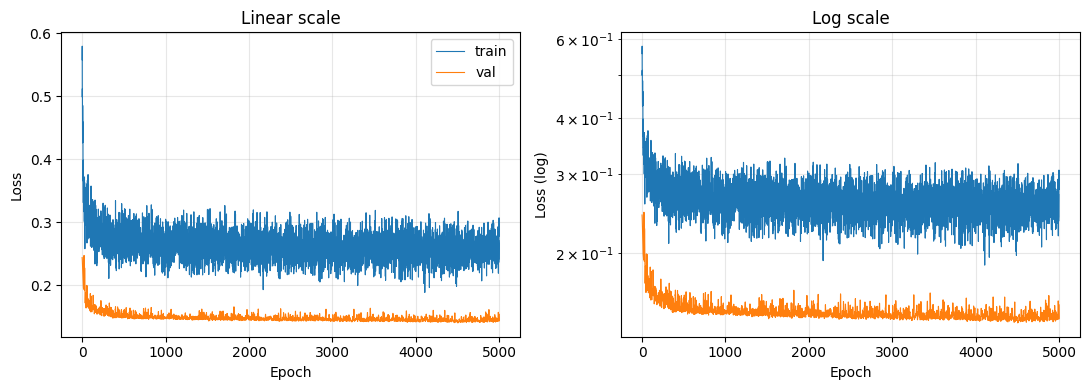


Final train loss: 2.781e-01
Final val   loss: 1.537e-01


In [ ]:
"""
Cell 22 -- Train the dynamics network

Trains the dynamics network on one-year-ahead predictions, with the autoencoder frozen (its weights aren't updated here). Gradients are clipped to keep training stable.
"""

dyn_epochs = 5000
dyn_lr     = 1e-3
dyn_bs     = 264
clip_norm  = 1.0

encNet.eval()
decNet.eval()
dynNet.train()

opt_dyn = Adam(dynNet.parameters(), lr=dyn_lr)

lossHist_dyn_tr  = np.zeros(dyn_epochs, dtype=np.float64)
lossHist_dyn_val = np.zeros(dyn_epochs, dtype=np.float64)

print("Training dynNet ...")
for ep in range(1, dyn_epochs + 1):
    # ---- Train ----
    idx = torch.randint(0, Z_t_tr.shape[0], (dyn_bs,), device=device)
    z   = Z_t_tr[idx]
    zp1 = Z_tp1_tr[idx]
    u   = U_t_tr[idx]

    delta_pred = dynNet(torch.cat([z, u], dim=1))
    z_pred = z + delta_pred
    loss_tr = torch.mean(torch.sum((z_pred - zp1)**2, dim=1))

    opt_dyn.zero_grad(set_to_none=True)
    loss_tr.backward()
    torch.nn.utils.clip_grad_norm_(dynNet.parameters(), clip_norm)
    opt_dyn.step()

    lossHist_dyn_tr[ep - 1] = loss_tr.item()

    # ---- Val ----
    with torch.no_grad():
        dynNet.eval()
        delta_val = dynNet(torch.cat([Z_t_val, U_t_val], dim=1))
        z_pred_val = Z_t_val + delta_val
        loss_val = torch.mean(torch.sum((z_pred_val - Z_tp1_val)**2, dim=1))
        lossHist_dyn_val[ep - 1] = loss_val.item()
        dynNet.train()

    if ep % 250 == 0 or ep == 1:
        print(f"  ep {ep:5d}/{dyn_epochs}  "
              f"train={loss_tr.item():.3e}  val={loss_val.item():.3e}")

dynNet.eval()

# ---- Loss curves ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(lossHist_dyn_tr,  lw=0.8, label="train", color="tab:blue")
axes[0].plot(lossHist_dyn_val, lw=0.8, label="val",   color="tab:orange")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[0].set_title("Linear scale"); axes[0].grid(alpha=0.3)
axes[1].semilogy(lossHist_dyn_tr,  lw=0.8, color="tab:blue")
axes[1].semilogy(lossHist_dyn_val, lw=0.8, color="tab:orange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss (log)")
axes[1].set_title("Log scale"); axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(f"{OUT_DIR_SEC}/Dyn_loss.png", dpi = 200, bbox_inches = "tight")
plt.show()

print(f"\nFinal train loss: {lossHist_dyn_tr [-1]:.3e}")
print(f"Final val   loss: {lossHist_dyn_val[-1]:.3e}")

In [ ]:
"""
Cell 23 -- Check one-step prediction quality

Checks how accurate the one-year-ahead predictions are, separately for each latent dimension, against the trivial baseline of 'predict no change at all'. A useful model should clearly beat that baseline -- if it doesn't, the year-to-year dynamics are too slow or noisy for the network to have learned anything useful.
"""

with torch.no_grad():
    # All-pair predictions across the full window
    z_t_all   = torch.from_numpy(Z_full[:-1]).to(device)
    z_tp1_all = torch.from_numpy(Z_full[1:]).to(device)
    u_t_all   = torch.from_numpy(U_window[:-1]).to(device)
    delta_all = dynNet(torch.cat([z_t_all, u_t_all], dim=1)).cpu().numpy()
    z_pred_all = Z_full[:-1] + delta_all

z_truth_all = Z_full[1:]
err_dyn_all = z_pred_all - z_truth_all
err_baseline_all = Z_full[:-1] - z_truth_all   # "no-change" baseline

# Split by train/val masks
def per_dim_rmse(err, mask):
    return np.sqrt(np.mean(err[mask]**2, axis=0))

rmse_dyn_tr   = per_dim_rmse(err_dyn_all,      train_pair_mask)
rmse_dyn_val  = per_dim_rmse(err_dyn_all,      val_pair_mask)
rmse_base_tr  = per_dim_rmse(err_baseline_all, train_pair_mask)
rmse_base_val = per_dim_rmse(err_baseline_all, val_pair_mask)

print(f"{'dim':>5s}  {'rmse_tr':>9s}  {'rmse_val':>9s}  "
      f"{'base_tr':>9s}  {'base_val':>9s}  {'skill_tr':>9s}  {'skill_val':>9s}")
print("-" * 75)
for k in range(latentDim):
    skill_tr  = 1.0 - rmse_dyn_tr [k] / rmse_base_tr [k]
    skill_val = 1.0 - rmse_dyn_val[k] / rmse_base_val[k]
    print(f"  z{k}  {rmse_dyn_tr [k]:9.4f}  {rmse_dyn_val[k]:9.4f}  "
          f"{rmse_base_tr[k]:9.4f}  {rmse_base_val[k]:9.4f}  "
          f"{skill_tr:9.3f}  {skill_val:9.3f}")
print("\nskill = 1 - rmse_dyn / rmse_baseline   (higher is better; >0 means dynNet beats persistence)")

  dim    rmse_tr   rmse_val    base_tr   base_val   skill_tr  skill_val
---------------------------------------------------------------------------
  z0     0.2512     0.2003     0.3594     0.2447      0.301      0.181
  z1     0.2417     0.1787     0.3343     0.2128      0.277      0.160
  z2     0.3167     0.2248     0.4588     0.2770      0.310      0.188
  z3     0.1787     0.1762     0.2602     0.2486      0.313      0.291

skill = 1 - rmse_dyn / rmse_baseline   (higher is better; >0 means dynNet beats persistence)


Holdout indices in years_window: [1499, 1699]
Multi-step refinement of dynNet ...
  ep     1/2500  K= 5  train=2.716e-01  val=1.705e-01
  ep   250/2500  K= 5  train=2.808e-01  val=1.567e-01
  ep   500/2500  K=10  train=2.860e-01  val=1.595e-01
  ep   750/2500  K=20  train=2.862e-01  val=1.933e-01
  ep  1000/2500  K=30  train=2.771e-01  val=1.782e-01
  ep  1250/2500  K=30  train=2.804e-01  val=1.619e-01
  ep  1500/2500  K=40  train=2.963e-01  val=1.631e-01
  ep  1750/2500  K=40  train=2.857e-01  val=2.177e-01
  ep  2000/2500  K=40  train=2.811e-01  val=1.745e-01
  ep  2250/2500  K=40  train=2.813e-01  val=2.212e-01
  ep  2500/2500  K=40  train=2.783e-01  val=1.634e-01
Done.


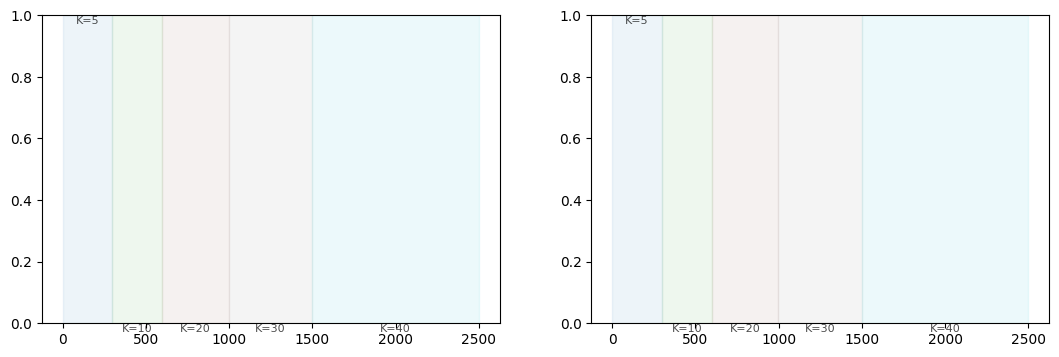

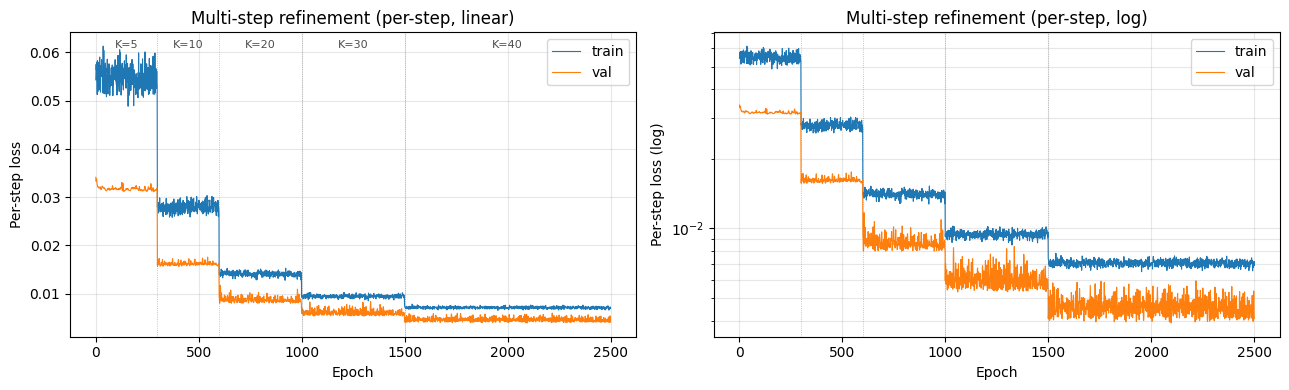


Per-step loss summary:
  Initial K=5  : train=5.4327e-02  val=3.4103e-02
  Final   K=40 : train=6.9572e-03  val=4.0854e-03
  Reduction    : train=7.8x  val=8.3x


In [ ]:
"""
Cell 25 -- Multi-step refinement of the dynamics network

One-step training alone wasn't enough: rolled forward for many years, the model's predicted collapse happened hundreds of years too late, or not at all. This fixes it by fine-tuning the already one-step-trained dynamics network on rollouts of increasing length (5 up to 40 years), forcing it to get the cumulative, long-term response to the forcing right, not just the next single step. The autoencoder stays frozen throughout.
"""

# ---- Holdout boundary indices in years_window ----
hold_idx_start = int(np.where(years_window == HOLDOUT_START)[0][0])
hold_idx_end   = int(np.where(years_window == HOLDOUT_END  )[0][0])
print(f"Holdout indices in years_window: [{hold_idx_start}, {hold_idx_end}]")

def valid_starts_for_K(K, in_holdout=False):
    """
    Return array of valid t0 indices such that {t0, t0+1, ..., t0+K} all
    fall in either the training set (in_holdout=False) or the holdout
    block (in_holdout=True).
    """
    if in_holdout:
        # Single block [hold_idx_start, hold_idx_end]
        return np.arange(hold_idx_start, hold_idx_end - K + 1)
    else:
        # Two blocks: [0, hold_idx_start - K], [hold_idx_end + 1, N - 1 - K]
        b1 = np.arange(0, hold_idx_start - K)
        b2 = np.arange(hold_idx_end + 1, N - K)
        return np.concatenate([b1, b2])

# ---- Pre-load encoded Z and forcing onto device once ----
Z_full_t   = torch.from_numpy(Z_full  ).to(device)
U_window_t = torch.from_numpy(U_window).to(device)

# ---- Hyperparameters ----
ms_epochs   = 2500
ms_lr       = 3e-4         # lower than one-step phase: this is fine-tuning
ms_bs       = 264
clip_norm   = 1.0

# K curriculum: K grows in stages
def K_for_epoch(ep):
    if   ep <  300:  return 5
    elif ep <  600:  return 10
    elif ep < 1000:  return 20
    elif ep < 1500:  return 30
    else:            return 40

# ---- Optimizer ----
encNet.eval(); decNet.eval()
dynNet.train()
opt_ms = Adam(dynNet.parameters(), lr=ms_lr)

lossHist_ms_tr  = np.zeros(ms_epochs, dtype=np.float64)
lossHist_ms_val = np.zeros(ms_epochs, dtype=np.float64)
K_hist          = np.zeros(ms_epochs, dtype=np.int32)

print("Multi-step refinement of dynNet ...")
for ep in range(1, ms_epochs + 1):
    K = K_for_epoch(ep)
    K_hist[ep - 1] = K

    # ---- Sample training starts ----
    starts_tr = valid_starts_for_K(K, in_holdout=False)
    idx = starts_tr[np.random.randint(0, len(starts_tr), size=ms_bs)]
    idx_t = torch.from_numpy(idx).to(device)

    # Initial latent state (B, L) and forcing trajectory (B, K, u_dim)
    z = Z_full_t[idx_t]                                              # (B, L)
    u_seq = torch.stack([U_window_t[idx_t + k] for k in range(K)],
                        dim=1)                                       # (B, K, u_dim)
    z_true = torch.stack([Z_full_t[idx_t + k + 1] for k in range(K)],
                         dim=1)                                      # (B, K, L)

    # K-step free rollout
    preds = []
    for k in range(K):
        z = z + dynNet(torch.cat([z, u_seq[:, k, :]], dim=1))
        preds.append(z)
    z_pred = torch.stack(preds, dim=1)                               # (B, K, L)

    loss_tr = torch.mean(torch.sum((z_pred - z_true)**2, dim=2))

    opt_ms.zero_grad(set_to_none=True)
    loss_tr.backward()
    torch.nn.utils.clip_grad_norm_(dynNet.parameters(), clip_norm)
    opt_ms.step()

    lossHist_ms_tr[ep - 1] = loss_tr.item()

    # ---- Validation: same K, holdout block ----
    starts_val = valid_starts_for_K(K, in_holdout=True)
    if len(starts_val) > 0:
        with torch.no_grad():
            dynNet.eval()
            n_val = min(len(starts_val), ms_bs)
            idx_v = torch.from_numpy(starts_val[:n_val]).to(device)
            z_v   = Z_full_t[idx_v]
            u_v   = torch.stack([U_window_t[idx_v + k] for k in range(K)], dim=1)
            zt_v  = torch.stack([Z_full_t  [idx_v + k + 1] for k in range(K)], dim=1)
            preds_v = []
            for k in range(K):
                z_v = z_v + dynNet(torch.cat([z_v, u_v[:, k, :]], dim=1))
                preds_v.append(z_v)
            zp_v = torch.stack(preds_v, dim=1)
            lossHist_ms_val[ep - 1] = torch.mean(
                torch.sum((zp_v - zt_v)**2, dim=2)).item()
            dynNet.train()
    else:
        lossHist_ms_val[ep - 1] = np.nan

    if ep % 250 == 0 or ep == 1:
        print(f"  ep {ep:5d}/{ms_epochs}  K={K:2d}  "
              f"train={loss_tr.item():.3e}  val={lossHist_ms_val[ep-1]:.3e}")

dynNet.eval()
print("Done.")

# ---- Loss curves with K-stage shading ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax in axes:
    # Shade K stages
    boundaries = [0]
    last_K = K_hist[0]
    for i, K in enumerate(K_hist):
        if K != last_K:
            boundaries.append(i)
            last_K = K
    boundaries.append(ms_epochs)
    colors = plt.cm.tab10(np.linspace(0, 1, len(boundaries) - 1))
    for j in range(len(boundaries) - 1):
        ax.axvspan(boundaries[j], boundaries[j+1],
                   alpha=0.08, color=colors[j])
        mid = (boundaries[j] + boundaries[j+1]) // 2
        ax.text(mid, ax.get_ylim()[1] if j == 0 else 0,
                f"K={K_hist[boundaries[j]]}", fontsize=8,
                ha="center", va="top", alpha=0.7)

# ---- Loss curves (per-step normalized so K transitions don't dominate) ----
per_step_tr  = lossHist_ms_tr  / np.maximum(K_hist, 1)
per_step_val = lossHist_ms_val / np.maximum(K_hist, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Find K transition points for vertical guides
trans_eps = [0]
for i in range(1, ms_epochs):
    if K_hist[i] != K_hist[i - 1]:
        trans_eps.append(i)

# Linear plot
axes[0].plot(per_step_tr,  lw=0.8, color="tab:blue",   label="train")
axes[0].plot(per_step_val, lw=0.8, color="tab:orange", label="val")
for t in trans_eps[1:]:
    axes[0].axvline(t, color="grey", ls=":", lw=0.6, alpha=0.6)
for t1, t2 in zip(trans_eps, trans_eps[1:] + [ms_epochs]):
    K_here = K_hist[t1]
    axes[0].text((t1 + t2) / 2, axes[0].get_ylim()[1] * 0.95,
                 f"K={K_here}", fontsize=8, ha="center", alpha=0.7)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Per-step loss")
axes[0].set_title("Multi-step refinement (per-step, linear)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Log plot
axes[1].semilogy(per_step_tr,  lw=0.8, color="tab:blue",   label="train")
axes[1].semilogy(per_step_val, lw=0.8, color="tab:orange", label="val")
for t in trans_eps[1:]:
    axes[1].axvline(t, color="grey", ls=":", lw=0.6, alpha=0.6)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Per-step loss (log)")
axes[1].set_title("Multi-step refinement (per-step, log)")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

print(f"\nPer-step loss summary:")
print(f"  Initial K=5  : train={per_step_tr[0]:.4e}  val={per_step_val[0]:.4e}")
print(f"  Final   K={K_hist[-1]:2d} : train={per_step_tr[-1]:.4e}  "
      f"val={per_step_val[-1]:.4e}")
print(f"  Reduction    : train={per_step_tr[0]/per_step_tr[-1]:.1f}x  "
      f"val={per_step_val[0]/per_step_val[-1]:.1f}x")

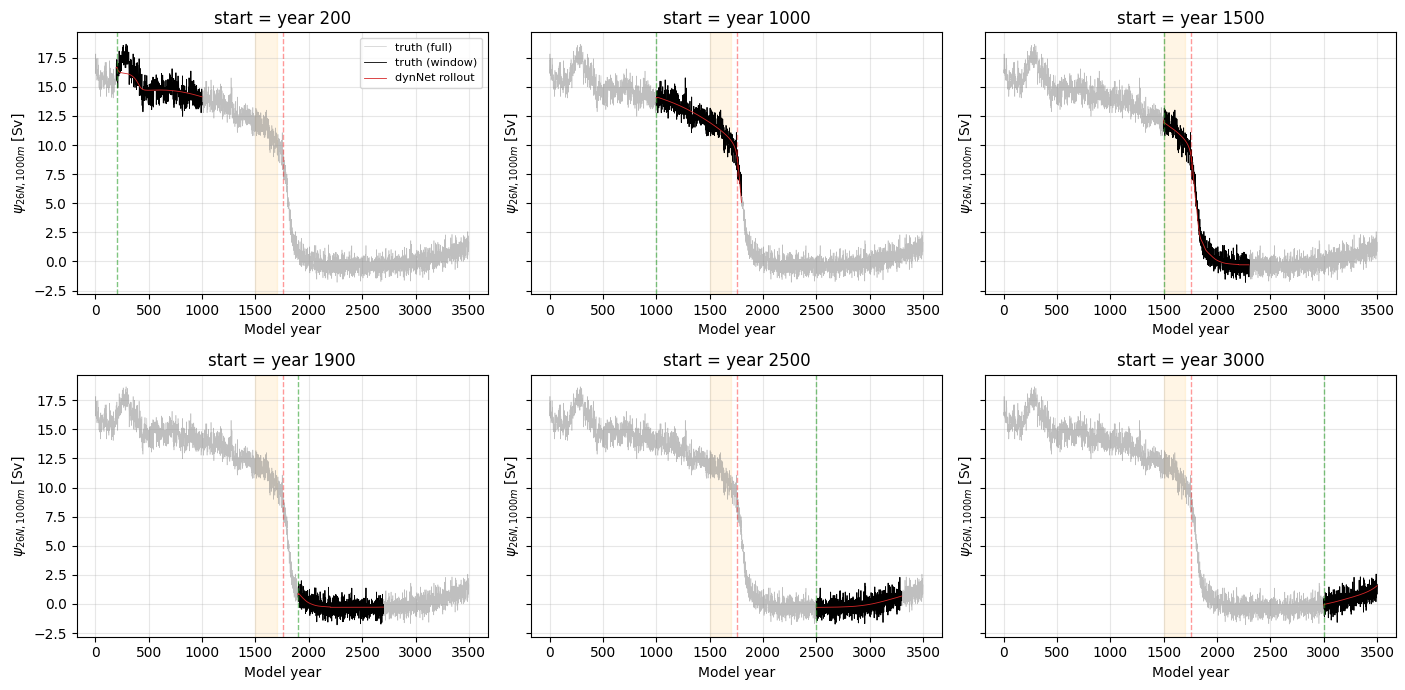


Rollout RMSE on ψ_26N (Sv) at horizons 50, 200, 800 years:
    t0       h=50      h=200      h=800    final ψ pred    final ψ true
---------------------------------------------------------------------------
   200      0.895      1.052      0.793          14.134          13.651
  1000      0.601      0.615      0.632           5.071           6.178
  1500      0.597      0.592      0.595          -0.294          -0.282
  1900      0.576      0.527      0.545          -0.273          -0.216
  2500      0.562      0.522      0.558           0.675           1.061
  3000      0.530      0.594        nan           1.568           1.640


In [ ]:
"""
Cell 24 -- Validate multi-step rollouts (key check)

This is the most important check in the whole pipeline: one-step accuracy can look great while long rollouts still drift to the wrong state entirely. Starting from several different years, the model is run forward using only its own predictions (never the true data) and compared to the real CESM trajectory. A good result means rollouts starting in the 'on' state stay close to truth for a long time, a rollout starting just before the real collapse reproduces it at roughly the right time and then stays collapsed, and rollouts starting in the collapsed state stay collapsed rather than drifting back toward an intermediate, unphysical state.
"""

H = 800  # rollout horizon, years
start_years = [200, 1000, 1500, 1900, 2500, 3000]

psi_idx = STATE_NAMES.index("psi_26N_1000m")

def rollout(t0_year, horizon):
    """
    Roll dynNet from year t0 for `horizon` steps.
    Returns:
      years_out    (horizon+1,)
      psi_pred     (horizon+1,)  decoded ψ_26N
      psi_truth    (horizon+1,)  CESM truth ψ_26N
    """
    t0_idx = int(np.where(years_window == t0_year)[0][0])
    h = min(horizon, N - 1 - t0_idx)

    with torch.no_grad():
        z = torch.from_numpy(Z_full[t0_idx:t0_idx+1]).to(device)  # (1, L)
        z_traj = [z.clone()]

        for s in range(h):
            u = torch.from_numpy(U_window[t0_idx + s:t0_idx + s + 1]).to(device)
            z = z + dynNet(torch.cat([z, u], dim=1))
            z_traj.append(z.clone())

        Z_traj = torch.cat(z_traj, dim=0)             # (h+1, L)
        Xrec_n = decNet(Z_traj).cpu().numpy()         # (h+1, 10)

    Xrec = Xrec_n * sigma_train + mu_train

    yrs   = years_window[t0_idx:t0_idx + h + 1]
    psi_p = Xrec[:, psi_idx]
    psi_t = X_window[t0_idx:t0_idx + h + 1, psi_idx]
    return yrs, psi_p, psi_t
    b
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
axes = axes.flatten()

for ax, t0 in zip(axes, start_years):
    yrs, psi_p, psi_t = rollout(t0, H)

    ax.plot(years_window, X_window[:, psi_idx], lw=0.4, color="grey",
            alpha=0.5, label="truth (full)")
    ax.plot(yrs, psi_t, lw=0.6, color="k", label="truth (window)")
    ax.plot(yrs, psi_p, lw=0.6, color="tab:red", label="dynNet rollout")

    ax.axvline(t0,           color="tab:green", ls="--", lw=1, alpha=0.6)
    ax.axvline(TIPPING_YEAR, color="red",       ls="--", lw=1, alpha=0.4)
    ax.axvspan(HOLDOUT_START, HOLDOUT_END, color="orange", alpha=0.1)

    ax.set_title(f"start = year {t0}")
    ax.set_xlabel("Model year")
    ax.set_ylabel(r"$\psi_{26N,1000m}$ [Sv]")
    ax.grid(alpha=0.3)

    if t0 == start_years[0]:
        ax.legend(loc="best", fontsize=8)

fig.tight_layout()
fig.savefig(f"{OUT_DIR_SEC}/Dyn_rollouts.png", dpi=200, bbox_inches="tight")
plt.show()

# ---- Quantitative rollout error per start year ----
print(f"\nRollout RMSE on ψ_26N (Sv) at horizons 50, 200, 800 years:")
print(f"{'t0':>6s}  {'h=50':>9s}  {'h=200':>9s}  {'h=800':>9s}  {'final ψ pred':>14s}  {'final ψ true':>14s}")
print("-" * 75)
for t0 in start_years:
    yrs, psi_p, psi_t = rollout(t0, H)
    h_avail = len(yrs) - 1
    def rmse_at(h):
        if h_avail < h: return np.nan
        return np.sqrt(np.mean((psi_p[:h+1] - psi_t[:h+1])**2))
    print(f"  {t0:4d}  {rmse_at(50):9.3f}  {rmse_at(200):9.3f}  "
          f"{rmse_at(800):9.3f}  {psi_p[-1]:14.3f}  {psi_t[-1]:14.3f}")

## 6. Data Assimilation: the Particle Filter

A particle filter combines the trained dynamics model with noisy synthetic observations to track the AMOC state over time. This section defines the filter, validates it thoroughly on a stable period, tunes its settings, and explores which variables are most useful to observe.


In [ ]:
"""
Cell 26 -- Particle filter in latent space

Defines a particle filter that estimates the hidden latent state over time by combining the trained dynamics model with noisy observations, in the same style used for the Boussinesq model. Each particle is a candidate latent state; it's stepped forward with the dynamics network plus some random process noise, optionally nudged toward the observations using an ensemble-Kalman-style correction, and then its weight is updated based on how well its decoded state matches the actual observation. Two sources of uncertainty feed into this: how confident the one-step dynamics predictions are, and how noisy the observations themselves are (including the autoencoder's own reconstruction error).
"""

import numpy as np
import torch


# ----------------------------------------------------------------------------
# Sanity checks
# ----------------------------------------------------------------------------
assert len(STATE_NAMES) == physical_dimension, (
    f"len(STATE_NAMES)={len(STATE_NAMES)} but physical_dimension={physical_dimension}"
)

assert X_window.shape[1] == physical_dimension, (
    f"X_window has {X_window.shape[1]} variables but physical_dimension={physical_dimension}"
)


# ----------------------------------------------------------------------------
# 1. Calibrate Q from stationary one-step latent residuals
# ----------------------------------------------------------------------------
# Use pairs t -> t+1 where both t and t+1 are inside the stationary window.
# This avoids mixing the ramp/transition model error into the latent process noise.
# ----------------------------------------------------------------------------

stat_mask = years_window <= STATIONARY_END
stat_idx = np.where(stat_mask)[0]

# Valid stationary pairs: both t and t+1 must be stationary.
stat_pair_idx = np.where(stat_mask[:-1] & stat_mask[1:])[0]

with torch.no_grad():
    z_stat = torch.from_numpy(
        Z_full[stat_pair_idx].astype(np.float32)
    ).to(device)

    z_stat_p = torch.from_numpy(
        Z_full[stat_pair_idx + 1].astype(np.float32)
    ).to(device)

    u_stat = torch.from_numpy(
        U_window[stat_pair_idx].astype(np.float32)
    ).to(device)

    delta_pred_stat = dynNet(
        torch.cat([z_stat, u_stat], dim=1)
    ).cpu().numpy()

z_pred_stat = Z_full[stat_pair_idx] + delta_pred_stat
resid_stat = Z_full[stat_pair_idx + 1] - z_pred_stat

Q_diag = resid_stat.var(axis=0).astype(np.float32)
Q_diag = np.maximum(Q_diag, 1e-12).astype(np.float32)

sigma_proc = np.sqrt(Q_diag).astype(np.float32)

print("Process noise Q (stationary one-step latent residuals):")
for k in range(len(sigma_proc)):
    print(f"  z{k}: sigma = {sigma_proc[k]:.4f}  (var = {Q_diag[k]:.4e})")


# ----------------------------------------------------------------------------
# 2. Calibrate R from stationary observation variability
# ----------------------------------------------------------------------------
# Boussinesq-style observation noise:
#
#   sigma_obs_truth[j] = alpha * std_ON(x_j)
#
# Filter-side noise adds AE reconstruction uncertainty in quadrature:
#
#   sigma_obs_filter[j] = sqrt(sigma_obs_truth[j]^2 + recon_rmse[j]^2)
# ----------------------------------------------------------------------------

ALPHA_OBS = 0.05

sigma_obs_truth = (
    ALPHA_OBS * X_window[stat_idx].std(axis=0)
).astype(np.float32)

sigma_obs_truth = np.maximum(sigma_obs_truth, 1e-12).astype(np.float32)

with torch.no_grad():
    stat_idx_t = torch.as_tensor(
        stat_idx,
        dtype=torch.long,
        device=XN_full_t.device
    )

    Xrec_stat_n = decNet(
        encNet(XN_full_t[stat_idx_t])
    ).cpu().numpy()

Xrec_stat = Xrec_stat_n * sigma_train + mu_train

recon_rmse = np.sqrt(
    np.mean(
        (Xrec_stat - X_window[stat_idx]) ** 2,
        axis=0
    )
).astype(np.float32)

sigma_obs_filter = np.sqrt(
    sigma_obs_truth ** 2 + recon_rmse ** 2
).astype(np.float32)

sigma_obs_filter = np.maximum(sigma_obs_filter, 1e-12).astype(np.float32)

print(f"\nObservation noise budget per variable (alpha={ALPHA_OBS}):")
print(f"{'variable':15s}  {'sig_truth':>11s}  {'recon_rmse':>11s}  {'sig_filter':>11s}")
print("-" * 56)

for j, name in enumerate(STATE_NAMES):
    print(
        f"{name:15s}  "
        f"{sigma_obs_truth[j]:11.4e}  "
        f"{recon_rmse[j]:11.4e}  "
        f"{sigma_obs_filter[j]:11.4e}"
    )


# ----------------------------------------------------------------------------
# 3. Helper functions
# ----------------------------------------------------------------------------

def _logsumexp_np(a):
    """
    Stable logsumexp for a 1D NumPy array.
    """
    a = np.asarray(a, dtype=np.float64)
    m = np.max(a)

    if not np.isfinite(m):
        return -np.inf

    return m + np.log(np.sum(np.exp(a - m)))


def systematic_resample(w, rng):
    """
    Systematic resampling.

    Parameters
    ----------
    w : np.ndarray, shape (Npart,)
        Normalized particle weights.

    rng : np.random.Generator

    Returns
    -------
    idx : np.ndarray, shape (Npart,)
        Resampled particle indices.
    """
    Npart = len(w)

    positions = (rng.random() + np.arange(Npart)) / Npart

    cumw = np.cumsum(w)
    cumw[-1] = 1.0

    return np.searchsorted(cumw, positions)


def maybe_rejuvenate_np(
    z,
    z_std_min=1e-2,
    rejuv_z=5e-2,
    clip_value=10.0,
    rng=None
):
    """
    Small collapse guard in latent space.

    This is used after forecast/nudge only if the latent ensemble has become
    very narrow.
    """
    if rng is None:
        rng = np.random.default_rng()

    z = np.asarray(z, dtype=np.float32)

    if np.mean(np.std(z, axis=0)) < z_std_min:
        z = z + rejuv_z * rng.normal(size=z.shape).astype(np.float32)

    z = np.clip(z, -clip_value, clip_value).astype(np.float32)

    return z


def boussinesq_resample_rejuvenation_np(
    z,
    rejuv_scale=0.02,
    rejuv_floor=0.05,
    clip_value=10.0,
    rng=None
):
    """
    Boussinesq-style rejuvenation after resampling.

    Boussinesq logic:
        Zp <- Zp + (rejuv_scale * spread + rejuv_floor) * N(0, I)

    For CESM row-major particles:
        z shape = (Npart, L)
    """
    if rng is None:
        rng = np.random.default_rng()

    z = np.asarray(z, dtype=np.float32)

    scale = z.std(axis=0, keepdims=True).astype(np.float32) + 1e-6

    noise_amp = rejuv_scale * scale + rejuv_floor

    z = z + noise_amp * rng.normal(size=z.shape).astype(np.float32)
    z = np.clip(z, -clip_value, clip_value).astype(np.float32)

    return z


def decode_particles_raw(z, batch_size=4096):
    """
    Decode latent particles to the full physical diagnostic state.

    Parameters
    ----------
    z : np.ndarray, shape (Npart, L)

    Returns
    -------
    x_phys : np.ndarray, shape (Npart, physical_dimension)
        Decoded state in physical units.
    """
    z = np.asarray(z, dtype=np.float32)

    out = []

    with torch.no_grad():
        for a in range(0, z.shape[0], batch_size):
            b = min(a + batch_size, z.shape[0])

            z_torch = torch.from_numpy(
                z[a:b].astype(np.float32)
            ).to(device)

            xrec_n = decNet(z_torch).cpu().numpy()
            xrec = xrec_n * sigma_train + mu_train

            out.append(xrec.astype(np.float32))

    return np.vstack(out).astype(np.float32)


def enkf_proposal_cesm(
    z,
    y_pred,
    y_obs,
    w,
    sigma_obs,
    nudge_gamma=0.10,
    nudge_alpha=1.0,
    jitter=1e-5,
    clip_value=10.0,
    rng=None,
):
    """
    Boussinesq-style EnKF guided proposal adapted to CESM.

    Boussinesq convention:
        Zp      shape: (latentDim, Npart)
        yhat_t  shape: (n_obs, Npart)

    CESM convention here:
        z       shape: (Npart, latentDim)
        y_pred  shape: (Npart, n_obs)

    Update:
        K = P_zy (P_yy + R/gamma)^(-1)

        z_i <- z_i + alpha K (y_obs + eps_i - y_pred_i)

    with:
        eps_i ~ N(0, R/gamma)
    """
    if rng is None:
        rng = np.random.default_rng()

    if nudge_gamma <= 0:
        return z.astype(np.float32)

    z = np.asarray(z, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    y_obs = np.asarray(y_obs, dtype=np.float64).reshape(1, -1)
    sigma_obs = np.asarray(sigma_obs, dtype=np.float64).reshape(-1)

    Npart, L = z.shape
    n_obs = y_pred.shape[1]

    assert y_obs.shape[1] == n_obs, (
        f"y_obs length {y_obs.shape[1]} does not match y_pred n_obs={n_obs}"
    )

    assert sigma_obs.size == n_obs, (
        f"sigma_obs length {sigma_obs.size} does not match n_obs={n_obs}"
    )

    w = np.asarray(w, dtype=np.float64)
    w = w / (w.sum() + 1e-300)

    # Weighted means
    z_bar = np.sum(w[:, None] * z, axis=0, keepdims=True)
    y_bar = np.sum(w[:, None] * y_pred, axis=0, keepdims=True)

    # Anomalies
    Zc = z - z_bar
    Yc = y_pred - y_bar

    # Weighted covariances
    Pzy = (Zc * w[:, None]).T @ Yc
    Pyy = (Yc * w[:, None]).T @ Yc

    # Symmetrize observation covariance.
    Pyy = 0.5 * (Pyy + Pyy.T)

    # Boussinesq convention:
    # R is divided by gamma in the proposal covariance.
    R_over_gamma = np.diag((sigma_obs ** 2) / nudge_gamma + 1e-12)

    A = Pyy + R_over_gamma

    ridge = jitter + 1e-6 * (np.abs(np.trace(A)) / (n_obs + 1e-12))
    A = A + ridge * np.eye(n_obs)

    try:
        # K = Pzy @ inv(A), written as a solve for numerical stability.
        K = np.linalg.solve(A, Pzy.T).T
    except np.linalg.LinAlgError:
        K = (np.linalg.pinv(A) @ Pzy.T).T

    # Perturbed observations:
    # eps_i ~ N(0, R/gamma)
    y_pert = y_obs + (
        sigma_obs[None, :] / np.sqrt(nudge_gamma)
    ) * rng.normal(size=(Npart, n_obs))

    innov = y_pert - y_pred

    z_new = z + nudge_alpha * (innov @ K.T)

    z_new = np.clip(z_new, -clip_value, clip_value).astype(np.float32)

    # Small collapse guard.
    z_new = maybe_rejuvenate_np(
        z_new,
        z_std_min=1e-2,
        rejuv_z=5e-2,
        clip_value=clip_value,
        rng=rng
    )

    return z_new.astype(np.float32)

def reseed_collapsed_particles_np(
    z, w, x_pred, y_pred,
    obs_idx_arr,
    sigma_obs,
    spread_threshold=0.02,
    rng=None,
    clip_value=10.0,
):
    """
    Particle reseeding, faithful to the Boussinesq when the observation cloud has
    collapsed. Rarely triggers in CESM (predictive cloud tends to be too wide,
    not too narrow), but kept for parity with the Boussinesq pipeline.

    Trigger: min_j std_w(y_pred[:, j]) / sigma_obs[j] < spread_threshold.
    Action : draw n_reseed ≈ Npart//5 fresh physical states from a Gaussian
             centred on the current weighted-mean physical state, scaled by
             0.5 × stationary std, encode them, and overwrite that fraction
             of particles in z.
    """
    if rng is None:
        rng = np.random.default_rng()

    Npart, L = z.shape

    # Weighted std of decoded prior obs across particles.
    y_mean = np.sum(w[:, None] * y_pred, axis=0, keepdims=True)
    y_var  = np.sum(w[:, None] * (y_pred - y_mean) ** 2, axis=0)
    y_std  = np.sqrt(np.maximum(y_var, 0.0))

    spread_ratio = y_std / (sigma_obs + 1e-12)
    if spread_ratio.min() >= spread_threshold:
        return z, False

    # Posterior-mean physical state.
    x_mean = np.sum(w[:, None] * x_pred, axis=0)            # (physical_dim,)

    # 0.5 × stationary std as the reseed scale.
    x_std_prior = (X_window[:STATIONARY_END]
                   .std(axis=0)
                   .astype(np.float32))

    n_reseed = max(Npart // 5, 10)
    reseed_idx = rng.choice(Npart, size=n_reseed, replace=False)

    x_new = (x_mean[None, :]
             + 0.5 * x_std_prior[None, :]
             * rng.normal(size=(n_reseed, physical_dimension))
             ).astype(np.float32)

    # Encode using train-set normalization, encNet (both globals).
    x_new_norm = ((x_new - mu_train) / sigma_train).astype(np.float32)

    with torch.no_grad():
        z_new = encNet(
            torch.from_numpy(x_new_norm).to(device)
        ).cpu().numpy().astype(np.float32)

    z[reseed_idx] = z_new
    z = np.clip(z, -clip_value, clip_value).astype(np.float32)
    return z, True

# ----------------------------------------------------------------------------
# 4. Bootstrap / EnKF-guided PF
# ----------------------------------------------------------------------------

def run_bootstrap_pf(
    obs_idx,              # indices into STATE_NAMES
    Y_obs,                # (T, n_obs) selected obs OR (T, physical_dimension)
    U_seq,                # (T, u_dim), (T-1, u_dim), or 1D forcing
    z0_particles,         # (Npart, L)
    Q_diag,               # (L,)
    sigma_obs,            # (n_obs,) or full (physical_dimension,)
    ess_thresh=0.5,
    seed=0,
    save_history=True,

    # Boussinesq-style EnKF-guided proposal knobs
    guided_prop=False,
    nudge_gamma=0.10,
    nudge_alpha=1.0,
    jitter=1e-5,

    # Boussinesq-style model-spread likelihood inflation
    # Literal Boussinesq-style setting: sigma_model_frac=0.1
    # Exact bootstrap likelihood:       sigma_model_frac=0.0
    # Predictive-likelihood diagnostic: sigma_model_frac=1.0
    sigma_model_frac=0.1,

    # Rejuvenation after resampling
    rejuv_after_resample=True,
    rejuv_scale=0.02,
    rejuv_floor=0.05,

    # Latent clipping
    # Latent clipping
    clip_value=10.0,

    # Boussinesq-style adaptive assimilation: skip the weight update if
    # the filter is already unhealthy (ESS_pre too low) or it just assimilated.
    # This is the safeguard whose absence explains the 100% resample fraction
    # and ESS_min ≈ 1 in the stationary CELL 29 result.
    # To recover the old non-adaptive behaviour: ess_skip_frac=0.0, min_assimilation_gap=1.

    ess_skip_frac=0.3,
    min_assimilation_gap=3,

    # Boussinesq-style reseed when obs spread collapses below σ_obs.
    # Rarely triggers in CESM, but kept for parity with run_pf_once.

    reseed_enabled=True,
    reseed_spread_threshold=0.02,
):
    """
    Latent-space PF with optional Boussinesq-style EnKF guided proposal.

    Forecast convention:
        t = 0:
            use initialized particles directly and assimilate Y_obs[0]

        t > 0:
            propagate from t-1 to t using U_seq[t-1]

    Returns
    -------
    dict with:
        Z_post_hist
        Z_pred_hist
        W_post_hist
        ESS_hist
        logL_hist
        n_resample
        nudge_norm_hist
        sig_eff_hist
        y_var_hist
    """
    rng = np.random.default_rng(seed)

    obs_idx_arr = np.asarray(obs_idx, dtype=np.int64)
    n_obs = len(obs_idx_arr)

    # Allow either selected Y_obs or full-state Y_obs.
    Y_obs_arr = np.asarray(Y_obs, dtype=np.float32)

    if Y_obs_arr.ndim == 1:
        Y_obs_arr = Y_obs_arr[:, None]

    if Y_obs_arr.shape[1] == physical_dimension:
        Y_obs_local = Y_obs_arr[:, obs_idx_arr]
    else:
        assert Y_obs_arr.shape[1] == n_obs, (
            f"Y_obs has {Y_obs_arr.shape[1]} columns, but obs_idx has "
            f"{n_obs}. Pass selected observations with shape (T, n_obs), "
            f"or full observations with shape (T, physical_dimension)."
        )
        Y_obs_local = Y_obs_arr

    # Allow either selected sigma_obs or full-state sigma_obs.
    sigma_obs = np.asarray(sigma_obs, dtype=np.float32)

    if sigma_obs.size == physical_dimension:
        sigma_obs = sigma_obs[obs_idx_arr]

    assert sigma_obs.size == n_obs, (
        f"sigma_obs has length {sigma_obs.size}, but obs_idx has length "
        f"{n_obs}. Pass sigma_obs_filter[obs_idx], or the full "
        f"sigma_obs_filter vector."
    )

    sigma_obs = np.maximum(sigma_obs, 1e-12).astype(np.float32)

    Q_diag = np.asarray(Q_diag, dtype=np.float32)
    Q_diag = np.maximum(Q_diag, 1e-12).astype(np.float32)

    sigma_proc_local = np.sqrt(Q_diag).astype(np.float32)

    z = z0_particles.copy().astype(np.float32)
    z = np.clip(z, -clip_value, clip_value).astype(np.float32)

    Npart = z.shape[0]
    T = Y_obs_local.shape[0]
    L = z.shape[1]

    U_seq_arr = np.asarray(U_seq, dtype=np.float32)

    if U_seq_arr.ndim == 1:
        U_seq_local = U_seq_arr[:, None]
    else:
        U_seq_local = U_seq_arr

    # Need U_seq[t-1] for t = 1, ..., T-1.
    assert U_seq_local.shape[0] >= max(T - 1, 1), (
        f"U_seq has length {U_seq_local.shape[0]}, but PF with T={T} "
        f"requires at least T-1={T-1} forcing entries."
    )

    u_dim_local = U_seq_local.shape[1]

    # Histories
    Z_post = np.zeros((T, Npart, L), dtype=np.float32) if save_history else None
    Z_pred = np.zeros((T, Npart, L), dtype=np.float32) if save_history else None
    W_post = np.zeros((T, Npart), dtype=np.float32) if save_history else None

    ESS_hist = np.zeros(T, dtype=np.float32)
    logL_hist = np.zeros(T, dtype=np.float64)

    nudge_norm_hist = np.zeros(T, dtype=np.float32)
    sig_eff_hist = np.zeros((T, n_obs), dtype=np.float32)
    y_var_hist = np.zeros((T, n_obs), dtype=np.float32)

    n_resample = 0
    n_assim    = 0
    n_reseed   = 0
    last_assimilation = -min_assimilation_gap   # allow assimilation at t=0


    # Initialize weights
    log_w = np.full(Npart, -np.log(Npart), dtype=np.float64)
    w = np.full(Npart, 1.0 / Npart, dtype=np.float64)

    dynNet.eval()
    decNet.eval()

    for t in range(T):

        # --------------------------------------------------------------------
        # 1. Forecast in latent space
        # --------------------------------------------------------------------
        # Boussinesq convention:
        #   t = 0: assimilate the first observation with initialized particles.
        #   t > 0: propagate from t-1 to t using U_seq[t-1].
        # --------------------------------------------------------------------
        if t > 0:
            with torch.no_grad():
                z_t = torch.from_numpy(
                    z.astype(np.float32)
                ).to(device)

                u_np = np.broadcast_to(
                    U_seq_local[t - 1],
                    (Npart, u_dim_local)
                ).astype(np.float32)

                u_t = torch.from_numpy(u_np).to(device)

                delta = dynNet(
                    torch.cat([z_t, u_t], dim=1)
                ).cpu().numpy()

            eta = rng.normal(
                loc=0.0,
                scale=sigma_proc_local,
                size=(Npart, L)
            ).astype(np.float32)

            z = z + delta + eta
            z = np.clip(z, -clip_value, clip_value).astype(np.float32)

            # Small collapse guard after forecast.
            z = maybe_rejuvenate_np(
                z,
                z_std_min=1e-2,
                rejuv_z=5e-2,
                clip_value=clip_value,
                rng=rng
            )

        if save_history:
            Z_pred[t] = z

        # --------------------------------------------------------------------
        # 2. Decode prior forecast particles
        # --------------------------------------------------------------------
        x_pred = decode_particles_raw(z)
        y_pred = x_pred[:, obs_idx_arr]

        y_obs_t = np.asarray(Y_obs_local[t], dtype=np.float32)

        # --------------------------------------------------------------------
        # 3. Optional EnKF-style guided proposal
        # --------------------------------------------------------------------
        # --------------------------------------------------------------------
        # ADAPTIVE: decide whether to assimilate this step (Boussinesq-style)
        # --------------------------------------------------------------------
        # Skip the EnKF nudge AND the weight update when the filter is already
        # unhealthy (ESS_pre below threshold) or the previous assimilation was
        # too recent. On a skipped step, weights are unchanged; if ESS is
        # below resample threshold, the resample block at the end of the loop
        # still fires and refreshes the cloud. This is the missing safeguard
        # behind the 100% resample fraction in the original CELL 29 result.
        # --------------------------------------------------------------------
        ess_pre = 1.0 / (np.sum(w ** 2) + 1e-300)
        gap_ok  = (t - last_assimilation) >= min_assimilation_gap
        ess_ok  = ess_pre >= ess_skip_frac * Npart
        do_assim = gap_ok and ess_ok

        if do_assim:
            n_assim += 1
            last_assimilation = t

            # ----------------------------------------------------------------
            # 3. Optional EnKF-style guided proposal
            # ----------------------------------------------------------------
            if guided_prop:
                z_before = z.copy()

                z = enkf_proposal_cesm(
                    z=z,
                    y_pred=y_pred,
                    y_obs=y_obs_t,
                    w=w,
                    sigma_obs=sigma_obs,
                    nudge_gamma=nudge_gamma,
                    nudge_alpha=nudge_alpha,
                    jitter=jitter,
                    clip_value=clip_value,
                    rng=rng,
                )

                nudge_norm_hist[t] = np.sqrt(
                    np.mean((z - z_before) ** 2)
                ).astype(np.float32)

                # Re-decode after the guided proposal.
                x_pred = decode_particles_raw(z)
                y_pred = x_pred[:, obs_idx_arr]

            # ----------------------------------------------------------------
            # 4. Boussinesq-style model-spread likelihood inflation
            # ----------------------------------------------------------------
            y_mean = np.sum(w[:, None] * y_pred, axis=0, keepdims=True)

            y_var = np.sum(
                w[:, None] * (y_pred - y_mean) ** 2,
                axis=0
            )

            y_var = np.maximum(y_var, 0.0)

            sigma_model = sigma_model_frac * np.sqrt(y_var + 1e-12)

            sig_eff = np.sqrt(
                sigma_obs ** 2 + sigma_model ** 2
            )

            sig_eff = np.maximum(sig_eff, 1e-12).astype(np.float32)

            sig_eff_hist[t] = sig_eff
            y_var_hist[t] = y_var.astype(np.float32)

            # ----------------------------------------------------------------
            # 5. Weight update
            # ----------------------------------------------------------------
            innov = y_pred - y_obs_t[None, :]

            quad = np.sum(
                (innov / sig_eff[None, :]) ** 2,
                axis=1
            )

            gamma_weight = nudge_gamma if guided_prop else 0.0

            log_lik = -0.5 * (1.0 - gamma_weight) * quad
            log_lik = np.where(np.isfinite(log_lik), log_lik, -1e30)

            log_w_old = log_w.copy()

            log_norm_old = _logsumexp_np(log_w_old)
            log_w_new_unnorm = log_w_old + log_lik
            log_norm_new = _logsumexp_np(log_w_new_unnorm)

            if (
                (not np.isfinite(log_norm_new))
                or (not np.isfinite(log_norm_old))
            ):
                w = np.full(Npart, 1.0 / Npart, dtype=np.float64)
                log_w = np.full(Npart, -np.log(Npart), dtype=np.float64)
                logL_hist[t] = np.nan
            else:
                logL_hist[t] = log_norm_new - log_norm_old
                log_w = log_w_new_unnorm - log_norm_new
                w = np.exp(log_w)
                w = w / (w.sum() + 1e-300)
                log_w = np.log(w + 1e-300)

        else:
            # Skipped step: weights unchanged, fill diagnostics with NaN so
            # downstream ACF/NIS analysis can mask these steps cleanly.
            sig_eff_hist[t] = np.nan
            y_var_hist[t]   = np.nan
            logL_hist[t]    = np.nan
        # --------------------------------------------------------------------
        # 6. ESS and resampling
        # --------------------------------------------------------------------
        ess = 1.0 / np.sum(w ** 2)
        ESS_hist[t] = ess

        if ess < ess_thresh * Npart:
            idx = systematic_resample(w, rng)

            z = z[idx]

            w = np.full(Npart, 1.0 / Npart, dtype=np.float64)
            log_w = np.full(Npart, -np.log(Npart), dtype=np.float64)

            if rejuv_after_resample:
                z = boussinesq_resample_rejuvenation_np(
                    z,
                    rejuv_scale=rejuv_scale,
                    rejuv_floor=rejuv_floor,
                    clip_value=clip_value,
                    rng=rng
                )

            n_resample += 1

        # --------------------------------------------------------------------
        # Reseed if the prior obs cloud has collapsed below σ_obs.
        # Triggers rarely in CESM but matches Boussinesq run_pf_once parity.
        # Uses the prior x_pred / y_pred from this step (pre-assimilation
        # decoded particles, available from step 2).
        # --------------------------------------------------------------------
        if reseed_enabled:
            z, did_reseed = reseed_collapsed_particles_np(
                z, w, x_pred, y_pred,
                obs_idx_arr=obs_idx_arr,
                sigma_obs=sigma_obs,
                spread_threshold=reseed_spread_threshold,
                rng=rng,
                clip_value=clip_value,
            )
            if did_reseed:
                n_reseed += 1
        # --------------------------------------------------------------------
        # 7. Store posterior
        # --------------------------------------------------------------------
        if save_history:
            Z_post[t] = z
            W_post[t] = w.astype(np.float32)

    return {
        "Z_post_hist": Z_post,
        "Z_pred_hist": Z_pred,
        "W_post_hist": W_post,
        "ESS_hist": ESS_hist,
        "logL_hist": logL_hist,
        "n_resample": n_resample,
        "n_assim":    n_assim,
        "n_reseed":   n_reseed,
        "obs_idx": obs_idx_arr,
        "T": T,
        "Npart": Npart,
        "guided_prop": guided_prop,
        "nudge_gamma": nudge_gamma,
        "nudge_alpha": nudge_alpha,
        "sigma_model_frac": sigma_model_frac,
        "ess_skip_frac": ess_skip_frac,
        "min_assimilation_gap": min_assimilation_gap,
        "nudge_norm_hist": nudge_norm_hist,
        "sig_eff_hist": sig_eff_hist,
        "y_var_hist": y_var_hist,
    }

print("\nBootstrap / EnKF-guided PF defined: run_bootstrap_pf(...)")
print("Use guided_prop=True for the Boussinesq-style EnKF nudge.")
print("Use sigma_model_frac=0.1 for the literal Boussinesq-style setting.")

Process noise Q (stationary one-step latent residuals):
  z0: sigma = 0.1729  (var = 2.9910e-02)
  z1: sigma = 0.1567  (var = 2.4562e-02)
  z2: sigma = 0.1918  (var = 3.6769e-02)
  z3: sigma = 0.1981  (var = 3.9234e-02)

Observation noise budget per variable (alpha=0.05):
variable           sig_truth   recon_rmse   sig_filter
--------------------------------------------------------
psi_26N_1000m     4.6298e-02   6.4253e-01   6.4420e-01
psi_max           4.7166e-02   6.0355e-01   6.0539e-01
psi_min_deep      2.6518e-02   1.7266e-02   3.1644e-02
F_ovS             7.2606e-04   4.1721e-03   4.2348e-03
F_ovN             6.9198e-04   1.0072e-03   1.2220e-03
T_N               8.2346e-03   8.2974e-03   1.1690e-02
S_N               1.7244e-03   1.8657e-02   1.8736e-02
dT                9.9242e-03   5.4130e-02   5.5032e-02
dS                2.1995e-03   2.1080e-02   2.1194e-02
drho              9.6917e-04   1.5618e-02   1.5648e-02

Bootstrap / EnKF-guided PF defined: run_bootstrap_pf(...)
Use gu

In [ ]:
"""
Cell 27 -- Particle filter helper functions

A set of small utility functions reused throughout the rest of the notebook: decoding a particle's latent history back into physical variables, and computing weighted summary statistics of the particle ensemble before and after each observation update.
"""

def decode_particles(Z_hist, batch_size=4096):
    """
    Decode a latent particle history to the full physical diagnostic state.

    Parameters
    ----------
    Z_hist : np.ndarray, shape (T, Npart, L)

    Returns
    -------
    X_hist : np.ndarray, shape (T, Npart, physical_dimension)
        Decoded particles in physical units.
    """
    assert Z_hist is not None, "Z_hist is None. Run PF with save_history=True."

    T, Npart, L = Z_hist.shape

    Z_flat = Z_hist.reshape(T * Npart, L).astype(np.float32)
    X_flat = np.zeros((T * Npart, physical_dimension), dtype=np.float32)

    decNet.eval()

    with torch.no_grad():
        for a in range(0, Z_flat.shape[0], batch_size):
            b = min(a + batch_size, Z_flat.shape[0])

            z_t = torch.from_numpy(Z_flat[a:b]).to(device)
            xn = decNet(z_t).cpu().numpy()

            X_flat[a:b] = xn * sigma_train + mu_train

    X_hist = X_flat.reshape(T, Npart, physical_dimension)

    return X_hist


def weighted_mean_var(X_hist, W_hist):
    """
    Weighted mean and variance of decoded particle histories.

    Parameters
    ----------
    X_hist : np.ndarray, shape (T, Npart, n_state)
    W_hist : np.ndarray, shape (T, Npart)

    Returns
    -------
    mean : np.ndarray, shape (T, n_state)
    var  : np.ndarray, shape (T, n_state)
    """
    assert X_hist.shape[:2] == W_hist.shape, (
        f"X_hist shape {X_hist.shape} incompatible with W_hist shape {W_hist.shape}"
    )

    W = W_hist.astype(np.float64)
    W = W / (W.sum(axis=1, keepdims=True) + 1e-300)

    mean = np.einsum("tnp,tn->tp", X_hist, W)

    diff = X_hist - mean[:, None, :]
    var = np.einsum("tnp,tn->tp", diff ** 2, W)

    var = np.maximum(var, 0.0)

    return mean.astype(np.float32), var.astype(np.float32)


def build_prior_weights_from_posterior(W_post_hist):
    """
    Prior weights at time t are posterior weights from t-1.
    At t=0, the prior is uniform.

    This matches the PF timing convention:
      t=0: assimilate initialized particles
      t>0: forecast from posterior at t-1
    """
    T, Npart = W_post_hist.shape

    W_prior = np.empty_like(W_post_hist, dtype=np.float32)
    W_prior[0] = 1.0 / Npart
    W_prior[1:] = W_post_hist[:-1]

    W_prior = W_prior / (W_prior.sum(axis=1, keepdims=True) + 1e-30)

    return W_prior.astype(np.float32)


print("Helpers defined: decode_particles, weighted_mean_var, build_prior_weights_from_posterior")

Helpers defined: decode_particles, weighted_mean_var, build_prior_weights_from_posterior


In [ ]:
"""
Cell 28 -- Generate synthetic (noisy) observations

Creates the synthetic 'observed' data used to test the particle filter, by taking the real CESM trajectory and adding random noise scaled to a fraction of that variable's natural variability during the stable period. This mimics the kind of noisy measurements one would have in a real-world setting, letting us test whether the filter can recover the true state from noisy data.
"""

obs_seed = 12345
rng_obs = np.random.default_rng(obs_seed)

eps_full = rng_obs.normal(
    loc=0.0,
    scale=sigma_obs_truth[None, :],
    size=X_window.shape,
).astype(np.float32)

Y_full = (X_window + eps_full).astype(np.float32)

print("Synthetic observation noise vs signal std over stationary window:")
print(f"{'variable':15s}  {'sig_truth':>11s}  {'sig_signal':>14s}  {'SNR':>8s}")
print("-" * 56)

for j, name in enumerate(STATE_NAMES):
    sig_signal = X_window[stat_idx, j].std()
    snr = sig_signal / sigma_obs_truth[j]

    print(
        f"{name:15s}  "
        f"{sigma_obs_truth[j]:11.4e}  "
        f"{sig_signal:14.4e}  "
        f"{snr:8.1f}"
    )

print(f"\nObservation series Y_full shape: {Y_full.shape}")
print(f"Observation noise seed: {obs_seed}")

Synthetic observation noise vs signal std over stationary window:
variable           sig_truth      sig_signal       SNR
--------------------------------------------------------
psi_26N_1000m     4.6298e-02      9.2596e-01      20.0
psi_max           4.7166e-02      9.4332e-01      20.0
psi_min_deep      2.6518e-02      5.3036e-01      20.0
F_ovS             7.2606e-04      1.4521e-02      20.0
F_ovN             6.9198e-04      1.3840e-02      20.0
T_N               8.2346e-03      1.6469e-01      20.0
S_N               1.7244e-03      3.4488e-02      20.0
dT                9.9242e-03      1.9848e-01      20.0
dS                2.1995e-03      4.3989e-02      20.0
drho              9.6917e-04      1.9383e-02      20.0

Observation series Y_full shape: (3500, 10)
Observation noise seed: 12345


Running stationary PF with Boussinesq-style EnKF nudge (years 1..400, n_obs=10) ...
  resampling events: 134 / 400
  mean ESS: 677.6 / 1000
  min  ESS: 11.9 / 1000
  mean nudge norm: 9.3377e-02

  STATIONARY PF VALIDATION — ENKF-GUIDED  (n_obs=10, T=400, Npart=1000)
  ESS min / Npart       =   0.012        FAIL
  ESS mean / Npart      =   0.678
  NIS mean              =    5.52        χ²_10 95% CI=[3.25, 20.48]  PASS
  NIS median            =    4.70
  NIS in 95% CI         =  71.75%        FAIL
  max |innovation ACF1| =   0.757        FAIL
  median RMSE/sigma     =    1.40        PASS
  max RMSE/sigma        =   14.16
  resample fraction     =  33.50%        PASS
  Overall: 3/6 criteria passed

Per-variable diagnostics:
variable          RMSE/sigma    |ACF1|    mean S^0.5
--------------------------------------------------------
psi_26N_1000m          1.096     0.474    9.6931e-01
psi_max                1.134     0.475    9.8102e-01
psi_min_deep          14.159     0.236    4.4477e-01


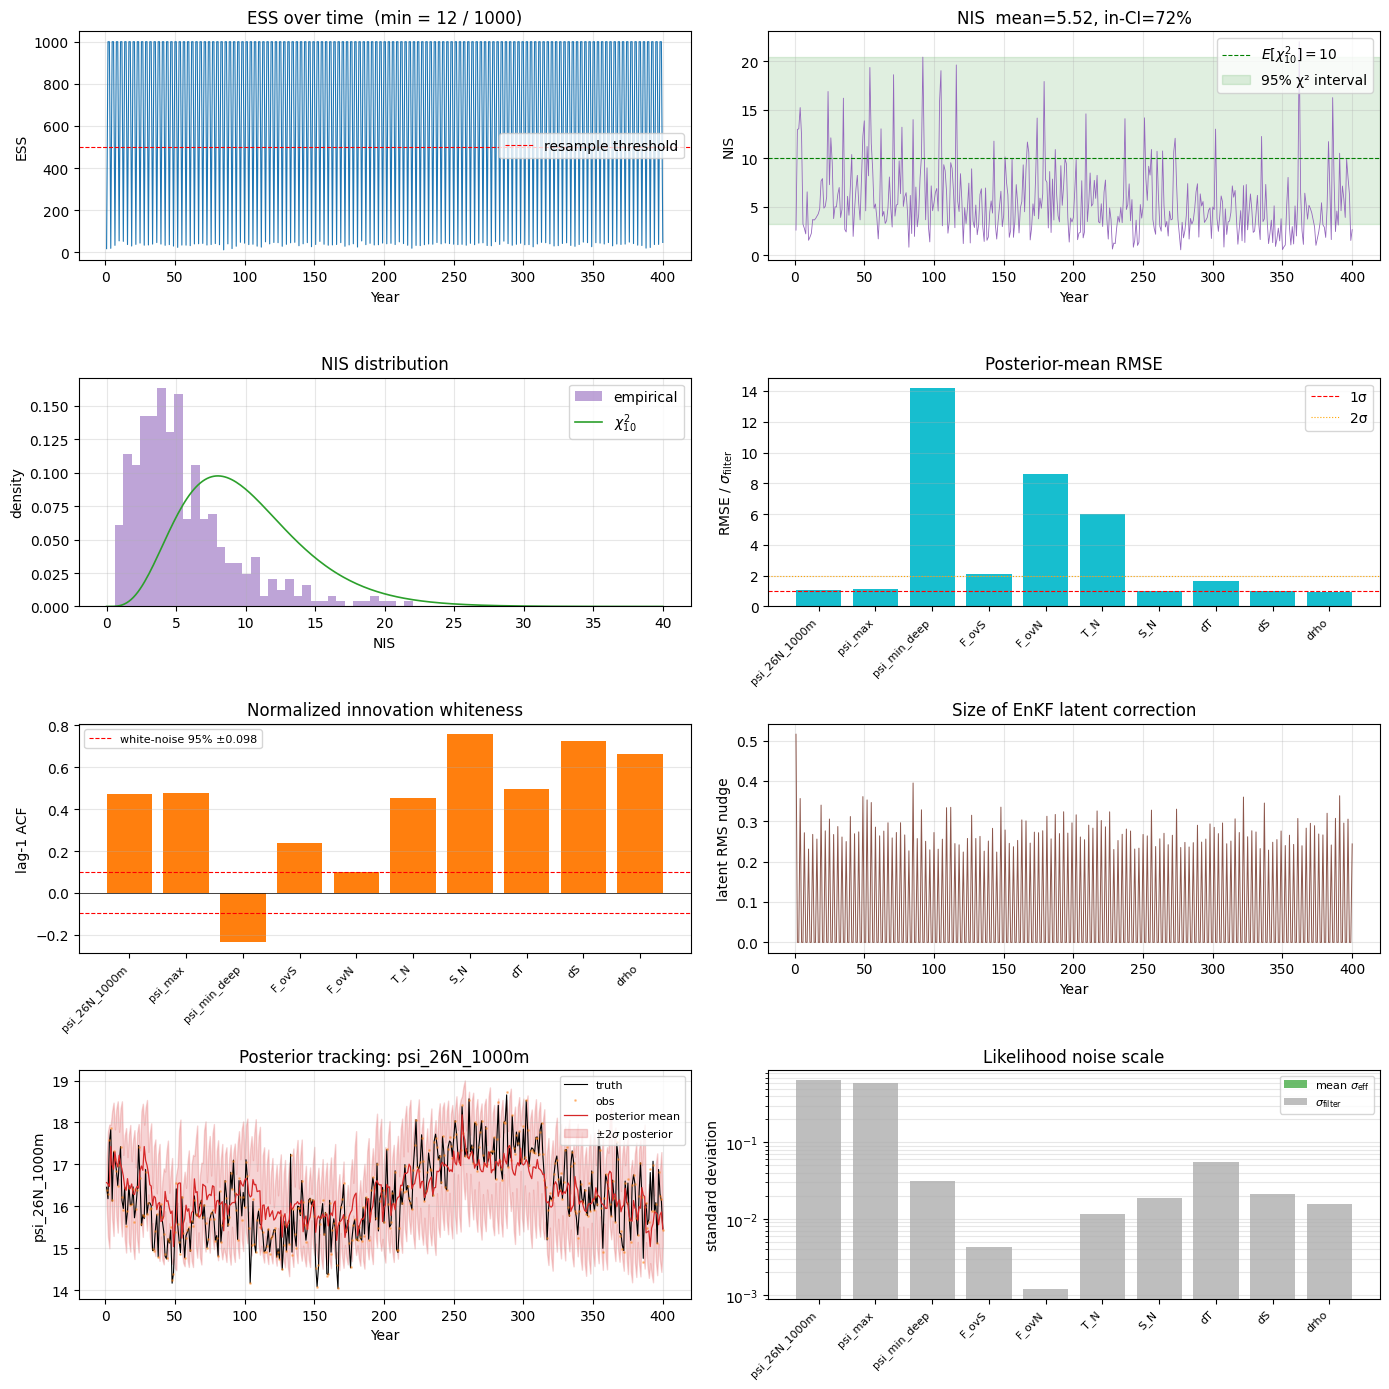


Saved diagnostics in: stationary_pf_diagnostics
Main PF result object: res_stat


In [ ]:
"""
Cell 29 -- Validate the particle filter on a stable period

Before trusting the particle filter during the AMOC collapse itself, this first checks it works properly during a period where the system is stable -- a much simpler test. Reports several standard diagnostics: how many particles are still contributing useful information, whether the filter's uncertainty estimates are well calibrated, whether prediction errors are uncorrelated over time as they should be for a well-tuned filter, and how closely the filter tracks the true trajectory.
"""

import matplotlib.pyplot as plt
from scipy.stats import chi2

STAT_T = STATIONARY_END
years_stat = years_window[:STAT_T]

# Assimilate the full current state vector.
# This is no longer hard-coded as 10 variables.
obs_idx = np.arange(physical_dimension)
obs_names = [STATE_NAMES[j] for j in obs_idx]
n_obs = len(obs_idx)

# ---------------------------------------------------------------------------
# Initialize particles around encoded year-1 state
# ---------------------------------------------------------------------------
Npart = 1000

z0 = (
    Z_full[0:1]
    + np.random.default_rng(0).normal(
        loc=0.0,
        scale=3.0 * np.sqrt(Q_diag),
        size=(Npart, latentDim)
    ).astype(np.float32)
)

z0 = np.clip(z0, -10.0, 10.0).astype(np.float32)

# ---------------------------------------------------------------------------
# Stationary observations and forcing
# ---------------------------------------------------------------------------
Y_stat = Y_full[:STAT_T, obs_idx]
U_stat = U_window[:STAT_T]

# ---------------------------------------------------------------------------
# Run Boussinesq-style EnKF-guided PF
# ---------------------------------------------------------------------------
print(
    f"Running stationary PF with Boussinesq-style EnKF nudge "
    f"(years 1..{STAT_T}, n_obs={n_obs}) ..."
)

res_stat = run_bootstrap_pf(
    obs_idx      = obs_idx,
    Y_obs        = Y_stat,
    U_seq        = U_stat,
    z0_particles = z0,
    Q_diag       = Q_diag,
    sigma_obs    = sigma_obs_filter[obs_idx],
    ess_thresh   = 0.5,
    seed         = 1,
    save_history = True,

    # Boussinesq-style EnKF guided proposal
    guided_prop  = True,
    nudge_gamma  = 0.10,
    nudge_alpha  = 1.0,
    jitter       = 1e-5,

    # Literal Boussinesq-style model-spread likelihood inflation
    sigma_model_frac = 0.1,

    # Boussinesq-style rejuvenation after resampling
    rejuv_after_resample = True,
    rejuv_scale = 0.02,
    rejuv_floor = 0.05,
)

print(f"  resampling events: {res_stat['n_resample']} / {STAT_T}")
print(f"  mean ESS: {res_stat['ESS_hist'].mean():.1f} / {Npart}")
print(f"  min  ESS: {res_stat['ESS_hist'].min():.1f} / {Npart}")
print(f"  mean nudge norm: {res_stat['nudge_norm_hist'].mean():.4e}")

# ---------------------------------------------------------------------------
# Decode prior and posterior particle clouds
# ---------------------------------------------------------------------------
X_pred_stat = decode_particles(res_stat["Z_pred_hist"])
X_post_stat = decode_particles(res_stat["Z_post_hist"])

W_post = res_stat["W_post_hist"]
W_prior = build_prior_weights_from_posterior(W_post)

mean_pred, var_pred = weighted_mean_var(X_pred_stat, W_prior)
mean_post, var_post = weighted_mean_var(X_post_stat, W_post)
std_post = np.sqrt(var_post)

# ---------------------------------------------------------------------------
# Prior innovation NIS
# ---------------------------------------------------------------------------
# Diagnostic convention:
#
#   nu_t = y_t - E[y_t^-]
#   S_t  = Var[y_t^-] + R
#   NIS  = nu_t^T S_t^{-1} nu_t
#
# Here we use a diagonal approximation to S_t.
# ---------------------------------------------------------------------------
mean_pred_obs = mean_pred[:, obs_idx]
var_pred_obs = var_pred[:, obs_idx]

sigma_obs_used = sigma_obs_filter[obs_idx]
S_diag = var_pred_obs + sigma_obs_used[None, :] ** 2
S_diag = np.maximum(S_diag, 1e-12)

innov = Y_stat - mean_pred_obs
NIS_stat = np.sum(innov ** 2 / S_diag, axis=1)

chi2_lo, chi2_hi = chi2.ppf([0.025, 0.975], df=n_obs)
nis_in_ci = ((NIS_stat > chi2_lo) & (NIS_stat < chi2_hi)).mean()

# ---------------------------------------------------------------------------
# Innovation autocorrelation
# ---------------------------------------------------------------------------
max_lag = 5

innov_norm = innov / np.sqrt(S_diag)
innov_norm = innov_norm - innov_norm.mean(axis=0, keepdims=True)

denom = np.sum(innov_norm ** 2, axis=0) + 1e-30

acf = np.zeros((max_lag, n_obs), dtype=np.float32)

for lag in range(1, max_lag + 1):
    acf[lag - 1] = (
        np.sum(innov_norm[lag:] * innov_norm[:-lag], axis=0)
        / denom
    )

ci_white = 1.96 / np.sqrt(STAT_T)

# ---------------------------------------------------------------------------
# Posterior tracking RMSE
# ---------------------------------------------------------------------------
rmse_post = np.sqrt(
    np.mean(
        (mean_post - X_window[:STAT_T]) ** 2,
        axis=0
    )
)

rmse_units = rmse_post / sigma_obs_filter

# ---------------------------------------------------------------------------
# Summary criteria
# ---------------------------------------------------------------------------
ess = res_stat["ESS_hist"]
n_resample = res_stat["n_resample"]
resample_fr = n_resample / STAT_T

pass_A = ess.min() / Npart >= 0.10
pass_B = chi2_lo <= NIS_stat.mean() <= chi2_hi
pass_C = nis_in_ci >= 0.85
pass_D = np.abs(acf[0]).max() <= 0.20
pass_E = np.nanmedian(rmse_units[obs_idx]) <= 2.0
pass_F = 0.01 <= resample_fr <= 0.80

flags = {
    "ESS_min": pass_A,
    "NIS_mean": pass_B,
    "NIS_bulk": pass_C,
    "innov_ACF1": pass_D,
    "tracking": pass_E,
    "resampling": pass_F,
}

n_pass = sum(flags.values())

def _pf_flag(v):
    return "PASS" if v else "FAIL"

print(f"\n{'=' * 72}")
print(f"  STATIONARY PF VALIDATION — ENKF-GUIDED  "
      f"(n_obs={n_obs}, T={STAT_T}, Npart={Npart})")
print(f"{'=' * 72}")
print(f"  ESS min / Npart       = {ess.min()/Npart:7.3f}        {_pf_flag(pass_A)}")
print(f"  ESS mean / Npart      = {ess.mean()/Npart:7.3f}")
print(f"  NIS mean              = {NIS_stat.mean():7.2f}        "
      f"χ²_{n_obs} 95% CI=[{chi2_lo:.2f}, {chi2_hi:.2f}]  {_pf_flag(pass_B)}")
print(f"  NIS median            = {np.median(NIS_stat):7.2f}")
print(f"  NIS in 95% CI         = {nis_in_ci:7.2%}        {_pf_flag(pass_C)}")
print(f"  max |innovation ACF1| = {np.abs(acf[0]).max():7.3f}        {_pf_flag(pass_D)}")
print(f"  median RMSE/sigma     = {np.nanmedian(rmse_units[obs_idx]):7.2f}        {_pf_flag(pass_E)}")
print(f"  max RMSE/sigma        = {np.nanmax(rmse_units[obs_idx]):7.2f}")
print(f"  resample fraction     = {resample_fr:7.2%}        {_pf_flag(pass_F)}")
print(f"{'=' * 72}")
print(f"  Overall: {n_pass}/6 criteria passed")
print(f"{'=' * 72}")

print("\nPer-variable diagnostics:")
print(f"{'variable':15s}  {'RMSE/sigma':>11s}  {'|ACF1|':>8s}  {'mean S^0.5':>12s}")
print("-" * 56)

for jj, j in enumerate(obs_idx):
    name = STATE_NAMES[j]
    mean_sqrt_S = np.mean(np.sqrt(S_diag[:, jj]))

    print(
        f"{name:15s}  "
        f"{rmse_units[j]:11.3f}  "
        f"{abs(acf[0, jj]):8.3f}  "
        f"{mean_sqrt_S:12.4e}"
    )

# ---------------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------------
plot_name = "psi_26N_1000m" if "psi_26N_1000m" in STATE_NAMES else STATE_NAMES[0]
plot_idx = STATE_NAMES.index(plot_name)

fig, axes = plt.subplots(4, 2, figsize=(14, 14))

# ESS
axes[0, 0].plot(years_stat, ess, lw=0.8, color="tab:blue")
axes[0, 0].axhline(
    0.5 * Npart,
    color="red",
    ls="--",
    lw=0.8,
    label="resample threshold"
)
axes[0, 0].set_ylabel("ESS")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_title(f"ESS over time  (min = {ess.min():.0f} / {Npart})")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# NIS
axes[0, 1].plot(years_stat, NIS_stat, lw=0.6, color="tab:purple")
axes[0, 1].axhline(
    n_obs,
    color="green",
    ls="--",
    lw=0.8,
    label=fr"$E[\chi^2_{{{n_obs}}}]={n_obs}$"
)
axes[0, 1].axhspan(
    chi2_lo,
    chi2_hi,
    color="green",
    alpha=0.12,
    label="95% χ² interval"
)
axes[0, 1].set_ylabel("NIS")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_title(f"NIS  mean={NIS_stat.mean():.2f}, in-CI={nis_in_ci:.0%}")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# NIS histogram
xx = np.linspace(0, max(40, np.nanmax(NIS_stat)), 250)
axes[1, 0].hist(
    NIS_stat,
    bins=35,
    density=True,
    alpha=0.6,
    color="tab:purple",
    label="empirical"
)
axes[1, 0].plot(
    xx,
    chi2.pdf(xx, df=n_obs),
    lw=1.2,
    color="tab:green",
    label=fr"$\chi^2_{{{n_obs}}}$"
)
axes[1, 0].set_xlabel("NIS")
axes[1, 0].set_ylabel("density")
axes[1, 0].set_title("NIS distribution")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# RMSE/sigma
axes[1, 1].bar(np.arange(n_obs), rmse_units[obs_idx], color="tab:cyan")
axes[1, 1].axhline(1.0, color="red", ls="--", lw=0.8, label="1σ")
axes[1, 1].axhline(2.0, color="orange", ls=":", lw=0.8, label="2σ")
axes[1, 1].set_xticks(np.arange(n_obs))
axes[1, 1].set_xticklabels(obs_names, rotation=45, ha="right", fontsize=8)
axes[1, 1].set_ylabel(r"RMSE / $\sigma_{\rm filter}$")
axes[1, 1].set_title("Posterior-mean RMSE")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis="y")

# Innovation ACF lag 1
axes[2, 0].bar(np.arange(n_obs), acf[0], color="tab:orange")
axes[2, 0].axhline(ci_white, color="red", ls="--", lw=0.8,
                   label=f"white-noise 95% ±{ci_white:.3f}")
axes[2, 0].axhline(-ci_white, color="red", ls="--", lw=0.8)
axes[2, 0].axhline(0.0, color="k", lw=0.5)
axes[2, 0].set_xticks(np.arange(n_obs))
axes[2, 0].set_xticklabels(obs_names, rotation=45, ha="right", fontsize=8)
axes[2, 0].set_ylabel("lag-1 ACF")
axes[2, 0].set_title("Normalized innovation whiteness")
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(alpha=0.3, axis="y")

# Nudge norm
axes[2, 1].plot(
    years_stat,
    res_stat["nudge_norm_hist"],
    lw=0.7,
    color="tab:brown"
)
axes[2, 1].set_ylabel("latent RMS nudge")
axes[2, 1].set_xlabel("Year")
axes[2, 1].set_title("Size of EnKF latent correction")
axes[2, 1].grid(alpha=0.3)

# Tracking selected variable
axes[3, 0].plot(
    years_stat,
    X_window[:STAT_T, plot_idx],
    lw=0.8,
    color="k",
    label="truth"
)
axes[3, 0].plot(
    years_stat,
    Y_full[:STAT_T, plot_idx],
    lw=0,
    marker=".",
    ms=2,
    color="tab:orange",
    alpha=0.4,
    label="obs"
)
axes[3, 0].plot(
    years_stat,
    mean_post[:, plot_idx],
    lw=0.9,
    color="tab:red",
    label="posterior mean"
)
axes[3, 0].fill_between(
    years_stat,
    mean_post[:, plot_idx] - 2.0 * std_post[:, plot_idx],
    mean_post[:, plot_idx] + 2.0 * std_post[:, plot_idx],
    color="tab:red",
    alpha=0.2,
    label=r"$\pm 2\sigma$ posterior"
)
axes[3, 0].set_ylabel(plot_name)
axes[3, 0].set_xlabel("Year")
axes[3, 0].set_title(f"Posterior tracking: {plot_name}")
axes[3, 0].legend(fontsize=8)
axes[3, 0].grid(alpha=0.3)

# Effective sigma used by likelihood
mean_sig_eff = res_stat["sig_eff_hist"].mean(axis=0)
axes[3, 1].bar(np.arange(n_obs), mean_sig_eff, color="tab:green", alpha=0.7,
               label=r"mean $\sigma_{\rm eff}$")
axes[3, 1].bar(np.arange(n_obs), sigma_obs_used, color="tab:gray", alpha=0.5,
               label=r"$\sigma_{\rm filter}$")
axes[3, 1].set_xticks(np.arange(n_obs))
axes[3, 1].set_xticklabels(obs_names, rotation=45, ha="right", fontsize=8)
axes[3, 1].set_yscale("log")
axes[3, 1].set_ylabel("standard deviation")
axes[3, 1].set_title("Likelihood noise scale")
axes[3, 1].legend(fontsize=8)
axes[3, 1].grid(alpha=0.3, which="both", axis="y")

plt.tight_layout()
plt.savefig(f"{OUT_DIR_SEC}/PF_Diagnostics.png", dpi = 200, bbox_inches = "tight")
plt.show()

# ---------------------------------------------------------------------------
# Persist diagnostics for downstream use
# ---------------------------------------------------------------------------
stationary_pf_diagnostics = {
    "mode": "Boussinesq-style EnKF-guided",
    "n_obs": int(n_obs),
    "obs_names": obs_names,
    "T": int(STAT_T),
    "Npart": int(Npart),
    "ESS": ess,
    "NIS": NIS_stat,
    "NIS_mean": float(NIS_stat.mean()),
    "NIS_median": float(np.median(NIS_stat)),
    "NIS_in_CI": float(nis_in_ci),
    "chi2_CI": (float(chi2_lo), float(chi2_hi)),
    "acf": acf,
    "rmse_units": rmse_units,
    "n_resample": int(n_resample),
    "resample_fraction": float(resample_fr),
    "pass_flags": flags,
    "n_pass": int(n_pass),
    "mean_post": mean_post,
    "var_post": var_post,
    "mean_pred": mean_pred,
    "var_pred": var_pred,
}

print("\nSaved diagnostics in: stationary_pf_diagnostics")
print("Main PF result object: res_stat")

γ-sweep: 5 × 5 = 25 PF runs (~5
  γ=0.00 seed=1  ESS̄=0.67  ESS_min=0.001  NIS/n=0.56  medRMSE/σ=1.43
  γ=0.00 seed=2  ESS̄=0.67  ESS_min=0.001  NIS/n=0.56  medRMSE/σ=1.41
  γ=0.00 seed=3  ESS̄=0.67  ESS_min=0.001  NIS/n=0.55  medRMSE/σ=1.38
  γ=0.00 seed=5  ESS̄=0.67  ESS_min=0.001  NIS/n=0.56  medRMSE/σ=1.40
  γ=0.00 seed=7  ESS̄=0.67  ESS_min=0.001  NIS/n=0.55  medRMSE/σ=1.41
  γ=0.10 seed=1  ESS̄=0.68  ESS_min=0.012  NIS/n=0.55  medRMSE/σ=1.40
  γ=0.10 seed=2  ESS̄=0.68  ESS_min=0.010  NIS/n=0.55  medRMSE/σ=1.40
  γ=0.10 seed=3  ESS̄=0.68  ESS_min=0.013  NIS/n=0.55  medRMSE/σ=1.40
  γ=0.10 seed=5  ESS̄=0.68  ESS_min=0.014  NIS/n=0.55  medRMSE/σ=1.40
  γ=0.10 seed=7  ESS̄=0.68  ESS_min=0.013  NIS/n=0.56  medRMSE/σ=1.41
  γ=0.30 seed=1  ESS̄=0.73  ESS_min=0.028  NIS/n=0.55  medRMSE/σ=1.40
  γ=0.30 seed=2  ESS̄=0.73  ESS_min=0.033  NIS/n=0.55  medRMSE/σ=1.40
  γ=0.30 seed=3  ESS̄=0.73  ESS_min=0.027  NIS/n=0.55  medRMSE/σ=1.40
  γ=0.30 seed=5  ESS̄=0.73  ESS_min=0.027  NIS/n=0.55  med

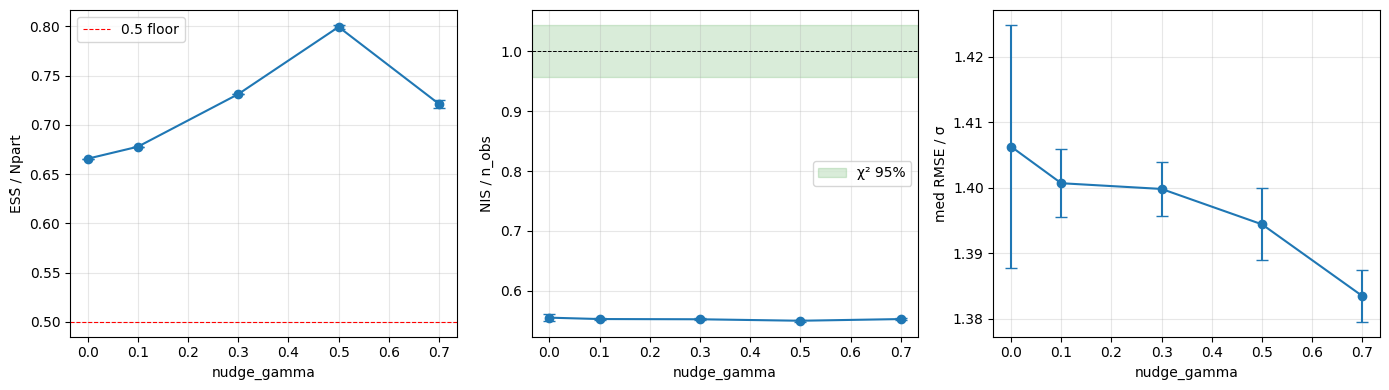


→ Pick GAMMA_OP using the decision rule in the header comment.
  Set GAMMA_OP in cell γ-B before re-running EWS.


In [ ]:
"""
Cell 29-gamma -- Tuning the ensemble-nudge strength

Tests several strengths of the ensemble-Kalman-style nudge (from none at all up to a strong nudge) on the stable period, each repeated over several random seeds, to pick the best setting for the early-warning runs later on. The choice is based on the filter staying healthy, its uncertainty estimates being well calibrated, and, among the settings that pass both checks, whichever gives the most accurate state estimate.
"""

GAMMA_GRID  = (0.0, 0.1, 0.3, 0.5, 0.7)
GAMMA_SEEDS = (1, 2, 3, 5, 7)
GAMMA_FILE  = OUT_DIR / "gamma_sweep_stationary.pkl"

obs_idx_full = np.arange(physical_dimension)
n_obs_full   = len(obs_idx_full)
Y_stat_full  = Y_full[:STAT_T, obs_idx_full]
sig_full     = sigma_obs_filter[obs_idx_full]

# Same z0 across all γ × seed combos so we isolate the γ effect
z0_fixed = (Z_full[0:1] + np.random.default_rng(0).normal(
    0.0, 3.0 * np.sqrt(Q_diag),
    size=(Npart, latentDim))).astype(np.float32)
z0_fixed = np.clip(z0_fixed, -10.0, 10.0)

def one_gamma_seed(gamma, seed):
    res = run_bootstrap_pf(
        obs_idx              = obs_idx_full,
        Y_obs                = Y_stat_full,
        U_seq                = U_stat,
        z0_particles         = z0_fixed,
        Q_diag               = Q_diag,
        sigma_obs            = sig_full,
        ess_thresh           = 0.5,
        seed                 = seed,
        save_history         = True,
        guided_prop          = (gamma > 0.0),
        nudge_gamma          = float(gamma),
        nudge_alpha          = 1.0,
        jitter               = 1e-5,
        sigma_model_frac     = 0.1,
        rejuv_after_resample = True,
        rejuv_scale          = 0.02,
        rejuv_floor          = 0.05,
    )
    X_pred = decode_particles(res["Z_pred_hist"])
    X_post = decode_particles(res["Z_post_hist"])
    W_post = res["W_post_hist"]
    W_prior = build_prior_weights_from_posterior(W_post)
    mean_pred, var_pred = weighted_mean_var(X_pred, W_prior)
    mean_post, _        = weighted_mean_var(X_post, W_post)
    innov  = Y_stat_full - mean_pred[:, obs_idx_full]
    S_diag = np.maximum(var_pred[:, obs_idx_full] + sig_full[None, :]**2, 1e-12)
    NIS    = np.sum(innov**2 / S_diag, axis=1)
    rmse_full = np.sqrt(np.mean((mean_post - X_window[:STAT_T])**2, axis=0))
    rmse_units = rmse_full / sigma_obs_filter
    return dict(
        gamma=gamma, seed=seed,
        ess_mean=float(res["ESS_hist"].mean())/Npart,
        ess_min =float(res["ESS_hist"].min ())/Npart,
        nis_per_obs=float(NIS.mean()/n_obs_full),
        med_rmse=float(np.nanmedian(rmse_units)),
        n_resample=int(res["n_resample"]),
    )

print(f"γ-sweep: {len(GAMMA_GRID)} × {len(GAMMA_SEEDS)} = "
      f"{len(GAMMA_GRID)*len(GAMMA_SEEDS)} PF runs (~"
      f"{len(GAMMA_GRID)}")

gamma_records = []
for g in GAMMA_GRID:
    for s in GAMMA_SEEDS:
        gamma_records.append(one_gamma_seed(g, s))
        r = gamma_records[-1]
        print(f"  γ={g:.2f} seed={s}  ESS̄={r['ess_mean']:.2f}  "
              f"ESS_min={r['ess_min']:.3f}  NIS/n={r['nis_per_obs']:.2f}  "
              f"medRMSE/σ={r['med_rmse']:.2f}")

with open(GAMMA_FILE, "wb") as f:
    pickle.dump(dict(records=gamma_records,
                     GAMMA_GRID=GAMMA_GRID, GAMMA_SEEDS=GAMMA_SEEDS,
                     STAT_T=STAT_T, n_obs_full=n_obs_full), f)

# --- aggregate ------------------------------------------------------------
lo_band, hi_band = (chi2.ppf(0.025, n_obs_full*STAT_T)/(n_obs_full*STAT_T),
                   chi2.ppf(0.975, n_obs_full*STAT_T)/(n_obs_full*STAT_T))

print(f"\nχ² band at 95%, T={STAT_T}, n_obs={n_obs_full}: "
      f"[{lo_band:.3f}, {hi_band:.3f}]\n")
print(f"{'γ':>5s}  {'ESS̄':>11s}  {'min ESS':>11s}  "
      f"{'NIS/n':>11s}  {'in χ²?':>6s}  {'medRMSE/σ':>13s}")
print("-" * 78)
for g in GAMMA_GRID:
    rs = [r for r in gamma_records if r["gamma"] == g]
    em = np.array([r["ess_mean"]    for r in rs])
    emn= np.array([r["ess_min"]     for r in rs])
    ni = np.array([r["nis_per_obs"] for r in rs])
    md = np.array([r["med_rmse"]    for r in rs])
    inband = ((ni >= lo_band) & (ni <= hi_band)).mean()
    print(f"  {g:.2f}  {em.mean():.2f}±{em.std(ddof=1):.2f}  "
          f"{emn.mean():.3f}±{emn.std(ddof=1):.3f}  "
          f"{ni.mean():.2f}±{ni.std(ddof=1):.2f}  "
          f"{inband*100:5.0f}%  "
          f"{md.mean():.2f}±{md.std(ddof=1):.2f}")

# --- plot -----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
gv = np.array([r["gamma"] for r in gamma_records])
for ax, key, lbl in zip(
    axes,
    ["ess_mean", "nis_per_obs", "med_rmse"],
    ["ESS̄ / Npart", "NIS / n_obs", "med RMSE / σ"]
):
    v = np.array([r[key] for r in gamma_records])
    means = [v[gv==g].mean() for g in GAMMA_GRID]
    stds  = [v[gv==g].std(ddof=1) for g in GAMMA_GRID]
    ax.errorbar(GAMMA_GRID, means, yerr=stds, fmt="o-", capsize=4)
    ax.set_xlabel("nudge_gamma"); ax.set_ylabel(lbl); ax.grid(alpha=0.3)
axes[0].axhline(0.5, color="r", ls="--", lw=0.8, label="0.5 floor")
axes[0].legend()
axes[1].axhspan(lo_band, hi_band, color="green", alpha=0.15, label="χ² 95%")
axes[1].axhline(1.0, color="k", ls="--", lw=0.7)
axes[1].legend()
plt.tight_layout(); plt.show()

print("\n→ Pick GAMMA_OP using the decision rule in the header comment.")
print("  Set GAMMA_OP in cell γ-B before re-running EWS.")

PDF snapshots will be saved to: /content/drive/MyDrive/Colab Notebooks/pf_pdf_snapshots
Assimilation snapshot timesteps (year offsets): [102, 201, 300]
  ESS at these steps: [36.70633316040039, 40.432186126708984, 35.996055603027344]


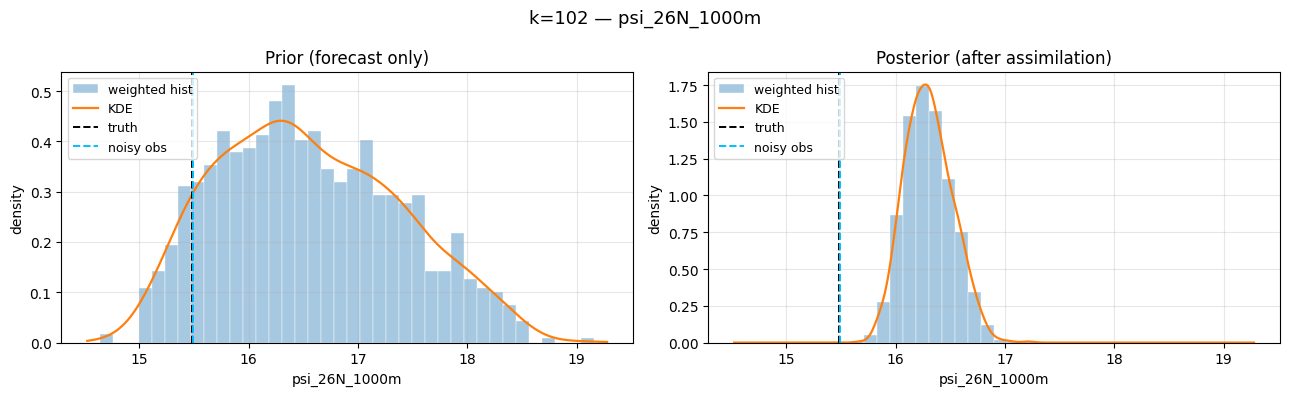

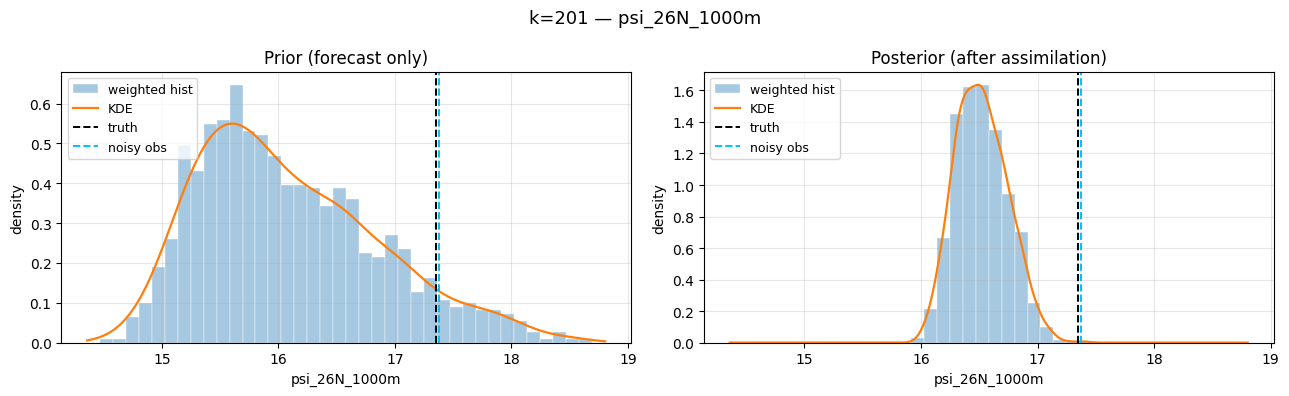

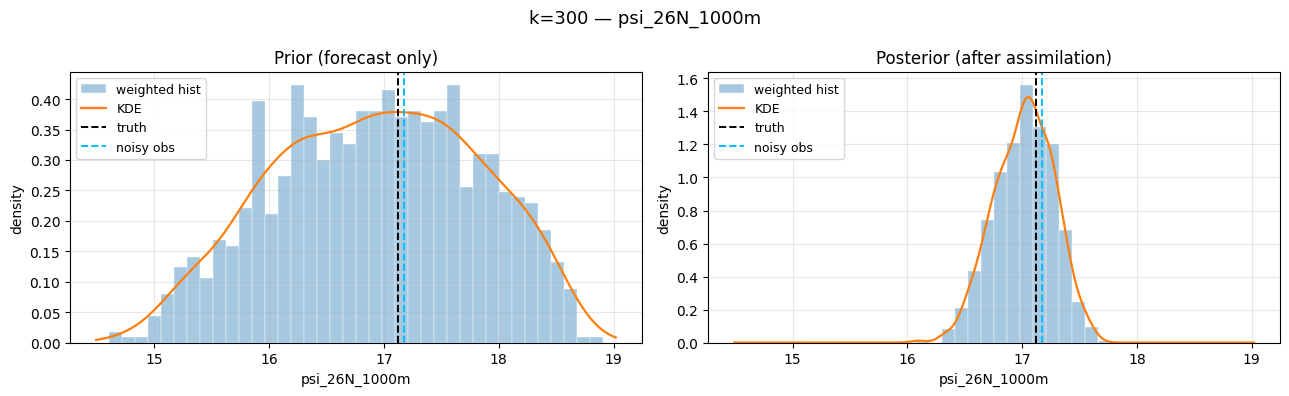

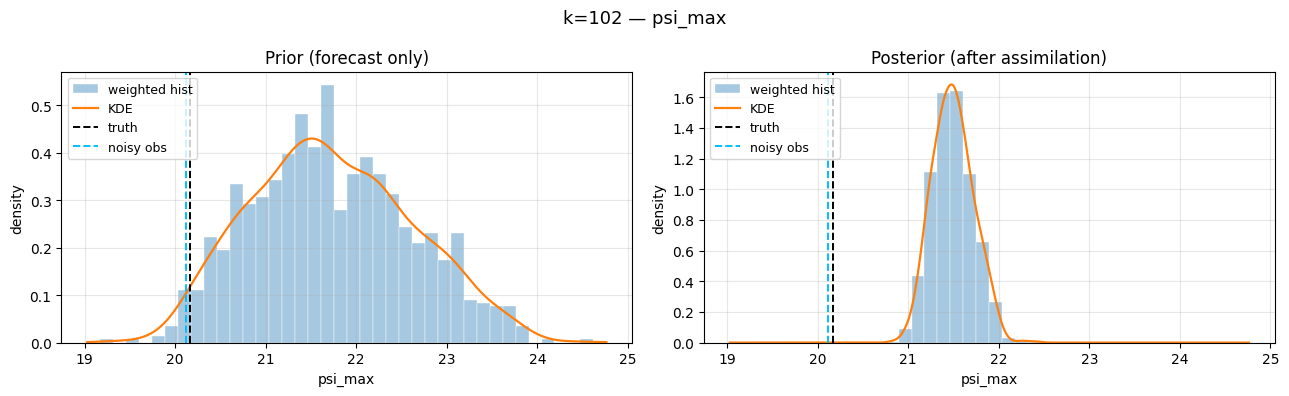

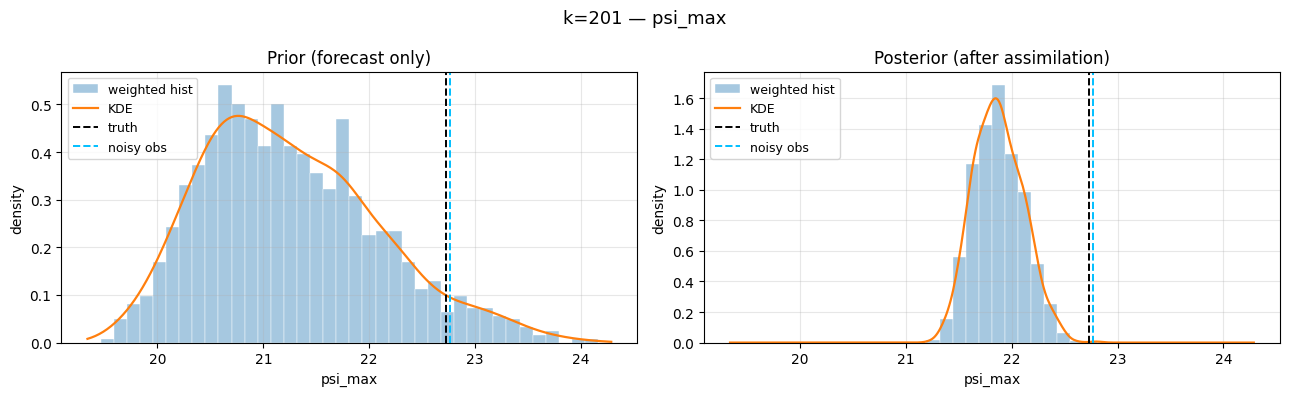

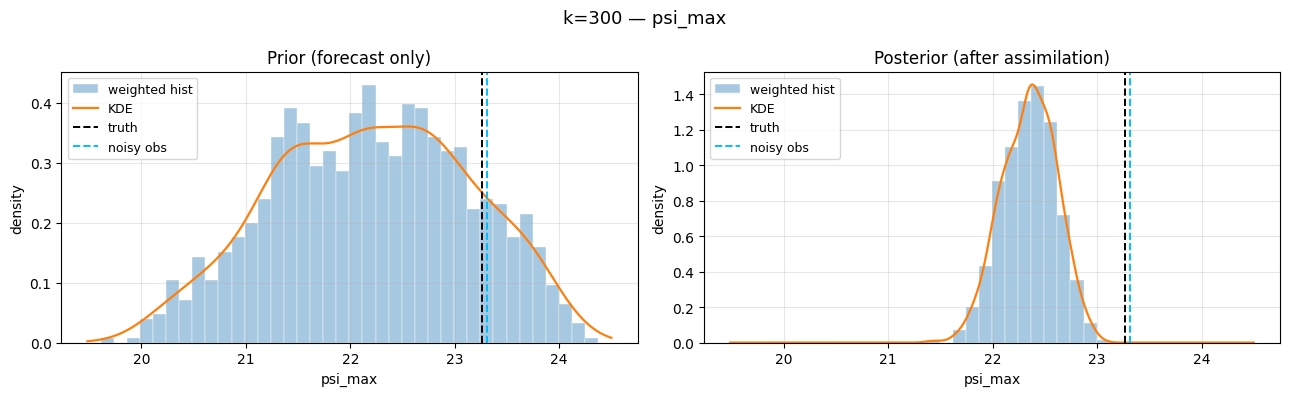

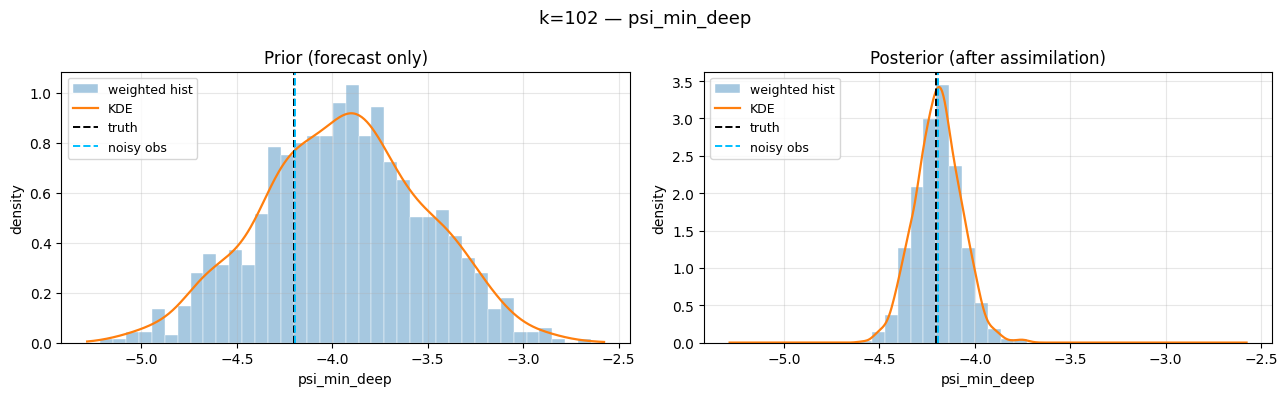

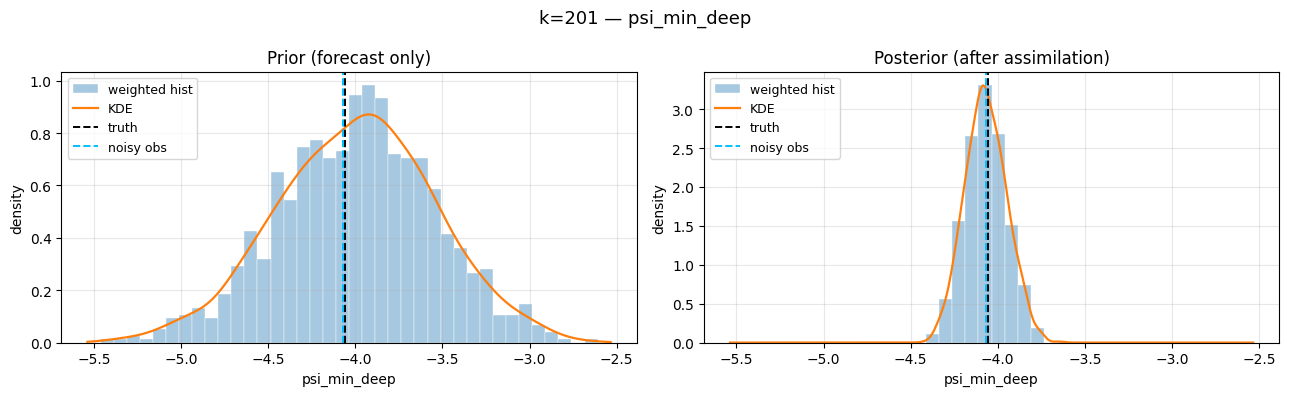

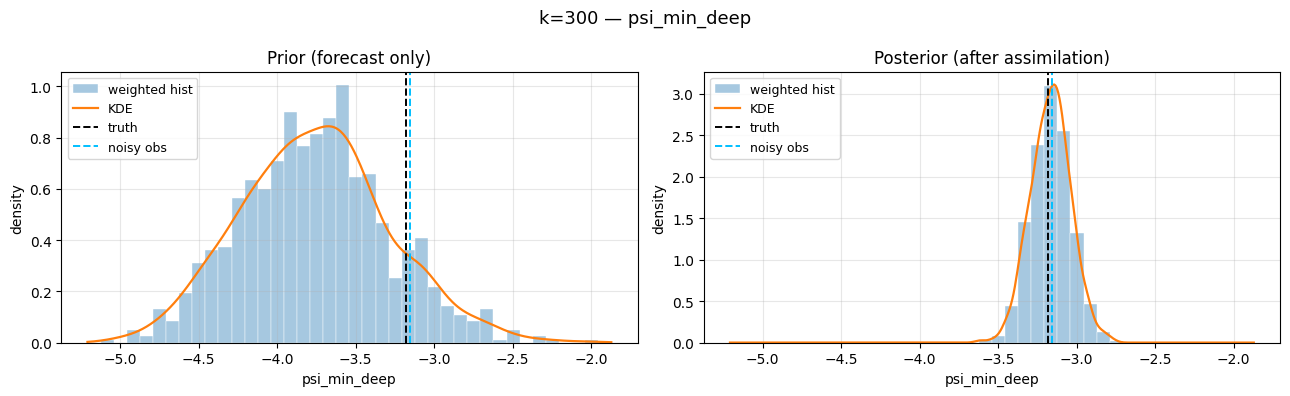

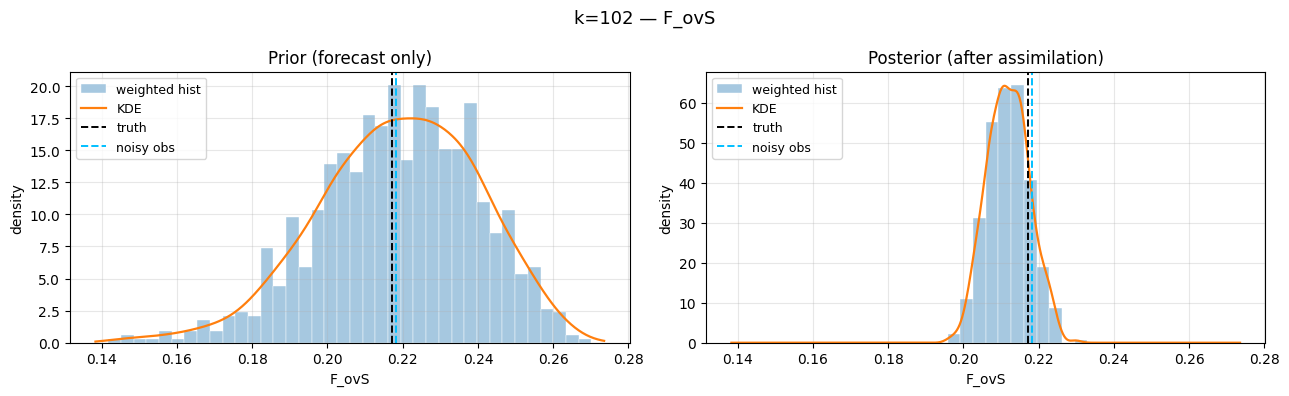

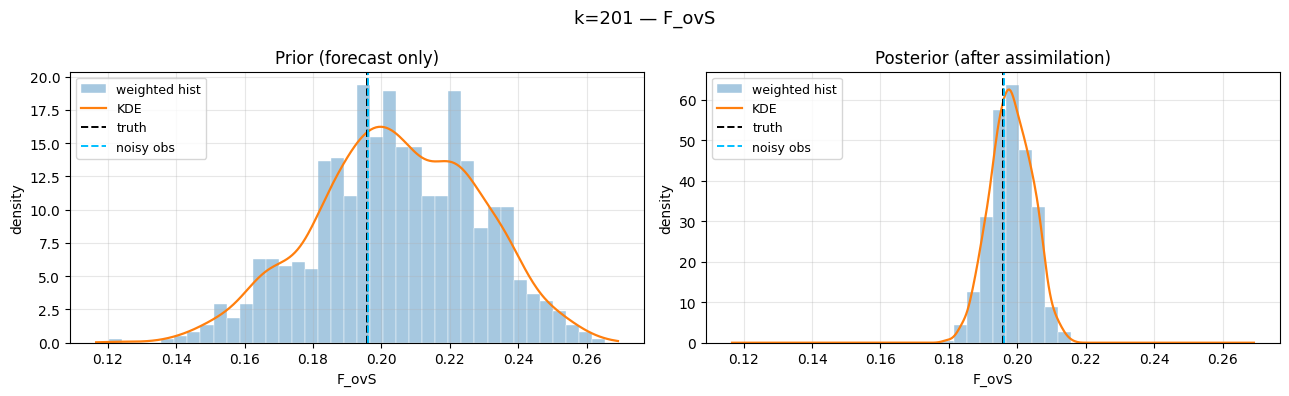

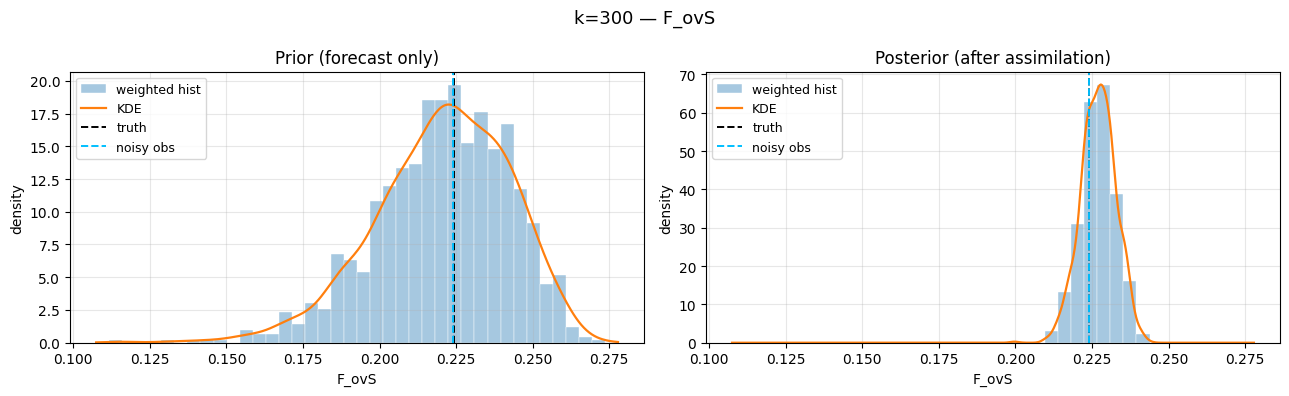


Saved 12 PDF snapshot panels to /content/drive/MyDrive/Colab Notebooks/pf_pdf_snapshots/
snap_data is available in the namespace for further inspection.


In [ ]:
"""
Cell 29d -- Visualize the particle distributions

For a handful of points in time, plots the full spread of the particles' predicted and corrected values for each observed variable, alongside the true value and the noisy observation. This gives a direct, visual sense of how the filter narrows its uncertainty each time it sees a new observation.
"""

from scipy.stats import gaussian_kde

outdir = "/content/drive/MyDrive/Colab Notebooks/pf_pdf_snapshots"
os.makedirs(outdir, exist_ok=True)
print(f"PDF snapshots will be saved to: {outdir}")


def build_pdf_snapshots(res, k_list, X_pred_hist=None, X_post_hist=None):
    """
    Construct the snap_data dict used by plot_snapshot_set, matching the
    layout from the Boussinesq notebook so the rest of the diagnostic pattern
    transfers unchanged.

    Parameters
    ----------
    res : dict
        Output of run_bootstrap_pf with save_history=True.
    k_list : iterable of int
        Timesteps at which to extract snapshots.
    X_pred_hist, X_post_hist : np.ndarray, optional
        Precomputed decoded particle histories with shape (T, Npart,
        physical_dimension). If omitted, they are decoded from res here.

    Returns
    -------
    snap_data : dict[int -> dict]
        snap_data[k] has keys:
            "X_pred"  : (Npart, physical_dimension) decoded prior particles
            "X_post"  : (Npart, physical_dimension) decoded posterior particles
            "W_prior" : (Npart,) prior weights at step k
            "W_post"  : (Npart,) posterior weights at step k
    """
    if X_pred_hist is None:
        X_pred_hist = decode_particles(res["Z_pred_hist"])
    if X_post_hist is None:
        X_post_hist = decode_particles(res["Z_post_hist"])

    W_post_hist = res["W_post_hist"]
    W_prior_hist = build_prior_weights_from_posterior(W_post_hist)

    T = X_pred_hist.shape[0]
    snap_data = {}

    for k in k_list:
        if k < 0 or k >= T:
            print(f"  Warning: k={k} out of range [0, {T-1}]; skipping.")
            continue

        snap_data[int(k)] = {
            "X_pred":  X_pred_hist[k].copy(),
            "X_post":  X_post_hist[k].copy(),
            "W_prior": W_prior_hist[k].copy(),
            "W_post":  W_post_hist[k].copy(),
        }

    return snap_data


def plot_snapshot_set(snap_data, k, i, obs_name, truth, obs, n_bins=40):
    """
    1x2 panel of weighted prior vs posterior PDFs for variable i at step k.
    Visual style mirrors the Boussinesq PDF diagnostic:
        - light blue weighted histogram
        - orange weighted-KDE line
        - black dashed truth marker
        - cyan dashed noisy-observation marker
        - suptitle  "k={k} — {var_name}"
        - subplot titles  "Prior (forecast only)"  /  "Posterior (after assimilation)"
    """
    snap = snap_data[k]

    x_prior = snap["X_pred"][:, i]
    x_post  = snap["X_post"][:, i]
    w_prior = snap["W_prior"]
    w_post  = snap["W_post"]

    # Shared bin edges so the two panels are visually comparable.
    lo = float(min(x_prior.min(), x_post.min(), truth, obs))
    hi = float(max(x_prior.max(), x_post.max(), truth, obs))
    pad = 0.05 * (hi - lo + 1e-12)
    bins = np.linspace(lo - pad, hi + pad, n_bins + 1)
    x_grid = np.linspace(lo - pad, hi + pad, 400)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

    panels = [
        (axes[0], x_prior, w_prior, "Prior (forecast only)"),
        (axes[1], x_post,  w_post,  "Posterior (after assimilation)"),
    ]

    HIST_COLOR  = "#a6c8e0"   # light blue (matches Boussinesq)
    KDE_COLOR   = "tab:orange"
    TRUTH_COLOR = "k"
    OBS_COLOR   = "deepskyblue"

    for ax, x, w, title in panels:
        # Weighted, density-normalized histogram
        ax.hist(
            x,
            bins=bins,
            weights=w,
            density=True,
            color=HIST_COLOR,
            edgecolor="white",
            linewidth=0.3,
            label="weighted hist",
        )

        # Weighted KDE overlay; gracefully skip if particles are degenerate.
        try:
            w_norm = w / (w.sum() + 1e-300)
            if np.std(x) > 0 and np.count_nonzero(w_norm) > 1:
                kde = gaussian_kde(x, weights=w_norm)
                ax.plot(x_grid, kde(x_grid),
                        color=KDE_COLOR, lw=1.6, label="KDE")
        except Exception:
            pass

        ax.axvline(truth, color=TRUTH_COLOR, ls="--", lw=1.4, label="truth")
        ax.axvline(obs,   color=OBS_COLOR,   ls="--", lw=1.4, label="noisy obs")

        ax.set_title(title)
        ax.set_xlabel(obs_name)
        ax.set_ylabel("density")
        ax.legend(loc="upper left", fontsize=9)
        ax.grid(alpha=0.3)

    fig.suptitle(f"k={k} — {obs_name}", fontsize=13)
    plt.tight_layout()
    return fig


# ----------------------------------------------------------------------------
# 1. Find assimilation snapshot timesteps from ESS history
# ----------------------------------------------------------------------------
# Same heuristic as the Boussinesq notebook: pick timesteps where ESS dropped
# relative to the previous step. Note that the CESM PF runs a likelihood
# update at every timestep (no observation gaps), so this rule will mark most
# steps. The 1/4, 2/4, 3/4 picks below still give a representative spread
# across the trajectory.
# ----------------------------------------------------------------------------
ESS_pf = res_stat["ESS_hist"]
T_pf = len(ESS_pf)

assim_steps = [k for k in range(1, T_pf) if ESS_pf[k] < ESS_pf[k - 1]]

if len(assim_steps) < 3:
    raise RuntimeError(
        f"Only {len(assim_steps)} assimilation steps detected in ESS_hist; "
        f"need at least 3 to pick a spread of snapshots."
    )

k_extra = [
    assim_steps[len(assim_steps) // 4],
    assim_steps[len(assim_steps) // 2],
    assim_steps[3 * len(assim_steps) // 4],
]
print(f"Assimilation snapshot timesteps (year offsets): {k_extra}")
print(f"  ESS at these steps: "
      f"{[float(ESS_pf[k]) for k in k_extra]}")

# ----------------------------------------------------------------------------
# 2. Build snapshots from existing res_stat (no PF re-run needed)
# ----------------------------------------------------------------------------
# X_pred_stat and X_post_stat were already decoded in CELL 29; reuse them
# rather than calling decode_particles again.
# ----------------------------------------------------------------------------
snap_data = build_pdf_snapshots(
    res_stat,
    k_extra,
    X_pred_hist=X_pred_stat,
    X_post_hist=X_post_stat,
)

# ----------------------------------------------------------------------------
# 3. Plot prior/posterior PDFs at each (snapshot, variable), save AND show
# ----------------------------------------------------------------------------
# Boussinesq default was obs_indices = [0, 1, 2, 3]. In CESM the first four
# entries of STATE_NAMES are the natural starting set; change this list to
# focus on different variables (e.g. F_ovS, drho).
# ----------------------------------------------------------------------------
obs_indices_to_plot = [0, 1, 2, 3]

n_saved = 0
for i in obs_indices_to_plot:
    if i < 0 or i >= physical_dimension:
        print(f"  Skipping variable index {i}: out of range "
              f"[0, {physical_dimension - 1}].")
        continue

    obs_name = STATE_NAMES[i]

    for k in k_extra:
        if k not in snap_data:
            print(f"  Warning: k={k} not in snap_data for {obs_name}")
            continue

        truth_val = float(X_window[k, i])
        obs_val   = float(Y_full[k, i])

        fig = plot_snapshot_set(
            snap_data,
            k=k,
            i=i,
            obs_name=obs_name,
            truth=truth_val,
            obs=obs_val,
        )

        fname = os.path.join(outdir, f"PDF_{obs_name}_{k}.png")
        fig.savefig(fname, dpi=200, bbox_inches="tight")
        plt.show()         # render inline in the notebook
        plt.close(fig)     # free memory after display
        n_saved += 1

print(f"\nSaved {n_saved} PDF snapshot panels to {outdir}/")
print("snap_data is available in the namespace for further inspection.")

Running pure bootstrap comparison ...

Stationary PF comparison:
mode                       ESS_mean    ESS_min   NIS_mean  NIS_in_CI   resamp  med_RMSEσ  max_RMSEσ
----------------------------------------------------------------------------------------------------
bootstrap                     665.4        1.0       5.96     73.25%      134       1.46      14.27
Boussinesq-style EnKF         677.6       11.9       5.52     71.75%      134       1.40      14.16


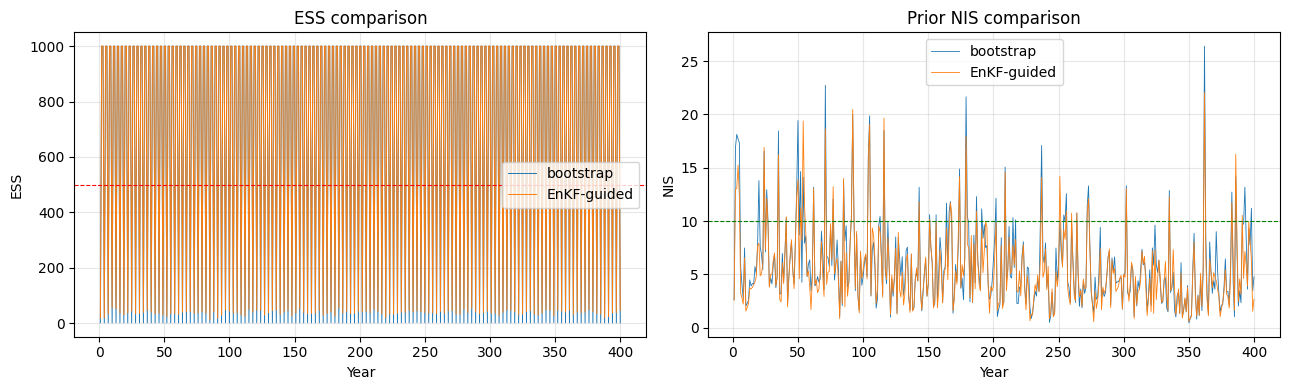

In [ ]:
"""
Cell 29b -- Compare plain vs. ensemble-nudged particle filter

Compares the plain ('bootstrap') particle filter against the ensemble-nudged version on the stable period, to check whether the nudging actually helps.
"""

def summarize_stationary_run(res, label, obs_idx):
    obs_idx = np.asarray(obs_idx, dtype=int)
    n_obs = len(obs_idx)

    X_pred = decode_particles(res["Z_pred_hist"])
    X_post = decode_particles(res["Z_post_hist"])

    W_post = res["W_post_hist"]
    W_prior = build_prior_weights_from_posterior(W_post)

    mean_pred, var_pred = weighted_mean_var(X_pred, W_prior)
    mean_post, var_post = weighted_mean_var(X_post, W_post)

    Y_eval = Y_full[:STAT_T, obs_idx]
    sig = sigma_obs_filter[obs_idx]

    innov = Y_eval - mean_pred[:, obs_idx]
    S_diag = var_pred[:, obs_idx] + sig[None, :] ** 2
    S_diag = np.maximum(S_diag, 1e-12)

    NIS = np.sum(innov ** 2 / S_diag, axis=1)

    rmse = np.sqrt(
        np.mean(
            (mean_post[:, obs_idx] - X_window[:STAT_T, obs_idx]) ** 2,
            axis=0
        )
    )

    rmse_units = rmse / sig

    lo, hi = chi2.ppf([0.025, 0.975], df=n_obs)

    return {
        "label": label,
        "ESS_mean": res["ESS_hist"].mean(),
        "ESS_min": res["ESS_hist"].min(),
        "NIS_mean": NIS.mean(),
        "NIS_median": np.median(NIS),
        "NIS_in_CI": ((NIS > lo) & (NIS < hi)).mean(),
        "resamples": res["n_resample"],
        "rmse_units_median": np.median(rmse_units),
        "rmse_units_max": np.max(rmse_units),
        "NIS": NIS,
    }


# Reuse same z0, Y_stat, U_stat, obs_idx as CELL 29.

print("Running pure bootstrap comparison ...")

res_boot = run_bootstrap_pf(
    obs_idx      = obs_idx,
    Y_obs        = Y_stat,
    U_seq        = U_stat,
    z0_particles = z0,
    Q_diag       = Q_diag,
    sigma_obs    = sigma_obs_filter[obs_idx],
    ess_thresh   = 0.5,
    seed         = 1,
    save_history = True,

    guided_prop = False,
    sigma_model_frac = 0.0,

    rejuv_after_resample = True,
    rejuv_scale = 0.02,
    rejuv_floor = 0.05,
)

summary_boot = summarize_stationary_run(
    res_boot,
    "bootstrap",
    obs_idx
)

summary_enkf = summarize_stationary_run(
    res_stat,
    "Boussinesq-style EnKF",
    obs_idx
)

summaries = [summary_boot, summary_enkf]

print("\nStationary PF comparison:")
print(
    f"{'mode':24s} "
    f"{'ESS_mean':>10s} "
    f"{'ESS_min':>10s} "
    f"{'NIS_mean':>10s} "
    f"{'NIS_in_CI':>10s} "
    f"{'resamp':>8s} "
    f"{'med_RMSEσ':>10s} "
    f"{'max_RMSEσ':>10s}"
)
print("-" * 100)

for s in summaries:
    print(
        f"{s['label']:24s} "
        f"{s['ESS_mean']:10.1f} "
        f"{s['ESS_min']:10.1f} "
        f"{s['NIS_mean']:10.2f} "
        f"{s['NIS_in_CI']:10.2%} "
        f"{s['resamples']:8d} "
        f"{s['rmse_units_median']:10.2f} "
        f"{s['rmse_units_max']:10.2f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(years_stat, res_boot["ESS_hist"], lw=0.7, label="bootstrap")
axes[0].plot(years_stat, res_stat["ESS_hist"], lw=0.7, label="EnKF-guided")
axes[0].axhline(0.5 * Npart, color="red", ls="--", lw=0.8)
axes[0].set_ylabel("ESS")
axes[0].set_xlabel("Year")
axes[0].set_title("ESS comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(years_stat, summary_boot["NIS"], lw=0.6, label="bootstrap")
axes[1].plot(years_stat, summary_enkf["NIS"], lw=0.6, label="EnKF-guided")
axes[1].axhline(n_obs, color="green", ls="--", lw=0.8)
axes[1].set_ylabel("NIS")
axes[1].set_xlabel("Year")
axes[1].set_title("Prior NIS comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
"""
Cell 29c -- Test filtering with fewer observed variables

Checks whether the filter is more statistically consistent if it's only given a smaller, more physically meaningful subset of variables to observe, rather than all ten.
"""

def run_subset_pf_enkf(obs_names, label, seed=1):
    obs_idx_sub = np.array(
        [STATE_NAMES.index(name) for name in obs_names],
        dtype=int
    )

    n_obs_sub = len(obs_idx_sub)

    Y_sub = Y_full[:STAT_T, obs_idx_sub]
    sig_sub = sigma_obs_filter[obs_idx_sub]

    res_sub = run_bootstrap_pf(
        obs_idx      = obs_idx_sub,
        Y_obs        = Y_sub,
        U_seq        = U_stat,
        z0_particles = z0,
        Q_diag       = Q_diag,
        sigma_obs    = sig_sub,
        ess_thresh   = 0.5,
        seed         = seed,
        save_history = True,

        guided_prop  = True,
        nudge_gamma  = 0.10,
        nudge_alpha  = 1.0,
        jitter       = 1e-5,

        sigma_model_frac = 0.1,

        rejuv_after_resample = True,
        rejuv_scale = 0.02,
        rejuv_floor = 0.05,
    )

    X_pred = decode_particles(res_sub["Z_pred_hist"])
    X_post = decode_particles(res_sub["Z_post_hist"])

    W_post = res_sub["W_post_hist"]
    W_prior = build_prior_weights_from_posterior(W_post)

    mean_pred, var_pred = weighted_mean_var(X_pred, W_prior)
    mean_post, var_post = weighted_mean_var(X_post, W_post)

    innov = Y_sub - mean_pred[:, obs_idx_sub]
    S_diag = var_pred[:, obs_idx_sub] + sig_sub[None, :] ** 2
    S_diag = np.maximum(S_diag, 1e-12)

    NIS_sub = np.sum(innov ** 2 / S_diag, axis=1)

    lo, hi = chi2.ppf([0.025, 0.975], df=n_obs_sub)
    nis_in = ((NIS_sub > lo) & (NIS_sub < hi)).mean()

    rmse_full = np.sqrt(
        np.mean(
            (mean_post - X_window[:STAT_T]) ** 2,
            axis=0
        )
    )

    rmse_units_full = rmse_full / sigma_obs_filter

    print(f"\n{'=' * 72}")
    print(f"{label}  (n_obs={n_obs_sub})")
    print(f"{'=' * 72}")
    print(f"Assimilated variables: {obs_names}")
    print(f"ESS mean/min: {res_sub['ESS_hist'].mean():.1f} / {res_sub['ESS_hist'].min():.1f}")
    print(f"Resampling events: {res_sub['n_resample']} / {STAT_T}")
    print(f"NIS mean/median: {NIS_sub.mean():.2f} / {np.median(NIS_sub):.2f}")
    print(f"NIS χ² 95% interval [{lo:.2f}, {hi:.2f}], fraction inside: {nis_in:.2%}")
    print(f"Median RMSE/sigma over full state: {np.median(rmse_units_full):.2f}")
    print(f"Max RMSE/sigma over full state: {np.max(rmse_units_full):.2f}")

    print("\nPer-variable RMSE/sigma over full state:")
    for j, name in enumerate(STATE_NAMES):
        marker = "*" if j in obs_idx_sub else " "
        print(f"  {marker} {name:15s}: {rmse_units_full[j]:8.2f}")

    return {
        "label": label,
        "obs_names": obs_names,
        "obs_idx": obs_idx_sub,
        "res": res_sub,
        "NIS": NIS_sub,
        "mean_post": mean_post,
        "var_post": var_post,
        "rmse_units_full": rmse_units_full,
    }


# Suggested physically meaningful tests for the reduced CESM state vector.
subset_runs = {}

candidate_subsets = [
    (
        "Core AMOC + density",
        ["psi_26N_1000m", "psi_max", "drho"]
    ),
    (
        "AMOC + thermohaline gradients",
        ["psi_26N_1000m", "psi_max", "dT", "dS", "drho"]
    ),
    (
        "Hydrography only",
        ["T_N", "S_N", "dT", "dS", "drho"]
    ),
]

for label, names in candidate_subsets:
    names_available = [n for n in names if n in STATE_NAMES]

    if len(names_available) == 0:
        print(f"Skipping {label}: no requested variables found in STATE_NAMES.")
        continue

    subset_runs[label] = run_subset_pf_enkf(names_available, label)


Core AMOC + density  (n_obs=3)
Assimilated variables: ['psi_26N_1000m', 'psi_max', 'drho']
ESS mean/min: 691.5 / 129.0
Resampling events: 74 / 400
NIS mean/median: 1.31 / 1.00
NIS χ² 95% interval [0.22, 9.35], fraction inside: 90.50%
Median RMSE/sigma over full state: 1.99
Max RMSE/sigma over full state: 16.28

Per-variable RMSE/sigma over full state:
  * psi_26N_1000m  :     0.88
  * psi_max        :     0.88
    psi_min_deep   :    16.28
    F_ovS          :     3.24
    F_ovN          :    10.19
    T_N            :    10.39
    S_N            :     1.06
    dT             :     2.66
    dS             :     1.33
  * drho           :     0.94

AMOC + thermohaline gradients  (n_obs=5)
Assimilated variables: ['psi_26N_1000m', 'psi_max', 'dT', 'dS', 'drho']
ESS mean/min: 756.8 / 50.7
Resampling events: 134 / 400
NIS mean/median: 1.70 / 1.40
NIS χ² 95% interval [0.83, 12.83], fraction inside: 71.00%
Median RMSE/sigma over full state: 1.22
Max RMSE/sigma over full state: 16.29

Per-vari

Cross-particle predictive spread (prior, decoded) vs R:
variable           sig_pred   sig_truth  sig_filter  pred/filter  pred/truth
--------------------------------------------------------------------------------
psi_26N_1000m    7.1818e-01  4.6298e-02  6.4420e-01        1.115      15.512
psi_max          7.6641e-01  4.7166e-02  6.0539e-01        1.266      16.249
psi_min_deep     4.4192e-01  2.6518e-02  3.1644e-02       13.966      16.665
F_ovS            1.9921e-02  7.2606e-04  4.2348e-03        4.704      27.437
F_ovN            1.2959e-02  6.9198e-04  1.2220e-03       10.605      18.728
T_N              1.6682e-01  8.2346e-03  1.1690e-02       14.271      20.259
S_N              3.8456e-02  1.7244e-03  1.8736e-02        2.052      22.301
dT               1.9913e-01  9.9242e-03  5.5032e-02        3.618      20.065
dS               4.7972e-02  2.1995e-03  2.1194e-02        2.263      21.811
drho             1.5834e-02  9.6917e-04  1.5648e-02        1.012      16.337


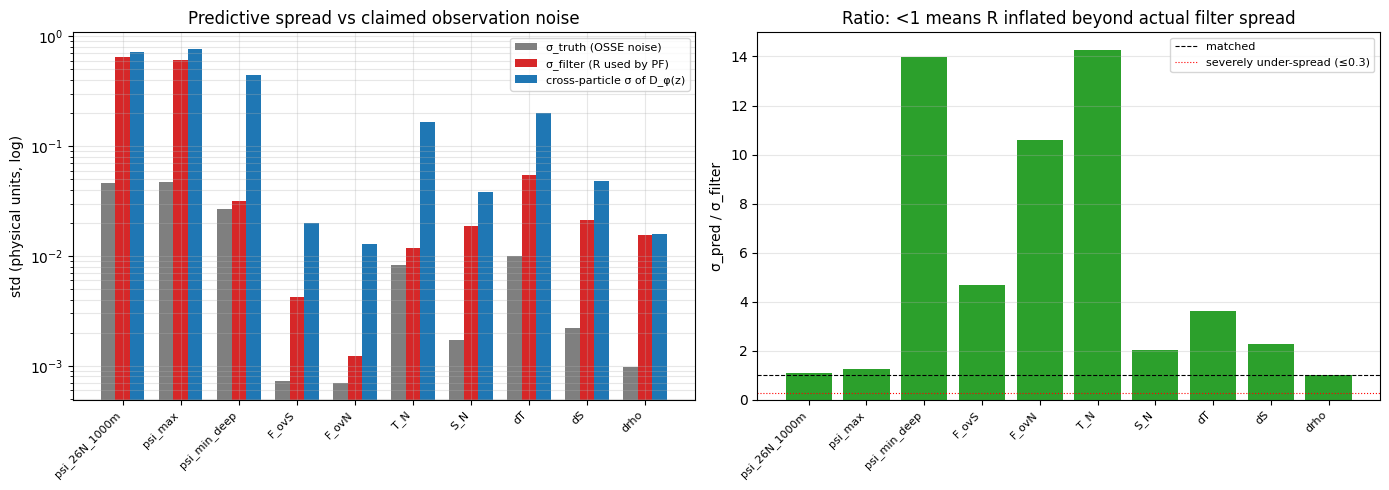

In [ ]:
"""
Diagnostic -- How much do particles actually disagree with each other?

Checks whether the particles' predicted values are spread out enough to match the assumed observation noise. If the particles all agree closely (little spread) while the assumed noise is large, the filter's confidence is artificially inflated, and it ends up trusting a single 'lucky' particle too much -- collapsing the effective number of useful particles.
"""

X_pred_hist = decode_particles(res_stat["Z_pred_hist"])      # (T, Npart, 10)

# Skip t=0: still dominated by the diffuse init (3*sqrt(Q_diag)).
sigma_pred_vs_t = X_pred_hist.std(axis=1)                    # (T, 10)
sigma_pred_mean = sigma_pred_vs_t[1:].mean(axis=0)

print("Cross-particle predictive spread (prior, decoded) vs R:")
print(f"{'variable':15s} {'sig_pred':>11s} {'sig_truth':>11s} {'sig_filter':>11s} "
      f"{'pred/filter':>12s} {'pred/truth':>11s}")
print("-" * 80)
for j, name in enumerate(STATE_NAMES):
    r1 = sigma_pred_mean[j] / sigma_obs_filter[j]
    r2 = sigma_pred_mean[j] / sigma_obs_truth[j]
    print(f"{name:15s} {sigma_pred_mean[j]:11.4e} {sigma_obs_truth[j]:11.4e} "
          f"{sigma_obs_filter[j]:11.4e} {r1:12.3f} {r2:11.3f}")

# Plot: log-bar comparison + ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(physical_dimension); w = 0.25

ax = axes[0]
ax.bar(x - w, sigma_obs_truth,  w, color='tab:gray', label='σ_truth (OSSE noise)')
ax.bar(x, sigma_obs_filter, w, color='tab:red',  label='σ_filter (R used by PF)')
ax.bar(x + w, sigma_pred_mean,  w, color='tab:blue', label='cross-particle σ of D_φ(z)')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(STATE_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('std (physical units, log)')
ax.set_title('Predictive spread vs claimed observation noise')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
ratio = sigma_pred_mean / sigma_obs_filter
colors = ['tab:red' if r < 0.3 else 'tab:orange' if r < 1.0 else 'tab:green' for r in ratio]
ax.bar(x, ratio, color=colors)
ax.axhline(1.0, color='k',   ls='--', lw=0.8, label='matched')
ax.axhline(0.3, color='red', ls=':',  lw=0.8, label='severely under-spread (≤0.3)')
ax.set_xticks(x); ax.set_xticklabels(STATE_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('σ_pred / σ_filter')
ax.set_title('Ratio: <1 means R inflated beyond actual filter spread')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

In [ ]:
"""
Diagnostic -- Re-run with a reduced observation subset

Tests whether restricting the observations to a small, well-reconstructed subset of variables (or even just one) fixes the effective-sample-size problem found in the previous diagnostic.
"""

def run_subset_pf(obs_names, label):
    obs_idx = np.array([STATE_NAMES.index(n) for n in obs_names])
    n_obs   = len(obs_idx)
    Y_sub   = Y_full[:STAT_T][:, obs_idx]
    sig_sub = sigma_obs_filter[obs_idx]

    res = run_bootstrap_pf(
        obs_idx     = obs_idx,
        Y_obs       = Y_sub,
        U_seq       = U_stat,
        z0_particles= z0,
        Q_diag      = Q_diag,
        sigma_obs   = sig_sub,
        ess_thresh  = 0.5,
        seed        = 1,
        save_history= True,
    )

    X_post = decode_particles(res["Z_post_hist"])
    mp, vp = weighted_mean_var(X_post, res["W_post_hist"])
    sp     = np.sqrt(vp)

    # NIS on assimilated obs only
    inv_S = 1.0 / (sig_sub[None, :]**2 + vp[:, obs_idx])
    innov = Y_sub - mp[:, obs_idx]
    NIS   = np.sum(innov**2 * inv_S, axis=1)

    # RMSE on the FULL 10-D state — tells you what extrapolates through latent
    rmse_all = np.sqrt(np.mean((mp - X_window[:STAT_T])**2, axis=0))

    lo, hi = chi2.ppf([0.025, 0.975], df=n_obs)
    print(f"\n=== {label}  (n_obs = {n_obs}) ===")
    print(f"  assimilated: {obs_names}")
    print(f"  resampling events: {res['n_resample']} / {STAT_T}")
    print(f"  mean ESS: {res['ESS_hist'].mean():.1f} / {Npart}  "
          f"(min {res['ESS_hist'].min():.1f})")
    print(f"  NIS: mean={NIS.mean():.2f}  median={np.median(NIS):.2f}  "
          f"E[χ²_{n_obs}]={n_obs}")
    print(f"  fraction inside χ² 95% CI [{lo:.2f}, {hi:.2f}]: "
          f"{((NIS > lo) & (NIS < hi)).mean():.2%}")
    print(f"  Per-var RMSE / σ_filter on FULL state (* = assimilated):")
    for j, name in enumerate(STATE_NAMES):
        marker = '*' if j in obs_idx else ' '
        print(f"    {marker} {name:15s}: {rmse_all[j]/sigma_obs_filter[j]:.2f}")

    return {"res": res, "mp": mp, "sp": sp, "NIS": NIS,
            "obs_idx": obs_idx, "n_obs": n_obs, "label": label}

run_A = run_subset_pf(["psi_26N_1000m", "drho"], "Subset A: ψ_26N + Δρ")
run_B = run_subset_pf(["psi_26N_1000m"],          "Subset B: ψ_26N alone")


=== Subset A: ψ_26N + Δρ  (n_obs = 2) ===
  assimilated: ['psi_26N_1000m', 'drho']
  resampling events: 80 / 400
  mean ESS: 698.4 / 1000  (min 97.4)
  NIS: mean=0.81  median=0.51  E[χ²_2]=2
  fraction inside χ² 95% CI [0.05, 7.38]: 94.25%
  Per-var RMSE / σ_filter on FULL state (* = assimilated):
    * psi_26N_1000m  : 0.92
      psi_max        : 1.01
      psi_min_deep   : 16.26
      F_ovS          : 3.20
      F_ovN          : 10.44
      T_N            : 10.88
      S_N            : 1.17
      dT             : 2.72
      dS             : 1.31
    * drho           : 0.86

=== Subset B: ψ_26N alone  (n_obs = 1) ===
  assimilated: ['psi_26N_1000m']
  resampling events: 59 / 400
  mean ESS: 723.8 / 1000  (min 183.9)
  NIS: mean=0.32  median=0.09  E[χ²_1]=1
  fraction inside χ² 95% CI [0.00, 5.02]: 94.50%
  Per-var RMSE / σ_filter on FULL state (* = assimilated):
    * psi_26N_1000m  : 0.86
      psi_max        : 1.04
      psi_min_deep   : 16.55
      F_ovS          : 3.92
      F_ov

Running stationary PF (years 1..400, n_obs=10) ...

  STATIONARY PF VALIDATION  (n_obs=10, T=400, Npart=1000)
  (A) ESS_min/Npart   =  0.001    [>= 0.10]        FAIL
  (B) NIS mean        =   5.59    [ 3.25, 20.48]  PASS
  (C) NIS in 95% CI   = 73.25%    [>= 85%]         FAIL
  (D) max |ACF_1|     =  0.741    [<= 0.20]        FAIL
  (E) max RMSE/sigma  =  14.23    [<= 1.00]        FAIL
  (F) resample frac   = 33.50%    [5%, 50%]        PASS
  Overall: 2/6 criteria passed  (NEEDS RECALIBRATION)

Per-variable diagnostics:
  variable         RMSE/sigma   |ACF_1|   |ACF_2|
  ---------------  ----------  --------  --------
  psi_26N_1000m         1.087     0.462     0.197
  psi_max               1.123     0.464     0.239
  psi_min_deep         14.227     0.239     0.185
  F_ovS                 2.372     0.271     0.056
  F_ovN                 8.582     0.096     0.148
  T_N                   6.450     0.481     0.022
  S_N                   1.013     0.741     0.463
  dT                    

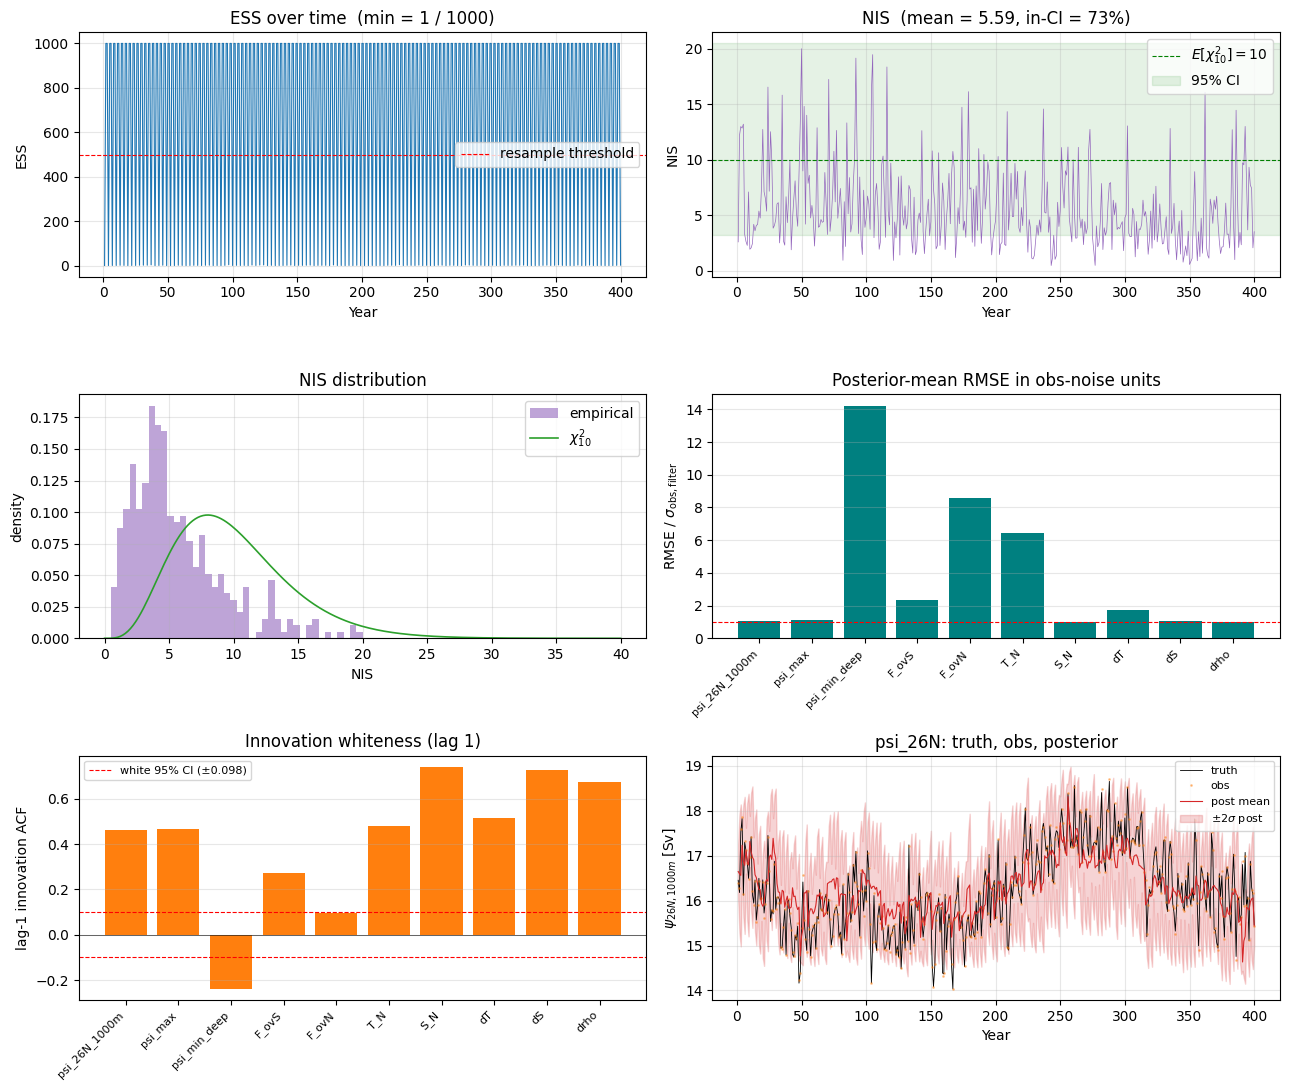


Diagnostics dict 'stationary_pf_diagnostics' available for downstream use.


In [ ]:
"""
Cell 29 (extended) -- Full statistical validation of the particle filter

A more rigorous version of the stable-period validation above: checks the filter's prediction errors against the theoretical reference distribution expected if the noise settings are correct, checks that consecutive errors are uncorrelated, and applies six explicit pass/fail criteria covering effective sample size, calibration, error structure, tracking accuracy, and how often the filter resamples its particles. Passing all six is the bar for calling the filter's settings correctly tuned.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

STAT_T = STATIONARY_END
n_obs  = physical_dimension
years_stat = years_window[:STAT_T]

# --- Initialize particles (diffuse around encoded year-1 state) ---
Npart = 1000
z0 = (
    Z_full[0:1]
    + np.random.default_rng(0).normal(
        0.0, 3.0 * np.sqrt(Q_diag), size=(Npart, latentDim)
    ).astype(np.float32)
)

# --- Run PF on the stationary window with the full obs set ---
print(f"Running stationary PF (years 1..{STAT_T}, n_obs={n_obs}) ...")
res = run_bootstrap_pf(
    obs_idx      = np.arange(n_obs),
    Y_obs        = Y_full   [:STAT_T],
    U_seq        = U_window [:STAT_T],
    z0_particles = z0,
    Q_diag       = Q_diag,
    sigma_obs    = sigma_obs_filter,
    ess_thresh   = 0.5,
    seed         = 1,
    save_history = True,
)

# --- Decode prior and posterior particle clouds ---
X_pred = decode_particles(res["Z_pred_hist"])      # (T, Npart, n_obs)
X_post = decode_particles(res["Z_post_hist"])

# Prior weights at step t = posterior weights at step t-1 (uniform at t=0)
W_post  = res["W_post_hist"]
W_prior = np.empty_like(W_post)
W_prior[0]  = 1.0 / Npart
W_prior[1:] = W_post[:-1]

mean_pred, var_pred = weighted_mean_var(X_pred, W_prior)
mean_post, var_post = weighted_mean_var(X_post, W_post)
std_post = np.sqrt(var_post)

# --- Prior innovations and predictive covariance (diagonal approx.) ---
Y_stat = Y_full[:STAT_T]
innov  = Y_stat - mean_pred                                      # (T, n_obs)
S_diag = var_pred + sigma_obs_filter[None, :] ** 2               # (T, n_obs)
NIS    = np.sum(innov ** 2 / S_diag, axis=1)                     # (T,)

# --- Innovation autocorrelation (whiteness check, lags 1..max_lag) ---
max_lag = 5
nrm   = innov / np.sqrt(S_diag)
nrm   = nrm - nrm.mean(axis=0, keepdims=True)
denom = (nrm ** 2).sum(axis=0) + 1e-30
acf   = np.zeros((max_lag, n_obs))
for L in range(1, max_lag + 1):
    acf[L - 1] = (nrm[L:] * nrm[:-L]).sum(axis=0) / denom

# White-noise 95% confidence bound for ACF on T samples
ci_white = 1.96 / np.sqrt(STAT_T)

# --- Per-variable RMSE on posterior mean ---
rmse_post  = np.sqrt(np.mean((mean_post - X_window[:STAT_T]) ** 2, axis=0))
rmse_units = rmse_post / sigma_obs_filter

# --- Aggregate statistics ---
ess         = res["ESS_hist"]
n_resample  = res["n_resample"]
chi2_lo, chi2_hi = chi2.ppf([0.025, 0.975], df=n_obs)
nis_in_ci   = ((NIS > chi2_lo) & (NIS < chi2_hi)).mean()
resample_fr = n_resample / STAT_T

# --- Pass criteria ---
pass_A = ess.min() / Npart >= 0.10
pass_B = chi2_lo <= NIS.mean() <= chi2_hi
pass_C = nis_in_ci >= 0.85
pass_D = np.abs(acf[0]).max() <= 0.20
pass_E = (rmse_units <= 1.0).all()
pass_F = 0.05 <= resample_fr <= 0.50
flags  = dict(A=pass_A, B=pass_B, C=pass_C, D=pass_D, E=pass_E, F=pass_F)
n_pass = sum(flags.values())

# --- Summary print ---
def _t(b): return "PASS" if b else "FAIL"
print(f"\n{'='*64}")
print(f"  STATIONARY PF VALIDATION  (n_obs={n_obs}, T={STAT_T}, Npart={Npart})")
print(f"{'='*64}")
print(f"  (A) ESS_min/Npart   = {ess.min()/Npart:6.3f}    [>= 0.10]        {_t(pass_A)}")
print(f"  (B) NIS mean        = {NIS.mean():6.2f}    [{chi2_lo:5.2f}, {chi2_hi:5.2f}]  {_t(pass_B)}")
print(f"  (C) NIS in 95% CI   = {nis_in_ci:6.2%}    [>= 85%]         {_t(pass_C)}")
print(f"  (D) max |ACF_1|     = {np.abs(acf[0]).max():6.3f}    [<= 0.20]        {_t(pass_D)}")
print(f"  (E) max RMSE/sigma  = {rmse_units.max():6.2f}    [<= 1.00]        {_t(pass_E)}")
print(f"  (F) resample frac   = {resample_fr:6.2%}    [5%, 50%]        {_t(pass_F)}")
print(f"{'='*64}")
print(f"  Overall: {n_pass}/6 criteria passed  "
      f"({'READY FOR RAMP' if n_pass == 6 else 'NEEDS RECALIBRATION'})")

print(f"\nPer-variable diagnostics:")
print(f"  {'variable':15s}  {'RMSE/sigma':>10s}  {'|ACF_1|':>8s}  {'|ACF_2|':>8s}")
print(f"  {'-'*15}  {'-'*10}  {'-'*8}  {'-'*8}")
for j, name in enumerate(STATE_NAMES):
    print(f"  {name:15s}  {rmse_units[j]:10.3f}  "
          f"{abs(acf[0, j]):8.3f}  {abs(acf[1, j]):8.3f}")

# --- Plot panel ---
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

# (0,0) ESS
axes[0, 0].plot(years_stat, ess, lw=0.8, color="tab:blue")
axes[0, 0].axhline(0.5 * Npart, color="red", ls="--", lw=0.8,
                   label="resample threshold")
axes[0, 0].set_ylabel("ESS"); axes[0, 0].set_xlabel("Year")
axes[0, 0].set_title(f"ESS over time  (min = {ess.min():.0f} / {Npart})")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# (0,1) NIS time series
axes[0, 1].plot(years_stat, NIS, lw=0.5, color="tab:purple")
axes[0, 1].axhline(n_obs,    color="green", ls="--", lw=0.8,
                   label=fr"$E[\chi^2_{{{n_obs}}}]={n_obs}$")
axes[0, 1].axhspan(chi2_lo, chi2_hi, color="green", alpha=0.1, label="95% CI")
axes[0, 1].set_ylabel("NIS"); axes[0, 1].set_xlabel("Year")
axes[0, 1].set_title(f"NIS  (mean = {NIS.mean():.2f}, in-CI = {nis_in_ci:.0%})")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# (1,0) NIS histogram vs chi^2
xx = np.linspace(0, max(40, NIS.max()), 200)
axes[1, 0].hist(NIS, bins=40, density=True, alpha=0.6, color="tab:purple",
                label="empirical")
axes[1, 0].plot(xx, chi2.pdf(xx, df=n_obs), lw=1.2, color="tab:green",
                label=fr"$\chi^2_{{{n_obs}}}$")
axes[1, 0].set_xlabel("NIS"); axes[1, 0].set_ylabel("density")
axes[1, 0].set_title("NIS distribution"); axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# (1,1) RMSE / sigma_obs bars
axes[1, 1].bar(np.arange(n_obs), rmse_units, color="teal")
axes[1, 1].axhline(1.0, color="red", ls="--", lw=0.8)
axes[1, 1].set_xticks(np.arange(n_obs))
axes[1, 1].set_xticklabels(STATE_NAMES, rotation=45, ha="right", fontsize=8)
axes[1, 1].set_ylabel(r"RMSE / $\sigma_{\rm obs,filter}$")
axes[1, 1].set_title("Posterior-mean RMSE in obs-noise units")
axes[1, 1].grid(alpha=0.3, axis="y")

# (2,0) Innovation autocorrelation at lag 1
axes[2, 0].bar(np.arange(n_obs), acf[0], color="tab:orange")
axes[2, 0].axhline( ci_white, color="red", ls="--", lw=0.8,
                    label=f"white 95% CI (±{ci_white:.3f})")
axes[2, 0].axhline(-ci_white, color="red", ls="--", lw=0.8)
axes[2, 0].axhline(0.0, color="k", lw=0.4)
axes[2, 0].set_xticks(np.arange(n_obs))
axes[2, 0].set_xticklabels(STATE_NAMES, rotation=45, ha="right", fontsize=8)
axes[2, 0].set_ylabel("lag-1 innovation ACF")
axes[2, 0].set_title("Innovation whiteness (lag 1)")
axes[2, 0].legend(fontsize=8); axes[2, 0].grid(alpha=0.3, axis="y")

# (2,1) Posterior tracking on psi_26N
psi_idx = STATE_NAMES.index("psi_26N_1000m")
axes[2, 1].plot(years_stat, X_window[:STAT_T, psi_idx], lw=0.6, color="k",
                label="truth")
axes[2, 1].plot(years_stat, Y_stat[:, psi_idx], lw=0, marker=".", ms=2,
                color="tab:orange", alpha=0.4, label="obs")
axes[2, 1].plot(years_stat, mean_post[:, psi_idx], lw=0.8, color="tab:red",
                label="post mean")
axes[2, 1].fill_between(
    years_stat,
    mean_post[:, psi_idx] - 2 * std_post[:, psi_idx],
    mean_post[:, psi_idx] + 2 * std_post[:, psi_idx],
    color="tab:red", alpha=0.2, label=r"$\pm 2\sigma$ post"
)
axes[2, 1].set_ylabel(r"$\psi_{26N,1000m}$ [Sv]")
axes[2, 1].set_xlabel("Year")
axes[2, 1].set_title("psi_26N: truth, obs, posterior")
axes[2, 1].legend(fontsize=8); axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR_SEC}/PF_diagnostics_use_this.png", dpi = 200, bbox_inches = "tight")
plt.show()

# --- Persist diagnostics for the report ---
stationary_pf_diagnostics = {
    "n_obs":       n_obs,
    "T":           STAT_T,
    "Npart":       Npart,
    "ess_min":     float(ess.min()),
    "nis_mean":    float(NIS.mean()),
    "nis_in_ci":   float(nis_in_ci),
    "max_acf1":    float(np.abs(acf[0]).max()),
    "rmse_units":  rmse_units,
    "n_resample":  n_resample,
    "resample_fr": resample_fr,
    "pass_flags":  flags,
    "passed":      n_pass == 6,
}
print(f"\nDiagnostics dict 'stationary_pf_diagnostics' available for downstream use.")

In [ ]:
"""
Cell 29c-A -- Sweep over which variables to observe (expensive)

A large, expensive experiment that tries out nearly every combination of observed variables (up to a chosen maximum number at once), each repeated over multiple random seeds, to see which combinations give the best filter performance. Also tests a few combinations chosen for physical relevance as a baseline. Results are saved to disk so the analysis in the next cell can be redone without repeating this expensive sweep.
"""

# --- parameters (the only knobs you need) ----------------------------------
SEEDS       = (1, 2, 3, 5, 7)
MAX_BUDGET  = 2                          # set to 3 if you can afford ~7 h
SWEEP_FILE  = OUT_DIR / "obs_subset_sweep.pkl"

# --- single-seed metric (augmented with per-variable real/S) ---------------
def subset_metrics_one_seed(obs_names, seed):
    obs_idx_sub = np.array([STATE_NAMES.index(n) for n in obs_names], dtype=int)
    n_obs_sub = len(obs_idx_sub)
    Y_sub   = Y_full[:STAT_T, obs_idx_sub]
    sig_sub = sigma_obs_filter[obs_idx_sub]

    res = run_bootstrap_pf(
        obs_idx              = obs_idx_sub,
        Y_obs                = Y_sub,
        U_seq                = U_stat,
        z0_particles         = z0,
        Q_diag               = Q_diag,
        sigma_obs            = sig_sub,
        ess_thresh           = 0.5,
        seed                 = seed,
        save_history         = True,
        guided_prop          = True,
        nudge_gamma          = 0.10,
        nudge_alpha          = 1.0,
        jitter               = 1e-5,
        sigma_model_frac     = 0.1,
        rejuv_after_resample = True,
        rejuv_scale          = 0.02,
        rejuv_floor          = 0.05,
    )

    X_pred = decode_particles(res["Z_pred_hist"])
    X_post = decode_particles(res["Z_post_hist"])
    W_post  = res["W_post_hist"]
    W_prior = build_prior_weights_from_posterior(W_post)
    mean_pred, var_pred = weighted_mean_var(X_pred, W_prior)
    mean_post, _        = weighted_mean_var(X_post, W_post)

    innov  = Y_sub - mean_pred[:, obs_idx_sub]
    S_diag = np.maximum(var_pred[:, obs_idx_sub] + sig_sub[None, :] ** 2, 1e-12)
    NIS    = np.sum(innov ** 2 / S_diag, axis=1)

    # Per-variable ⟨real⟩/⟨S⟩ within this subset's PF run.
    # Note: this is the variable-level quantity. Averaged over the subset's
    # observed variables it equals NIS/n_obs by construction, so cal_dev_mean
    # carries genuinely new information only as a *dispersion* statistic.
    real_over_S_per_var = (innov ** 2 / S_diag).mean(axis=0)        # (n_obs_sub,)
    cal_dev_per_var     = np.abs(real_over_S_per_var - 1.0)
    cal_dev_mean        = float(cal_dev_per_var.mean())
    cal_dev_max         = float(cal_dev_per_var.max())

    rmse_full = np.sqrt(np.mean((mean_post - X_window[:STAT_T]) ** 2, axis=0))
    rmse_units_full = rmse_full / sigma_obs_filter

    return dict(
        n_obs        = n_obs_sub,
        ess_mean     = float(res["ESS_hist"].mean()) / Npart,
        ess_min      = float(res["ESS_hist"].min())  / Npart,
        nis_per_obs  = float(NIS.mean() / n_obs_sub),
        med_rmse     = float(np.nanmedian(rmse_units_full)),
        max_rmse     = float(np.nanmax(rmse_units_full)),
        real_over_S  = real_over_S_per_var.astype(float).tolist(),
        cal_dev_mean = cal_dev_mean,
        cal_dev_max  = cal_dev_max,
    )

# --- multi-seed aggregator (with per-variable seed-mean) -------------------
def subset_metrics_multiseed(obs_names, label, seeds=SEEDS):
    per_seed = [subset_metrics_one_seed(obs_names, s) for s in seeds]
    out = dict(label=label,
               obs_names=tuple(obs_names),
               n_obs=per_seed[0]["n_obs"],
               per_seed=per_seed)
    for k in ("ess_mean", "nis_per_obs", "med_rmse", "max_rmse",
              "cal_dev_mean", "cal_dev_max"):
        out[k]          = float(np.mean([r[k] for r in per_seed]))
        out[k + "_std"] = float(np.std ([r[k] for r in per_seed], ddof=1))
    # Per-variable seed mean (variables are ordered as obs_names)
    rovs_stack = np.array([r["real_over_S"] for r in per_seed])     # (S, n_obs_sub)
    out["real_over_S"]     = rovs_stack.mean(axis=0).tolist()
    out["real_over_S_std"] = rovs_stack.std(axis=0, ddof=1).tolist()
    return out

# --- candidates ------------------------------------------------------------
sweep_candidates = []
for k in range(1, MAX_BUDGET + 1):
    for combo in itertools.combinations(STATE_NAMES, k):
        sweep_candidates.append((f"size{k}: {','.join(combo)}", combo))

named_subsets = [
    ("Core AMOC + density",
     ("psi_26N_1000m", "psi_max", "drho")),
    ("AMOC + thermohaline gradients",
     ("psi_26N_1000m", "psi_max", "dT", "dS", "drho")),
    ("Hydrography only",
     ("T_N", "S_N", "dT", "dS", "drho")),
]

n_total = (len(sweep_candidates) + len(named_subsets)) * len(SEEDS)
print(f"Sweep: {len(sweep_candidates)} subsets (size 1..{MAX_BUDGET})")
print(f"Named: {len(named_subsets)} baselines (size ≥ 3)")
print(f"Seeds: {SEEDS}")
print(f"Total PF runs: {n_total}")

records       = []
named_records = []
for i, (label, names) in enumerate(sweep_candidates):
    if i % 5 == 0:
        print(f"  sweep [{i:>3d}/{len(sweep_candidates)}] {label}")
    records.append(subset_metrics_multiseed(list(names), label))

for label, names in named_subsets:
    print(f"  named  {label}")
    named_records.append(subset_metrics_multiseed(list(names), label))

# --- save so Cell 29c-B is cheap ------------------------------------------
with open(SWEEP_FILE, "wb") as f:
    pickle.dump(dict(
        records=records, named_records=named_records,
        SEEDS=SEEDS, MAX_BUDGET=MAX_BUDGET, STAT_T=STAT_T,
        STATE_NAMES=list(STATE_NAMES),
    ), f)
print(f"\nSaved sweep: {SWEEP_FILE}  ({SWEEP_FILE.stat().st_size/1024:.1f} KB)")

Sweep: 55 subsets (size 1..2)
Named: 3 baselines (size ≥ 3)
Seeds: (1, 2, 3, 5, 7)
Total PF runs: 290
  sweep [  0/55] size1: psi_26N_1000m
  sweep [  5/55] size1: T_N


KeyboardInterrupt: 

In [ ]:
"""
Cell 29c-B -- Ranking observation subsets by cost, accuracy and calibration

Filters out any observation subset that fails basic health checks (too few effective particles, or badly miscalibrated uncertainty), then ranks the surviving subsets on three things at once: how many variables need to be observed, how accurate the resulting state estimate is, and how well-calibrated each individual variable is (not just on average). This last point matters because a subset can look fine on average while actually being very over-confident on some variables and very under-confident on others; a subset that's consistently well calibrated is preferred over one that only averages out to a good number. Subsets are also checked for how consistently they perform across different random seeds, to flag ones that are good only some of the time.
"""

# --- knobs (cheap to retune; no re-PF) ------------------------------------
ESS_FLOOR     = 0.50
ALPHA_CI      = 0.05     # 95% χ² band
ROBUST_THRESH = 0.60     # fraction of seeds required for "robust"

with open(SWEEP_FILE, "rb") as f:
    sweep = pickle.load(f)
records       = sweep["records"]
named_records = sweep["named_records"]
T             = sweep["STAT_T"]
N_SEEDS       = len(sweep["SEEDS"])

# --- helpers --------------------------------------------------------------
def chi2_band(n_obs, T=T, alpha=ALPHA_CI):
    """95% consistency band for time-averaged NIS / n_obs.
    Bar-Shalom, Li & Kirubarajan (2001) Eq. 5.4.2-2."""
    dof = n_obs * T
    return (chi2.ppf(alpha/2,   dof) / dof,
            chi2.ppf(1-alpha/2, dof) / dof)

def is_feasible(ess_mean, nis_per_obs, n_obs):
    if ess_mean < ESS_FLOOR:
        return False
    lo, hi = chi2_band(n_obs)
    return lo <= nis_per_obs <= hi

def pareto_mask_nd(pts):
    """N-dimensional Pareto front (all axes minimized)."""
    pts = np.asarray(pts, dtype=float)
    n = len(pts)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        diff = pts - pts[i]
        not_worse        = (diff <= 0).all(axis=1)
        strictly_better  = (diff <  0).any(axis=1)
        dominated_by_any = not_worse & strictly_better
        dominated_by_any[i] = False
        if dominated_by_any.any():
            keep[i] = False
    return keep

def arr(rs, k): return np.array([r[k] for r in rs])

# --- mean-metric arrays ---------------------------------------------------
nis_n     = arr(records, "nis_per_obs")
ess_mean  = arr(records, "ess_mean")
med_rmse  = arr(records, "med_rmse")
cal_dev   = arr(records, "cal_dev_mean")
cal_devx  = arr(records, "cal_dev_max")
n_obs_arr = arr(records, "n_obs").astype(int)

feas_mean = np.array([
    is_feasible(ess_mean[i], nis_n[i], n_obs_arr[i])
    for i in range(len(records))
])

# --- 3-D Pareto front on (n_obs, med_rmse, cal_dev_mean) among feasible ---
front_mean = np.zeros(len(records), dtype=bool)
if feas_mean.any():
    pts3 = np.column_stack([n_obs_arr[feas_mean],
                            med_rmse[feas_mean],
                            cal_dev[feas_mean]])
    front_mean[feas_mean] = pareto_mask_nd(pts3)

# --- per-seed front  → robustness (also 3-D) ------------------------------
def per_seed_front(seed_i):
    cal_s   = np.array([r["per_seed"][seed_i]["nis_per_obs"]  for r in records])
    rmse_s  = np.array([r["per_seed"][seed_i]["med_rmse"]     for r in records])
    ess_s   = np.array([r["per_seed"][seed_i]["ess_mean"]     for r in records])
    cdev_s  = np.array([r["per_seed"][seed_i]["cal_dev_mean"] for r in records])
    feas_s  = np.array([
        is_feasible(ess_s[i], cal_s[i], n_obs_arr[i])
        for i in range(len(records))
    ])
    f = np.zeros(len(records), dtype=bool)
    if feas_s.any():
        f[feas_s] = pareto_mask_nd(np.column_stack([n_obs_arr[feas_s],
                                                    rmse_s[feas_s],
                                                    cdev_s[feas_s]]))
    return f

robustness = np.mean([per_seed_front(s) for s in range(N_SEEDS)], axis=0)

# --- summary --------------------------------------------------------------
print(f"χ² band at α={ALPHA_CI:.2f}, T={T}:")
for k in range(1, sweep["MAX_BUDGET"] + 1):
    lo, hi = chi2_band(k)
    print(f"  n_obs={k}: [{lo:.3f}, {hi:.3f}]")
print()

print(f"Feasibility  (ESS_mean/Npart ≥ {ESS_FLOOR} and NIS/n_obs in χ²-band):")
for k in range(1, sweep["MAX_BUDGET"] + 1):
    sel = (n_obs_arr == k)
    print(f"  size {k}:  {feas_mean[sel].sum()}/{sel.sum()} feasible")
print(f"  total:   {feas_mean.sum()}/{len(records)} feasible\n")

# --- per-budget winners (rank by cal_dev_mean among NIS-feasible) ---------
print(f"{'budget':>6s}  {'best_label':40s}  {'med_rmse':>9s}  "
      f"{'NIS/n':>6s}  {'cal_dev':>7s}  {'ESS':>5s}  {'rob':>5s}")
print("-" * 100)
for k in range(1, sweep["MAX_BUDGET"] + 1):
    sel = (n_obs_arr == k) & feas_mean
    if not sel.any():
        print(f"  {k:4d}    (no feasible subset)")
        continue
    idxs = np.where(sel)[0]
    # tie-break: lowest cal_dev_mean among feasible at this budget
    best = idxs[np.argmin(cal_dev[idxs] + 0.01 * med_rmse[idxs])]
    r = records[best]
    print(f"  {k:4d}    {r['label'][:40]:40s}  "
          f"{r['med_rmse']:5.2f}±{r['med_rmse_std']:4.2f}  "
          f"{r['nis_per_obs']:5.2f}  "
          f"{r['cal_dev_mean']:7.3f}  "
          f"{r['ess_mean']:5.2f}  "
          f"{robustness[best]:5.2f}")

# --- Pareto front table ---------------------------------------------------
print(f"\nGlobal 3-D Pareto front on (n_obs, med_RMSE/σ, cal_dev_mean):")
print(f"{'n':>2s}  {'med_rmse':>14s}  {'NIS/n':>10s}  {'cal_dev':>7s}  "
      f"{'ESS':>5s}  {'rob':>5s}  label")
print("-" * 110)
order = np.where(front_mean)[0][np.argsort(med_rmse[front_mean])]
for idx in order:
    r = records[idx]
    print(f"{r['n_obs']:2d}  "
          f"{r['med_rmse']:5.2f} ± {r['med_rmse_std']:4.2f}  "
          f"{r['nis_per_obs']:5.2f}±{r['nis_per_obs_std']:4.2f}  "
          f"{r['cal_dev_mean']:7.3f}  "
          f"{r['ess_mean']:5.2f}  "
          f"{robustness[idx]:5.2f}  {r['label']}")

# --- named subsets as baselines -------------------------------------------
print(f"\nNamed physically motivated baselines (NOT in Pareto pool):")
print(f"{'n':>2s}  {'med_rmse':>14s}  {'NIS/n':>10s}  {'cal_dev':>7s}  "
      f"{'ESS':>5s}  {'feas?':>5s}  label")
print("-" * 100)
for r in named_records:
    feas = is_feasible(r["ess_mean"], r["nis_per_obs"], r["n_obs"])
    print(f"{r['n_obs']:2d}  "
          f"{r['med_rmse']:5.2f} ± {r['med_rmse_std']:4.2f}  "
          f"{r['nis_per_obs']:5.2f}±{r['nis_per_obs_std']:4.2f}  "
          f"{r['cal_dev_mean']:7.3f}  "
          f"{r['ess_mean']:5.2f}  "
          f"{'YES' if feas else 'no':>5s}  {r['label']}")

# --- figures --------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# (a) primary obs-design plot: (n_obs, med_rmse), feasibility marked
ax = axes[0, 0]
ax.errorbar(n_obs_arr[~feas_mean], med_rmse[~feas_mean],
            yerr=arr(records, "med_rmse_std")[~feas_mean],
            fmt="x", color="0.6", alpha=0.5, label="infeasible", zorder=1)
ax.errorbar(n_obs_arr[feas_mean & ~front_mean],
            med_rmse[feas_mean & ~front_mean],
            yerr=arr(records, "med_rmse_std")[feas_mean & ~front_mean],
            fmt="o", color="C0", alpha=0.7, label="feasible", zorder=2)
ax.errorbar(n_obs_arr[front_mean], med_rmse[front_mean],
            yerr=arr(records, "med_rmse_std")[front_mean],
            fmt="o", mfc="white", mec="red", mew=1.8, color="red",
            ms=10, label="Pareto front (3-D)", zorder=4)
for r in named_records:
    feas = is_feasible(r["ess_mean"], r["nis_per_obs"], r["n_obs"])
    ax.errorbar([r["n_obs"]], [r["med_rmse"]], yerr=[r["med_rmse_std"]],
                fmt="s", color="C2" if feas else "C3", ms=9, zorder=3)
    ax.annotate(r["label"], (r["n_obs"], r["med_rmse"]),
                xytext=(8, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("n_obs"); ax.set_ylabel(r"median RMSE/$\sigma$ on full state")
ax.set_yscale("log"); ax.set_title("Observation-design Pareto (panel a)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

# (b) calibration constraint: NIS/n vs med_rmse, χ²-band shaded
ax = axes[0, 1]
ax.scatter(nis_n[~feas_mean], med_rmse[~feas_mean],
           c=n_obs_arr[~feas_mean], cmap="viridis", marker="x", alpha=0.4)
sc = ax.scatter(nis_n[feas_mean], med_rmse[feas_mean],
                c=n_obs_arr[feas_mean], cmap="viridis", s=40,
                edgecolor="black", lw=0.5)
for k in np.unique(n_obs_arr):
    lo, hi = chi2_band(k)
    ax.axvspan(lo, hi, color=plt.cm.viridis((k-1)/max(1, n_obs_arr.max()-1)),
               alpha=0.08)
ax.axvline(1.0, color="k", lw=0.7, ls="--")
plt.colorbar(sc, ax=ax, label="n_obs")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$NIS / n_{\rm obs}$  (1 = consistent)")
ax.set_ylabel(r"median RMSE/$\sigma$"); ax.set_title("Calibration constraint")
ax.grid(alpha=0.3, which="both")

# (c) NEW: third Pareto axis — cal_dev_mean vs med_rmse
ax = axes[0, 2]
ax.scatter(cal_dev[~feas_mean], med_rmse[~feas_mean],
           c="0.6", marker="x", alpha=0.4, label="infeasible")
sc = ax.scatter(cal_dev[feas_mean & ~front_mean],
                med_rmse[feas_mean & ~front_mean],
                c=n_obs_arr[feas_mean & ~front_mean], cmap="viridis",
                s=40, edgecolor="black", lw=0.5,
                label="feasible")
ax.scatter(cal_dev[front_mean], med_rmse[front_mean],
           s=120, facecolor="none", edgecolor="red", lw=1.8,
           label="Pareto front", zorder=5)
plt.colorbar(sc, ax=ax, label="n_obs")
ax.set_yscale("log")
ax.set_xlabel(r"cal_dev_mean  $= \langle |\langle\mathrm{real}\rangle/\langle S\rangle - 1|\rangle_j$")
ax.set_ylabel(r"median RMSE/$\sigma$")
ax.set_title("Per-variable calibration axis")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

# (d) ESS feasibility view (unchanged)
ax = axes[1, 0]
ax.scatter(ess_mean[~feas_mean], med_rmse[~feas_mean],
           c="0.6", marker="x", alpha=0.5)
sc = ax.scatter(ess_mean[feas_mean], med_rmse[feas_mean],
                c=n_obs_arr[feas_mean], cmap="viridis", s=40,
                edgecolor="black", lw=0.5)
ax.axvline(ESS_FLOOR, color="r", ls="--", label=f"ESS floor = {ESS_FLOOR}")
plt.colorbar(sc, ax=ax, label="n_obs")
ax.set_yscale("log"); ax.set_xlabel("ESS_mean / Npart")
ax.set_ylabel(r"median RMSE/$\sigma$"); ax.set_title("Filter health constraint")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

# (e) robustness across seeds for top-20 by med_rmse
ax = axes[1, 1]
top_order = np.argsort(med_rmse)[:20]
labels_short = [records[i]["label"].replace("size1: ", "")
                                    .replace("size2: ", "")[:24]
                for i in top_order]
colors = ["C2" if robustness[i] >= ROBUST_THRESH else "C3" for i in top_order]
ax.barh(range(len(top_order)), robustness[top_order],
        color=colors, alpha=0.75)
ax.axvline(ROBUST_THRESH, color="k", ls="--", lw=0.7,
           label=f"threshold = {ROBUST_THRESH}")
ax.set_yticks(range(len(top_order)))
ax.set_yticklabels(labels_short, fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 1.05); ax.set_xlabel("fraction of seeds on Pareto front")
ax.set_title("Frontier robustness (top-20 by med_RMSE)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="x")

# (f) NEW: per-variable ⟨real⟩/⟨S⟩ breakdown for the Pareto-front subsets
ax = axes[1, 2]
front_idxs = np.where(front_mean)[0][np.argsort(med_rmse[front_mean])]
y_pos = []
for row, idx in enumerate(front_idxs):
    r = records[idx]
    names = list(r["obs_names"])
    rovs  = np.array(r["real_over_S"])
    rovs_s = np.array(r["real_over_S_std"])
    for j, nm in enumerate(names):
        # color by deviation from 1
        dev = abs(rovs[j] - 1.0)
        col = ("C2" if dev < 0.2 else ("C0" if dev < 0.5 else "C3"))
        ax.errorbar([rovs[j]], [row], xerr=[rovs_s[j]],
                    fmt="o", color=col, ms=6, capsize=2)
        ax.annotate(nm.replace("psi_", "ψ_"), (rovs[j], row),
                    xytext=(4, -2), textcoords="offset points", fontsize=6.5,
                    alpha=0.9)
    y_pos.append(r["label"][:30])
ax.axvline(1.0, color="k", ls="--", lw=0.8, label="calibrated")
ax.axvspan(0.8, 1.2, color="C2", alpha=0.10, label="|dev| < 0.2")
ax.set_yticks(range(len(front_idxs)))
ax.set_yticklabels(y_pos, fontsize=7)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel(r"per-variable  $\langle\mathrm{real}\rangle/\langle S\rangle$")
ax.set_title("Within-subset per-variable calibration\n(Pareto-front subsets)")
ax.legend(fontsize=7, loc="upper right")
ax.grid(alpha=0.3, which="both", axis="x")

plt.tight_layout()
plt.savefig(f"{OUT_DIR_SEC}/Pareto.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nFront size (mean metrics, 3-D): {int(front_mean.sum())} / "
      f"{int(feas_mean.sum())} feasible")
print(f"Robust front (≥{ROBUST_THRESH:.0%} of seeds): "
      f"{int((front_mean & (robustness >= ROBUST_THRESH)).sum())}")

## 7. Choosing the Early-Warning Indicators

Before running the early-warning analyses, this section decides which physical variable(s) to actually apply them to, based on signal strength, reconstruction quality, and how cleanly each variable separates the stable and collapsed states.


In [ ]:
"""
Cell 30 -- Sweep autoencoder settings to improve calibration

Retrains the autoencoder and dynamics model from scratch under a range of settings (varying the latent-space size and how much each variable counts in the reconstruction loss), and checks how the model's implied prediction uncertainty compares to the assumed observation uncertainty for the worst-behaved variables. The goal is to find the simplest change that brings those variables back into reasonable calibration.
"""

import time

# ----------------------------------------------------------------------------
# Sweep configurations
# ----------------------------------------------------------------------------
SWEEP_CONFIGS = [
    {"L": 4, "weights": [1]*physical_dimension, "jac_lambda": 1e-2, "denoise": 0.0, "tag": "L=4 baseline"},
    #{"L": 6, "weights": [1]*9, "jac_lambda": 0.0, "denoise": 0.0, "tag": "L=6 baseline"},
    #{"L": 8, "weights": [1]*9, "jac_lambda": 0.0, "denoise": 0.0, "tag": "L=8 baseline"},

    {"L": 4, "weights": [1,1,1,4,4,4,2,1,1,1], "jac_lambda": 1e-3, "denoise": 0.0, "tag": "L=4 weighted problem vars"},
    #{"L": 6, "weights": [1,1,4,4,4,2,1,1,1], "jac_lambda": 0.0, "denoise": 0.0, "tag": "L=6 weighted problem vars"},

    {"L": 4, "weights": [1]*physical_dimension, "jac_lambda": 5e-2, "denoise": 0.0, "tag": "L=4 tiny contractive"},
    #{"L": 6, "weights": [1]*9, "jac_lambda": 1e-5, "denoise": 0.0, "tag": "L=6 tiny contractive"},
]

AE_EPOCHS_SWEEP  = 5000
DYN_EPOCHS_SWEEP = 5000

N_PERT  = 500     # particles per truth point in σ_pred measurement
N_TIMES = 200     # subsample of stationary years for σ_pred average

EPS_SIGMA = 1e-12


# ----------------------------------------------------------------------------
# Train one AE + dynNet configuration and return diagnostics
# ----------------------------------------------------------------------------
def build_and_train(
    L,
    weights_np,
    ae_epochs,
    dyn_epochs,
    denoise=0.0,
    jac_lambda=0.0,
    ae_seed=42,
    dyn_seed=43,
    verbose=True
):
    weights_np = np.asarray(weights_np, dtype=np.float32)

    assert len(weights_np) == physical_dimension, (
        f"weights length {len(weights_np)} does not match "
        f"physical_dimension={physical_dimension}"
    )

    weights = torch.from_numpy(weights_np).to(device)

    # ------------------------------------------------------------------------
    # 1. Autoencoder
    # ------------------------------------------------------------------------
    torch.manual_seed(ae_seed)

    enc = nn.Sequential(
        nn.Linear(physical_dimension, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, L),).to(device)

    dec = nn.Sequential(
        nn.Linear(L, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, physical_dimension),).to(device)

    opt_ae = Adam(itertools.chain(enc.parameters(), dec.parameters()), lr=ae_lr)

    enc.train()
    dec.train()

    for ep in range(1, ae_epochs + 1):
        idx = torch.randint(0, XN_train_t.shape[0], (ae_bs,), device=device)
        x = XN_train_t[idx]

        # Encode once.
        z = enc(x)

        # Optional latent denoising.
        # This now actually affects the reconstruction path.
        if denoise > 0:
            z_used = z + torch.randn_like(z) * denoise
        else:
            z_used = z

        xrec = dec(z_used)

        # Weighted reconstruction loss.
        recon_loss = torch.mean(torch.sum((x - xrec) ** 2 * weights, dim=1))
        loss = recon_loss

        # --------------------------------------------------------------------
        # Decoder-Jacobian contractive penalty
        # --------------------------------------------------------------------
        # This penalizes sensitivity of decoded physical variables to small
        # perturbations in latent space:
        #
        #     || ∂D(z) / ∂z ||_F^2
        #
        # This is directly connected to the σ_pred inflation diagnostic:
        # if the decoder Jacobian is large, small Q perturbations in z become
        # large perturbations in decoded physical space.
        # --------------------------------------------------------------------
        jac_pen_value = 0.0

        if jac_lambda > 0:
            z_jac = z.detach().requires_grad_(True)
            x_jac = dec(z_jac)

            jac_pen = 0.0

            for jj in range(physical_dimension):
                grad_j = torch.autograd.grad(x_jac[:, jj].sum(),z_jac,create_graph=True,retain_graph=True)[0]

                jac_pen = jac_pen + grad_j.pow(2).sum(dim=1).mean()

            jac_pen = jac_pen / physical_dimension
            loss = recon_loss + jac_lambda * jac_pen
            jac_pen_value = jac_pen.item()

        opt_ae.zero_grad(set_to_none=True)
        loss.backward()
        opt_ae.step()

        if verbose and ep % 1000 == 0:
            print(
                f"    AE  ep {ep:5d}/{ae_epochs}  "
                f"loss={loss.item():.3e}  "
                f"recon={recon_loss.item():.3e}  "
                f"jac={jac_pen_value:.3e}"
            )

    enc.eval()
    dec.eval()

    # ------------------------------------------------------------------------
    # 2. Encode full window
    # ------------------------------------------------------------------------
    with torch.no_grad():
        Z_full_l = enc(XN_full_t).cpu().numpy()

    # ------------------------------------------------------------------------
    # 3. Build one-step latent dynamics training pairs
    # ------------------------------------------------------------------------
    pair_years = years_window[:-1]

    t_in_hold = ((pair_years >= HOLDOUT_START)& (pair_years <= HOLDOUT_END))

    tp1_in_hold = ((pair_years + 1 >= HOLDOUT_START)& (pair_years + 1 <= HOLDOUT_END))

    train_pair_mask = (~t_in_hold) & (~tp1_in_hold)

    Z_t_tr_l = torch.from_numpy(Z_full_l[:-1][train_pair_mask].astype(np.float32)).to(device)

    Z_tp1_tr_l = torch.from_numpy(Z_full_l[1:][train_pair_mask].astype(np.float32)).to(device)

    U_t_tr_l = torch.from_numpy(U_window[:-1][train_pair_mask].astype(np.float32)).to(device)

    # ------------------------------------------------------------------------
    # 4. dynNet
    # ------------------------------------------------------------------------
    torch.manual_seed(dyn_seed)

    dyn = nn.Sequential(
        nn.Linear(L + u_dim, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden),    nn.Tanh(),
        nn.Linear(hidden, L),
    ).to(device)

    with torch.no_grad():
        dyn[-1].weight.mul_(0.01)
        dyn[-1].bias.zero_()

    opt_dyn = Adam(dyn.parameters(), lr=dyn_lr)

    dyn.train()

    for ep in range(1, dyn_epochs + 1):
        idx = torch.randint(0, Z_t_tr_l.shape[0], (dyn_bs,), device=device)

        z = Z_t_tr_l[idx]
        zp1 = Z_tp1_tr_l[idx]
        u = U_t_tr_l[idx]

        delta = dyn(torch.cat([z, u], dim=1))
        z_pred = z + delta

        loss_dyn = torch.mean(torch.sum((z_pred - zp1) ** 2, dim=1))

        opt_dyn.zero_grad(set_to_none=True)
        loss_dyn.backward()
        torch.nn.utils.clip_grad_norm_(dyn.parameters(), clip_norm)
        opt_dyn.step()

        if verbose and ep % 1000 == 0:
            print(f"    dyn ep {ep:5d}/{dyn_epochs}  "
                f"loss={loss_dyn.item():.3e}")

    dyn.eval()

    # ------------------------------------------------------------------------
    # 5. Estimate Q from stationary one-step latent residuals
    # ------------------------------------------------------------------------
    stat_idx_l = np.where(years_window <= STATIONARY_END)[0]
    spi = stat_idx_l[:-1]

    with torch.no_grad():
        z_s = torch.from_numpy(Z_full_l[spi].astype(np.float32)).to(device)

        u_s = torch.from_numpy(U_window[spi].astype(np.float32)).to(device)

        delta_pred = dyn(torch.cat([z_s, u_s], dim=1)).cpu().numpy()

    z_pred = Z_full_l[spi] + delta_pred
    resid = Z_full_l[spi + 1] - z_pred

    Q_diag_l = resid.var(axis=0).astype(np.float32)
    Q_diag_l = np.maximum(Q_diag_l, EPS_SIGMA).astype(np.float32)

    sigma_proc_l = np.sqrt(Q_diag_l).astype(np.float32)

    # ------------------------------------------------------------------------
    # 6. σ_pred via Q-perturbation around encoded truth latents
    # ------------------------------------------------------------------------
    rng = np.random.default_rng(0)

    n_eval = min(N_TIMES, STATIONARY_END)
    t_eval = rng.choice(STATIONARY_END, size=n_eval, replace=False)

    sigma_pred_per_t = np.zeros((n_eval, physical_dimension), dtype=np.float32)

    with torch.no_grad():
        for i, t in enumerate(t_eval):
            zc = Z_full_l[t]

            eta = rng.normal(loc=0.0,scale=sigma_proc_l,size=(N_PERT, L)).astype(np.float32)

            z_pert = zc[None, :] + eta

            xn = dec(torch.from_numpy(z_pert).to(device)).cpu().numpy()

            x_phys = xn * sigma_train + mu_train
            sigma_pred_per_t[i] = x_phys.std(axis=0)

    sigma_pred_l = sigma_pred_per_t.mean(axis=0).astype(np.float32)

    # ------------------------------------------------------------------------
    # 7. σ_obs_filter using truth variability + reconstruction RMSE
    # ------------------------------------------------------------------------
    with torch.no_grad():
        Xrec_stat_n = dec(enc(XN_full_t[:STATIONARY_END])).cpu().numpy()

        Xrec_val_n = dec(enc(XN_val_t)).cpu().numpy()

    Xrec_stat = Xrec_stat_n * sigma_train + mu_train
    Xrec_val = Xrec_val_n * sigma_train + mu_train

    recon_stat = np.sqrt(np.mean((Xrec_stat - X_window[:STATIONARY_END]) ** 2,axis=0)).astype(np.float32)

    recon_val = np.sqrt(np.mean((Xrec_val - X_val_raw) ** 2,axis=0)).astype(np.float32)

    sig_truth = (ALPHA_OBS * X_window[:STATIONARY_END].std(axis=0)).astype(np.float32)

    sig_truth = np.maximum(sig_truth, EPS_SIGMA).astype(np.float32)

    sig_filt = np.sqrt(sig_truth ** 2 + recon_stat ** 2).astype(np.float32)

    sig_filt = np.maximum(sig_filt, EPS_SIGMA).astype(np.float32)

    return {"Z_full": Z_full_l,
        "Q_diag": Q_diag_l,
        "sigma_proc": sigma_proc_l,
        "sigma_pred": sigma_pred_l,
        "sigma_filter": sig_filt,
        "sigma_truth": sig_truth,
        "recon_stat": recon_stat,
        "recon_val": recon_val,
        "enc": enc,
        "dec": dec,
        "dyn": dyn,
        "L": L,
        "weights": weights_np,
        "jac_lambda": jac_lambda,
        "denoise": denoise,}


# ----------------------------------------------------------------------------
# Run sweep
# ----------------------------------------------------------------------------
sweep_results = {}

for cfg in SWEEP_CONFIGS:
    print(f"\n{'=' * 72}\n"
        f"  {cfg['tag']}  "
        f"(L={cfg['L']}, "
        f"weights={cfg['weights']}, "
        f"jac_lambda={cfg.get('jac_lambda', 0.0)}, "
        f"denoise={cfg.get('denoise', 0.0)})\n"
        f"{'=' * 72}")

    t0 = time.time()

    sweep_results[cfg["tag"]] = build_and_train(
        L=cfg["L"],
        weights_np=np.array(cfg["weights"], dtype=np.float32),
        ae_epochs=AE_EPOCHS_SWEEP,
        dyn_epochs=DYN_EPOCHS_SWEEP,
        denoise=cfg.get("denoise", 0.0),
        jac_lambda=cfg.get("jac_lambda", 0.0),
        ae_seed=42,
        dyn_seed=43,
        verbose=True
    )

    res = sweep_results[cfg["tag"]]

    print(f"  total time: {time.time() - t0:.1f}s")

    print("\n  Per-variable diagnostics  (recon shown in σ_truth units):")
    print(f"    {'variable':17s} "
          f"{'σ_pred/σ_f':>11s} "
          f"{'recon_stat/σ_t':>15s} "
          f"{'recon_val/σ_t':>14s}")

    print(f"    {'-' * 17} "
        f"{'-' * 11} "
        f"{'-' * 15} "
        f"{'-' * 14}" )

    w = np.array(cfg["weights"], dtype=np.float32)

    for j, name in enumerate(STATE_NAMES):
        ratio = res["sigma_pred"][j] / res["sigma_filter"][j]
        rs_n = res["recon_stat"][j] / res["sigma_truth"][j]
        rv_n = res["recon_val"][j] / res["sigma_truth"][j]

        flag = "*" if w[j] > 1 else " "
        bad = " <-- problem" if ratio > 2 else ""

        print(f"    {flag} {name:15s} "
            f"{ratio:11.2f} "
            f"{rs_n:15.2f} "
            f"{rv_n:14.2f}"
            f"{bad}")


# ----------------------------------------------------------------------------
# Comparison plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 5))

x = np.arange(physical_dimension)

n_cfg = len(SWEEP_CONFIGS)

# Make the bar width depend on the number of configurations.
# This avoids overlap when you have many sweep entries.
total_group_width = 0.85
bw = total_group_width / n_cfg

offsets = (
    np.arange(n_cfg) - (n_cfg - 1) / 2
) * bw

# Automatically generate enough colors for however many configs you have.
colors = plt.cm.tab10(np.linspace(0, 1, n_cfg))

for k, cfg in enumerate(SWEEP_CONFIGS):
    res = sweep_results[cfg["tag"]]
    ratio = res["sigma_pred"] / res["sigma_filter"]

    ax.bar( x + offsets[k], ratio, bw,label=cfg["tag"], color=colors[k])

ax.axhline(1.0, color="k", ls="--",lw=0.8, label="matched")

ax.axhline(2.0, color="orange", ls=":",lw=0.8, label="acceptable (≤2)")

ax.set_yscale("log")

ax.set_xticks(x)
ax.set_xticklabels(STATE_NAMES, rotation=45,ha="right", fontsize=9)

ax.set_ylabel(r"$\sigma_{\rm pred}/\sigma_{\rm filter}$  (log)")
ax.set_title(r"Sweep: $\sigma_{\rm pred}/\sigma_{\rm filter}$ per configuration")

ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3, axis="y", which="both")

plt.tight_layout()
plt.show()

In [ ]:
"""
Cell 30b -- Choosing the best variable for early-warning analysis

Compares several candidate AMOC indicators to decide which one the upcoming early-warning analyses should actually be applied to. The comparison looks at: how large the signal is relative to natural background noise, whether it changes smoothly through the collapse, how well the autoencoder can reconstruct it during the ramp (not just during stable periods), and how clearly its distribution separates the stable and collapsed states.
"""

# Candidate AMOC tipping indicators. Skipped silently if missing.
CANDIDATE_NAMES = [
    "psi_26N_1000m",   # AMOC at 26°N, 1000m — RAPID-array proxy
    "psi_max",         # max overturning streamfunction
    "psi_min_deep",    # deep return cell strength (if defined)
    "F_ovS",           # freshwater overturning at 34°S — Rahmstorf indicator
    "F_ovN",           # freshwater overturning at northern boundary
]

candidates = [n for n in CANDIDATE_NAMES if n in STATE_NAMES]
missing = [n for n in CANDIDATE_NAMES if n not in STATE_NAMES]

print(f"Inspecting {len(candidates)} candidates: {candidates}")
if missing:
    print(f"  (skipped, not in STATE_NAMES: {missing})")

# ---------------------------------------------------------------------------
# AE reconstruction over the full window — needed for fidelity metric
# ---------------------------------------------------------------------------
encNet.eval(); decNet.eval()
with torch.no_grad():
    Xrec_full_n = decNet(encNet(XN_full_t)).cpu().numpy()
Xrec_full = Xrec_full_n * sigma_train + mu_train     # (T, physical_dimension)

# Stationary / ramp masks over the full window
stat_mask_full = years_window <= STATIONARY_END
ramp_mask_full = ~stat_mask_full

# Late-ramp window (last 200 years) — proxy for "collapsed state" statistics
T_total = X_window.shape[0]
n_late = min(200, max(50, T_total // 20))
late_ramp_idx = np.arange(T_total - n_late, T_total)

# ---------------------------------------------------------------------------
# Metrics table
# ---------------------------------------------------------------------------
print(f"\n{'variable':18s}  {'stat μ':>11s}  {'stat σ':>11s}  "
      f"{'final μ':>11s}  {'Δ/σ_stat':>10s}  {'RMSE_stat':>11s}  "
      f"{'RMSE_ramp':>11s}  {'ramp/stat':>10s}")
print("-" * 110)

metrics = {}
for name in candidates:
    j = STATE_NAMES.index(name)

    stat_vals  = X_window[stat_mask_full, j]
    final_vals = X_window[late_ramp_idx, j]

    mu_stat, sd_stat = float(stat_vals.mean()), float(stat_vals.std())
    mu_final = float(final_vals.mean())
    delta_in_stds = (mu_final - mu_stat) / (sd_stat + 1e-12)

    rmse_stat = float(np.sqrt(np.mean(
        (Xrec_full[stat_mask_full, j] - X_window[stat_mask_full, j]) ** 2)))
    rmse_ramp = float(np.sqrt(np.mean(
        (Xrec_full[ramp_mask_full, j] - X_window[ramp_mask_full, j]) ** 2)))
    ratio = rmse_ramp / (rmse_stat + 1e-12)

    metrics[name] = dict(
        idx=j, mu_stat=mu_stat, sd_stat=sd_stat, mu_final=mu_final,
        delta_in_stds=delta_in_stds,
        rmse_stat=rmse_stat, rmse_ramp=rmse_ramp, ratio=ratio,
    )

    print(f"{name:18s}  {mu_stat:11.4g}  {sd_stat:11.4g}  "
          f"{mu_final:11.4g}  {delta_in_stds:+10.2f}  "
          f"{rmse_stat:11.4e}  {rmse_ramp:11.4e}  {ratio:10.2f}")

# ---------------------------------------------------------------------------
# Plot: per candidate, full-window timeseries + stationary-vs-late-ramp PDF
# ---------------------------------------------------------------------------
n_var = len(candidates)
fig, axes = plt.subplots(
    n_var, 2,
    figsize=(14, 3.0 * n_var),
    gridspec_kw={"width_ratios": [3, 1]},
)
if n_var == 1:
    axes = axes[None, :]

for i, name in enumerate(candidates):
    j = STATE_NAMES.index(name)
    m = metrics[name]

    # ── Left panel: timeseries with reference markers ──
    ax = axes[i, 0]
    ax.plot(years_window, X_window[:, j],
            color="k", lw=0.6, alpha=0.7, label="truth")
    ax.plot(years_window, Xrec_full[:, j],
            color="tab:red", lw=0.5, alpha=0.6, label="AE recon")
    ax.axvline(STATIONARY_END,
               color="tab:purple", ls="--", lw=0.9,
               label="stationary end")

    p10 = np.percentile(X_window[stat_mask_full, j], 10)
    p90 = np.percentile(X_window[stat_mask_full, j], 90)
    ax.axhline(p10, color="tab:orange", ls=":", lw=0.8,
               label="stat P10 / P90")
    ax.axhline(p90, color="tab:orange", ls=":", lw=0.8)

    if name == "F_ovS":
        ax.axhline(0.0, color="tab:green", ls="-.", lw=1.1,
                   label="F_ovS = 0 (Rahmstorf threshold)")

    ax.set_ylabel(name)
    ax.set_title(
        f"{name}   "
        f"Δ/σ_stat = {m['delta_in_stds']:+.2f}   "
        f"AE RMSE ramp/stat = {m['ratio']:.2f}"
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="best", ncol=2)
    if i == n_var - 1:
        ax.set_xlabel("year")

    # ── Right panel: stationary vs late-ramp distributions ──
    ax = axes[i, 1]
    ax.hist(X_window[stat_mask_full, j], bins=40, density=True,
            color="tab:blue", alpha=0.55, label="stationary")
    ax.hist(X_window[late_ramp_idx, j], bins=40, density=True,
            color="tab:red", alpha=0.55, label=f"last {n_late} yr")
    if name == "F_ovS":
        ax.axvline(0.0, color="tab:green", ls="-.", lw=1.0)
    ax.set_xlabel(name)
    ax.set_ylabel("density")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{outdir}/figure_for_CESM_report", dpi = 200, bbox_inches = "tight")
plt.show()

# ---------------------------------------------------------------------------
# Quick interpretation hints
# ---------------------------------------------------------------------------
print("\nInterpretation:")
print("  - Larger |Δ/σ_stat| means a stronger total tipping signal relative")
print("    to natural stationary variability — ranks raw indicator power.")
print("  - AE RMSE ramp/stat ≈ 1 means the decoder generalizes; ≫ 1 means")
print("    the AE represents that variable well only in the stationary")
print("    regime, so PF posteriors on it during the ramp will be biased.")
print("  - For F_ovS specifically, watch where it crosses zero — that is the")
print("    Rahmstorf bistability threshold and is itself a tipping diagnostic.")

In [ ]:
"""
Cell 31 -- Decision: which variable to use for which early-warning method

Records the final decision: the freshwater-transport diagnostic F_ovS is used for the Boers-style critical-slowing-down analysis, while AMOC strength at 26N is used for the Singh-style tipping-probability analysis. (The Boussinesq model, used elsewhere in the thesis, only has one natural tipping variable, so this split is specific to CESM.)
"""

PRIMARY_EWS_NAME = "F_ovS"
SINGH_STATE_NAME = "psi_26N_1000m"

assert PRIMARY_EWS_NAME in STATE_NAMES, f"{PRIMARY_EWS_NAME} not in STATE_NAMES"
assert SINGH_STATE_NAME in STATE_NAMES, f"{SINGH_STATE_NAME} not in STATE_NAMES"

idx_fovs = STATE_NAMES.index(PRIMARY_EWS_NAME)
idx_psi  = STATE_NAMES.index(SINGH_STATE_NAME)

years      = years_window.astype(float)
fovs_truth = X_window[:, idx_fovs].astype(float)
psi_truth  = X_window[:, idx_psi].astype(float)


def first_level_crossing(years, y, level, direction="below", start_year=None):
    """First interpolated crossing time of y through a fixed level."""
    years = np.asarray(years, dtype=float)
    y     = np.asarray(y, dtype=float)
    mask  = np.ones_like(years, dtype=bool)
    if start_year is not None:
        mask &= years >= start_year
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return np.nan
    if direction == "below":
        crossed = y[idx] <= level
    elif direction == "above":
        crossed = y[idx] >= level
    else:
        raise ValueError("direction must be 'below' or 'above'")
    if not np.any(crossed):
        return np.nan
    k = idx[np.argmax(crossed)]
    if k == 0:
        return years[k]
    x0, x1 = years[k - 1], years[k]
    y0, y1 = y[k - 1], y[k]
    if y1 == y0:
        return x1
    return x0 + (level - y0) * (x1 - x0) / (y1 - y0)


def first_persistent_crossing(years, values, threshold, direction="above", min_run=3):
    """First year where values cross threshold for min_run consecutive samples."""
    years  = np.asarray(years)
    values = np.asarray(values, dtype=float)
    if direction == "above":
        hit = values >= threshold
    elif direction == "below":
        hit = values <= threshold
    else:
        raise ValueError("direction must be 'above' or 'below'")
    hit = np.where(np.isfinite(values), hit, False)
    if len(hit) < min_run:
        return np.nan
    for i in range(0, len(hit) - min_run + 1):
        if np.all(hit[i:i + min_run]):
            return years[i]
    return np.nan


# F_ovS = 0 is the Rahmstorf salt-advection feedback threshold.
FOVS_ZERO_YEAR = first_level_crossing(
    years=years, y=fovs_truth, level=0.0,
    direction="below", start_year=STATIONARY_END,
)

# End the Boers analysis window at the F_ovS minimum: rolling EWS stats would
# otherwise be polluted by the post-collapse rebound back toward F_ovS ≈ 0.
post_stat_idx = np.where(years_window > STATIONARY_END)[0]
i_fovs_min    = post_stat_idx[np.nanargmin(fovs_truth[post_stat_idx])]
FOVS_MIN_YEAR = int(years_window[i_fovs_min])

EWS_START_YEAR = int(years_window[0])
EWS_END_YEAR   = FOVS_MIN_YEAR
boers_window_mask = (years_window >= EWS_START_YEAR) & (years_window <= EWS_END_YEAR)

# Singh collapse threshold: a genuinely collapsed AMOC level, NOT P10
# (which would classify 10% of stationary years as already tipped).
SINGH_PSI_THRESHOLD = 5.0   # Sv
SINGH_DIRECTION     = "below"

TRUTH_PSI_COLLAPSE_YEAR = first_level_crossing(
    years=years, y=psi_truth, level=SINGH_PSI_THRESHOLD,
    direction=SINGH_DIRECTION, start_year=STATIONARY_END,
)

print("EWS target decision")
print("-------------------")
print(f"Boers / CSD variable       : {PRIMARY_EWS_NAME}")
print(f"Singh collapse variable    : {SINGH_STATE_NAME}")
print(f"Singh collapse threshold   : {SINGH_STATE_NAME} <= {SINGH_PSI_THRESHOLD:.2f} Sv")
print()
print(f"F_ovS zero crossing        : year {FOVS_ZERO_YEAR:.1f}")
print(f"F_ovS minimum              : year {FOVS_MIN_YEAR}")
print(f"Boers analysis window      : years {EWS_START_YEAR}..{EWS_END_YEAR}")
print(f"Truth psi collapse year    : year {TRUTH_PSI_COLLAPSE_YEAR:.1f}")

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(years_window, fovs_truth, color="tab:blue", lw=0.9, label="F_ovS")
ax1.axhline(0.0, color="k", ls="--", lw=0.9, label="F_ovS = 0")
ax1.axvline(STATIONARY_END,  color="tab:gray",  ls=":",  lw=1.0, label="stationary end")
ax1.axvline(FOVS_ZERO_YEAR,  color="tab:green", ls="--", lw=1.0, label="F_ovS zero crossing")
ax1.axvline(EWS_END_YEAR,    color="tab:red",   ls="--", lw=1.0, label="Boers window end")
ax1.set_xlabel("year"); ax1.set_ylabel("F_ovS"); ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(years_window, psi_truth, color="tab:orange", lw=0.8, alpha=0.8,
         label="psi_26N_1000m")
ax2.axhline(SINGH_PSI_THRESHOLD, color="tab:orange", ls=":", lw=1.0,
            label="psi collapse threshold")
ax2.axvline(TRUTH_PSI_COLLAPSE_YEAR, color="k", ls=":", lw=1.0,
            label="truth psi collapse")
ax2.set_ylabel("psi_26N_1000m [Sv]")

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, fontsize=8, loc="best")
plt.title("Chosen EWS target and collapse criterion")
plt.tight_layout()
plt.show()

In [ ]:
"""
Cell 32 -- Particle-filter trajectory utilities

Helper functions for working with the particle filter's saved history: decoding any chosen variable from the particle trajectories, running the filter across the whole time window, and building the trajectories needed for the early-warning analyses that follow.
"""

import torch
from scipy.ndimage import uniform_filter1d


def decode_variable_from_Zhist(Z_hist, var_name, batch_size=8192):
    """Decode one physical variable from a latent particle history.

    Z_hist shape: (T, Npart, latentDim)
    returns:      (T, Npart) — values in physical units
    """
    assert Z_hist is not None, "Z_hist is None. Run PF with save_history=True."
    assert var_name in STATE_NAMES, f"{var_name} not in STATE_NAMES"

    T, Npart, L = Z_hist.shape
    j = STATE_NAMES.index(var_name)

    Z_flat = Z_hist.reshape(T * Npart, L).astype(np.float32)
    out    = np.empty(T * Npart, dtype=np.float32)

    decNet.eval()
    with torch.no_grad():
        for a in range(0, Z_flat.shape[0], batch_size):
            b = min(a + batch_size, Z_flat.shape[0])
            z_t      = torch.from_numpy(Z_flat[a:b]).to(device)
            x_norm   = decNet(z_t).cpu().numpy()
            x_phys_j = x_norm[:, j] * sigma_train[j] + mu_train[j]
            out[a:b] = x_phys_j.astype(np.float32)

    return out.reshape(T, Npart)


def decode_variable_from_Z(Z, var_name, batch_size=8192):
    """Decode one physical variable from a single latent cloud.

    Z shape: (Npart, latentDim)
    returns: (Npart,)
    """
    assert Z.ndim == 2, f"expected (Npart, latentDim), got {Z.shape}"
    assert var_name in STATE_NAMES, f"{var_name} not in STATE_NAMES"

    Npart, L = Z.shape
    j = STATE_NAMES.index(var_name)
    out = np.empty(Npart, dtype=np.float32)

    decNet.eval()
    with torch.no_grad():
        for a in range(0, Npart, batch_size):
            b = min(a + batch_size, Npart)
            z_t    = torch.from_numpy(Z[a:b].astype(np.float32)).to(device)
            x_norm = decNet(z_t).cpu().numpy()
            out[a:b] = (x_norm[:, j] * sigma_train[j] + mu_train[j]).astype(np.float32)

    return out


def weighted_mean_var_1d(values_TP, weights_TP):
    """Weighted mean/variance over particles for a scalar variable.

    values_TP, weights_TP shape: (T, Npart)
    """
    W = np.asarray(weights_TP, dtype=np.float64)
    W = W / (W.sum(axis=1, keepdims=True) + 1e-300)
    V = np.asarray(values_TP, dtype=np.float64)
    mean = np.sum(W * V, axis=1)
    var  = np.sum(W * (V - mean[:, None]) ** 2, axis=1)
    var  = np.maximum(var, 0.0)
    return mean.astype(np.float32), var.astype(np.float32)


def weighted_quantile_1d(x, w, qs=(0.1, 0.9)):
    """Weighted quantiles for one particle cloud."""
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    w = w / (w.sum() + 1e-300)
    order = np.argsort(x)
    xs, ws = x[order], w[order]
    cw = np.cumsum(ws)
    return np.array([
        xs[min(np.searchsorted(cw, q), len(xs) - 1)]
        for q in qs
    ])


def smooth_nan_series(x, window):
    """Uniform smoothing that ignores NaNs (NaN-aware uniform_filter1d)."""
    x = np.asarray(x, dtype=float)
    if window is None or window <= 1:
        return x
    valid  = np.isfinite(x).astype(float)
    filled = np.where(np.isfinite(x), x, 0.0)
    num    = uniform_filter1d(filled, size=window, mode="nearest")
    den    = uniform_filter1d(valid,  size=window, mode="nearest")
    return np.where(den > 1e-6, num / (den + 1e-300), np.nan)


def run_cesm_pf_for_ews(
    obs_names,
    *,
    Npart_ews=1000,
    seed_init=2026,
    seed_pf=2027,
    ess_thresh=0.5,
    guided_prop=True,
    nudge_gamma=0.10,
    nudge_alpha=1.0,
    sigma_model_frac=0.1,
):
    """Run one full-window CESM PF for both Boers and Singh analyses."""
    obs_idx = np.array([STATE_NAMES.index(n) for n in obs_names], dtype=int)

    rng_init = np.random.default_rng(seed_init)
    z0 = (
        Z_full[0:1]
        + rng_init.normal(
            loc=0.0,
            scale=3.0 * np.sqrt(Q_diag),
            size=(Npart_ews, latentDim),
        ).astype(np.float32)
    )
    z0 = np.clip(z0, -10.0, 10.0).astype(np.float32)

    print("Running full-window PF for EWS...")
    print(f"  assimilated variables: {obs_names}")
    print(f"  Npart: {Npart_ews}")

    res = run_bootstrap_pf(
        obs_idx=obs_idx,
        Y_obs=Y_full[:, obs_idx],
        U_seq=U_window,
        z0_particles=z0,
        Q_diag=Q_diag,
        sigma_obs=sigma_obs_filter[obs_idx],
        ess_thresh=ess_thresh,
        seed=seed_pf,
        save_history=True,
        guided_prop=guided_prop,
        nudge_gamma=nudge_gamma,
        nudge_alpha=nudge_alpha,
        sigma_model_frac=sigma_model_frac,
    )

    print("PF complete.")
    print(f"  resampling events : {res['n_resample']}")
    print(f"  min ESS/Npart     : {res['ESS_hist'].min() / Npart_ews:.3f}")
    return res


def compute_pf_target_trajectories(
    res,
    *,
    target_name=PRIMARY_EWS_NAME,
    save_every=1,
    smooth_window_saved=5,
):
    """CESM analog of Boussinesq's compute_pf_trajectories.

    Builds the same dict structure (mean_post_t, var_post_t, var_prior_t,
    inflation_additive) for a single chosen target variable.
    Smoothing applied in the same place as Boussinesq line 279.
    """
    assert "Z_post_hist" in res and res["Z_post_hist"] is not None
    assert "Z_pred_hist" in res and res["Z_pred_hist"] is not None
    assert "W_post_hist" in res and res["W_post_hist"] is not None

    T = res["Z_post_hist"].shape[0]
    save_idx = np.arange(0, T, int(save_every), dtype=int)
    if save_idx[-1] != T - 1:
        save_idx = np.r_[save_idx, T - 1]

    Z_post  = res["Z_post_hist"][save_idx]
    Z_prior = res["Z_pred_hist"][save_idx]
    W_post  = res["W_post_hist"][save_idx]

    W_prior_full = build_prior_weights_from_posterior(res["W_post_hist"])
    W_prior      = W_prior_full[save_idx]

    target_post  = decode_variable_from_Zhist(Z_post,  target_name)
    target_prior = decode_variable_from_Zhist(Z_prior, target_name)

    mean_post_t, var_post_t = weighted_mean_var_1d(target_post,  W_post)
    _,           var_prior_t = weighted_mean_var_1d(target_prior, W_prior)

    # Boussinesq line 274-276
    inflation_add       = np.full_like(var_post_t, np.nan, dtype=np.float32)
    inflation_add[1:]   = var_prior_t[1:] - var_post_t[:-1]

    # Boussinesq line 279-287
    if smooth_window_saved is not None and smooth_window_saved > 1:
        mean_post_t   = smooth_nan_series(mean_post_t,   smooth_window_saved).astype(np.float32)
        var_post_t    = smooth_nan_series(var_post_t,    smooth_window_saved).astype(np.float32)
        var_prior_t   = smooth_nan_series(var_prior_t,   smooth_window_saved).astype(np.float32)
        inflation_add = smooth_nan_series(inflation_add, smooth_window_saved).astype(np.float32)

    return dict(
        target_name=target_name,
        save_idx=save_idx,
        years=years_window[save_idx].astype(float),
        target_post=target_post,
        target_prior=target_prior,
        w_post=W_post,
        w_prior=W_prior,
        mean_post_t=mean_post_t,
        var_post_t=var_post_t,
        var_prior_t=var_prior_t,
        inflation_additive=inflation_add,
        ESS=res["ESS_hist"][save_idx],
        Npart=res["Npart"],
        obs_idx=res["obs_idx"],
    )


print("CESM PF-EWS helpers defined.")

## 8. Early-Warning Signals: Critical Slowing Down (Boers Method)

Applies the Boers (2021) statistical method for detecting critical slowing down (rising variance and autocorrelation) ahead of the AMOC collapse, run multiple times for robustness, with several supporting sensitivity and calibration checks.


In [ ]:
"""
Cell 33 -- Statistical tools for detecting 'critical slowing down'

Standard statistical helper functions, following Boers (2021), used to detect the classic early-warning signature of an approaching tipping point: rising variance and rising autocorrelation before the collapse. Carried over unchanged from the Boussinesq notebook, including one deliberately-kept typo in a function name that matches Boers' own published code.
"""

import scipy.stats as st
import statsmodels.api as sm


def fourrier_surrogates(ts, ns):
    """Fourier-phase-randomised surrogates (preserves power spectrum)."""
    ts_fourier = np.fft.rfft(ts)
    random_phases = np.exp(
        np.random.uniform(0, 2 * np.pi, (ns, ts.shape[0] // 2 + 1)) * 1.0j
    )
    return np.real(np.fft.irfft(ts_fourier * random_phases))


def kendall_tau_test(ts, ns, tau, mode='kt'):
    """Fourier-surrogate p-value for a Kendall τ trend.

    Returns P(surrogate-trend ≥ observed-trend); small p means
    "observed upward trend is stronger than the red-noise null".
    """
    tsf = ts - ts.mean()
    nts = fourrier_surrogates(tsf, ns)
    stat = np.zeros(ns)
    tlen = nts.shape[1]
    if mode == 'linear':
        for i in range(ns):
            stat[i] = st.linregress(np.arange(tlen), nts[i])[0]
    else:
        for i in range(ns):
            stat[i] = st.kendalltau(np.arange(tlen), nts[i])[0]
    return 1 - st.percentileofscore(stat, tau) / 100.0


def runstd(x, w):
    """Rolling standard deviation with per-window linear detrending."""
    n = x.shape[0]
    xs = np.zeros_like(x, dtype=np.float64)
    for i in range(n):
        lo = max(0, i - w // 2)
        hi = min(n, i + w // 2 + 1)
        xw = x[lo:hi].astype(np.float64)
        xw = xw - xw.mean()
        if xw.std() > 0 and xw.size >= 3:
            p0, p1 = st.linregress(np.arange(xw.size), xw)[:2]
            xw = xw - p0 * np.arange(xw.size) - p1
            xs[i] = xw.std()
        else:
            xs[i] = np.nan
    return xs


def runac(x, w):
    """Rolling lag-1 autocorrelation with per-window linear detrending."""
    n = x.shape[0]
    xs = np.zeros_like(x, dtype=np.float64)
    for i in range(n):
        lo = max(0, i - w // 2)
        hi = min(n, i + w // 2 + 1)
        xw = x[lo:hi].astype(np.float64)
        xw = xw - xw.mean()
        if xw.std() > 0 and xw.size >= 3:
            p0, p1 = st.linregress(np.arange(xw.size), xw)[:2]
            xw = xw - p0 * np.arange(xw.size) - p1
            xs[i] = np.corrcoef(xw[1:], xw[:-1])[0, 1]
        else:
            xs[i] = np.nan
    return xs


def run_fit_a_ar1(x, w):
    """GLSAR fit of OU restoring rate `a` on per-window detrended signal.

    Fits dx = a·x + b with AR(1)-corrected residuals (Held-Kleinen /
    Boers-Rypdal degenerate fingerprinting). `a` is negative in stable
    regimes and approaches 0 at the tipping point.
    """
    n = x.shape[0]
    xs = np.full(n, np.nan)
    hw = w // 2
    for i in range(hw, n - hw):
        xw = x[i - hw: i + hw + 1].astype(np.float64)
        xw = xw - xw.mean()
        p0, p1 = np.polyfit(np.arange(xw.size), xw, 1)
        xw = xw - p0 * np.arange(xw.size) - p1
        dxw = xw[1:] - xw[:-1]
        X = sm.add_constant(xw)
        try:
            res = sm.GLSAR(dxw, X[:-1], rho=1).iterative_fit(maxiter=10)
            xs[i] = res.params[1]
        except Exception:
            xs[i] = np.nan
    return xs


# ----------------------------------------------------------------------------
# Boers analysis driver — same logic as Boussinesq analyse_pf_trajectories,
# extended only with the F_ovS approach-window restriction (CESM-specific
# because F_ovS rebounds post-collapse; psi_min in Boussinesq doesn't).
# ----------------------------------------------------------------------------
def analyse_boers_pf_ews(
    traj,
    *,
    window_years=300.0,
    trend_start_year=STATIONARY_END,
    trend_end_year=EWS_END_YEAR,
    ns_surrogates=1000,
    sig_level=0.05,
    rng_seed=0,
    verbose=True,
):
    """Apply Boers' Kendall trend tests to PF-derived target trajectories."""
    np.random.seed(rng_seed)   # Boussinesq uses np.random.seed (line 442)

    yrs_all = np.asarray(traj["years"], dtype=float)
    approach_mask = (yrs_all >= EWS_START_YEAR) & (yrs_all <= trend_end_year)

    yrs       = yrs_all[approach_mask]
    mean_traj = np.asarray(traj["mean_post_t"], dtype=np.float64)[approach_mask]
    var_post  = np.asarray(traj["var_post_t"],  dtype=np.float64)[approach_mask]
    inf_add   = np.asarray(traj["inflation_additive"], dtype=np.float64)[approach_mask]

    dt_saved = float(np.nanmedian(np.diff(yrs)))
    window   = max(10, int(round(window_years / dt_saved)))

    var_t = runstd(mean_traj, window) ** 2
    ac1_t = runac(mean_traj, window)
    a_t   = run_fit_a_ar1(mean_traj, window)

    trend_mask = (yrs >= trend_start_year) & (yrs <= trend_end_year)

    def _trend_test(series, label):
        series = np.asarray(series, dtype=float)
        v = np.isfinite(series) & trend_mask
        if v.sum() < max(20, window // 2):
            return dict(label=label, tau=np.nan, p=np.nan,
                        n=int(v.sum()), error="insufficient valid points")
        s = series[v]
        tau = st.kendalltau(np.arange(s.size), s)[0]
        p   = kendall_tau_test(s, ns_surrogates, tau)   # Boussinesq signature
        return dict(label=label, tau=float(tau), p=float(p), n=int(v.sum()))

    tests = {
        "mean_var":  _trend_test(var_t,    "posterior-mean variance (Boers)"),
        "mean_ac1":  _trend_test(ac1_t,    "posterior-mean AR(1) (Boers)"),
        "mean_a":    _trend_test(a_t,      "posterior-mean OU `a` (GLSAR)"),
        "ens_var":   _trend_test(var_post, "PF ensemble variance I1"),
        "inflation": _trend_test(inf_add,  "PF forecast inflation I2"),
    }

    n_sig = sum(
        1 for t in tests.values()
        if np.isfinite(t.get("p", np.nan)) and t["p"] < sig_level
    )

    bundle = dict(
        target_name=traj["target_name"],
        years=yrs, trend_start_year=trend_start_year,
        trend_end_year=trend_end_year,
        window_saved=window, window_years=window * dt_saved,
        var_t=var_t, ac1_t=ac1_t, a_t=a_t,
        var_post=var_post, inf_add=inf_add,
        mean_traj=mean_traj,
        tests=tests, n_significant=n_sig, sig_level=sig_level,
    )

    if verbose:
        print("=" * 78)
        print(f"Boers-style PF EWS on {traj['target_name']} "
              f"(window ≈ {bundle['window_years']:.0f} yr, "
              f"trend years {trend_start_year}..{trend_end_year})")
        print("-" * 78)
        print(f"{'indicator':42s}  {'tau':>8s}  {'p':>8s}  sig")
        for key, t in tests.items():
            if "error" in t:
                print(f"{t['label']:42s}  {t['error']}  n={t['n']}")
            else:
                mark = "✓" if t["p"] < sig_level else "·"
                print(f"{t['label']:42s}  {t['tau']:+8.3f}  {t['p']:8.4f}   {mark}")
        print("-" * 78)
        print(f"Significant at p < {sig_level}: {n_sig}/{len(tests)} indicators")
        print("Note: for `a` (OU restoring rate), positive tau = weakening")
        print("      restoration (a climbing from negative toward zero).")
        print("=" * 78)

    return bundle


def plot_boers_pf_ews(traj, bundle, *, truth_series=None, title=None):
    """Six-panel Boussinesq-style Boers diagnostic plot for CESM."""
    yrs_all = np.asarray(traj["years"], dtype=float)
    approach_mask = (yrs_all >= EWS_START_YEAR) & (yrs_all <= bundle["trend_end_year"])
    yrs = yrs_all[approach_mask]

    post = traj["target_post"][approach_mask]
    w    = traj["w_post"][approach_mask]
    w    = w / (w.sum(axis=1, keepdims=True) + 1e-300)

    lo = np.empty(len(yrs)); hi = np.empty(len(yrs))
    for k in range(len(yrs)):
        lo[k], hi[k] = weighted_quantile_1d(post[k], w[k], qs=(0.10, 0.90))

    tests = bundle["tests"]; sig = bundle["sig_level"]

    def _title(key, base):
        tt = tests[key]
        if "error" in tt:
            return f"{base} [{tt['error']}]"
        mark = " ✓" if tt["p"] < sig else ""
        return f"{base}   tau={tt['tau']:+.2f}, p={tt['p']:.3f}{mark}"

    fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)

    ax = axes[0]
    if truth_series is not None:
        truth_approach = np.asarray(truth_series)[np.isin(years_window, yrs)]
        if len(truth_approach) == len(yrs):
            ax.plot(yrs, truth_approach, color="0.35", lw=0.8, label="truth")
    ax.plot(yrs, bundle["mean_traj"], color="k", lw=1.5, label="posterior mean")
    ax.fill_between(yrs, lo, hi, color="tab:blue", alpha=0.25, label="10-90% posterior band")
    if traj["target_name"] == "F_ovS":
        ax.axhline(0.0, color="tab:green", ls="--", lw=1.0, label="F_ovS = 0")
    ax.set_ylabel(traj["target_name"])
    ax.set_title(f"PF posterior {traj['target_name']} used as Boers signal")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    axes[1].plot(yrs, bundle["var_t"], color="tab:blue",   lw=1.5)
    axes[1].set_ylabel("rolling var")
    axes[1].set_title(_title("mean_var", "Boers runstd^2 on posterior mean"))
    axes[1].grid(alpha=0.3)

    axes[2].plot(yrs, bundle["ac1_t"], color="tab:green",  lw=1.5)
    axes[2].axhline(1.0, color="gray", ls=":", lw=0.8)
    axes[2].set_ylabel("AC1")
    axes[2].set_title(_title("mean_ac1", "Boers runac on posterior mean"))
    axes[2].grid(alpha=0.3)

    axes[3].plot(yrs, bundle["a_t"],   color="tab:purple", lw=1.5)
    axes[3].axhline(0.0, color="gray", ls=":", lw=0.8)
    axes[3].set_ylabel("OU a")
    axes[3].set_title(_title("mean_a", "Boers OU restoring-rate estimate"))
    axes[3].grid(alpha=0.3)

    axes[4].plot(yrs, bundle["var_post"], color="tab:cyan",   lw=1.5)
    axes[4].set_ylabel("ensemble var")
    axes[4].set_title(_title("ens_var", "PF posterior ensemble variance I1"))
    axes[4].grid(alpha=0.3)

    axes[5].plot(yrs, bundle["inf_add"],  color="tab:orange", lw=1.5)
    axes[5].axhline(0.0, color="gray", ls=":", lw=0.8)
    axes[5].set_ylabel("inflation"); axes[5].set_xlabel("year")
    axes[5].set_title(_title("inflation", "PF forecast inflation I2"))
    axes[5].grid(alpha=0.3)

    for ax in axes:
        ax.axvline(STATIONARY_END,  color="tab:gray",  ls=":",  lw=0.9)
        ax.axvline(EWS_END_YEAR,    color="tab:red",   ls="--", lw=0.9)
        if np.isfinite(FOVS_ZERO_YEAR):
            ax.axvline(FOVS_ZERO_YEAR, color="tab:green", ls="--", lw=0.9)
        if np.isfinite(TRUTH_PSI_COLLAPSE_YEAR):
            ax.axvline(TRUTH_PSI_COLLAPSE_YEAR, color="k", ls=":", lw=0.9)

    suptitle = (
        f"Boers-style PF EWS on {traj['target_name']} "
        f"({bundle['n_significant']}/{len(tests)} indicators significant at p<{sig})"
    )
    if title:
        suptitle = title + "\n" + suptitle
    fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    return fig


print("Boers helpers defined (VERBATIM from Boussinesq).")

In [ ]:
"""
Cell 33b -- Run the particle filter multiple times for robustness

Runs the particle filter five times, each with a different random seed, and saves the results to disk. Having several independent runs makes the early-warning analysis that follows more robust, and means it doesn't need to be redone from scratch every time.
"""

import pickle

# Same EWS observation set that was previously defined inside old CELL 34
PF_EWS_OBS_NAMES = ["F_ovS", "psi_26N_1000m"]

# Use the γ selected from CELL 29γ / γ-A.
# If GAMMA_OP was not already set upstream, fall back to 0.5.
try:
    GAMMA_OP
except NameError:
    GAMMA_OP = 0.5

SEEDS_EWS   = (2027, 2031, 2037, 2041, 2053)
EWS_FILE    = OUT_DIR / f"ews_multiseed_gamma{GAMMA_OP:.2f}.pkl"
print(f"Running {len(SEEDS_EWS)} EWS PFs at γ={GAMMA_OP} ")

res_ews_seeds = []
for i, seed in enumerate(SEEDS_EWS):
    print(f"[{i+1}/{len(SEEDS_EWS)}] seed_pf={seed}")
    res = run_cesm_pf_for_ews(
        PF_EWS_OBS_NAMES,
        Npart_ews        = 1000,
        seed_init        = seed - 1,
        seed_pf          = seed,
        ess_thresh       = 0.5,
        guided_prop      = (GAMMA_OP > 0.0),
        nudge_gamma      = GAMMA_OP,
        nudge_alpha      = 1.0,
        sigma_model_frac = 0.1,
    )
    res_ews_seeds.append(res)

# pickle only what cell γ-C needs (Z/W histories + ESS), not the full res
to_save = []
for res in res_ews_seeds:
    to_save.append({k: res[k] for k in
                    ["Z_pred_hist", "Z_post_hist",
                     "W_pred_hist", "W_post_hist",
                     "ESS_hist", "n_resample"]
                    if k in res})
with open(EWS_FILE, "wb") as f:
    pickle.dump(dict(
        runs=to_save, SEEDS_EWS=SEEDS_EWS, GAMMA_OP=GAMMA_OP,
        PF_EWS_OBS_NAMES=PF_EWS_OBS_NAMES,
    ), f)
print(f"\nSaved {EWS_FILE}  ({EWS_FILE.stat().st_size/1024/1024:.1f} MB)")
print(f"  min ESS/Npart across seeds: "
      f"{min(r['ESS_hist'].min()/1000 for r in res_ews_seeds):.3f}")

In [ ]:
"""
Cell 29-rho -- Summary table of all filter and forecast settings

Collects every setting that controls the particle filter and the tipping-probability forecast into a single table, for easy reference when discussing parameter choices. Saved both as a data file and as a Markdown table for direct use in the thesis text.
"""

import pandas as pd

# Pull the live values from upstream cells (no re-definition).
_GAMMA_OP_VAL = GAMMA_OP if "GAMMA_OP" in dir() else 0.5
_proc_sigma_fc_val = float(np.sqrt(np.mean(Q_diag)))

# (group, name, current value, notes / role)
rows = [
    # --- Ensemble size ----------------------------------------------------
    ("Ensemble",        "Npart (stationary + EWS)",     f"{Npart}",
        "Particle count; same for stationary validation and EWS runs"),

    # --- Initial-condition spread ----------------------------------------
    ("Init spread",     "z0 spread factor",             "3.0",
        "Multiplier on sqrt(Q_diag) for initial particle cloud around z(t=0)"),
    ("Init spread",     "z0 clip",                      "±10.0",
        "Latent clipping bound, applied to z0 and during rollout"),

    # --- Process noise ---------------------------------------------------
    ("Process noise",   "Q_diag (per-dim, mean)",       f"{Q_diag.mean():.3e}",
        "Latent residual variance, calibrated on stationary one-step pairs"),
    ("Process noise",   "Q_diag (per-dim, max)",        f"{Q_diag.max():.3e}",
        "Per-latent-dim spread; see CELL 26 calibration block"),

    # --- Observation noise -----------------------------------------------
    ("Obs noise",       "ALPHA_OBS",                    f"{ALPHA_OBS}",
        "OSSE noise level: sigma_obs_truth = ALPHA_OBS × std_ON(x_j)"),
    ("Obs noise",       "sigma_obs_truth (mean)",       f"{sigma_obs_truth.mean():.3e}",
        "Synthetic-obs noise std, averaged across state vars"),
    ("Obs noise",       "sigma_obs_filter (mean)",      f"{sigma_obs_filter.mean():.3e}",
        "Filter likelihood width = sqrt(sigma_obs_truth² + recon_rmse²)"),
    ("Obs noise",       "obs_seed",                     "12345",
        "Seed for the synthetic observation noise realization (CELL 28)"),

    # --- Likelihood inflation --------------------------------------------
    ("Likelihood",      "sigma_model_frac",             "0.10",
        "Boussinesq-style ensemble-spread inflation on R_eff"),

    # --- EnKF nudge / guided proposal ------------------------------------
    ("EnKF nudge",      "nudge_gamma (GAMMA_OP)",       f"{_GAMMA_OP_VAL}",
        "Selected from CELL 29γ sweep; controls guided proposal strength"),
    ("EnKF nudge",      "nudge_alpha",                  "1.0",
        "Full Kalman-style update on the guided proposal"),
    ("EnKF nudge",      "jitter",                       "1e-5",
        "Ridge regularization on (P_yy + R/γ) before inversion"),

    # --- Resampling -------------------------------------------------------
    ("Resampling",      "ess_thresh (× Npart)",         "0.5",
        "Resample when ESS drops below 0.5 × Npart; systematic resampling"),
    ("Resampling",      "rejuv_scale",                  "0.02",
        "Post-resample latent jitter, scale fraction of ensemble spread"),
    ("Resampling",      "rejuv_floor",                  "0.05",
        "Post-resample latent jitter, additive floor"),

    # --- Singh forecast ---------------------------------------------------
    ("Singh forecast",  "proc_sigma_forecast",          f"{_proc_sigma_fc_val:.3e}",
        "Forecast-time process noise = sqrt(mean(Q_diag))"),
    ("Singh forecast",  "save_every",                   "100",
        "Snapshot stride along the run (years between launches)"),
    ("Singh forecast",  "horizon_year",                 "EWS_END_YEAR",
        "Per-snapshot rollout endpoint, with frozen-forcing convention"),
    ("Singh forecast",  "threshold direction",          f"{SINGH_DIRECTION!r}",
        "Collapse-event direction for ψ_min crossing"),
]

PF_PARAM_TABLE = pd.DataFrame(
    rows, columns=["Group", "Parameter", "Current value", "Role / notes"]
)

# Pretty print to the notebook ------------------------------------------------
def _pp(df):
    g_w  = max(len(s) for s in df["Group"])
    p_w  = max(len(s) for s in df["Parameter"])
    v_w  = max(len(s) for s in df["Current value"])
    print(f"{'Group':{g_w}s}  {'Parameter':{p_w}s}  {'Value':{v_w}s}  Role / notes")
    print("-" * (g_w + p_w + v_w + 6 + 40))
    last_group = None
    for _, r in df.iterrows():
        g = r["Group"] if r["Group"] != last_group else ""
        last_group = r["Group"]
        print(f"{g:{g_w}s}  {r['Parameter']:{p_w}s}  "
              f"{r['Current value']:>{v_w}s}  {r['Role / notes']}")

print("=" * 78)
print("PF / Singh parameter inventory  (live values)")
print("=" * 78)
_pp(PF_PARAM_TABLE)

# Save for the report ---------------------------------------------------------
PF_PARAM_TABLE.to_pickle(OUT_DIR / "pf_param_table.pkl")

with open(OUT_DIR / "pf_param_table.md", "w") as f:
    f.write("# PF / Singh parameter inventory\n\n")
    f.write(PF_PARAM_TABLE.to_markdown(index=False))
    f.write("\n")

print(f"\nSaved: {OUT_DIR / 'pf_param_table.pkl'}")
print(f"Saved: {OUT_DIR / 'pf_param_table.md'}")

In [ ]:
"""
Cell 29-sigma -- Sensitivity to observation noise level (archived)

Tests how sensitive filter performance is to the assumed observation-noise level, by scaling it up and down (0.5x to 4x) around the operating value, each over five seeds. This cell is commented out and kept for reference; an updated version of this sweep appears later in the notebook.
"""

# ALPHA_OBS_GRID = (0.025, 0.05, 0.10, 0.20)   # 0.5×, 1×, 2×, 4× of current 0.05
# ALPHA_SEEDS    = (1, 2, 3, 5, 7)             # same seeds as γ sweep
# ALPHA_FILE     = OUT_DIR / "alpha_obs_sweep_stationary.pkl"

# # ---------------------------------------------------------------------------
# # Fixed noise *realization*, scaled per α — isolates ALPHA_OBS effect
# # from sampling noise across sweep points
# # ---------------------------------------------------------------------------
# _std_ON = X_window[stat_idx].std(axis=0).astype(np.float32)
# _rng_obs_unit = np.random.default_rng(12345)              # same seed as CELL 28
# _eps_unit = _rng_obs_unit.normal(size=X_window.shape).astype(np.float32)  # N(0,1)

# obs_idx_full = np.arange(physical_dimension)
# n_obs_full   = len(obs_idx_full)
# U_stat_loc   = U_window[:STAT_T]

# # Shared initial particle cloud — same as CELL 29γ
# z0_fixed = (Z_full[0:1] + np.random.default_rng(0).normal(
#     0.0, 3.0 * np.sqrt(Q_diag),
#     size=(Npart, latentDim))).astype(np.float32)
# z0_fixed = np.clip(z0_fixed, -10.0, 10.0)


# def _build_obs_for_alpha(alpha):
#     """Regenerate (sigma_obs_truth, sigma_obs_filter, Y_full) for a given α."""
#     sig_truth_a  = np.maximum(alpha * _std_ON, 1e-12).astype(np.float32)
#     sig_filter_a = np.maximum(
#         np.sqrt(sig_truth_a**2 + recon_rmse**2), 1e-12
#     ).astype(np.float32)
#     Y_full_a = (X_window + _eps_unit * sig_truth_a[None, :]).astype(np.float32)
#     return sig_truth_a, sig_filter_a, Y_full_a


# def one_alpha_seed(alpha, seed):
#     sig_truth_a, sig_filter_a, Y_full_a = _build_obs_for_alpha(alpha)
#     Y_stat_a = Y_full_a[:STAT_T, obs_idx_full]
#     sig_a    = sig_filter_a[obs_idx_full]

#     res = run_bootstrap_pf(
#         obs_idx              = obs_idx_full,
#         Y_obs                = Y_stat_a,
#         U_seq                = U_stat_loc,
#         z0_particles         = z0_fixed,
#         Q_diag               = Q_diag,
#         sigma_obs            = sig_a,
#         ess_thresh           = 0.5,
#         seed                 = seed,
#         save_history         = True,
#         guided_prop          = (GAMMA_OP > 0.0),
#         nudge_gamma          = float(GAMMA_OP),
#         nudge_alpha          = 1.0,
#         jitter               = 1e-5,
#         sigma_model_frac     = 0.1,
#         rejuv_after_resample = True,
#         rejuv_scale          = 0.02,
#         rejuv_floor          = 0.05,
#     )

#     X_pred = decode_particles(res["Z_pred_hist"])
#     X_post = decode_particles(res["Z_post_hist"])
#     W_post = res["W_post_hist"]
#     W_prior = build_prior_weights_from_posterior(W_post)
#     mean_pred, var_pred = weighted_mean_var(X_pred, W_prior)
#     mean_post, _        = weighted_mean_var(X_post, W_post)

#     innov  = Y_stat_a - mean_pred[:, obs_idx_full]
#     S_diag = np.maximum(var_pred[:, obs_idx_full] + sig_a[None, :]**2, 1e-12)
#     NIS    = np.sum(innov**2 / S_diag, axis=1)

#     rmse_full  = np.sqrt(np.mean((mean_post - X_window[:STAT_T])**2, axis=0))
#     rmse_units = rmse_full / sig_filter_a          # normalize by THIS α's filter σ

#     return dict(
#         alpha=alpha, seed=seed,
#         sig_truth_mean = float(sig_truth_a.mean()),
#         sig_filter_mean= float(sig_filter_a.mean()),
#         ess_mean       = float(res["ESS_hist"].mean()) / Npart,
#         ess_min        = float(res["ESS_hist"].min())  / Npart,
#         nis_per_obs    = float(NIS.mean() / n_obs_full),
#         med_rmse       = float(np.nanmedian(rmse_units)),
#         n_resample     = int(res["n_resample"]),
#     )


# print(f"σ_obs sweep: {len(ALPHA_OBS_GRID)} × {len(ALPHA_SEEDS)} = "
#       f"{len(ALPHA_OBS_GRID)*len(ALPHA_SEEDS)} PF runs "
#       f"(~{len(ALPHA_OBS_GRID)*len(ALPHA_SEEDS)*30/60:.0f} min) at γ={GAMMA_OP}\n")

# alpha_records = []
# for a in ALPHA_OBS_GRID:
#     for s in ALPHA_SEEDS:
#         alpha_records.append(one_alpha_seed(a, s))
#         r = alpha_records[-1]
#         print(f"  α={a:.3f}  seed={s}  "
#               f"ESS̄={r['ess_mean']:.2f}  "
#               f"ESS_min={r['ess_min']:.3f}  "
#               f"NIS/n={r['nis_per_obs']:.2f}  "
#               f"medRMSE/σ={r['med_rmse']:.2f}")

# with open(ALPHA_FILE, "wb") as f:
#     pickle.dump(dict(records=alpha_records,
#                      ALPHA_OBS_GRID=ALPHA_OBS_GRID, ALPHA_SEEDS=ALPHA_SEEDS,
#                      STAT_T=STAT_T, n_obs_full=n_obs_full, GAMMA_OP=GAMMA_OP), f)

# # --- aggregate -------------------------------------------------------------
# lo_band, hi_band = (chi2.ppf(0.025, n_obs_full*STAT_T)/(n_obs_full*STAT_T),
#                     chi2.ppf(0.975, n_obs_full*STAT_T)/(n_obs_full*STAT_T))

# print(f"\nχ² band at 95%, T={STAT_T}, n_obs={n_obs_full}: "
#       f"[{lo_band:.3f}, {hi_band:.3f}]\n")
# print(f"{'α':>6s}  {'σ_filt̄':>10s}  {'ESS̄':>11s}  {'min ESS':>11s}  "
#       f"{'NIS/n':>11s}  {'in χ²?':>6s}  {'medRMSE/σ':>13s}")
# print("-" * 90)
# for a in ALPHA_OBS_GRID:
#     rs = [r for r in alpha_records if r["alpha"] == a]
#     sf = np.array([r["sig_filter_mean"] for r in rs])
#     em = np.array([r["ess_mean"]        for r in rs])
#     emn= np.array([r["ess_min"]         for r in rs])
#     ni = np.array([r["nis_per_obs"]     for r in rs])
#     md = np.array([r["med_rmse"]        for r in rs])
#     inband = ((ni >= lo_band) & (ni <= hi_band)).mean()
#     print(f"  {a:.3f}  {sf.mean():.3e}  "
#           f"{em.mean():.2f}±{em.std(ddof=1):.2f}  "
#           f"{emn.mean():.3f}±{emn.std(ddof=1):.3f}  "
#           f"{ni.mean():.2f}±{ni.std(ddof=1):.2f}  "
#           f"{inband*100:5.0f}%  "
#           f"{md.mean():.2f}±{md.std(ddof=1):.2f}")

# # --- plot ------------------------------------------------------------------
# fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# av = np.array([r["alpha"] for r in alpha_records])
# for ax, key, lbl in zip(
#     axes,
#     ["ess_mean", "nis_per_obs", "med_rmse"],
#     ["ESS̄ / Npart", "NIS / n_obs", "med RMSE / σ"]
# ):
#     v = np.array([r[key] for r in alpha_records])
#     means = [v[av==a].mean() for a in ALPHA_OBS_GRID]
#     stds  = [v[av==a].std(ddof=1) for a in ALPHA_OBS_GRID]
#     ax.errorbar(ALPHA_OBS_GRID, means, yerr=stds, fmt="o-", capsize=4)
#     ax.set_xscale("log")
#     ax.set_xlabel("ALPHA_OBS  (log scale)")
#     ax.set_ylabel(lbl)
#     ax.grid(alpha=0.3, which="both")
# axes[0].axhline(0.5, color="r", ls="--", lw=0.8, label="0.5 floor")
# axes[0].legend()
# axes[1].axhspan(lo_band, hi_band, color="green", alpha=0.15, label="χ² 95%")
# axes[1].axhline(1.0, color="k", ls="--", lw=0.7)
# axes[1].legend()
# # mark current operating point
# for ax in axes:
#     ax.axvline(0.05, color="0.4", ls=":", lw=0.8)
# fig.suptitle(
#     f"σ_obs sensitivity at γ = {GAMMA_OP}  "
#     f"(stationary window, {len(ALPHA_SEEDS)} seeds per α)",
#     fontsize=11, y=1.02
# )
# plt.tight_layout()
# plt.savefig(f"{OUT_DIR_SEC}/PF_sensitivity_alpha_obs.png",
#             dpi=200, bbox_inches="tight")
# plt.show()

# print("\n→ Read the table column-by-column:")
# print("  ESS    falling at large α  means the filter is overconfident");
# print("  ESS    saturating at small α means the filter is underconfident")
# print("  NIS    outside χ² band     means noise level is misspecified at that α")
# print("  RMSE/σ shape over α        is the headline sensitivity number")
# print()
# print("Note: this varies *both* sigma_obs_truth and sigma_obs_filter together.")
# print("For pure filter-misspecification (truth fixed, filter varied), see the")
# print("variant noted in this cell's header.")

In [ ]:
"""
Cell 29-tau -- Is the miscalibration uniform, or concentrated in hard cases?

An earlier sweep found the filter's uncertainty estimates were consistently too generous by about the same amount regardless of the noise-level setting, suggesting the observation-noise knob isn't the real problem. This checks whether that miscalibration is spread evenly across the run, or concentrated specifically in moments when the filter is struggling (few effective particles). The run is split into four regimes based on particle health, each tied to a specific safeguard setting in the filter's own code, so that if one regime is the problem, it points directly at which setting to revisit.
"""

TAU_SEEDS = [1, 2, 3, 5, 7]  # 5 seeds from CELL 29σ
TAU_FILE  = OUT_DIR / "stratified_nis_quartiles.pkl"

# ---------------------------------------------------------------------------
# 1. Re-run PF at the operating point and collect per-timestep NIS_t, ESS_t
# ---------------------------------------------------------------------------
# Mirrors one_alpha_seed() at α = ALPHA_OBS, except we keep the per-timestep
# NIS array rather than collapsing to its mean. Uses the canonical Y_full
# and sigma_obs_filter from CELL 28 (already at the operating α).
# ---------------------------------------------------------------------------

obs_idx_tau = np.arange(physical_dimension)
n_obs_tau   = len(obs_idx_tau)

Y_stat_tau   = Y_full[:STAT_T, obs_idx_tau]
sig_filt_tau = sigma_obs_filter[obs_idx_tau]
U_stat_tau   = U_window[:STAT_T]

nis_per_seed   = []          # list of (T,) arrays
ess_per_seed   = []          # list of (T,) arrays
assim_per_seed = []          # list of (T,) boolean: assimilation actually happened?

for s in TAU_SEEDS:
    res = run_bootstrap_pf(
        obs_idx              = obs_idx_tau,
        Y_obs                = Y_stat_tau,
        U_seq                = U_stat_tau,
        z0_particles         = z0_fixed,
        Q_diag               = Q_diag,
        sigma_obs            = sig_filt_tau,
        ess_thresh           = 0.5,
        seed                 = s,
        save_history         = True,
        guided_prop          = (GAMMA_OP > 0.0),
        nudge_gamma          = float(GAMMA_OP),
        nudge_alpha          = 1.0,
        jitter               = 1e-5,
        sigma_model_frac     = 0.1,
        rejuv_after_resample = True,
        rejuv_scale          = 0.02,
        rejuv_floor          = 0.05,
    )

    X_pred  = decode_particles(res["Z_pred_hist"])
    W_post  = res["W_post_hist"]
    W_prior = build_prior_weights_from_posterior(W_post)

    mean_pred, var_pred = weighted_mean_var(X_pred, W_prior)

    innov   = Y_stat_tau - mean_pred[:, obs_idx_tau]
    S_diag  = np.maximum(
        var_pred[:, obs_idx_tau] + sig_filt_tau[None, :] ** 2,
        1e-12,
    )
    NIS_t   = np.sum(innov ** 2 / S_diag, axis=1)        # (T,)

    nis_per_seed.append(NIS_t / n_obs_tau)
    ess_per_seed.append(res["ESS_hist"] / Npart)
    # sig_eff_hist is NaN on skipped (non-assimilated) steps — use that mask
    assim_per_seed.append(np.isfinite(res["sig_eff_hist"]).any(axis=1))

    print(f"  seed={s}  ESS̄={ess_per_seed[-1].mean():.2f}  "
          f"NIS/n={nis_per_seed[-1].mean():.3f}  "
          f"n_assim={int(assim_per_seed[-1].sum())}/{STAT_T}")

# ---------------------------------------------------------------------------
# 2. Pool (t, seed) samples and stratify by ESS quartile
# ---------------------------------------------------------------------------
nis_pool   = np.concatenate(nis_per_seed)                # (T * n_seeds,)
ess_pool   = np.concatenate(ess_per_seed)
assim_pool = np.concatenate(assim_per_seed)

N_total = nis_pool.size

# ESS distribution summary
_ess_q = np.quantile(ess_pool, [0.0, 0.25, 0.50, 0.75, 1.0])
print(f"\nESS distribution: "
      f"min={_ess_q[0]:.3f}  25%={_ess_q[1]:.3f}  50%={_ess_q[2]:.3f}  "
      f"75%={_ess_q[3]:.3f}  max={_ess_q[4]:.3f}  "
      f"(fraction at max: {(ess_pool == ess_pool.max()).mean():.1%})")

# --------------------------------------------------------------------------
# Value-based regime bins tied to the filter's own safeguard thresholds.
# Each boundary has a causal meaning in run_bootstrap_pf:
#
#   R1  "would-skip"      ESS  < 0.3      — ess_skip_frac:  adaptive safeguard
#                                            would-skip assimilation here
#   R2  "marginal"        0.3 ≤ ESS < 0.5 — between ess_skip_frac and
#                                            ess_thresh: assim runs but
#                                            resampling fires after
#   R3  "healthy"         0.5 ≤ ESS < 1.0 — clean assimilation with
#                                            non-uniform weights, no resample
#   R4  "saturated"       ESS = 1.0       — uniform weights: either post-
#                                            resample reset or persistent
#                                            skip with stale uniform weights
#
# Unequal bin sizes are expected and informative — they reflect how often
# the filter actually visits each regime in this run.
# --------------------------------------------------------------------------
ESS_EDGES = (0.0, 0.3, 0.5, 1.0)             # left edges; rightmost handled below
q_labels  = ["R1  would-skip  (ESS < 0.3)",
             "R2  marginal    (0.3 ≤ ESS < 0.5)",
             "R3  healthy     (0.5 ≤ ESS < 1.0)",
             "R4  saturated   (ESS = 1.0)"]

q_bins = np.full(N_total, -1, dtype=np.int8)
q_bins[ess_pool < 0.3]                          = 0
q_bins[(ess_pool >= 0.3) & (ess_pool < 0.5)]    = 1
q_bins[(ess_pool >= 0.5) & (ess_pool < 1.0)]    = 2
q_bins[ess_pool >= 1.0]                         = 3
assert (q_bins >= 0).all(), "Unassigned samples — check ESS range"

# Edges for the scatter plot vertical lines
q_edges = np.array([0.3, 0.5, 1.0])

rows = []
for q in range(4):
    mask    = (q_bins == q)
    mask_a  = mask & assim_pool                       # assimilated subset

    Tq      = int(mask.sum())
    Tq_a    = int(mask_a.sum())

    mean_nis_all = float(nis_pool[mask].mean()) if Tq > 0 else np.nan
    mean_nis_a   = float(nis_pool[mask_a].mean()) if Tq_a > 0 else np.nan
    if Tq > 0:
        ess_lo, ess_hi = float(ess_pool[mask].min()), float(ess_pool[mask].max())
    else:
        ess_lo, ess_hi = np.nan, np.nan

    # χ² 95% band for a mean of Tq iid NIS/n_obs samples.
    # bound on chi2_{Tq * n_obs} / (Tq * n_obs)
    def _band(N):
        if N <= 0:
            return (np.nan, np.nan)
        return (chi2.ppf(0.025, N * n_obs_tau) / (N * n_obs_tau),
                chi2.ppf(0.975, N * n_obs_tau) / (N * n_obs_tau))

    lo,   hi   = _band(Tq)
    lo_a, hi_a = _band(Tq_a)

    rows.append(dict(
        quartile       = q_labels[q],
        N              = Tq,
        N_assim        = Tq_a,
        ess_range      = (ess_lo, ess_hi),
        mean_nis_all   = mean_nis_all,
        mean_nis_assim = mean_nis_a,
        band_all       = (lo, hi),
        band_assim     = (lo_a, hi_a),
        in_band_all    = bool(lo <= mean_nis_all <= hi),
        in_band_assim  = bool(Tq_a > 0 and lo_a <= mean_nis_a <= hi_a),
    ))

# ---------------------------------------------------------------------------
# 3. Print summary
# ---------------------------------------------------------------------------
print()
print("=" * 96)
print(f"Stratified NIS by ESS quartile  "
      f"(α = {ALPHA_OBS}, γ = {GAMMA_OP}, "
      f"{len(TAU_SEEDS)} seeds × {STAT_T} years = {N_total} samples)")
print("=" * 96)

print(f"{'Regime':36s}  {'N':>5s}  {'ESS range':>17s}  "
      f"{'NIS/n (all)':>13s}  {'χ² band (all)':>21s}  {'in band?':>9s}")
print("-" * 110)
for r in rows:
    if r['N'] == 0:
        print(f"{r['quartile']:36s}  {r['N']:5d}  "
              f"{'(empty)':>17s}  {'n/a':>13s}  {'n/a':>21s}  {'n/a':>9s}")
        continue
    band = f"[{r['band_all'][0]:.3f}, {r['band_all'][1]:.3f}]"
    print(f"{r['quartile']:36s}  {r['N']:5d}  "
          f"[{r['ess_range'][0]:.3f}, {r['ess_range'][1]:.3f}]  "
          f"{r['mean_nis_all']:13.3f}  "
          f"{band:>21s}  "
          f"{'YES' if r['in_band_all'] else 'no':>9s}")

print()
print(f"{'Regime':36s}  {'N_assim':>7s}  {'NIS/n (assim only)':>20s}  "
      f"{'χ² band (assim)':>21s}  {'in band?':>9s}")
print("-" * 110)
for r in rows:
    if r['N_assim'] == 0:
        print(f"{r['quartile']:36s}  {r['N_assim']:7d}  "
              f"{'n/a':>20s}  {'n/a':>21s}  {'n/a':>9s}")
        continue
    band_a = f"[{r['band_assim'][0]:.3f}, {r['band_assim'][1]:.3f}]"
    print(f"{r['quartile']:36s}  {r['N_assim']:7d}  "
          f"{r['mean_nis_assim']:20.3f}  "
          f"{band_a:>21s}  "
          f"{'YES' if r['in_band_assim'] else 'no':>9s}")

# ---------------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

q_x     = np.arange(4)
nis_all = np.array([r["mean_nis_all"]    for r in rows])
nis_a   = np.array([r["mean_nis_assim"]  for r in rows])
lo_all  = np.array([r["band_all"][0]     for r in rows])
hi_all  = np.array([r["band_all"][1]     for r in rows])

# Left panel: per-quartile NIS with χ² band
ax = axes[0]
ax.fill_between(q_x, lo_all, hi_all, color="green", alpha=0.18,
                label="χ² 95% band")
ax.axhline(1.0, color="k", ls="--", lw=0.8)
# Plot only non-empty regimes (NaNs from empty bins are masked)
ok_all = np.isfinite(nis_all)
ok_a   = np.isfinite(nis_a)
ax.plot(q_x[ok_all], nis_all[ok_all], "o-",  lw=1.8, ms=8, color="C0",
        label="all steps")
ax.plot(q_x[ok_a],   nis_a[ok_a],     "s--", lw=1.4, ms=7, color="C3",
        label="assimilated steps only")
ax.set_xticks(q_x)
ax.set_xticklabels(["R1\nwould-skip", "R2\nmarginal", "R3\nhealthy", "R4\nsaturated"],
                   fontsize=9)
ax.set_xlabel("Filter health regime")
ax.set_ylabel("NIS / n_obs")
ax.set_title("Stratified NIS by ESS quartile")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)

# Right panel: per-step scatter, color by assim flag, with quartile boundaries
ax = axes[1]
ax.scatter(ess_pool[ assim_pool], nis_pool[ assim_pool],
           s=4, alpha=0.4, color="C0", label="assimilated")
ax.scatter(ess_pool[~assim_pool], nis_pool[~assim_pool],
           s=4, alpha=0.4, color="C3", label="skipped")
for e in q_edges:
    ax.axvline(e, color="0.5", ls=":", lw=0.7)
ax.axhline(1.0, color="k", ls="--", lw=0.8)
ax.set_xlabel("ESS / Npart")
ax.set_ylabel("NIS / n_obs")
ax.set_title("Per-step scatter (pooled across seeds)")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle(
    "Bar-Shalom §5.4 stratified-NIS diagnostic  "
    f"(CESM stationary window, α = {ALPHA_OBS}, γ = {GAMMA_OP})",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(f"{OUT_DIR_SEC}/PF_stratified_NIS_quartiles.png",
            dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# 5. Save and auto-diagnose
# ---------------------------------------------------------------------------
with open(TAU_FILE, "wb") as f:
    pickle.dump(dict(
        rows           = rows,
        nis_pool       = nis_pool,
        ess_pool       = ess_pool,
        assim_pool     = assim_pool,
        q_edges        = q_edges,
        ALPHA_OBS      = ALPHA_OBS,
        GAMMA_OP       = GAMMA_OP,
        n_obs_tau      = n_obs_tau,
        STAT_T         = STAT_T,
        TAU_SEEDS      = TAU_SEEDS,
    ), f)
print(f"\nSaved: {TAU_FILE}")

# Auto-diagnostic readout --------------------------------------------------
print("\n→ Diagnostic reading:")
for r in rows:
    if r['N'] == 0:
        print(f"  {r['quartile'][:40]:40s}  no samples in this run")
        continue
    nis = r['mean_nis_all']
    lo, hi = r['band_all']
    if lo <= nis <= hi:
        verdict = f"in band  → calibrated in this regime"
    elif nis < lo:
        verdict = f"below band ({lo - nis:+.3f})  → underconfident here"
    else:
        verdict = f"above band ({nis - hi:+.3f})  → overconfident here"
    print(f"  {r['quartile'][:40]:40s}  NIS/n = {nis:.3f}   {verdict}")

# Headline: which knob to turn?
print("\nKnob to turn (based on which regime fails):")
print("  R1 (would-skip) fails    → revisit ess_skip_frac (currently 0.3)")
print("  R2 (marginal)   fails    → revisit ess_thresh    (currently 0.5)")
print("  R3 (healthy)    fails    → revisit σ_obs_filter / sigma_model_frac")
print("  R4 (saturated)  fails    → revisit min_assimilation_gap or σ_obs_filter")
print("  All four fail uniformly  → σ_obs_filter is globally too generous")

In [ ]:
"""
Cell 29-tau-prime -- Breaking down the uncertainty budget by variable

The filter's assumed observation uncertainty has two parts: the noise actually injected into the synthetic observations, and the autoencoder's own reconstruction error. The previous cell ruled out the injected-noise part as the culprit, so this checks the reconstruction-error part instead, computing a per-variable correction factor that shows whether each variable's assumed uncertainty is about right, too generous, or too tight.
"""

from scipy.stats import chi2

TAU2_SEEDS = TAU_SEEDS                        # same 5 seeds as CELL 29τ
TAU2_FILE  = OUT_DIR / "sdiag_decomposition.pkl"

obs_idx_t2   = np.arange(physical_dimension)
n_obs_t2     = len(obs_idx_t2)
Y_stat_t2    = Y_full[:STAT_T, obs_idx_t2]
sig_filt_t2  = sigma_obs_filter[obs_idx_t2]
sig_truth_t2 = sigma_obs_truth[obs_idx_t2]
recon_t2     = recon_rmse[obs_idx_t2]
U_stat_t2    = U_window[:STAT_T]

# ---------------------------------------------------------------------------
# 1. Re-run PF at the operating point, capturing per-(t, j) decomposition
# ---------------------------------------------------------------------------
A_per_seed        = []    # (T, n_obs)  cross-particle decoder spread
realized_per_seed = []    # (T, n_obs)  (Y - mean_pred)²
S_per_seed        = []    # (T, n_obs)  full S_diag
ess_per_seed_t2   = []    # (T,)
assim_per_seed_t2 = []    # (T,)

for s in TAU2_SEEDS:
    res = run_bootstrap_pf(
        obs_idx              = obs_idx_t2,
        Y_obs                = Y_stat_t2,
        U_seq                = U_stat_t2,
        z0_particles         = z0_fixed,
        Q_diag               = Q_diag,
        sigma_obs            = sig_filt_t2,
        ess_thresh           = 0.5,
        seed                 = s,
        save_history         = True,
        guided_prop          = (GAMMA_OP > 0.0),
        nudge_gamma          = float(GAMMA_OP),
        nudge_alpha          = 1.0,
        jitter               = 1e-5,
        sigma_model_frac     = 0.1,
        rejuv_after_resample = True,
        rejuv_scale          = 0.02,
        rejuv_floor          = 0.05,
    )

    X_pred  = decode_particles(res["Z_pred_hist"])
    W_post  = res["W_post_hist"]
    W_prior = build_prior_weights_from_posterior(W_post)

    mean_pred, var_pred = weighted_mean_var(X_pred, W_prior)

    A_seed = var_pred[:, obs_idx_t2]
    S_seed = np.maximum(
        A_seed + sig_filt_t2[None, :] ** 2,            # = A + B + C
        1e-12,
    )
    realized_seed = (Y_stat_t2 - mean_pred[:, obs_idx_t2]) ** 2

    A_per_seed.append(A_seed)
    S_per_seed.append(S_seed)
    realized_per_seed.append(realized_seed)
    ess_per_seed_t2.append(res["ESS_hist"] / Npart)
    assim_per_seed_t2.append(np.isfinite(res["sig_eff_hist"]).any(axis=1))

    print(f"  seed={s}  ESS̄={ess_per_seed_t2[-1].mean():.2f}  "
          f"⟨S⟩={S_seed.mean():.4e}  ⟨realized⟩={realized_seed.mean():.4e}")

# ---------------------------------------------------------------------------
# 2. Pool over (t, seed); compute per-variable summaries
# ---------------------------------------------------------------------------
A_pool        = np.concatenate(A_per_seed,        axis=0)   # (T·S, n_obs)
S_pool        = np.concatenate(S_per_seed,        axis=0)
realized_pool = np.concatenate(realized_per_seed, axis=0)
assim_pool_t2 = np.concatenate(assim_per_seed_t2, axis=0)   # (T·S,)

# All-step pool
A_mean_all   = A_pool.mean(axis=0)                 # (n_obs,)  ⟨A⟩_j
S_mean_all   = S_pool.mean(axis=0)
real_mean_all = realized_pool.mean(axis=0)

# Assimilated-step pool (skipped steps have stale uniform weights)
A_mean_a     = A_pool[assim_pool_t2].mean(axis=0)
S_mean_a     = S_pool[assim_pool_t2].mean(axis=0)
real_mean_a  = realized_pool[assim_pool_t2].mean(axis=0)

B_term = sig_truth_t2 ** 2                         # (n_obs,)
C_term = recon_t2     ** 2

# Fractional shares of A/B/C in mean S (all-step pool)
share_A = A_mean_all / S_mean_all
share_B = B_term     / S_mean_all
share_C = C_term     / S_mean_all
# These sum to 1 by construction; sanity check:
assert np.allclose(share_A + share_B + share_C, 1.0, atol=1e-6)

# Per-variable κ on assimilated steps (the meaningful subset)
# κ[j] = ( ⟨realized⟩_j − ⟨A⟩_j − B[j] ) / C[j]
kappa = (real_mean_a - A_mean_a - B_term) / np.maximum(C_term, 1e-30)

# Per-variable contribution to NIS/n_obs (using all-step pool for consistency
# with CELL 29σ aggregate of 0.55)
nis_contrib_per_var = (realized_pool / S_pool).mean(axis=0)   # (n_obs,)
# These average across variables to the global NIS/n_obs.

# ---------------------------------------------------------------------------
# 3. Print summary
# ---------------------------------------------------------------------------
print()
print("=" * 100)
print(f"S_diag decomposition  (α = {ALPHA_OBS}, γ = {GAMMA_OP}, "
      f"{len(TAU2_SEEDS)} seeds × {STAT_T} years)")
print("=" * 100)
print(f"{'variable':15s}  {'share_A':>8s}  {'share_B':>8s}  {'share_C':>8s}  "
      f"{'⟨real⟩/⟨S⟩':>10s}  {'NIS/n contr':>11s}  {'κ[j]':>7s}")
print("-" * 100)
for j, name in enumerate(STATE_NAMES):
    ratio = real_mean_all[j] / S_mean_all[j]
    flag  = "  ←" if kappa[j] < 0.5 else ("  +" if kappa[j] > 1.5 else "")
    print(f"{name:15s}  "
          f"{share_A[j]:8.3f}  {share_B[j]:8.3f}  {share_C[j]:8.3f}  "
          f"{ratio:10.3f}  {nis_contrib_per_var[j]:11.3f}  "
          f"{kappa[j]:7.3f}{flag}")
print("-" * 100)
print(f"{'aggregate':15s}  "
      f"{share_A.mean():8.3f}  {share_B.mean():8.3f}  {share_C.mean():8.3f}  "
      f"{(real_mean_all / S_mean_all).mean():10.3f}  "
      f"{nis_contrib_per_var.mean():11.3f}")
print()
print("κ < 0.5  → recon_rmse[j] substantially over-counted")
print("κ > 1.5  → realized error exceeds (A + B + C) budget on this variable")

# ---------------------------------------------------------------------------
# 4. Plot — three-panel diagnostic
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

j_idx = np.arange(n_obs_t2)
short_names = [n.replace("psi_", "ψ_") for n in STATE_NAMES]

# Panel 1: stacked-bar fractional decomposition of S_diag
ax = axes[0]
ax.bar(j_idx, share_A, color="C0", label="A: var_pred (ensemble spread)")
ax.bar(j_idx, share_B, bottom=share_A,
       color="C1", label="B: σ_obs_truth²")
ax.bar(j_idx, share_C, bottom=share_A + share_B,
       color="C3", label="C: recon_rmse²")
ax.set_xticks(j_idx)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Fractional share of ⟨S_diag⟩")
ax.set_title("S_diag = A + B + C  (per variable)")
ax.legend(loc="lower right", fontsize=8)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# Panel 2: realized vs modeled per variable (log-log with y=x)
ax = axes[1]
xy_min = min(real_mean_all.min(), S_mean_all.min()) / 2
xy_max = max(real_mean_all.max(), S_mean_all.max()) * 2
ax.plot([xy_min, xy_max], [xy_min, xy_max],
        "k--", lw=0.8, label="y = x  (calibrated)")
ax.plot([xy_min, xy_max], [0.55 * xy_min, 0.55 * xy_max],
        "0.6", lw=0.8, ls=":", label="y = 0.55·x  (aggregate NIS)")
ax.scatter(S_mean_all, real_mean_all,
           s=60, color="C0", edgecolor="k", zorder=3)
for j, name in enumerate(STATE_NAMES):
    ax.annotate(short_names[j],
                (S_mean_all[j], real_mean_all[j]),
                fontsize=7, xytext=(4, 2), textcoords="offset points")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Modeled  ⟨S_diag⟩")
ax.set_ylabel("Realized  ⟨(Y − μ_pred)²⟩")
ax.set_title("Realized vs modeled innovation variance")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3, which="both")

# Panel 3: κ[j] per variable
ax = axes[2]
colors_kappa = ["C3" if k < 0.5 else ("C2" if k > 1.5 else "C0") for k in kappa]
ax.bar(j_idx, kappa, color=colors_kappa, edgecolor="k", lw=0.5)
ax.axhline(1.0, color="k", ls="--", lw=0.8, label="κ = 1  (calibrated)")
ax.axhline(0.5, color="0.6", ls=":", lw=0.7)
ax.axhline(1.5, color="0.6", ls=":", lw=0.7)
ax.set_xticks(j_idx)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("κ[j]  (recon_rmse² sensitivity coefficient)")
ax.set_title("Per-variable κ[j] (assimilated steps)")
ax.legend(loc="best", fontsize=8)
ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "CELL 29τ′  —  S_diag decomposition + per-variable κ sensitivity  "
    f"(α = {ALPHA_OBS}, γ = {GAMMA_OP})",
    fontsize=11,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---------------------------------------------------------------------------
# 5. Persist for downstream obs-subset normalization
# ---------------------------------------------------------------------------
import pickle
with open(TAU2_FILE, "wb") as fh:
    pickle.dump(
        dict(
            STATE_NAMES = STATE_NAMES,
            share_A     = share_A,
            share_B     = share_B,
            share_C     = share_C,
            A_mean_all  = A_mean_all,
            S_mean_all  = S_mean_all,
            real_mean_all = real_mean_all,
            A_mean_a    = A_mean_a,
            S_mean_a    = S_mean_a,
            real_mean_a = real_mean_a,
            B_term      = B_term,
            C_term      = C_term,
            kappa       = kappa,
            nis_contrib_per_var = nis_contrib_per_var,
            alpha_obs   = ALPHA_OBS,
            gamma_op    = float(GAMMA_OP),
            seeds       = list(TAU2_SEEDS),
            stat_T      = STAT_T,
        ),
        fh,
    )
print(f"\nSaved κ[j] and decomposition to {TAU2_FILE}")

In [ ]:
"""
Repair a saved results file

Adds a small piece of missing metadata to a previously saved results file, which downstream analysis cells expect to be present.
"""

to_save = []
for res in res_ews_seeds:
    to_save.append({k: res[k] for k in
                    ["Z_pred_hist", "Z_post_hist",
                     "W_pred_hist", "W_post_hist",
                     "ESS_hist", "n_resample",
                     "Npart", "obs_idx"]
                    if k in res})

with open(EWS_FILE, "wb") as f:
    pickle.dump(dict(
        runs=to_save,
        SEEDS_EWS=SEEDS_EWS,
        GAMMA_OP=GAMMA_OP,
        PF_EWS_OBS_NAMES=PF_EWS_OBS_NAMES,
    ), f)

print(f"Re-saved repaired EWS_FILE: {EWS_FILE}")

In [ ]:
"""
Cell 34 -- Boers-style early-warning run on F_ovS (archived)

An earlier, single-run version of the Boers-style early-warning analysis applied to F_ovS. Left commented out and kept for reference; superseded by the multi-seed version later in the notebook.
"""



In [ ]:
"""
Cell 34_psi -- Boers-style early-warning run on AMOC strength (archived)

The same analysis as the previous cell, but applied to AMOC strength at 26N instead of F_ovS, to compare the two directly -- an earlier check found a genuine early-warning signal in AMOC strength even though F_ovS showed none. Commented out and superseded by the multi-seed version later on.
"""



In [ ]:
"""
Cell 34b -- Isolating where a signal might be lost, on F_ovS (archived)

Applies the same early-warning statistics directly to the true, noise-free trajectory and to the raw noisy observations, with no particle filter involved, to work out whether a missing early-warning signal is due to the filter smoothing it away, the observation noise destroying it, or the signal simply not being present in the underlying physics. Commented out; kept for reference.
"""

# INCLUDE_PF = True   # set False to run without CELL 34's bundle_fovs

# # ----------------------------------------------------------------------------
# # 1. Extract series on the same approach window as the Boers analysis
# # ----------------------------------------------------------------------------
# mask_approach = (years_window >= EWS_START_YEAR) & (years_window <= EWS_END_YEAR)
# yrs_approach  = years_window[mask_approach].astype(float)

# fovs_truth_approach = fovs_truth[mask_approach].astype(np.float64)
# fovs_obs_approach   = Y_full[mask_approach, idx_fovs].astype(np.float64)

# # Apply the same 5-yr smoothing the PF posterior mean got
# # (compute_pf_target_trajectories with smooth_window_saved=5), so the three
# # series are compared apples-to-apples.
# SMOOTH_W = 5
# fovs_truth_smooth = smooth_nan_series(fovs_truth_approach, SMOOTH_W).astype(np.float64)
# fovs_obs_smooth   = smooth_nan_series(fovs_obs_approach,   SMOOTH_W).astype(np.float64)

# print(f"F_ovS series over approach window (years {EWS_START_YEAR}..{EWS_END_YEAR}):")
# print(f"  truth      range [{fovs_truth_approach.min():+.3f}, {fovs_truth_approach.max():+.3f}]"
#       f"   yearly std (no trend) = {np.std(np.diff(fovs_truth_approach)):.4f}")
# print(f"  obs        range [{fovs_obs_approach.min():+.3f}, {fovs_obs_approach.max():+.3f}]"
#       f"   sigma_obs_filter      = {sigma_obs_filter[idx_fovs]:.4f}")

# # ----------------------------------------------------------------------------
# # 2. Helper: apply Boers' three rolling stats + Kendall trend test
# # ----------------------------------------------------------------------------
# def boers_stats_and_trend(x, window, ns_surrogates=1000, rng_seed=0):
#     """Run Boers' runstd², runac, run_fit_a_ar1 on series x and get Kendall
#     tau + Fourier-surrogate p for each. Same statistical machinery as CELL
#     33 — no new code, only different inputs."""
#     np.random.seed(rng_seed)
#     var_t = runstd(x, window) ** 2
#     ac1_t = runac(x, window)
#     a_t   = run_fit_a_ar1(x, window)

#     def _trend(series):
#         v = np.isfinite(series)
#         if v.sum() < max(20, window // 2):
#             return np.nan, np.nan
#         s = series[v]
#         tau = st.kendalltau(np.arange(s.size), s)[0]
#         p   = kendall_tau_test(s, ns_surrogates, tau)
#         return float(tau), float(p)

#     tau_var, p_var = _trend(var_t)
#     tau_ac1, p_ac1 = _trend(ac1_t)
#     tau_a,   p_a   = _trend(a_t)

#     return dict(
#         var_t=var_t, ac1_t=ac1_t, a_t=a_t,
#         tau_var=tau_var, p_var=p_var,
#         tau_ac1=tau_ac1, p_ac1=p_ac1,
#         tau_a=tau_a,   p_a=p_a,
#     )

# # ----------------------------------------------------------------------------
# # 3. Main comparison at the same window CELL 34 used
# # ----------------------------------------------------------------------------
# TEST_SERIES = {
#     "truth":        fovs_truth_smooth,
#     "observations": fovs_obs_smooth,
# }
# if INCLUDE_PF:
#     assert "bundle_fovs" in dir(), "Run CELL 34 first or set INCLUDE_PF=False."
#     TEST_SERIES["PF posterior mean"] = bundle_fovs["mean_traj"]
#     window_main      = bundle_fovs["window_saved"]
#     window_yr_main   = bundle_fovs["window_years"]
# else:
#     window_yr_main = 300.0
#     dt_saved = float(np.nanmedian(np.diff(yrs_approach)))
#     window_main = max(10, int(round(window_yr_main / dt_saved)))

# print(f"\nMain comparison at window = {window_yr_main:.0f} yr ({window_main} samples)")
# print()

# results = {}
# for name, series in TEST_SERIES.items():
#     if name == "PF posterior mean":
#         # Reuse already-computed PF stats so the panel exactly matches CELL 34
#         results[name] = dict(
#             var_t   = bundle_fovs["var_t"],
#             ac1_t   = bundle_fovs["ac1_t"],
#             a_t     = bundle_fovs["a_t"],
#             tau_var = bundle_fovs["tests"]["mean_var"]["tau"],
#             p_var   = bundle_fovs["tests"]["mean_var"]["p"],
#             tau_ac1 = bundle_fovs["tests"]["mean_ac1"]["tau"],
#             p_ac1   = bundle_fovs["tests"]["mean_ac1"]["p"],
#             tau_a   = bundle_fovs["tests"]["mean_a"]["tau"],
#             p_a     = bundle_fovs["tests"]["mean_a"]["p"],
#         )
#     else:
#         results[name] = boers_stats_and_trend(series, window_main)

# # ----------------------------------------------------------------------------
# # 4. Summary table
# # ----------------------------------------------------------------------------
# print(f"{'series':22s}  {'τ_var':>8s} {'p_var':>7s}   "
#       f"{'τ_AC1':>8s} {'p_AC1':>7s}   {'τ_a':>8s} {'p_a':>7s}")
# print("-" * 82)
# for name, r in results.items():
#     print(f"{name:22s}  "
#           f"{r['tau_var']:+8.3f} {r['p_var']:7.4f}   "
#           f"{r['tau_ac1']:+8.3f} {r['p_ac1']:7.4f}   "
#           f"{r['tau_a']:+8.3f} {r['p_a']:7.4f}")
# print()
# print("CSD theory predicts τ_var > 0, τ_AC1 > 0, τ_a > 0 (a climbing toward 0).")
# print("Small p means the observed upward trend exceeds the red-noise null.")

# # ----------------------------------------------------------------------------
# # 5. 4 rows × N cols comparison plot
# # ----------------------------------------------------------------------------
# import matplotlib.pyplot as plt

# n_cols = len(TEST_SERIES)
# fig, axes = plt.subplots(4, n_cols, figsize=(5.5 * n_cols, 11), sharex=True)
# if n_cols == 1:
#     axes = axes[:, None]

# for col, (name, series) in enumerate(TEST_SERIES.items()):
#     r = results[name]

#     # Row 0: raw signal
#     axes[0, col].plot(yrs_approach, series, color="0.25", lw=0.7)
#     axes[0, col].axhline(0.0, color="tab:green", ls="--", lw=0.7, alpha=0.6)
#     axes[0, col].set_title(f"{name}\nF_ovS series")
#     axes[0, col].grid(alpha=0.3)

#     # Row 1: rolling variance
#     axes[1, col].plot(yrs_approach, r["var_t"], color="tab:blue", lw=1.2)
#     mark = " ✓" if (np.isfinite(r["p_var"]) and r["p_var"] < 0.05) else ""
#     axes[1, col].set_title(f"runstd²    τ={r['tau_var']:+.2f}, p={r['p_var']:.3f}{mark}")
#     axes[1, col].grid(alpha=0.3)

#     # Row 2: AC1
#     axes[2, col].plot(yrs_approach, r["ac1_t"], color="tab:green", lw=1.2)
#     axes[2, col].axhline(1.0, color="gray", ls=":", lw=0.6)
#     mark = " ✓" if (np.isfinite(r["p_ac1"]) and r["p_ac1"] < 0.05) else ""
#     axes[2, col].set_title(f"AC1   τ={r['tau_ac1']:+.2f}, p={r['p_ac1']:.3f}{mark}")
#     axes[2, col].grid(alpha=0.3)

#     # Row 3: OU restoring rate a
#     axes[3, col].plot(yrs_approach, r["a_t"], color="tab:purple", lw=1.2)
#     axes[3, col].axhline(0.0, color="gray", ls=":", lw=0.6)
#     mark = " ✓" if (np.isfinite(r["p_a"]) and r["p_a"] < 0.05) else ""
#     axes[3, col].set_title(f"OU a   τ={r['tau_a']:+.2f}, p={r['p_a']:.3f}{mark}")
#     axes[3, col].set_xlabel("year")
#     axes[3, col].grid(alpha=0.3)

# axes[0, 0].set_ylabel("F_ovS")
# axes[1, 0].set_ylabel("rolling var")
# axes[2, 0].set_ylabel("AC1")
# axes[3, 0].set_ylabel("OU a")

# fig.suptitle(
#     f"Truth-baseline Boers diagnostic on F_ovS  "
#     f"(years {EWS_START_YEAR}..{EWS_END_YEAR}, window = {window_yr_main:.0f} yr)",
#     fontsize=12,
# )
# plt.tight_layout()
# plt.show()

# # ----------------------------------------------------------------------------
# # 6. Window-size sweep on truth and obs
# # ----------------------------------------------------------------------------
# # Boers used ~ 1/4 of approach length; here that's ~400 yr. Sweep around it
# # to see whether trend direction is robust to the choice of window.
# # ----------------------------------------------------------------------------
# print("\n" + "=" * 82)
# print("Window-size sweep on truth and observations (500 surrogates for speed)")
# print("=" * 82)
# WINDOW_SWEEP_YEARS = [50, 100, 200, 300, 500]
# dt_saved = float(np.nanmedian(np.diff(yrs_approach)))

# for series_name in ["truth", "observations"]:
#     series = TEST_SERIES[series_name]
#     print(f"\n{series_name}:")
#     print(f"  {'window':>9s}   {'τ_var':>8s} {'p_var':>7s}   "
#           f"{'τ_AC1':>8s} {'p_AC1':>7s}   {'τ_a':>8s} {'p_a':>7s}")
#     print(f"  {'-'*9}   {'-'*8} {'-'*7}   {'-'*8} {'-'*7}   {'-'*8} {'-'*7}")
#     for wy in WINDOW_SWEEP_YEARS:
#         w = max(10, int(round(wy / dt_saved)))
#         r = boers_stats_and_trend(series, w, ns_surrogates=500)
#         print(f"  {wy:>6d} yr   "
#               f"{r['tau_var']:+8.3f} {r['p_var']:7.4f}   "
#               f"{r['tau_ac1']:+8.3f} {r['p_ac1']:7.4f}   "
#               f"{r['tau_a']:+8.3f} {r['p_a']:7.4f}")

# # ----------------------------------------------------------------------------
# # 7. Diagnostic interpretation prompt
# # ----------------------------------------------------------------------------
# print()
# print("=" * 82)
# print("How to read this")
# print("=" * 82)
# print("If TRUTH shows positive τ across multiple windows:")
# print("  → CSD signal exists in this CESM run.")
# print("  → If OBS preserves it but PF kills it, the filter is the problem.")
# print("    Try: smaller nudge_gamma (e.g. 0.02), drop psi_26N_1000m from")
# print("    PF_EWS_OBS_NAMES (assimilate F_ovS only), or reduce Npart_ews.")
# print()
# print("If TRUTH shows negative or near-zero τ across all windows:")
# print("  → No detectable CSD in F_ovS for this run/forcing protocol.")
# print("  → Boers method is fundamentally not applicable here; only Singh")
# print("    (with the frozen-forcing fix) will work.")
# print()
# print("If OBS already kills the signal that exists in TRUTH:")
# print("  → Observation noise is too large; reduce sigma_obs_truth in the")
# print("    synthetic-obs cell (not the filter calibration) and re-run.")

In [ ]:
"""
Cell 34c -- Isolating where a signal might be lost, on AMOC strength (archived)

The same truth-vs-observation comparison as the previous cell, but applied to AMOC strength instead of F_ovS, using a matching time window so the two are compared fairly. Commented out; kept for reference.
"""

# INCLUDE_PF = True   # set False to skip CELL 34's bundle and just check truth+obs

# # ----------------------------------------------------------------------------
# # 1. Window definitions
# # ----------------------------------------------------------------------------
# PSI_EWS_END_YEAR = int(np.floor(TRUTH_PSI_COLLAPSE_YEAR))   # ~1802
# PSI_TREND_START  = 1300 # STATIONARY_END                            # ~400
# WINDOW_YEARS_MAIN = 100.0

# mask_approach = (years_window >= EWS_START_YEAR) & (years_window <= PSI_EWS_END_YEAR)
# yrs_approach  = years_window[mask_approach].astype(float)

# psi_truth_approach = psi_truth[mask_approach].astype(np.float64)
# psi_obs_approach   = Y_full[mask_approach, idx_psi].astype(np.float64)

# # Same 5-yr smoothing the PF posterior mean got (compute_pf_target_trajectories)
# SMOOTH_W = 5
# psi_truth_smooth = smooth_nan_series(psi_truth_approach, SMOOTH_W).astype(np.float64)
# psi_obs_smooth   = smooth_nan_series(psi_obs_approach,   SMOOTH_W).astype(np.float64)

# print(f"psi_26N_1000m series over approach window "
#       f"(years {EWS_START_YEAR}..{PSI_EWS_END_YEAR}):")
# print(f"  truth       range [{psi_truth_approach.min():+.2f}, "
#       f"{psi_truth_approach.max():+.2f}]  "
#       f"yearly diff std = {np.std(np.diff(psi_truth_approach)):.3f}")
# print(f"  obs         range [{psi_obs_approach.min():+.2f}, "
#       f"{psi_obs_approach.max():+.2f}]  "
#       f"sigma_obs       = {sigma_obs_filter[idx_psi]:.3f}")
# print(f"  trend test  years {PSI_TREND_START}..{PSI_EWS_END_YEAR}  "
#       f"(matches PF Boers analysis)")

# # ----------------------------------------------------------------------------
# # 2. Build PF trajectory and Boers analysis for psi from existing res_ews
# # ----------------------------------------------------------------------------
# bundle_psi = None
# if INCLUDE_PF:
#     assert "res_ews" in dir(), "Run CELL 34 first or set INCLUDE_PF=False."
#     print("\nBuilding PF trajectories on psi_26N_1000m from res_ews "
#           "(decoding only — no PF re-run)...")
#     traj_psi = compute_pf_target_trajectories(
#         res_ews,
#         target_name="psi_26N_1000m",
#         save_every=1,
#         smooth_window_saved=5,
#     )

#     bundle_psi = analyse_boers_pf_ews(
#       traj_psi,
#       window_years=WINDOW_YEARS_MAIN,   # was: 300.0
#       trend_start_year=PSI_TREND_START,
#       trend_end_year=PSI_EWS_END_YEAR,
#       ns_surrogates=1000,
#       sig_level=0.05,
#       rng_seed=0,
#       verbose=False,)

#     # bundle_psi["years"] is over years_window[approach_mask_internal] which
#     # uses EWS_START_YEAR..trend_end_year — same as our local yrs_approach.
#     assert len(bundle_psi["mean_traj"]) == len(yrs_approach), \
#         "PF approach window mismatch"

# # ----------------------------------------------------------------------------
# # 3. Helper: Boers stats + trend test, with trend window passed explicitly
# # ----------------------------------------------------------------------------
# def boers_stats_and_trend(x, window, yrs, trend_start_year=None,
#                            ns_surrogates=1000, rng_seed=0):
#     """Boers' three rolling stats + Kendall τ + Fourier-surrogate p.

#     Rolling stats are computed on the full series. Kendall τ is restricted
#     to yrs >= trend_start_year if provided — matching analyse_boers_pf_ews.
#     """
#     np.random.seed(rng_seed)
#     var_t = runstd(x, window) ** 2
#     ac1_t = runac(x, window)
#     a_t   = run_fit_a_ar1(x, window)

#     if trend_start_year is not None:
#         trend_mask = yrs >= trend_start_year
#     else:
#         trend_mask = np.ones_like(yrs, dtype=bool)

#     def _trend(series):
#         v = np.isfinite(series) & trend_mask
#         if v.sum() < max(20, window // 2):
#             return np.nan, np.nan
#         s = series[v]
#         tau = st.kendalltau(np.arange(s.size), s)[0]
#         p   = kendall_tau_test(s, ns_surrogates, tau)
#         return float(tau), float(p)

#     tau_var, p_var = _trend(var_t)
#     tau_ac1, p_ac1 = _trend(ac1_t)
#     tau_a,   p_a   = _trend(a_t)

#     return dict(
#         var_t=var_t, ac1_t=ac1_t, a_t=a_t,
#         tau_var=tau_var, p_var=p_var,
#         tau_ac1=tau_ac1, p_ac1=p_ac1,
#         tau_a=tau_a,     p_a=p_a,
#     )

# # ----------------------------------------------------------------------------
# # 4. Main comparison at the window CELL 33's analyse_boers_pf_ews uses
# # ----------------------------------------------------------------------------
# TEST_SERIES = {
#     "truth":        psi_truth_smooth,
#     "observations": psi_obs_smooth,
# }
# if INCLUDE_PF and bundle_psi is not None:
#     TEST_SERIES["PF posterior mean"] = bundle_psi["mean_traj"]
#     window_main    = bundle_psi["window_saved"]
#     window_yr_main = bundle_psi["window_years"]
# else:
#     window_yr_main = 300.0
#     dt_saved = float(np.nanmedian(np.diff(yrs_approach)))
#     window_main = max(10, int(round(window_yr_main / dt_saved)))

# print(f"\nMain comparison at window = {window_yr_main:.0f} yr "
#       f"({window_main} samples)\n")

# results = {}
# for name, series in TEST_SERIES.items():
#     if name == "PF posterior mean":
#         results[name] = dict(
#             var_t   = bundle_psi["var_t"],
#             ac1_t   = bundle_psi["ac1_t"],
#             a_t     = bundle_psi["a_t"],
#             tau_var = bundle_psi["tests"]["mean_var"]["tau"],
#             p_var   = bundle_psi["tests"]["mean_var"]["p"],
#             tau_ac1 = bundle_psi["tests"]["mean_ac1"]["tau"],
#             p_ac1   = bundle_psi["tests"]["mean_ac1"]["p"],
#             tau_a   = bundle_psi["tests"]["mean_a"]["tau"],
#             p_a     = bundle_psi["tests"]["mean_a"]["p"],
#         )
#     else:
#         results[name] = boers_stats_and_trend(
#             series, window_main, yrs_approach,
#             trend_start_year=PSI_TREND_START,
#         )

# # ----------------------------------------------------------------------------
# # 5. Summary table
# # ----------------------------------------------------------------------------
# print(f"{'series':22s}  {'τ_var':>8s} {'p_var':>7s}   "
#       f"{'τ_AC1':>8s} {'p_AC1':>7s}   {'τ_a':>8s} {'p_a':>7s}")
# print("-" * 82)
# for name, r in results.items():
#     print(f"{name:22s}  "
#           f"{r['tau_var']:+8.3f} {r['p_var']:7.4f}   "
#           f"{r['tau_ac1']:+8.3f} {r['p_ac1']:7.4f}   "
#           f"{r['tau_a']:+8.3f} {r['p_a']:7.4f}")
# print()
# print("CSD theory predicts τ_var > 0, τ_AC1 > 0, τ_a > 0 (a climbing toward 0).")
# print("Small p means the observed upward trend exceeds the red-noise null.")

# # ----------------------------------------------------------------------------
# # 6. 4 rows × N cols plot (signal, var, AC1, OU a)
# # ----------------------------------------------------------------------------
# import matplotlib.pyplot as plt

# n_cols = len(TEST_SERIES)
# fig, axes = plt.subplots(4, n_cols, figsize=(5.5 * n_cols, 11), sharex=True)
# if n_cols == 1:
#     axes = axes[:, None]

# for col, (name, series) in enumerate(TEST_SERIES.items()):
#     r = results[name]

#     # Row 0: raw signal with collapse threshold
#     axes[0, col].plot(yrs_approach, series, color="0.25", lw=0.7)
#     axes[0, col].axhline(SINGH_PSI_THRESHOLD, color="tab:red", ls="--", lw=0.7,
#                          alpha=0.6, label=f"5 Sv collapse threshold")
#     axes[0, col].axvline(PSI_TREND_START, color="tab:gray", ls=":", lw=0.7,
#                          label="trend start (year 400)")
#     axes[0, col].set_title(f"{name}\npsi_26N_1000m series")
#     axes[0, col].grid(alpha=0.3)
#     if col == 0:
#         axes[0, col].legend(fontsize=7, loc="best")

#     # Row 1: rolling variance
#     axes[1, col].plot(yrs_approach, r["var_t"], color="tab:blue", lw=1.2)
#     axes[1, col].axvline(PSI_TREND_START, color="tab:gray", ls=":", lw=0.7)
#     mark = " ✓" if (np.isfinite(r["p_var"]) and r["p_var"] < 0.05) else ""
#     axes[1, col].set_title(f"runstd²    τ={r['tau_var']:+.2f}, "
#                            f"p={r['p_var']:.3f}{mark}")
#     axes[1, col].grid(alpha=0.3)

#     # Row 2: AC1
#     axes[2, col].plot(yrs_approach, r["ac1_t"], color="tab:green", lw=1.2)
#     axes[2, col].axhline(1.0, color="gray", ls=":", lw=0.6)
#     axes[2, col].axvline(PSI_TREND_START, color="tab:gray", ls=":", lw=0.7)
#     mark = " ✓" if (np.isfinite(r["p_ac1"]) and r["p_ac1"] < 0.05) else ""
#     axes[2, col].set_title(f"AC1   τ={r['tau_ac1']:+.2f}, "
#                            f"p={r['p_ac1']:.3f}{mark}")
#     axes[2, col].grid(alpha=0.3)

#     # Row 3: OU restoring rate a
#     axes[3, col].plot(yrs_approach, r["a_t"], color="tab:purple", lw=1.2)
#     axes[3, col].axhline(0.0, color="gray", ls=":", lw=0.6)
#     axes[3, col].axvline(PSI_TREND_START, color="tab:gray", ls=":", lw=0.7)
#     mark = " ✓" if (np.isfinite(r["p_a"]) and r["p_a"] < 0.05) else ""
#     axes[3, col].set_title(f"OU a   τ={r['tau_a']:+.2f}, "
#                            f"p={r['p_a']:.3f}{mark}")
#     axes[3, col].set_xlabel("year")
#     axes[3, col].grid(alpha=0.3)

# axes[0, 0].set_ylabel("psi_26N_1000m [Sv]")
# axes[1, 0].set_ylabel("rolling var")
# axes[2, 0].set_ylabel("AC1")
# axes[3, 0].set_ylabel("OU a")

# fig.suptitle(
#     f"Truth-baseline Boers diagnostic on psi_26N_1000m  "
#     f"(trend years {PSI_TREND_START}..{PSI_EWS_END_YEAR}, "
#     f"window = {window_yr_main:.0f} yr)",
#     fontsize=12,
# )
# plt.tight_layout()
# plt.show()

# # ----------------------------------------------------------------------------
# # 7. Window-size sweep on truth and obs
# # ----------------------------------------------------------------------------
# print("\n" + "=" * 82)
# print(f"Window-size sweep on truth and observations "
#       f"(trend years {PSI_TREND_START}..{PSI_EWS_END_YEAR}, "
#       f"500 surrogates for speed)")
# print("=" * 82)
# WINDOW_SWEEP_YEARS = [50, 100, 200, 300, 500]
# dt_saved = float(np.nanmedian(np.diff(yrs_approach)))

# for series_name in ["truth", "observations"]:
#     series = TEST_SERIES[series_name]
#     print(f"\n{series_name}:")
#     print(f"  {'window':>9s}   {'τ_var':>8s} {'p_var':>7s}   "
#           f"{'τ_AC1':>8s} {'p_AC1':>7s}   {'τ_a':>8s} {'p_a':>7s}")
#     print(f"  {'-'*9}   {'-'*8} {'-'*7}   {'-'*8} {'-'*7}   {'-'*8} {'-'*7}")
#     for wy in WINDOW_SWEEP_YEARS:
#         w = max(10, int(round(wy / dt_saved)))
#         r = boers_stats_and_trend(series, w, yrs_approach,
#                                    trend_start_year=PSI_TREND_START,
#                                    ns_surrogates=500)
#         print(f"  {wy:>6d} yr   "
#               f"{r['tau_var']:+8.3f} {r['p_var']:7.4f}   "
#               f"{r['tau_ac1']:+8.3f} {r['p_ac1']:7.4f}   "
#               f"{r['tau_a']:+8.3f} {r['p_a']:7.4f}")

# # ----------------------------------------------------------------------------
# # 8. Interpretation
# # ----------------------------------------------------------------------------
# print()
# print("=" * 82)
# print("How to read this (psi_26N_1000m version)")
# print("=" * 82)
# print("If TRUTH shows positive τ across multiple windows (esp. τ_AC1, τ_a):")
# print("  → CSD signal exists in the AMOC index even though F_ovS didn't")
# print("    show one. Re-target the Boers analysis: change PF_EWS_OBS_NAMES")
# print("    target and EWS_END_YEAR in CELL 31.")
# print()
# print("If TRUTH still shows negative τ everywhere:")
# print("  → Neither F_ovS nor psi shows CSD in this CESM run. The forced")
# print("    collapse here genuinely doesn't develop critical slowing down")
# print("    in the variables we have access to. Singh (with frozen-forcing)")
# print("    is the only path forward.")
# print()
# print("If TRUTH shows positive τ for variance but not AC1/a:")
# print("  → Variance is growing for non-CSD reasons (rising noise level)")
# print("    rather than weakening restoring force. Not a robust EWS detection.")

## 9. Early-Warning Signals: Tipping-Probability Forecast (Singh Method)

Applies a Singh-style method that turns the particle filter's state estimate into an explicit forecast probability of collapse within a future time horizon, and scores how good that forecast actually is using the Brier score and related metrics.


In [ ]:
"""
Cell 35 -- Forecasting tipping probability (Singh-style method)

Computes the probability of AMOC collapse within a future time horizon, given the particle filter's current state estimate, following the same approach used for the Boussinesq model. Instead of re-running a forecast from scratch at every saved time step, one continuous rollout is used and new starting points are added in as time progresses, which gives the same result far more efficiently. Two small adjustments were needed for CESM: the dynamics network predicts a one-step change rather than a rate, so the forecast is stepped forward accordingly, and collapse is defined as AMOC strength dropping below a threshold (rather than rising above one, as in Boussinesq).
"""

def singh_tipping_probability_curve_cesm(
    res,
    *,
    state_name=SINGH_STATE_NAME,
    threshold=SINGH_PSI_THRESHOLD,
    direction=SINGH_DIRECTION,
    save_every=100,
    horizon_year=None,
    proc_sigma_forecast=0.0,
    seed=0,
    verbose=True,
):
    """Batched Singh posterior predictive tipping probability for CESM.

    Mirrors Boussinesq singh_tipping_probability_curve_batched: snapshots
    are injected into a single forward integration as their k_save is
    passed. Same math as the per-snapshot loop, ~order(Tsave) faster.
    """
    assert state_name in STATE_NAMES, f"{state_name} not in STATE_NAMES"
    assert direction in ["below", "above"]
    assert "Z_post_hist" in res and res["Z_post_hist"] is not None
    assert "W_post_hist" in res and res["W_post_hist"] is not None

    Z_post_full = res["Z_post_hist"]   # (T, Npart, latentDim)
    W_post_full = res["W_post_hist"]   # (T, Npart)
    T, Npart, latentDim_local = Z_post_full.shape

    if horizon_year is None:
        horizon_idx = T - 1
    else:
        horizon_idx = int(np.argmin(np.abs(years_window - horizon_year)))

    save_steps = np.arange(0, horizon_idx + 1, int(save_every), dtype=int)
    if save_steps[-1] != horizon_idx:
        save_steps = np.r_[save_steps, horizon_idx]
    Tsave = len(save_steps)

    if verbose:
        print("Running Singh posterior predictive tipping probability "
              "(batched)...")
        print(f"  state_name      : {state_name}")
        print(f"  threshold       : {threshold:.3f}, direction={direction}")
        print(f"  horizon         : year {years_window[horizon_idx]} "
              f"index {horizon_idx}")
        print(f"  saved snapshots : {Tsave}  every {save_every} yr")
        print(f"  proc_sigma_fc   : {proc_sigma_forecast}  "
              f"(latent process noise per step; must be > 0 for frozen-forcing Singh)")

    # Sort snapshots earliest -> latest so we can inject them in time order
    order = np.argsort(save_steps)
    save_steps_sorted = save_steps[order]
    Z_sorted = Z_post_full[save_steps_sorted]   # (Tsave, Npart, latentDim)

    rng = np.random.default_rng(seed)
    dynNet.eval()

    # Running batch: starts empty, grows as each snapshot is injected.
    Z_batch = torch.empty((0, latentDim_local), dtype=torch.float32, device=device)
    snap_id = torch.empty((0,), dtype=torch.long, device=device)

    k_start    = int(save_steps_sorted[0])
    inject_ptr = 0

    # Inject any snapshots that start at k_start
    while (inject_ptr < Tsave
           and int(save_steps_sorted[inject_ptr]) == k_start):
        Z_new = torch.tensor(Z_sorted[inject_ptr],
                             dtype=torch.float32, device=device)
        Z_batch = torch.cat([Z_batch, Z_new], dim=0)
        ids     = torch.full((Npart,), inject_ptr,
                             dtype=torch.long, device=device)
        snap_id = torch.cat([snap_id, ids], dim=0)
        inject_ptr += 1
    """
    Pre-computing frozen forcing per snapshot. Each particle uses U_window
    at its own snapshot's k_save value, held constant for the entire
    forecast horizon. Without this, snapshots from the stationary window
    inherit the full F_H ramp during rollout and trivially predict
    collapse — that is the p_tip = 1.0-from-year-1 degeneracy in CELL 36.
    """
    U_frozen_per_snap_t = torch.from_numpy(
        U_window[save_steps_sorted].astype(np.float32)
    ).to(device)

    # Single fused rollout from k_start to horizon
    with torch.no_grad():
        for k in range(k_start + 1, horizon_idx + 1):
            # Frozen-forcing gather: each particle's u is U_window at its
            # source snapshot, NOT the running k. snap_id tracks which
            # snapshot each particle came from.
            u_t = U_frozen_per_snap_t[snap_id]
            delta = dynNet(torch.cat([Z_batch, u_t], dim=1))
            Z_batch = Z_batch + delta

            if proc_sigma_forecast > 0:
                # Boussinesq line: Z + proc_sigma_forecast * randn  (isotropic)
                noise = (proc_sigma_forecast
                         * torch.tensor(
                             rng.standard_normal(size=Z_batch.shape).astype(np.float32),
                             device=device,
                         ))
                Z_batch = Z_batch + noise

            Z_batch = torch.clamp(Z_batch, -10.0, 10.0)

            # Inject any snapshots whose start_step == k
            while (inject_ptr < Tsave
                   and int(save_steps_sorted[inject_ptr]) == k):
                Z_new = torch.tensor(Z_sorted[inject_ptr],
                                     dtype=torch.float32, device=device)
                Z_batch = torch.cat([Z_batch, Z_new], dim=0)
                ids     = torch.full((Npart,), inject_ptr,
                                     dtype=torch.long, device=device)
                snap_id = torch.cat([snap_id, ids], dim=0)
                inject_ptr += 1

    # Decode the chosen state for the entire batch in one go
    Z_batch_np = Z_batch.detach().cpu().numpy()
    final_state_all = decode_variable_from_Z(Z_batch_np, state_name)
    snap_id_np = snap_id.detach().cpu().numpy()

    # Aggregate per snapshot, undoing the sort
    p_tip_sorted        = np.full(Tsave, np.nan)
    mean_final_sorted   = np.full(Tsave, np.nan)
    for j in range(Tsave):
        mask  = (snap_id_np == j)
        x_j   = final_state_all[mask]
        orig_j = order[j]
        w     = np.asarray(W_post_full[save_steps[orig_j]],
                           dtype=np.float64)
        w     = w / (w.sum() + 1e-300)
        if direction == "below":
            tipped = (x_j <= threshold).astype(np.float64)
        else:
            tipped = (x_j >= threshold).astype(np.float64)
        p_tip_sorted[j]      = float(np.sum(w * tipped))
        mean_final_sorted[j] = float(np.sum(w * x_j))

    inv = np.argsort(order)
    p_tip            = p_tip_sorted[inv]
    mean_final_state = mean_final_sorted[inv]

    if verbose:
        print(f"  done. p_tip range: [{np.nanmin(p_tip):.3f}, "
              f"{np.nanmax(p_tip):.3f}]")

    return dict(
        state_name=state_name,
        threshold=threshold,
        direction=direction,
        save_steps=save_steps,
        years=years_window[save_steps].astype(float),
        p_tip=p_tip,
        mean_final_state=mean_final_state,
        horizon_idx=horizon_idx,
        horizon_year=float(years_window[horizon_idx]),
        proc_sigma_forecast=proc_sigma_forecast,
    )


def plot_singh_tipping_probability_cesm(result):
    """Plot Singh-style posterior predictive tipping probability."""
    yrs = result["years"]
    p   = result["p_tip"]

    p50_year = first_persistent_crossing(yrs, p, 0.50, direction="above", min_run=2)
    p90_year = first_persistent_crossing(yrs, p, 0.90, direction="above", min_run=2)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(years_window, psi_truth, color="0.35", lw=0.8,
                 label="truth psi_26N_1000m")
    axes[0].axhline(result["threshold"], color="tab:red", ls="--", lw=1.0,
                    label="collapse threshold")
    axes[0].axvline(TRUTH_PSI_COLLAPSE_YEAR, color="k", ls=":", lw=1.0,
                    label="truth collapse")
    axes[0].set_ylabel("psi_26N_1000m [Sv]")
    axes[0].set_title("Truth collapse variable used for Singh criterion")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].plot(yrs, p, color="tab:red", lw=1.8,
                 label="posterior predictive P_tip")
    axes[1].axhline(0.50, color="tab:red",    ls=":", lw=1.0, label="P_tip = 0.5")
    axes[1].axhline(0.90, color="tab:purple", ls=":", lw=1.0, label="P_tip = 0.9")
    axes[1].axvline(TRUTH_PSI_COLLAPSE_YEAR, color="k", ls=":", lw=1.0,
                    label="truth collapse")
    if np.isfinite(p50_year):
        axes[1].axvline(p50_year, color="tab:red",    ls="--", lw=1.0,
                        label="persistent P_tip >= 0.5")
    if np.isfinite(p90_year):
        axes[1].axvline(p90_year, color="tab:purple", ls="--", lw=1.0,
                        label="persistent P_tip >= 0.9")

    axes[1].set_ylim(-0.02, 1.02)
    axes[1].set_ylabel("P_tip by horizon")
    axes[1].set_xlabel("learning year")
    axes[1].set_title(
        f"Singh-style posterior predictive collapse probability\n"
        f"criterion: {result['state_name']} "
        f"{('<=' if result['direction']=='below' else '>=')} "
        f"{result['threshold']:.2f} by year {result['horizon_year']:.0f}"
    )
    axes[1].legend(fontsize=8, loc="best"); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    print("Singh tipping probability summary")
    print("---------------------------------")
    print(f"P_tip >= 0.50 year : {p50_year}")
    if np.isfinite(p50_year) and np.isfinite(TRUTH_PSI_COLLAPSE_YEAR):
        print(f"  lead time        : "
              f"{TRUTH_PSI_COLLAPSE_YEAR - p50_year:.1f} yr")
    print(f"P_tip >= 0.90 year : {p90_year}")
    if np.isfinite(p90_year) and np.isfinite(TRUTH_PSI_COLLAPSE_YEAR):
        print(f"  lead time        : "
              f"{TRUTH_PSI_COLLAPSE_YEAR - p90_year:.1f} yr")

    return fig


print("Singh CESM helpers defined (Boussinesq batched-rollout structure).")

In [ ]:
"""
Cell 35b -- Tipping-probability forecast using pre-observation estimates

The same tipping-probability forecast as the previous cell, but built from the particle filter's estimate just before each new observation is used, rather than just after. This matters because a genuinely predictive forecast shouldn't get to see the observation it's later tested against.
"""

def prior_singh_curve(
    res,
    *,
    state_name=SINGH_STATE_NAME,
    threshold=SINGH_PSI_THRESHOLD,
    direction=SINGH_DIRECTION,
    save_every=100,
    horizon_year=None,
    proc_sigma_forecast=0.0,
    seed=0,
    verbose=True,
):
    """Singh tipping probability using PRIOR ensemble (vs posterior in CELL 35).

    Identical batched-rollout structure; only the snapshot source changes:
        Z_post_hist -> Z_pred_hist
        W_post_hist -> build_prior_weights_from_posterior(W_post_hist)
    """
    assert state_name in STATE_NAMES, f"{state_name} not in STATE_NAMES"
    assert direction in ["below", "above"]
    assert "Z_pred_hist" in res and res["Z_pred_hist"] is not None
    assert "W_post_hist" in res and res["W_post_hist"] is not None

    Z_pred_full  = res["Z_pred_hist"]                              # (T, Npart, L)
    W_prior_full = build_prior_weights_from_posterior(res["W_post_hist"])
    T, Npart, latentDim_local = Z_pred_full.shape

    if horizon_year is None:
        horizon_idx = T - 1
    else:
        horizon_idx = int(np.argmin(np.abs(years_window - horizon_year)))

    save_steps = np.arange(0, horizon_idx + 1, int(save_every), dtype=int)
    if save_steps[-1] != horizon_idx:
        save_steps = np.r_[save_steps, horizon_idx]
    Tsave = len(save_steps)

    if verbose:
        print("Running PRIOR Singh tipping probability (batched)...")
        print(f"  state_name      : {state_name}")
        print(f"  threshold       : {threshold:.3f}, direction={direction}")
        print(f"  horizon         : year {years_window[horizon_idx]} "
              f"index {horizon_idx}")
        print(f"  saved snapshots : {Tsave}  every {save_every} yr")
        print(f"  proc_sigma_fc   : {proc_sigma_forecast}")

    order = np.argsort(save_steps)
    save_steps_sorted = save_steps[order]
    Z_sorted = Z_pred_full[save_steps_sorted]

    rng = np.random.default_rng(seed)
    dynNet.eval()

    Z_batch = torch.empty((0, latentDim_local), dtype=torch.float32, device=device)
    snap_id = torch.empty((0,), dtype=torch.long, device=device)

    k_start    = int(save_steps_sorted[0])
    inject_ptr = 0

    while (inject_ptr < Tsave
           and int(save_steps_sorted[inject_ptr]) == k_start):
        Z_new = torch.tensor(Z_sorted[inject_ptr],
                             dtype=torch.float32, device=device)
        Z_batch = torch.cat([Z_batch, Z_new], dim=0)
        ids = torch.full((Npart,), inject_ptr,
                         dtype=torch.long, device=device)
        snap_id = torch.cat([snap_id, ids], dim=0)
        inject_ptr += 1

    U_frozen_per_snap_t = torch.from_numpy(
        U_window[save_steps_sorted].astype(np.float32)
    ).to(device)

    with torch.no_grad():
        for k in range(k_start + 1, horizon_idx + 1):
            u_t = U_frozen_per_snap_t[snap_id]
            delta = dynNet(torch.cat([Z_batch, u_t], dim=1))
            Z_batch = Z_batch + delta

            if proc_sigma_forecast > 0:
                noise = (proc_sigma_forecast
                         * torch.tensor(
                             rng.standard_normal(size=Z_batch.shape).astype(np.float32),
                             device=device,
                         ))
                Z_batch = Z_batch + noise

            Z_batch = torch.clamp(Z_batch, -10.0, 10.0)

            while (inject_ptr < Tsave
                   and int(save_steps_sorted[inject_ptr]) == k):
                Z_new = torch.tensor(Z_sorted[inject_ptr],
                                     dtype=torch.float32, device=device)
                Z_batch = torch.cat([Z_batch, Z_new], dim=0)
                ids = torch.full((Npart,), inject_ptr,
                                 dtype=torch.long, device=device)
                snap_id = torch.cat([snap_id, ids], dim=0)
                inject_ptr += 1

    Z_batch_np = Z_batch.detach().cpu().numpy()
    final_state_all = decode_variable_from_Z(Z_batch_np, state_name)
    snap_id_np = snap_id.detach().cpu().numpy()

    p_tip_sorted      = np.full(Tsave, np.nan)
    mean_final_sorted = np.full(Tsave, np.nan)
    for j in range(Tsave):
        mask  = (snap_id_np == j)
        x_j   = final_state_all[mask]
        orig_j = order[j]
        # PRIOR weights here (only substantive line that differs from CELL 35)
        w = np.asarray(W_prior_full[save_steps[orig_j]], dtype=np.float64)
        w = w / (w.sum() + 1e-300)
        if direction == "below":
            tipped = (x_j <= threshold).astype(np.float64)
        else:
            tipped = (x_j >= threshold).astype(np.float64)
        p_tip_sorted[j]      = float(np.sum(w * tipped))
        mean_final_sorted[j] = float(np.sum(w * x_j))

    inv = np.argsort(order)
    p_tip            = p_tip_sorted[inv]
    mean_final_state = mean_final_sorted[inv]

    if verbose:
        print(f"  done. p_tip range: [{np.nanmin(p_tip):.3f}, "
              f"{np.nanmax(p_tip):.3f}]")

    return dict(
        state_name=state_name,
        threshold=threshold,
        direction=direction,
        save_steps=save_steps,
        years=years_window[save_steps].astype(float),
        p_tip=p_tip,
        mean_final_state=mean_final_state,
        horizon_idx=horizon_idx,
        horizon_year=float(years_window[horizon_idx]),
        proc_sigma_forecast=proc_sigma_forecast,
        ensemble_source="prior",
    )


print("prior_singh_curve defined (prior-ensemble Singh).")

In [ ]:
"""
Cell 35c -- Scoring forecast quality with the Brier score

Labels each forecast as correct or incorrect (did AMOC strength actually drop below the collapse threshold within the forecast horizon or not), then scores the forecasts using the Brier score, a standard way of evaluating probabilistic forecasts, together with a skill score relative to always guessing the historical collapse rate, a measure of how well predicted probabilities match actual outcomes, and how far in advance the model typically flags a high collapse probability.
"""

def make_event_labels(years_eval, psi_truth_series, years_truth,
                      psi_collapse, horizon_years,
                      direction="below"):
    """Return (E, valid) where E_k = 1 if collapse occurs within horizon."""
    years_eval       = np.asarray(years_eval, dtype=float)
    years_truth      = np.asarray(years_truth, dtype=float)
    psi_truth_series = np.asarray(psi_truth_series, dtype=float)

    E     = np.zeros(len(years_eval), dtype=np.float64)
    valid = np.ones(len(years_eval), dtype=bool)

    for i, t_k in enumerate(years_eval):
        t_end = t_k + horizon_years
        if t_end > years_truth[-1]:
            valid[i] = False
            E[i] = np.nan
            continue
        mask = (years_truth >= t_k) & (years_truth <= t_end)
        if not mask.any():
            valid[i] = False
            E[i] = np.nan
            continue
        if direction == "below":
            E[i] = float(psi_truth_series[mask].min() <= psi_collapse)
        else:
            E[i] = float(psi_truth_series[mask].max() >= psi_collapse)
    return E, valid


def _auc_mann_whitney(p, y):
    """AUC via Mann–Whitney; NaN if either class is empty."""
    p, y = np.asarray(p), np.asarray(y)
    pos = p[y == 1]
    neg = p[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return np.nan
    gt = (pos[:, None] >  neg[None, :]).sum()
    eq = (pos[:, None] == neg[None, :]).sum()
    return float((gt + 0.5 * eq) / (len(pos) * len(neg)))


def score_probabilistic_forecast(p_hat, E, valid=None, *, n_bins=10):
    """BS, BSS, AUC, reliability from pooled (p̂, E) pairs."""
    p_hat = np.asarray(p_hat, dtype=np.float64).ravel()
    E     = np.asarray(E,     dtype=np.float64).ravel()
    if valid is None:
        valid = np.ones_like(p_hat, dtype=bool)
    valid = np.asarray(valid).ravel() & np.isfinite(p_hat) & np.isfinite(E)

    p_hat = p_hat[valid]
    E     = E[valid]
    N     = len(p_hat)
    if N == 0:
        return dict(BS=np.nan, BSS=np.nan, AUC=np.nan, N=0,
                    rel_p=np.array([]), rel_freq=np.array([]),
                    rel_count=np.array([]), base_rate=np.nan)

    BS    = float(np.mean((p_hat - E) ** 2))
    base  = float(E.mean())
    BS_cl = base * (1.0 - base)
    BSS   = 1.0 - BS / BS_cl if BS_cl > 0 else np.nan
    AUC   = _auc_mann_whitney(p_hat, E)

    # reliability: equal-width bins on [0, 1]
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    rel_p, rel_freq, rel_n = [], [], []
    for j in range(n_bins):
        if j < n_bins - 1:
            mask = (p_hat >= edges[j]) & (p_hat < edges[j + 1])
        else:
            mask = (p_hat >= edges[j]) & (p_hat <= edges[j + 1])
        if mask.any():
            rel_p.append(p_hat[mask].mean())
            rel_freq.append(E[mask].mean())
            rel_n.append(int(mask.sum()))
    return dict(
        BS=BS, BSS=BSS, AUC=AUC, N=N,
        rel_p=np.array(rel_p), rel_freq=np.array(rel_freq),
        rel_count=np.array(rel_n, dtype=int),
        base_rate=base,
    )


def plot_brier_panel(years_eval, p_hat_per_seed, E, valid, scores,
                     *, truth_collapse_year=None, savepath=None):
    """4-panel Brier diagnostics: p̂(t) ribbon, reliability, ROC, summary."""
    p_hat_per_seed = np.asarray(p_hat_per_seed)         # (R, K)
    years_eval     = np.asarray(years_eval, dtype=float)
    valid          = np.asarray(valid, dtype=bool)
    E              = np.asarray(E, dtype=float)
    R              = p_hat_per_seed.shape[0]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (a) per-seed p̂(t) with event labels overlaid
    ax = axes[0, 0]
    for r in range(R):
        ax.plot(years_eval, p_hat_per_seed[r], lw=0.9, alpha=0.45)
    med = np.nanmedian(p_hat_per_seed, axis=0)
    lo  = np.nanpercentile(p_hat_per_seed, 25, axis=0)
    hi  = np.nanpercentile(p_hat_per_seed, 75, axis=0)
    ax.fill_between(years_eval, lo, hi, color="tab:red", alpha=0.15,
                    label="seed IQR")
    ax.plot(years_eval, med, color="tab:red", lw=2.0, label="median p̂")
    yE = np.where(valid, E, np.nan)
    ax.plot(years_eval, yE, "k|", ms=8, label="event indicator E_k")
    if truth_collapse_year is not None:
        ax.axvline(truth_collapse_year, color="k", ls=":", lw=1.0,
                   label="truth collapse")
    ax.set_xlabel("evaluation year t_k")
    ax.set_ylabel("p̂(t)  /  E(t)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title("(a) Prior-ensemble forecast vs event labels")
    ax.legend(fontsize=8, loc="best"); ax.grid(alpha=0.3)

    # (b) reliability diagram
    ax = axes[0, 1]
    ax.plot([0, 1], [0, 1], "k:", lw=1.0, label="perfect calibration")
    if scores["N"] > 0 and len(scores["rel_p"]) > 0:
        cmax  = max(scores["rel_count"].max(), 1)
        sizes = 30 + 270 * scores["rel_count"] / cmax
        ax.scatter(scores["rel_p"], scores["rel_freq"],
                   s=sizes, color="tab:red", alpha=0.8, edgecolor="k",
                   label="binned (size ∝ count)")
        ax.plot(scores["rel_p"], scores["rel_freq"],
                color="tab:red", lw=1.0, alpha=0.6)
    ax.axhline(scores["base_rate"], color="0.5", ls="--", lw=0.8,
               label=f"base rate {scores['base_rate']:.2f}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("forecast probability p̂")
    ax.set_ylabel("empirical event frequency")
    ax.set_title("(b) Reliability diagram")
    ax.legend(fontsize=8, loc="best"); ax.grid(alpha=0.3)

    # (c) ROC curve (pooled)
    ax = axes[1, 0]
    p_pool = p_hat_per_seed[:, valid].ravel()
    E_pool = np.tile(E[valid], R)
    if (E_pool == 1).any() and (E_pool == 0).any():
        thresh = np.unique(np.r_[0.0, np.sort(p_pool), 1.0 + 1e-9])
        tpr = np.array([(p_pool[E_pool == 1] >= t).mean() for t in thresh])
        fpr = np.array([(p_pool[E_pool == 0] >= t).mean() for t in thresh])
        ax.plot(fpr, tpr, color="tab:red", lw=1.6,
                label=f"AUC = {scores['AUC']:.3f}")
    ax.plot([0, 1], [0, 1], "k:", lw=0.8, label="random")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("false positive rate")
    ax.set_ylabel("true positive rate")
    ax.set_title("(c) ROC curve")
    ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)

    # (d) per-seed lead times + summary text
    ax = axes[1, 1]; ax.axis("off")
    p50_yrs, p90_yrs = [], []
    for r in range(R):
        p_r = p_hat_per_seed[r]
        m = valid
        y50 = first_persistent_crossing(years_eval[m], p_r[m], 0.50,
                                        direction="above", min_run=2)
        y90 = first_persistent_crossing(years_eval[m], p_r[m], 0.90,
                                        direction="above", min_run=2)
        if np.isfinite(y50): p50_yrs.append(y50)
        if np.isfinite(y90): p90_yrs.append(y90)

    txt = [
        f"N pooled (p̂, E) pairs : {scores['N']}",
        f"base rate (event freq) : {scores['base_rate']:.3f}",
        "",
        f"Brier score    BS     : {scores['BS']:.4f}",
        f"climatol BS  BS_clim  : {scores['base_rate']*(1-scores['base_rate']):.4f}",
        f"Brier skill   BSS     : {scores['BSS']:+.3f}",
        f"AUC                   : {scores['AUC']:.3f}",
        "",
    ]
    if p50_yrs and truth_collapse_year is not None:
        lt50 = truth_collapse_year - np.array(p50_yrs)
        txt.append(f"lead time @ p̂≥0.5    : {np.median(lt50):.0f} yr "
                   f"(median, {len(p50_yrs)}/{R} seeds)")
    else:
        txt.append(f"lead time @ p̂≥0.5    : no persistent crossing")
    if p90_yrs and truth_collapse_year is not None:
        lt90 = truth_collapse_year - np.array(p90_yrs)
        txt.append(f"lead time @ p̂≥0.9    : {np.median(lt90):.0f} yr "
                   f"(median, {len(p90_yrs)}/{R} seeds)")
    else:
        txt.append(f"lead time @ p̂≥0.9    : no persistent crossing")

    ax.text(0.02, 0.95, "\n".join(txt), family="monospace", fontsize=10,
            va="top", ha="left", transform=ax.transAxes)
    ax.set_title("(d) Forecast verification summary")

    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


print("Event-label and Brier-score panel helpers defined.")






# ============================================================================
# CELL 35c (continued) — Brier-score diagnostic battery
# ============================================================================
# Five families of helpers, applied post-hoc to existing PF results:
#
#   brier_decomposition         Murphy (1973): BS = REL − RES + UNC + sharpness
#   trivial_baselines           BS for constant base-rate / persistence forecasts
#   prior_singh_curve_at_steps  prior_singh_curve with arbitrary save_steps
#   brier_at_strides            BS / BSS / AUC as save_every varies
#   brier_at_offsets            BS / BSS / AUC as grid offset varies
#   lead_time_audit             lead time under (threshold, min_run) grid
#   plot_diagnostic_battery     6-panel summary figure
# ============================================================================

def brier_decomposition(p_hat, E, valid=None, *, n_bins=10, round_decimals=4):
    """Murphy (1973) decomposition: BS ≈ REL − RES + UNC.

    REL = (1/N) Σ_j n_j (p̄_j − f̄_j)²   per-bin calibration error
    RES = (1/N) Σ_j n_j (f̄_j − base)²   per-bin departure from climatology
    UNC = base (1 − base)                intrinsic event uncertainty

    Plus sharpness: fraction of p̂ in [0,.05]∪[.95,1] (confident) and
    in [.4,.6] (ambivalent).
    """
    p_hat = np.asarray(p_hat, dtype=np.float64).ravel()
    E     = np.asarray(E,     dtype=np.float64).ravel()
    if valid is None:
        valid = np.ones_like(p_hat, dtype=bool)
    m = np.asarray(valid).ravel() & np.isfinite(p_hat) & np.isfinite(E)
    p_hat, E = p_hat[m], E[m]
    N = len(p_hat)
    if N == 0:
        return dict(BS=np.nan, REL=np.nan, RES=np.nan, UNC=np.nan, N=0,
                    base=np.nan, BS_decomp_check=np.nan,
                    sharp_confident=np.nan, sharp_ambivalent=np.nan)

    base = float(E.mean())
    BS   = float(np.mean((p_hat - E) ** 2))
    UNC  = base * (1.0 - base)

    # Group by rounded forecast value instead of fixed/quantile bins. The
    # Murphy decomposition is exact only when every forecast in a group is
    # (essentially) identical; rounding guarantees p̄_j ≈ p_i within each
    # group to ~1e-4, regardless of how skewed p_hat is.
    p_rounded = np.round(p_hat, round_decimals)
    unique_vals, inverse = np.unique(p_rounded, return_inverse=True)
    REL, RES = 0.0, 0.0
    for j in range(len(unique_vals)):
        mask = (inverse == j)
        n_j = int(mask.sum())
        if n_j == 0:
            continue
        p_bar = float(p_hat[mask].mean())
        f_bar = float(E[mask].mean())
        REL += n_j * (p_bar - f_bar) ** 2
        RES += n_j * (f_bar - base) ** 2
    REL /= N
    RES /= N

    sharp_conf = float(((p_hat <= 0.05) | (p_hat >= 0.95)).mean())
    sharp_amb  = float(((p_hat >= 0.40) & (p_hat <= 0.60)).mean())

    decomp_check = REL - RES + UNC
    if abs(decomp_check - BS) > 0.1 * max(BS, 1e-8):
        import warnings
        warnings.warn(
            f"Murphy decomposition mismatch: REL-RES+UNC={decomp_check:.4f} "
            f"vs directly-computed BS={BS:.4f}."
        )

    return dict(BS=BS, REL=REL, RES=RES, UNC=UNC, base=base, N=N,
                BS_decomp_check=decomp_check,
                sharp_confident=sharp_conf,
                sharp_ambivalent=sharp_amb)


def trivial_baselines(E, valid=None, p_hat_actual=None):
    """BS for reference forecasts (constant base-rate, constant 0.5,
    persistence). If p_hat_actual is provided, also reports BSS of the
    actual forecast against each baseline.
    """
    E = np.asarray(E, dtype=np.float64).ravel()
    if valid is None:
        valid = np.ones_like(E, dtype=bool)
    m = np.asarray(valid).ravel() & np.isfinite(E)
    E_m = E[m]
    N = len(E_m)
    base = float(E_m.mean())

    p_const_base = np.full(N, base, dtype=np.float64)
    p_const_half = np.full(N, 0.5,  dtype=np.float64)
    # persistence: P̂_k = E_{k-1}, initialised at base rate for k=0
    p_persist = np.concatenate([[base], E_m[:-1]])

    out = {}
    for name, p_b in [("constant_base_rate", p_const_base),
                      ("constant_0.5",       p_const_half),
                      ("persistence",        p_persist)]:
        BS_b = float(np.mean((p_b - E_m) ** 2))
        rec = dict(BS_baseline=BS_b)
        if p_hat_actual is not None:
            p_a = np.asarray(p_hat_actual, dtype=np.float64).ravel()[m]
            BS_a = float(np.mean((p_a - E_m) ** 2))
            rec["BS_actual"]       = BS_a
            rec["BSS_vs_baseline"] = (1.0 - BS_a / BS_b) if BS_b > 0 else np.nan
        out[name] = rec
    out["_base_rate"] = base
    out["_N"]         = N
    return out


def prior_singh_curve_at_steps(
    res, save_steps,
    *,
    state_name=SINGH_STATE_NAME,
    threshold=SINGH_PSI_THRESHOLD,
    direction=SINGH_DIRECTION,
    proc_sigma_forecast=0.0,
    seed=0,
):
    """prior_singh_curve with an explicit save_steps array.

    Used by brier_at_strides / brier_at_offsets to score Brier at
    arbitrary snapshot grids without modifying the original function.
    All other behaviour is identical: prior ensemble, frozen-forcing
    rollout, isotropic scalar process noise.
    """
    assert "Z_pred_hist" in res and res["Z_pred_hist"] is not None
    assert "W_post_hist" in res and res["W_post_hist"] is not None
    Z_pred_full  = res["Z_pred_hist"]
    W_prior_full = build_prior_weights_from_posterior(res["W_post_hist"])
    T, Npart, latentDim_local = Z_pred_full.shape

    save_steps = np.asarray(save_steps, dtype=int)
    horizon_idx = int(save_steps.max())
    Tsave = len(save_steps)

    order = np.argsort(save_steps)
    save_steps_sorted = save_steps[order]
    Z_sorted = Z_pred_full[save_steps_sorted]

    rng = np.random.default_rng(seed)
    dynNet.eval()

    Z_batch = torch.empty((0, latentDim_local), dtype=torch.float32, device=device)
    snap_id = torch.empty((0,), dtype=torch.long, device=device)
    k_start, inject_ptr = int(save_steps_sorted[0]), 0

    while (inject_ptr < Tsave
           and int(save_steps_sorted[inject_ptr]) == k_start):
        Z_new = torch.tensor(Z_sorted[inject_ptr], dtype=torch.float32, device=device)
        Z_batch = torch.cat([Z_batch, Z_new], dim=0)
        ids = torch.full((Npart,), inject_ptr, dtype=torch.long, device=device)
        snap_id = torch.cat([snap_id, ids], dim=0)
        inject_ptr += 1

    U_frozen_t = torch.from_numpy(
        U_window[save_steps_sorted].astype(np.float32)
    ).to(device)

    with torch.no_grad():
        for k in range(k_start + 1, horizon_idx + 1):
            u_t = U_frozen_t[snap_id]
            delta = dynNet(torch.cat([Z_batch, u_t], dim=1))
            Z_batch = Z_batch + delta
            if proc_sigma_forecast > 0:
                noise = (proc_sigma_forecast
                         * torch.tensor(
                             rng.standard_normal(size=Z_batch.shape).astype(np.float32),
                             device=device))
                Z_batch = Z_batch + noise
            Z_batch = torch.clamp(Z_batch, -10.0, 10.0)
            while (inject_ptr < Tsave
                   and int(save_steps_sorted[inject_ptr]) == k):
                Z_new = torch.tensor(Z_sorted[inject_ptr],
                                     dtype=torch.float32, device=device)
                Z_batch = torch.cat([Z_batch, Z_new], dim=0)
                ids = torch.full((Npart,), inject_ptr,
                                 dtype=torch.long, device=device)
                snap_id = torch.cat([snap_id, ids], dim=0)
                inject_ptr += 1

    Z_np = Z_batch.detach().cpu().numpy()
    final_state_all = decode_variable_from_Z(Z_np, state_name)
    snap_id_np = snap_id.detach().cpu().numpy()

    p_tip_sorted = np.full(Tsave, np.nan)
    for j in range(Tsave):
        mask = (snap_id_np == j)
        x_j  = final_state_all[mask]
        w    = np.asarray(W_prior_full[save_steps[order[j]]], dtype=np.float64)
        w    = w / (w.sum() + 1e-300)
        if direction == "below":
            tipped = (x_j <= threshold).astype(np.float64)
        else:
            tipped = (x_j >= threshold).astype(np.float64)
        p_tip_sorted[j] = float(np.sum(w * tipped))

    inv = np.argsort(order)
    return dict(
        save_steps=save_steps,
        years=years_window[save_steps].astype(float),
        p_tip=p_tip_sorted[inv],
    )


def _score_one_grid(runs, seeds, save_steps, *, horizon_years,
                    proc_sigma_forecast, psi_truth):
    """Helper: score a single (save_steps) grid across all seeds."""
    years_eval = years_window[save_steps].astype(float)
    E, valid = make_event_labels(
        years_eval, psi_truth, years_window,
        psi_collapse=SINGH_PSI_THRESHOLD,
        horizon_years=horizon_years, direction=SINGH_DIRECTION,
    )
    p_per = []
    for r, res in enumerate(runs):
        pr = prior_singh_curve_at_steps(
            res, save_steps,
            proc_sigma_forecast=proc_sigma_forecast,
            seed=seeds[r],
        )
        p_per.append(pr["p_tip"])
    p_per = np.asarray(p_per)
    p_pool = p_per.ravel()
    E_pool = np.tile(E,     len(runs))
    v_pool = np.tile(valid, len(runs))
    sc = score_probabilistic_forecast(p_pool, E_pool, v_pool)
    return p_per, E, valid, sc


def brier_at_strides(runs, seeds, save_every_grid, *,
                     horizon_years=150, proc_sigma_forecast=None,
                     psi_truth=None, verbose=True):
    """Sweep save_every; return DataFrame of (save_every, K, N, BS, BSS, AUC)."""
    if proc_sigma_forecast is None:
        proc_sigma_forecast = float(np.sqrt(Q_diag.mean()))
    rows, T_full = [], len(years_window)
    for se in save_every_grid:
        save_steps = np.arange(0, T_full, int(se), dtype=int)
        _, _, _, sc = _score_one_grid(
            runs, seeds, save_steps,
            horizon_years=horizon_years,
            proc_sigma_forecast=proc_sigma_forecast,
            psi_truth=psi_truth,
        )
        rows.append(dict(save_every=int(se), K=len(save_steps),
                         N_pairs=sc["N"], base_rate=sc["base_rate"],
                         BS=sc["BS"], BSS=sc["BSS"], AUC=sc["AUC"]))
        if verbose:
            print(f"  save_every={se:4d}  K={len(save_steps):4d}  "
                  f"BS={sc['BS']:.4f}  BSS={sc['BSS']:+.3f}  "
                  f"AUC={sc['AUC']:.3f}  base={sc['base_rate']:.2f}")
    return pd.DataFrame(rows)


def brier_at_offsets(runs, seeds, offset_grid, *,
                     save_every=100, horizon_years=150,
                     proc_sigma_forecast=None, psi_truth=None, verbose=True):
    """Sweep grid offset at fixed save_every; return same-schema DataFrame."""
    if proc_sigma_forecast is None:
        proc_sigma_forecast = float(np.sqrt(Q_diag.mean()))
    rows, T_full = [], len(years_window)
    for off in offset_grid:
        save_steps = np.arange(int(off), T_full, int(save_every), dtype=int)
        _, _, _, sc = _score_one_grid(
            runs, seeds, save_steps,
            horizon_years=horizon_years,
            proc_sigma_forecast=proc_sigma_forecast,
            psi_truth=psi_truth,
        )
        rows.append(dict(offset=int(off), K=len(save_steps),
                         N_pairs=sc["N"], base_rate=sc["base_rate"],
                         BS=sc["BS"], BSS=sc["BSS"], AUC=sc["AUC"]))
        if verbose:
            print(f"  offset={off:4d}  K={len(save_steps):4d}  "
                  f"BS={sc['BS']:.4f}  BSS={sc['BSS']:+.3f}  "
                  f"AUC={sc['AUC']:.3f}  base={sc['base_rate']:.2f}")
    return pd.DataFrame(rows)


def lead_time_audit(p_hat_per_seed, E, valid, years_eval,
                    truth_collapse_year,
                    thresholds=(0.3, 0.5, 0.7, 0.9),
                    min_runs=(1, 2, 5)):
    """Per-seed lead times across the (threshold × min_run) grid."""
    p_hat_per_seed = np.asarray(p_hat_per_seed)
    years_eval = np.asarray(years_eval, dtype=float)
    m = np.asarray(valid, dtype=bool)
    R = p_hat_per_seed.shape[0]
    rows = []
    for thresh in thresholds:
        for min_run in min_runs:
            leads = []
            for r in range(R):
                y_cross = first_persistent_crossing(
                    years_eval[m], p_hat_per_seed[r][m],
                    thresh, direction="above", min_run=min_run,
                )
                if np.isfinite(y_cross):
                    leads.append(truth_collapse_year - y_cross)
            rows.append(dict(
                threshold=thresh, min_run=min_run,
                n_warning=len(leads),
                median_lead=float(np.median(leads)) if leads else np.nan,
                mean_lead=float(np.mean(leads))   if leads else np.nan,
                std_lead=float(np.std(leads, ddof=1)) if len(leads) >= 2 else np.nan,
            ))
    return pd.DataFrame(rows)


def plot_diagnostic_battery(p_hat_per_seed, E, valid, years_eval,
                            *, truth_collapse_year=None,
                            stride_df=None, offset_df=None, lead_df=None,
                            savepath=None):
    """3×2 panel: decomposition, baselines, stride, offset, sharpness, leads."""
    p_pool = p_hat_per_seed[:, valid].ravel()
    E_pool = np.tile(E[valid], p_hat_per_seed.shape[0])

    decomp = brier_decomposition(p_pool, E_pool)
    base   = trivial_baselines(E_pool, p_hat_actual=p_pool)

    fig, axes = plt.subplots(3, 2, figsize=(13, 13))

    # (a) Murphy decomposition
    ax = axes[0, 0]
    parts, vals = ["REL", "RES", "UNC", "BS"], [
        decomp["REL"], decomp["RES"], decomp["UNC"], decomp["BS"]]
    ax.bar(parts, vals, color=["tab:red","tab:green","tab:gray","tab:blue"])
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
    ax.set_title("(a) Murphy decomposition: BS = REL − RES + UNC")
    ax.set_ylabel("Brier components"); ax.grid(axis="y", alpha=0.3)

    # (b) Trivial baselines
    ax = axes[0, 1]
    names = [k for k in base if not k.startswith("_")]
    BS_bs = [base[n]["BS_baseline"] for n in names]
    BS_a  = decomp["BS"]
    x = np.arange(len(names))
    ax.bar(x - 0.2, BS_bs, 0.4, label="baseline BS", color="0.6")
    ax.bar(x + 0.2, [BS_a]*len(names), 0.4,
           label=f"actual BS = {BS_a:.4f}", color="tab:blue")
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=20)
    for i, n in enumerate(names):
        bss = base[n].get("BSS_vs_baseline", np.nan)
        if np.isfinite(bss):
            ax.text(i, max(BS_bs[i], BS_a)*1.05,
                    f"BSS={bss:+.2f}", ha="center", fontsize=9)
    ax.set_title("(b) Comparison to trivial baselines")
    ax.set_ylabel("BS"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    # (c) Stride sensitivity
    ax = axes[1, 0]
    if stride_df is not None and len(stride_df):
        ax.plot(stride_df["save_every"], stride_df["BS"], "o-",
                color="tab:blue", label="BS")
        ax.set_xscale("log")
        ax.set_xlabel("save_every (yr)"); ax.set_ylabel("BS", color="tab:blue")
        ax2 = ax.twinx()
        ax2.plot(stride_df["save_every"], stride_df["BSS"], "s--",
                 color="tab:red", label="BSS")
        ax2.set_ylabel("BSS", color="tab:red")
        ax.set_title("(c) Stride sensitivity")
    ax.grid(alpha=0.3)

    # (d) Offset robustness
    ax = axes[1, 1]
    if offset_df is not None and len(offset_df):
        ax.plot(offset_df["offset"], offset_df["BS"], "o-",
                color="tab:blue", label="BS")
        ax.set_xlabel("offset (yr)"); ax.set_ylabel("BS", color="tab:blue")
        ax2 = ax.twinx()
        ax2.plot(offset_df["offset"], offset_df["BSS"], "s--",
                 color="tab:red", label="BSS")
        ax2.set_ylabel("BSS", color="tab:red")
        ax.set_title("(d) Offset robustness (save_every fixed)")
    ax.grid(alpha=0.3)

    # (e) Sharpness histogram
    ax = axes[2, 0]
    ax.hist(p_pool, bins=20, color="tab:blue", alpha=0.8, edgecolor="k")
    ax.axvline(decomp["base"], color="0.5", ls="--",
               label=f"base rate {decomp['base']:.2f}")
    ax.set_xlabel("p̂_tip"); ax.set_ylabel("count")
    ax.set_title(f"(e) Sharpness — confident {decomp['sharp_confident']*100:.0f}%, "
                 f"ambivalent {decomp['sharp_ambivalent']*100:.0f}%")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # (f) Lead-time heatmap
    ax = axes[2, 1]
    if lead_df is not None and len(lead_df):
        piv = lead_df.pivot(index="threshold", columns="min_run",
                            values="median_lead")
        im = ax.imshow(piv.values, aspect="auto", cmap="viridis", origin="lower")
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.1f}" for v in piv.index])
        ax.set_xlabel("min_run"); ax.set_ylabel("threshold p̂")
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                if np.isfinite(v):
                    txt_color = "black" if im.norm(v) > 0.5 else "white"
                    ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                            color=txt_color, fontsize=10, fontweight="bold")
        plt.colorbar(im, ax=ax, label="median lead (yr)")
        ax.set_title("(f) Lead-time audit (median across seeds)")

    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig


print("Diagnostic battery defined: brier_decomposition, trivial_baselines, "
      "prior_singh_curve_at_steps, brier_at_strides, brier_at_offsets, "
      "lead_time_audit, plot_diagnostic_battery.")

In [ ]:
"""
Cell 35d -- Full Brier-score diagnostic run

Loads the saved multi-seed particle-filter results, reuses the tipping-probability forecasts computed earlier, runs the full set of forecast-scoring diagnostics, and saves both the numeric results and a summary figure.
"""

with open(EWS_FILE, "rb") as f:
    sweep = pickle.load(f)
runs       = sweep["runs"]
SEEDS_EWS  = sweep["SEEDS_EWS"]

HORIZON_YEARS = 150
SAVE_EVERY_OP = 100
PROC_SIGMA_FC = float(np.sqrt(Q_diag.mean()))

# ---- Operating-point Singh forecast (save_every = 100) -------------------
print("Computing operating-point Singh forecasts...")
save_steps_op = np.arange(0, len(years_window), SAVE_EVERY_OP, dtype=int)
p_op = []
for r, res in enumerate(runs):
    pr = prior_singh_curve_at_steps(
        res, save_steps_op,
        proc_sigma_forecast=PROC_SIGMA_FC,
        seed=SEEDS_EWS[r],
    )
    p_op.append(pr["p_tip"])
p_op = np.asarray(p_op)
years_eval_op = years_window[save_steps_op].astype(float)
E_op, valid_op = make_event_labels(
    years_eval_op, psi_truth, years_window,
    psi_collapse=SINGH_PSI_THRESHOLD,
    horizon_years=HORIZON_YEARS, direction=SINGH_DIRECTION,
)

# ---- (1) Murphy decomposition + (2) baselines ----------------------------
p_pool = p_op[:, valid_op].ravel()
E_pool = np.tile(E_op[valid_op], len(runs))
decomp = brier_decomposition(p_pool, E_pool)
base   = trivial_baselines(E_pool, p_hat_actual=p_pool)

print("\n--- Murphy decomposition (BS = REL − RES + UNC) ---")
print(f"  BS          : {decomp['BS']:.4f}")
print(f"  REL         : {decomp['REL']:.4f}   (lower = better calibrated)")
print(f"  RES         : {decomp['RES']:.4f}   (higher = more informative)")
print(f"  UNC         : {decomp['UNC']:.4f}   (base × (1−base))")
print(f"  check       : REL − RES + UNC = {decomp['BS_decomp_check']:.4f}")
print(f"  base rate   : {decomp['base']:.3f}")
print(f"  sharp_conf  : {decomp['sharp_confident']*100:.1f}%  "
      f"(p̂ in [0,.05]∪[.95,1])")
print(f"  sharp_amb   : {decomp['sharp_ambivalent']*100:.1f}%  "
      f"(p̂ in [.4,.6])")

print("\n--- Trivial baselines ---")
for name in ["constant_base_rate", "constant_0.5", "persistence"]:
    rec = base[name]
    print(f"  {name:22s}  BS_b={rec['BS_baseline']:.4f}  "
          f"BSS_vs_baseline={rec['BSS_vs_baseline']:+.3f}")

# ---- (3) Stride sweep ----------------------------------------------------
print("\n--- Stride sensitivity (save_every) ---")
stride_df = brier_at_strides(
    runs, SEEDS_EWS,
    save_every_grid=[25, 50, 100, 200],
    horizon_years=HORIZON_YEARS,
    proc_sigma_forecast=PROC_SIGMA_FC,
    psi_truth=psi_truth,
)

# ---- (4) Offset robustness ----------------------------------------------
print("\n--- Offset robustness (save_every = 100) ---")
offset_df = brier_at_offsets(
    runs, SEEDS_EWS,
    offset_grid=[0, 25, 50, 75],
    save_every=100, horizon_years=HORIZON_YEARS,
    proc_sigma_forecast=PROC_SIGMA_FC,
    psi_truth=psi_truth,
)

# ---- (5) Lead-time audit ------------------------------------------------
print("\n--- Lead-time audit (median over seeds; threshold × min_run) ---")
lead_df = lead_time_audit(
    p_op, E_op, valid_op, years_eval_op,
    truth_collapse_year=TRUTH_PSI_COLLAPSE_YEAR,
    thresholds=(0.3, 0.5, 0.7, 0.9),
    min_runs=(1, 2, 5),
)
print(lead_df.to_string(index=False))

# ---- (6) Combined plot --------------------------------------------------
plot_diagnostic_battery(
    p_op, E_op, valid_op, years_eval_op,
    truth_collapse_year=TRUTH_PSI_COLLAPSE_YEAR,
    stride_df=stride_df, offset_df=offset_df, lead_df=lead_df,
    savepath=f"{OUT_DIR_SEC}/brier_diagnostic_battery.png",
)

# ---- Save ----------------------------------------------------------------
DIAG_FILE = OUT_DIR / "brier_diagnostic_battery.pkl"
with open(DIAG_FILE, "wb") as f:
    pickle.dump(dict(
        decomp=decomp, baselines=base,
        stride_df=stride_df, offset_df=offset_df, lead_df=lead_df,
        p_op=p_op, E_op=E_op, valid_op=valid_op, years_eval_op=years_eval_op,
        HORIZON_YEARS=HORIZON_YEARS, SAVE_EVERY_OP=SAVE_EVERY_OP,
    ), f)
print(f"\nSaved diagnostic battery to {DIAG_FILE}")

In [ ]:
"""
Cell 29-sigma-full -- Combined noise-sensitivity and forecast-skill sweep

An updated, more complete version of two earlier sweeps: runs the particle filter across the entire time window (not just the stable period) for several observation-noise levels and random seeds, reports filter-health diagnostics separately for the pre-collapse and post-collapse periods (the filter behaves differently once it's outside the region the autoencoder was trained on), and reports the Brier-score forecast-skill metrics for each noise level, aggregated across seeds.
"""

ALPHA_OBS_GRID   = (0.025, 0.05, 0.10, 0.20)
ALPHA_SEEDS      = (1, 2, 3, 5, 7)
ALPHA_FULL_FILE  = OUT_DIR / "alpha_obs_sweep_fullwindow.pkl"

# Brier-scoring params
BRIER_HORIZON_YEARS = 150
BRIER_SAVE_EVERY    = 100
BRIER_PROC_SIGMA    = float(np.sqrt(Q_diag.mean()))

# Pre-transition slice for NIS (years 1..STAT_T, where χ² is calibrated)
T_PRE_TRANSITION = STAT_T

# Pre/post collapse split for RMSE
T_COLLAPSE_IDX = int(np.searchsorted(years_window, TRUTH_PSI_COLLAPSE_YEAR))
T_FULL         = X_window.shape[0]

# ---------------------------------------------------------------------------
# σ_obs construction: anchored to stationary std_ON regardless of sweep window.
# Without this, α loses its physical meaning ("fraction of natural variability").
# ---------------------------------------------------------------------------
_std_ON       = X_window[stat_idx].std(axis=0).astype(np.float32)
_rng_obs_unit = np.random.default_rng(12345)
_eps_unit     = _rng_obs_unit.normal(size=X_window.shape).astype(np.float32)

obs_idx_full = np.arange(physical_dimension)
n_obs_full   = len(obs_idx_full)

# Shared initial particle cloud — same as CELL 29γ / original 29σ
z0_fixed = (Z_full[0:1] + np.random.default_rng(0).normal(
    0.0, 3.0 * np.sqrt(Q_diag),
    size=(Npart, latentDim))).astype(np.float32)
z0_fixed = np.clip(z0_fixed, -10.0, 10.0)


def _build_obs_for_alpha(alpha):
    sig_truth_a  = np.maximum(alpha * _std_ON, 1e-12).astype(np.float32)
    sig_filter_a = np.maximum(
        np.sqrt(sig_truth_a**2 + recon_rmse**2), 1e-12
    ).astype(np.float32)
    Y_full_a = (X_window + _eps_unit * sig_truth_a[None, :]).astype(np.float32)
    return sig_truth_a, sig_filter_a, Y_full_a


def one_alpha_seed_full(alpha, seed):
    sig_truth_a, sig_filter_a, Y_full_a = _build_obs_for_alpha(alpha)
    Y_obs_full = Y_full_a[:, obs_idx_full]      # FULL window (vs [:STAT_T])
    sig_a      = sig_filter_a[obs_idx_full]

    res = run_bootstrap_pf(
        obs_idx              = obs_idx_full,
        Y_obs                = Y_obs_full,
        U_seq                = U_window,         # FULL window forcing
        z0_particles         = z0_fixed,
        Q_diag               = Q_diag,
        sigma_obs            = sig_a,
        ess_thresh           = 0.5,
        seed                 = seed,
        save_history         = True,
        guided_prop          = (GAMMA_OP > 0.0),
        nudge_gamma          = float(GAMMA_OP),
        nudge_alpha          = 1.0,
        jitter               = 1e-5,
        sigma_model_frac     = 0.1,
        rejuv_after_resample = True,
        rejuv_scale          = 0.02,
        rejuv_floor          = 0.05,
    )

    # --- Filter health, stratified -----------------------------------------
    X_pred = decode_particles(res["Z_pred_hist"])
    X_post = decode_particles(res["Z_post_hist"])
    W_post = res["W_post_hist"]
    W_prior_hist = build_prior_weights_from_posterior(W_post)
    mean_pred, var_pred = weighted_mean_var(X_pred, W_prior_hist)
    mean_post, _        = weighted_mean_var(X_post, W_post)

    innov  = Y_obs_full - mean_pred[:, obs_idx_full]
    S_diag = np.maximum(var_pred[:, obs_idx_full] + sig_a[None, :]**2, 1e-12)
    NIS    = np.sum(innov**2 / S_diag, axis=1)

    # NIS only on pre-transition (χ² band only valid there)
    nis_per_obs_pre = float(NIS[:T_PRE_TRANSITION].mean() / n_obs_full)

    ess_mean = float(res["ESS_hist"].mean()) / Npart
    ess_min  = float(res["ESS_hist"].min())  / Npart

    # RMSE pre/post collapse, normalized by σ_filter(α)
    err_pre   = mean_post[:T_COLLAPSE_IDX] - X_window[:T_COLLAPSE_IDX]
    err_post  = mean_post[T_COLLAPSE_IDX:] - X_window[T_COLLAPSE_IDX:]
    rmse_pre  = np.sqrt(np.mean(err_pre**2,  axis=0)) / sig_filter_a
    rmse_post = np.sqrt(np.mean(err_post**2, axis=0)) / sig_filter_a

    # --- Forecast skill: prior_singh_curve → p_tip(t) ----------------------
    pr = prior_singh_curve(
        res,
        state_name           = SINGH_STATE_NAME,
        threshold            = SINGH_PSI_THRESHOLD,
        direction            = SINGH_DIRECTION,
        save_every           = BRIER_SAVE_EVERY,
        proc_sigma_forecast  = BRIER_PROC_SIGMA,
        seed                 = seed,
        verbose              = False,
    )

    return dict(
        alpha=alpha, seed=seed,
        sig_truth_mean  = float(sig_truth_a.mean()),
        sig_filter_mean = float(sig_filter_a.mean()),
        ess_mean        = ess_mean,
        ess_min         = ess_min,
        nis_per_obs_pre = nis_per_obs_pre,
        med_rmse_pre    = float(np.nanmedian(rmse_pre)),
        med_rmse_post   = float(np.nanmedian(rmse_post)),
        n_resample      = int(res["n_resample"]),
        years_eval      = pr["years"],
        p_tip           = pr["p_tip"],
    )


# ---------------------------------------------------------------------------
# Sweep
# ---------------------------------------------------------------------------
n_runs = len(ALPHA_OBS_GRID) * len(ALPHA_SEEDS)
print(f"σ_obs sweep (FULL window, T={T_FULL}): "
      f"{len(ALPHA_OBS_GRID)} × {len(ALPHA_SEEDS)} = {n_runs} PF runs "
      f"at γ={GAMMA_OP}")
print(f"  pre-transition NIS slice : years 1..{T_PRE_TRANSITION}")
print(f"  pre/post RMSE split      : year {TRUTH_PSI_COLLAPSE_YEAR:.0f} "
      f"(idx {T_COLLAPSE_IDX})")
print(f"  Brier horizon Δt         : {BRIER_HORIZON_YEARS} yr\n")

alpha_records = []
for a in ALPHA_OBS_GRID:
    for s in ALPHA_SEEDS:
        rec = one_alpha_seed_full(a, s)
        alpha_records.append(rec)
        print(f"  α={a:.3f}  seed={s}  "
              f"ESS̄={rec['ess_mean']:.2f}  "
              f"ESS_min={rec['ess_min']:.3f}  "
              f"NIS_pre/n={rec['nis_per_obs_pre']:.2f}  "
              f"RMSE_pre/σ={rec['med_rmse_pre']:.2f}  "
              f"RMSE_post/σ={rec['med_rmse_post']:.2f}")

# ---------------------------------------------------------------------------
# Per-α Brier aggregation (the Σ_{r,k} sum in Henk's formula)
# ---------------------------------------------------------------------------
years_eval = alpha_records[0]["years_eval"]
E, valid = make_event_labels(
    years_eval, psi_truth, years_window,
    psi_collapse  = SINGH_PSI_THRESHOLD,
    horizon_years = BRIER_HORIZON_YEARS,
    direction     = SINGH_DIRECTION,
)

alpha_brier = {}
for a in ALPHA_OBS_GRID:
    rs = [r for r in alpha_records if r["alpha"] == a]
    p_per_seed = np.array([r["p_tip"] for r in rs])           # (R, K)
    p_pool = p_per_seed.ravel()
    E_pool = np.tile(E,     len(rs))
    v_pool = np.tile(valid, len(rs))
    sc = score_probabilistic_forecast(p_pool, E_pool, v_pool, n_bins=10)

    # Lead times per seed for this α
    p50_yrs = []
    for r in range(len(rs)):
        y50 = first_persistent_crossing(years_eval[valid],
                                        p_per_seed[r][valid], 0.50,
                                        direction="above", min_run=2)
        if np.isfinite(y50): p50_yrs.append(y50)
    if p50_yrs:
        lt50 = TRUTH_PSI_COLLAPSE_YEAR - np.array(p50_yrs)
        med_lt50 = float(np.median(lt50))
        n_seed_warn = len(p50_yrs)
    else:
        med_lt50 = np.nan
        n_seed_warn = 0

    alpha_brier[a] = dict(
        BS=sc["BS"], BSS=sc["BSS"], AUC=sc["AUC"], base_rate=sc["base_rate"],
        p_per_seed=p_per_seed,
        median_lead_time_p50=med_lt50,
        n_seeds_with_warning=n_seed_warn,
    )

# ---------------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------------
with open(ALPHA_FULL_FILE, "wb") as f:
    pickle.dump(dict(
        records=alpha_records, alpha_brier=alpha_brier,
        years_eval=years_eval, E=E, valid=valid,
        ALPHA_OBS_GRID=ALPHA_OBS_GRID, ALPHA_SEEDS=ALPHA_SEEDS,
        T_PRE_TRANSITION=T_PRE_TRANSITION, T_COLLAPSE_IDX=T_COLLAPSE_IDX,
        BRIER_HORIZON_YEARS=BRIER_HORIZON_YEARS, GAMMA_OP=GAMMA_OP,
    ), f)

# ---------------------------------------------------------------------------
# Unified table
# ---------------------------------------------------------------------------
lo_band, hi_band = (
    chi2.ppf(0.025, n_obs_full * T_PRE_TRANSITION) / (n_obs_full * T_PRE_TRANSITION),
    chi2.ppf(0.975, n_obs_full * T_PRE_TRANSITION) / (n_obs_full * T_PRE_TRANSITION),
)

print(f"\nχ² band (pre-transition, T={T_PRE_TRANSITION}, n_obs={n_obs_full}): "
      f"[{lo_band:.3f}, {hi_band:.3f}]")
print(f"Event-label base rate: {alpha_brier[ALPHA_OBS_GRID[0]]['base_rate']:.3f} "
      f"(Δt = {BRIER_HORIZON_YEARS} yr)\n")

header = (f"{'α':>6s}  {'σ_filt̄':>9s}  {'ESS̄':>10s}  {'min ESS':>10s}  "
          f"{'NIS_pre/n':>11s}  {'χ²?':>4s}  "
          f"{'RMSE_pre/σ':>11s}  {'RMSE_post/σ':>12s}  "
          f"{'BS':>7s}  {'BSS':>8s}  {'AUC':>6s}  {'lead@.5':>9s}")
print(header); print("-" * len(header))

for a in ALPHA_OBS_GRID:
    rs = [r for r in alpha_records if r["alpha"] == a]
    sf  = np.array([r["sig_filter_mean"]  for r in rs])
    em  = np.array([r["ess_mean"]         for r in rs])
    emn = np.array([r["ess_min"]          for r in rs])
    ni  = np.array([r["nis_per_obs_pre"]  for r in rs])
    rp  = np.array([r["med_rmse_pre"]     for r in rs])
    rq  = np.array([r["med_rmse_post"]    for r in rs])
    inband_frac = ((ni >= lo_band) & (ni <= hi_band)).mean()
    b   = alpha_brier[a]
    lt_str = (f"{b['median_lead_time_p50']:.0f}yr({b['n_seeds_with_warning']}/{len(rs)})"
              if np.isfinite(b["median_lead_time_p50"]) else "—")
    print(f"  {a:.3f}  {sf.mean():.2e}  "
          f"{em.mean():.2f}±{em.std(ddof=1):.2f}  "
          f"{emn.mean():.3f}±{emn.std(ddof=1):.3f}  "
          f"{ni.mean():.2f}±{ni.std(ddof=1):.2f}  "
          f"{inband_frac*100:3.0f}%  "
          f"{rp.mean():.2f}±{rp.std(ddof=1):.2f}  "
          f"{rq.mean():.2f}±{rq.std(ddof=1):.2f}  "
          f"{b['BS']:.4f}  {b['BSS']:+.3f}  {b['AUC']:.3f}  {lt_str:>9s}")

# ---------------------------------------------------------------------------
# 2×3 plot: filter-health (top) + forecast-skill (bottom) vs α
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
av = np.array([r["alpha"] for r in alpha_records])

# Top row — filter health
for ax, key, lbl in zip(
    axes[0],
    ["ess_mean", "nis_per_obs_pre", None],
    ["ESS̄ / Npart", "NIS_pre / n_obs", "med RMSE / σ"],
):
    if key is not None:
        v = np.array([r[key] for r in alpha_records])
        means = [v[av==a].mean()       for a in ALPHA_OBS_GRID]
        stds  = [v[av==a].std(ddof=1)  for a in ALPHA_OBS_GRID]
        ax.errorbar(ALPHA_OBS_GRID, means, yerr=stds, fmt="o-", capsize=4)
    ax.set_xscale("log")
    ax.set_xlabel("ALPHA_OBS (log)"); ax.set_ylabel(lbl)
    ax.grid(alpha=0.3, which="both")
    ax.axvline(0.05, color="0.4", ls=":", lw=0.8)

axes[0, 0].axhline(0.5, color="r", ls="--", lw=0.8, label="0.5 floor")
axes[0, 0].legend(fontsize=8)
axes[0, 1].axhspan(lo_band, hi_band, color="green", alpha=0.15,
                   label="χ² 95% (pre-trans.)")
axes[0, 1].axhline(1.0, color="k", ls="--", lw=0.7)
axes[0, 1].legend(fontsize=8)

# RMSE pre vs post (two lines on the same axis)
ax = axes[0, 2]
for key, lbl, color in [("med_rmse_pre", "pre-collapse", "tab:blue"),
                        ("med_rmse_post", "post-collapse", "tab:orange")]:
    v = np.array([r[key] for r in alpha_records])
    means = [v[av==a].mean()      for a in ALPHA_OBS_GRID]
    stds  = [v[av==a].std(ddof=1) for a in ALPHA_OBS_GRID]
    ax.errorbar(ALPHA_OBS_GRID, means, yerr=stds, fmt="o-", capsize=4,
                color=color, label=lbl)
ax.legend(fontsize=8)

# Bottom row — forecast skill
bs_arr  = np.array([alpha_brier[a]["BS"]  for a in ALPHA_OBS_GRID])
bss_arr = np.array([alpha_brier[a]["BSS"] for a in ALPHA_OBS_GRID])
auc_arr = np.array([alpha_brier[a]["AUC"] for a in ALPHA_OBS_GRID])

for ax, v, lbl in zip(axes[1], [bs_arr, bss_arr, auc_arr],
                      ["Brier score BS", "Brier skill BSS", "AUC"]):
    ax.plot(ALPHA_OBS_GRID, v, "o-")
    ax.set_xscale("log")
    ax.set_xlabel("ALPHA_OBS (log)"); ax.set_ylabel(lbl)
    ax.grid(alpha=0.3, which="both")
    ax.axvline(0.05, color="0.4", ls=":", lw=0.8)

axes[1, 1].axhline(0.0, color="k", ls="--", lw=0.7, label="skill = climatology")
axes[1, 1].legend(fontsize=8)
axes[1, 2].axhline(0.5, color="k", ls="--", lw=0.7, label="random")
axes[1, 2].set_ylim(0.4, 1.02)
axes[1, 2].legend(fontsize=8)

fig.suptitle(
    f"σ_obs sensitivity, FULL window, γ = {GAMMA_OP}  "
    f"({len(ALPHA_SEEDS)} seeds per α, Δt = {BRIER_HORIZON_YEARS} yr)",
    fontsize=11, y=1.00,
)
plt.tight_layout()
plt.savefig(f"{OUT_DIR_SEC}/PF_sensitivity_alpha_obs_fullwindow.png",
            dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Brier panel at the operating α (replaces what CELL 36b did)
# ---------------------------------------------------------------------------
ALPHA_OP = 0.05
if ALPHA_OP in alpha_brier:
    print(f"\nBrier verification panel at operating α = {ALPHA_OP}")
    sc_op = score_probabilistic_forecast(
        alpha_brier[ALPHA_OP]["p_per_seed"].ravel(),
        np.tile(E,     len(ALPHA_SEEDS)),
        np.tile(valid, len(ALPHA_SEEDS)),
        n_bins=10,
    )
    plot_brier_panel(
        years_eval,
        alpha_brier[ALPHA_OP]["p_per_seed"],
        E, valid, sc_op,
        truth_collapse_year=TRUTH_PSI_COLLAPSE_YEAR,
        savepath=f"{OUT_DIR_SEC}/brier_panel_alpha{ALPHA_OP:.3f}"
                 f"_dt{BRIER_HORIZON_YEARS}.png",
    )

print("\n→ Reading the table:")
print("  Filter-health columns (pre-transition NIS, pre/post RMSE) diagnose")
print("    where the filter is calibrated and where it leaves the AE manifold.")
print("  Forecast-skill columns (BS, BSS, AUC, lead time) measure how well")
print("    the *prior* ensemble forecasts the collapse event.")
print("  Operating point α = 0.05 is marked with a dotted vertical line.")

In [ ]:
"""
Cell 34/34_psi/35 -- Combined multi-seed early-warning summary

For each saved particle-filter run, builds the trajectories needed for both early-warning methods on both target variables, runs the corresponding analyses, and summarizes across all runs: for the Boers method, the average trend statistic and how often it comes out significant; for the Singh method, the median tipping-probability curve together with its spread across runs.
"""

import pickle

SIG_LEVEL = 0.05

with open(EWS_FILE, "rb") as f:
    sweep = pickle.load(f)
runs       = sweep["runs"]
SEEDS_EWS  = sweep["SEEDS_EWS"]
GAMMA_OP   = sweep["GAMMA_OP"]
N_S        = len(runs)

# --- per-seed Boers analysis on both targets ------------------------------
bundles_fovs, bundles_psi = [], []
for res in runs:
    traj_f = compute_pf_target_trajectories(res, target_name="F_ovS",
                                            save_every=1, smooth_window_saved=5)
    traj_p = compute_pf_target_trajectories(res, target_name="psi_26N_1000m",
                                            save_every=1, smooth_window_saved=5)
    bundles_fovs.append(analyse_boers_pf_ews(
        traj_f, window_years=300.0,
        trend_start_year=STATIONARY_END, trend_end_year=EWS_END_YEAR,
        ns_surrogates=1000, sig_level=SIG_LEVEL, rng_seed=0, verbose=False))
    bundles_psi.append(analyse_boers_pf_ews(
        traj_p, window_years=100.0,
        trend_start_year=1300, trend_end_year=int(np.floor(TRUTH_PSI_COLLAPSE_YEAR)),
        ns_surrogates=1000, sig_level=SIG_LEVEL, rng_seed=0, verbose=False))

def boers_table(bundles, target_label):
    indicators = list(bundles[0]["tests"].keys())
    print(f"\n=== Boers EWS — {target_label} (N={len(bundles)} seeds, γ={GAMMA_OP}) ===")
    print(f"{'indicator':38s}  {'τ mean±std':>15s}  {'p median':>9s}  "
          f"{'p<0.05 seeds':>12s}")
    print("-" * 78)
    for ind in indicators:
        taus = np.array([b["tests"][ind]["tau"] for b in bundles])
        ps   = np.array([b["tests"][ind]["p"]   for b in bundles])
        label = bundles[0]["tests"][ind]["label"]
        sig_frac = float(np.mean(ps < SIG_LEVEL))
        flag = "✓✓" if sig_frac >= 0.6 else ("·" if sig_frac < 0.4 else "✓")
        print(f"  {label[:38]:38s}  "
              f"{taus.mean():+.3f}±{taus.std(ddof=1):.3f}  "
              f"{np.nanmedian(ps):9.3f}  "
              f"{sig_frac*100:6.0f}%  {flag}")

boers_table(bundles_fovs, "F_ovS")
boers_table(bundles_psi,  "psi_26N_1000m")

# --- Figure 22-style multi-seed Boers panel -------------------------------
# Six stacked subplots:
#   (1) target posterior mean (median across seeds + IQR band)
#   (2) Boers rolling variance
#   (3) Boers lag-1 AC
#   (4) OU restoring rate a (GLSAR AR(1))
#   (5) PF ensemble variance I1
#   (6) PF forecast inflation I2
# Each indicator panel: grey per-seed traces + bold median + IQR band.
# Per-panel title carries τ_mean ± std and sig-fraction across seeds.

def plot_boers_multiseed(bundles, target_truth_series, target_label,
                         trend_start_year, trend_end_year,
                         truth_collapse_year=None, sig_level=SIG_LEVEL):
    """Multi-seed analog of plot_boers_pf_ews for Figure 22 / Section 6.4a."""
    N = len(bundles)
    yrs = bundles[0]["years"]

    # Each indicator key → display label (matches the report)
    panels = [
        ("mean_traj", f"posterior mean of {target_label}"),
        ("var_t",     "Boers rolling variance"),
        ("ac1_t",     "Boers lag-1 AC"),
        ("a_t",       "OU restoring rate $a$ (GLSAR AR(1))"),
        ("var_post",  "PF ensemble variance $I_1$"),
        ("inf_add",   "PF forecast inflation $I_2$"),
    ]
    test_keys = [None, "mean_var", "mean_ac1", "mean_a", "ens_var", "inflation"]

    fig, axes = plt.subplots(len(panels), 1, figsize=(10, 13), sharex=True)

    for ax, (key, label), tkey in zip(axes, panels, test_keys):
        stack = np.stack([np.asarray(b[key], dtype=float) for b in bundles])
        med = np.nanmedian(stack, axis=0)
        lo  = np.nanpercentile(stack, 25, axis=0)
        hi  = np.nanpercentile(stack, 75, axis=0)

        for tr in stack:
            ax.plot(yrs, tr, color="0.7", lw=0.5, alpha=0.55)
        ax.fill_between(yrs, lo, hi, color="C0", alpha=0.25,
                        label="IQR across seeds")
        ax.plot(yrs, med, color="C0", lw=1.6, label="median")

        # Top panel: overlay the truth for context
        if key == "mean_traj" and target_truth_series is not None:
            mask = (years_window >= yrs[0]) & (years_window <= yrs[-1])
            ax.plot(years_window[mask], target_truth_series[mask],
                    color="k", lw=0.7, alpha=0.7, label="truth")
        # Indicator panels: annotate τ ± std and sig fraction
        if tkey is not None:
            taus = np.array([b["tests"][tkey]["tau"] for b in bundles])
            ps   = np.array([b["tests"][tkey]["p"]   for b in bundles])
            sig_frac = float(np.mean(ps < sig_level))
            n_sig = int(np.sum(ps < sig_level))
            ax.set_title(
                f"{label}"
                f"$\\tau$ = {taus.mean():+.3f} $\\pm$ {taus.std(ddof=1):.3f},   "
                f"$p<{sig_level}$ in {n_sig}/{N} seeds",
                fontsize=10,
                loc="left",
            )
        else:
            ax.set_title(label, fontsize=10, loc="left")

        # Trend-window shading + truth collapse marker
        ax.axvspan(
                trend_start_year, trend_end_year,
                facecolor="#f2b705", alpha=0.22, edgecolor="#d99e00",
                linewidth=1.0, zorder=0,
                label="trend-test window" if ax is axes[0] else None)

        if truth_collapse_year is not None:
          ax.axvline(
              truth_collapse_year,
              color="r",
              ls="--",
              lw=0.9,
              label="truth collapse year" if ax is axes[0] else None
            )

        ax.grid(alpha=0.3)

    axes[0].legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Year")
    fig.suptitle(
        f"PF-coupled Boers EWS on {target_label}  "
        f"(γ = {GAMMA_OP}, N = {N} seeds, trend yrs "
        f"{trend_start_year}..{trend_end_year})",
        fontsize=11, y=1.00,
    )
    plt.tight_layout()
    return fig

# --- Run for both targets -------------------------------------------------
fig_fovs = plot_boers_multiseed(
    bundles_fovs,
    target_truth_series=fovs_truth,
    target_label=r"$F_{ovS}$",
    trend_start_year=STATIONARY_END,
    trend_end_year=EWS_END_YEAR,
    truth_collapse_year=TRUTH_PSI_COLLAPSE_YEAR,
)
plt.savefig(f"{OUT_DIR_SEC}/Boers_1.png", dpi = 200, bbox_inches = "tight")
plt.show()

fig_psi = plot_boers_multiseed(
    bundles_psi,
    target_truth_series=psi_truth,
    target_label=r"$\psi_{26\mathrm{N},1000\mathrm{m}}$",
    trend_start_year=1300,
    trend_end_year=int(np.floor(TRUTH_PSI_COLLAPSE_YEAR)),
    truth_collapse_year=TRUTH_PSI_COLLAPSE_YEAR,
)
plt.savefig(f"{OUT_DIR_SEC}/Boers_2.png", dpi = 200, bbox_inches = "tight")
plt.show()

# --- per-seed Singh curves ------------------------------------------------
singh_per_seed = []
for res in runs:
    singh_per_seed.append(singh_tipping_probability_curve_cesm(
        res,
        state_name=SINGH_STATE_NAME,
        threshold=SINGH_PSI_THRESHOLD,
        direction=SINGH_DIRECTION,
        save_every=100,
        horizon_year=None,
        proc_sigma_forecast=float(np.sqrt(Q_diag.mean())),
        seed=0, verbose=False))

p_tip_arr   = np.stack([s["p_tip"] for s in singh_per_seed])
snap_years  = singh_per_seed[0]["years"]
p_med  = np.median(p_tip_arr, axis=0)
p_lo   = np.percentile(p_tip_arr, 25, axis=0)
p_hi   = np.percentile(p_tip_arr, 75, axis=0)

# fig, ax = plt.subplots(figsize=(10, 4))

# for s in singh_per_seed:
#     ax.plot(s["years"], s["p_tip"], color="0.7", lw=0.7, alpha=0.6)

# ax.fill_between(
#     snap_years, p_lo, p_hi,
#     color="C0", alpha=0.3,
#     label="IQR across seeds"
# )

# ax.plot(snap_years, p_med, color="C0", lw=2.0, label="median p_tip")

# ax.axvline(
#     TRUTH_PSI_COLLAPSE_YEAR,
#     color="r", ls="--", lw=1,
#     label=f"truth collapse yr {TRUTH_PSI_COLLAPSE_YEAR:.0f}"
# )

# ax.set_xlabel("Snapshot year")
# ax.set_ylabel(r"$p_{\rm tip}$ at horizon")
# ax.set_ylim(-0.02, 1.02)
# ax.set_title(f"Singh tipping probability — multi-seed (γ={GAMMA_OP}, N={N_S})")
# ax.legend()
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# --- Figure 23-style two-panel Singh plot, multi-seed --------------------
# Top panel: truth ψ_26N with collapse threshold
# Bottom panel: posterior predictive p_tip with IQR band + per-seed traces
#               + persistent-crossing markers at p = 0.5 and p = 0.9

def _first_persistent_crossing_local(years, vals, level, min_run=2):
    """First year at which `vals` reaches `level` for `min_run` consecutive samples.
    Matches the report's persistent-crossing definition (Section 6.5)."""
    vals = np.asarray(vals, dtype=float)
    hit  = vals >= level
    for k in range(len(vals) - min_run + 1):
        if np.all(hit[k:k + min_run]):
            return float(years[k])
    return np.nan

# Crossings on the across-seed median (headline lead-time numbers)
yr_med_50 = _first_persistent_crossing_local(snap_years, p_med, 0.5)
yr_med_90 = _first_persistent_crossing_local(snap_years, p_med, 0.9)

# Per-seed crossings (range reported alongside the median)
yr_seed_50 = np.array([_first_persistent_crossing_local(s["years"], s["p_tip"], 0.5)
                       for s in singh_per_seed])
yr_seed_90 = np.array([_first_persistent_crossing_local(s["years"], s["p_tip"], 0.9)
                       for s in singh_per_seed])

fig, axes = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.3]},
)

# ----- top panel: truth ψ_26N,1000m + collapse threshold -----------------
ax = axes[0]
ax.plot(years_window, psi_truth, color="0.4", lw=0.8,
        label=r"truth $\psi_{26\mathrm{N},1000\mathrm{m}}$")
ax.axhline(SINGH_PSI_THRESHOLD, color="r", lw=1.0,
           label=f"collapse threshold ({SINGH_PSI_THRESHOLD:.1f} Sv)")
ax.axvline(TRUTH_PSI_COLLAPSE_YEAR, color="k", lw=0.9, ls=":",
           label=f"truth collapse yr {TRUTH_PSI_COLLAPSE_YEAR:.0f}")
ax.set_ylabel(r"$\psi_{26\mathrm{N},1000\mathrm{m}}$ (Sv)")
ax.set_title(
    f"Singh-style posterior predictive collapse probability  "
    f"(γ = {GAMMA_OP}, N = {N_S} seeds)"
)
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# ----- bottom panel: posterior predictive p_tip --------------------------
ax = axes[1]

# per-seed traces (faint)
for s in singh_per_seed:
    ax.plot(s["years"], s["p_tip"], color="0.7", lw=0.6, alpha=0.55)

# IQR band + median
ax.fill_between(snap_years, p_lo, p_hi, color="C0", alpha=0.25,
                label="IQR across seeds")
ax.plot(snap_years, p_med, color="C0", lw=2.0, label="median $P_{\\rm tip}$")

# reference probability levels (no legend entry to keep it tidy)
for lvl in (0.5, 0.9):
    ax.axhline(lvl, color="0.3", lw=0.7, ls="--")
ax.text(snap_years[0], 0.51, r"$P_{\rm tip} = 0.5$", fontsize=8, color="0.3")
ax.text(snap_years[0], 0.91, r"$P_{\rm tip} = 0.9$", fontsize=8, color="0.3")

# persistent-crossing markers on the median curve
if np.isfinite(yr_med_50):
    ax.axvline(yr_med_50, color="C2", lw=1.0, ls="--",
               label=f"persistent $P_{{\\rm tip}}{{\\geq}}0.5$ at yr {yr_med_50:.0f}")
if np.isfinite(yr_med_90):
    ax.axvline(yr_med_90, color="C1", lw=1.0, ls="--",
               label=f"persistent $P_{{\\rm tip}}{{\\geq}}0.9$ at yr {yr_med_90:.0f}")
ax.axvline(TRUTH_PSI_COLLAPSE_YEAR, color="k", lw=0.9, ls=":")

ax.set_xlabel("Learning year (snapshot)")
ax.set_ylabel(r"$P_{\rm tip}$ at horizon")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="center right", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR_SEC}/Singh.png", dpi = 200, bbox_inches = "tight")
plt.show()

# --- lead-time summary ----------------------------------------------------
def fmt_year(y): return "—" if not np.isfinite(y) else f"{y:.0f}"

print(f"\nSingh lead-time summary  (γ = {GAMMA_OP}, N = {N_S} seeds)")
print( "  ───────────────────────────────────────────────────────")
print(f"  Truth collapse year                : {TRUTH_PSI_COLLAPSE_YEAR:.1f}")
print(f"  Median: persistent P_tip ≥ 0.5     : yr {fmt_year(yr_med_50)}"
      f"(lead = {TRUTH_PSI_COLLAPSE_YEAR - yr_med_50:.0f} yr)")
print(f"  Median: persistent P_tip ≥ 0.9     : yr {fmt_year(yr_med_90)}"
      f"(lead = {TRUTH_PSI_COLLAPSE_YEAR - yr_med_90:.0f} yr)")
print(f"  Per-seed range at P_tip ≥ 0.5      :"
      f"[{fmt_year(np.nanmin(yr_seed_50))}, {fmt_year(np.nanmax(yr_seed_50))}]")
print(f"  Per-seed range at P_tip ≥ 0.9      :"
      f"[{fmt_year(np.nanmin(yr_seed_90))}, {fmt_year(np.nanmax(yr_seed_90))}]")
print(f"\nESS health across seeds:"
      f"min ESS/Npart = {min(r['ESS_hist'].min()/1000 for r in runs):.3f},"
      f"mean ESS/Npart = {np.mean([r['ESS_hist'].mean()/1000 for r in runs]):.3f}")

# --- summary --------------------------------------------------------------
print(f"\nESS health across seeds:"
      f"min ESS/Npart = {min(r['ESS_hist'].min()/1000 for r in runs):.3f},"
      f"mean ESS/Npart = "
      f"{np.mean([r['ESS_hist'].mean()/1000 for r in runs]):.3f}")

In [ ]:
"""
Cell 36 -- Final combined summary (archived)

An earlier, single-run version of the final tipping-probability forecast and summary printout, tying together the Boers and Singh results into one readable conclusion. Commented out and superseded by the multi-seed versions later in the notebook, but kept here since it states the final interpretation clearly: F_ovS as the leading stability indicator, and AMOC strength at 26N as the clean criterion for whether the collapse has actually happened.
"""



In [ ]:
"""
Cell 36b -- Final Brier-score verification across all seeds

Repeats the tipping-probability forecast across every saved particle-filter seed, pools the results, and reports the final Brier score, skill score, AUC, reliability diagram and lead-time summary -- the headline forecast-quality result referenced in the thesis.
"""

# ---------------------------------------------------------------------------
# Patch: direction-aware first_persistent_crossing
# (move into the helper-definitions cell once verified)
# ---------------------------------------------------------------------------
def _first_persistent_crossing_patch_unused(t, x, threshold, min_run=2, direction="above"):
    """First time x stays on the requested side of threshold for `min_run`
    consecutive samples. Returns np.nan if no such crossing exists."""
    t = np.asarray(t); x = np.asarray(x)
    if direction == "above":
        hit = x >= threshold
    elif direction == "below":
        hit = x <= threshold
    else:
        raise ValueError(f"direction must be 'above' or 'below', got {direction!r}")
    if hit.size < min_run:
        return np.nan
    run = np.convolve(hit.astype(int), np.ones(min_run, dtype=int), mode="valid")
    idx = np.where(run == min_run)[0]
    if idx.size == 0:
        return np.nan
    return float(t[idx[0] + min_run - 1])

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
BRIER_HORIZON_YEARS = 150                                 # Δt for event labels
BRIER_SAVE_EVERY    = 100
BRIER_PROC_SIGMA    = float(np.sqrt(Q_diag.mean()))       # match Singh CELL 35

with open(EWS_FILE, "rb") as f:
    sweep = pickle.load(f)
runs       = sweep["runs"]
SEEDS_EWS  = sweep["SEEDS_EWS"]
GAMMA_OP   = sweep["GAMMA_OP"]

print(f"Computing prior_singh_curve for {len(runs)} seeds  "
      f"(Δt = {BRIER_HORIZON_YEARS} yr, save_every = {BRIER_SAVE_EVERY})")

# ---------------------------------------------------------------------------
# Per-seed prior forecasts
# ---------------------------------------------------------------------------
prior_results = []
for i, res in enumerate(runs):
    print(f"[{i+1}/{len(runs)}] seed_pf={SEEDS_EWS[i]}")
    pr = prior_singh_curve(
        res,
        state_name           = SINGH_STATE_NAME,
        threshold            = SINGH_PSI_THRESHOLD,
        direction            = SINGH_DIRECTION,
        save_every           = BRIER_SAVE_EVERY,
        proc_sigma_forecast  = BRIER_PROC_SIGMA,
        seed                 = SEEDS_EWS[i],
        verbose              = False,
    )
    prior_results.append(pr)

# Same save_steps grid across seeds (deterministic from horizon + save_every)
years_eval     = prior_results[0]["years"]
p_hat_per_seed = np.array([pr["p_tip"] for pr in prior_results])   # (R, K)

# ---------------------------------------------------------------------------
# Event labels from the truth trajectory
# (shared across replicates: OSSE truth is a single trajectory; seeds
#  differ only in PF noise)
# ---------------------------------------------------------------------------
E, valid = make_event_labels(
    years_eval, psi_truth, years_window,
    psi_collapse  = SINGH_PSI_THRESHOLD,
    horizon_years = BRIER_HORIZON_YEARS,
    direction     = SINGH_DIRECTION,
)

# ---------------------------------------------------------------------------
# Pool across replicates (the Σ over r, k in Henk's formula)
# ---------------------------------------------------------------------------
p_pool = np.concatenate([p_hat_per_seed[r] for r in range(len(runs))])
E_pool = np.concatenate([E                 for _ in range(len(runs))])
v_pool = np.concatenate([valid             for _ in range(len(runs))])

scores = score_probabilistic_forecast(p_pool, E_pool, v_pool, n_bins=10)

print()
print(f"Brier score          BS    : {scores['BS']:.4f}")
print(f"Climatological BS    BS_cl : "
      f"{scores['base_rate']*(1-scores['base_rate']):.4f}")
print(f"Brier skill score    BSS   : {scores['BSS']:+.3f}")
print(f"AUC                        : {scores['AUC']:.3f}")
print(f"Base rate (event freq)     : {scores['base_rate']:.3f}")
print(f"N pooled (p̂, E) pairs      : {scores['N']}")

# ---------------------------------------------------------------------------
# Panel
# ---------------------------------------------------------------------------
fig = plot_brier_panel(
    years_eval, p_hat_per_seed, E, valid, scores,
    truth_collapse_year = TRUTH_PSI_COLLAPSE_YEAR,
    savepath = f"{OUT_DIR_SEC}/brier_panel_gamma{GAMMA_OP:.2f}"
               f"_dt{BRIER_HORIZON_YEARS}.png",
)